# TPC Digital Current → primary-density analysis v33

v31 keeps the validated **v27/v30 physics branch** intact:

- pedestal-subtracted Digital Current is normalized by the synchronized **live BCO interval** by default;
- `Nsamples` is retained for pedestal subtraction and readout QA, not as the primary live-time denominator;
- standard-pad recovery follows the v20-style dead-FEE / stripe / block machinery;
- local \(r\)-\(\phi\) cleaning, gain correction, antenna extraction, and all intermediate products are preserved.

The new work in v31 is deliberately transparent rather than destructive:

1. the copper/active-area fraction is an **additional branch**,
   \[
   \rho_{\rm frac}=\rho_{\rm pitch}/f_{\rm copper},
   \]
   never a silent replacement of the baseline reconstruction;
2. R1/R2/R3 zig-zag fractions default to one module-median factor, while the four antenna rings keep their ring-specific fractions;
3. every charge-scaling step is written into a physical-row table and plotted explicitly:
   \(Q/\Delta BCO\rightarrow /\!A_{\rm pitch}\rightarrow /\!G\rightarrow\) local cleaning \(\rightarrow /\!f_{\rm copper}\);
4. run/reference QA is restored in the direct overlay style used in the earlier streaming analysis, for both \(r\) and \(\phi\), at every recovery stage;
5. absolute run/reference ratios and shape-only ratios are both retained, so fitted \(\alpha\) values are never the only stability test.

The guiding rule remains: **preserve the intermediate observables, show every correction, and never hide an empirical attachment inside a geometry correction.**


**v32 plotting update:** the validated v31 reconstruction and product schema are kept intact.
The default plotting workflow is now PyROOT-only and reads the saved v31 ROOT/CSV products.
Axis limits can be changed in one small configuration cell and all plots can be regenerated
without rerunning reconstruction.


**v33 presentation QA:** the validated v31 reconstruction is unchanged.
The new section at the end is a replot-only presentation layer: it reads saved
v31 ROOT/CSV products and makes both matplotlib and publication-style ROOT QA,
including all charge-scaling, recovery, alpha, phi, antenna and GEM-current steps.
Changing plot ranges does not rerun reconstruction.


**v33 PHGarfield-map extension:** keeps the existing reconstruction unchanged and adds
solver-ready DC/primary r-phi variants with antenna pads, strong noise rejection,
optional n=1 phi structure, optional R1/R2/R3 stitching, and optional dead-stripe
(no-IBF) masking. Both fine-r and variable-r TH2D versions are written into each
per-run ROOT file.


In [1]:
import ROOT as root
import numpy as np
import pandas as pd
import math, os, re, subprocess, json, glob
from pathlib import Path
from array import array
from scipy import ndimage
from scipy.optimize import least_squares
from concurrent.futures import ThreadPoolExecutor, as_completed
import matplotlib.pyplot as plt

root.gROOT.SetBatch(True)
root.TH1.AddDirectory(False)
root.gStyle.SetOptStat(0)

# ============================================================
# USER CONFIGURATION
# ============================================================

INPUT_ROOT = os.environ.get(
    "TPC_DC_INPUT",
    "input/dc0/dc_run00080858_win00.root"
)

MAPPING_DIR = Path(os.environ.get(
    "TPC_DC_MAPPING_DIR",
    "/home/yoren/yumvd.Yandex.Disk/Yura/sPHENIX/TPC/ChannelMapping1/PadPlane/"
))
GAIN_MAP_FILE = Path(os.environ.get(
    "TPC_DC_GAIN_MAP",
    "../distort/input/layer_gain_79513_Mariia_side01.root"
))

GAIN_MAP_HIST_SIDE0 = "hGainMap_side0_South"
GAIN_MAP_HIST_SIDE1 = "hGainMap_side1_North"
GAIN_LAYER_OFFSET = 7
APPLY_STANDARD_PAD_GAIN = True

DC_VARIANTS = ("raw", "ped60_signed", "ped60_positive", "ped60_strict")
MAIN_VARIANT = os.environ.get("TPC_DC_VARIANT", "ped60_signed")
DEFECT_VARIANT = os.environ.get("TPC_DC_DEFECT_VARIANT", "ped60_positive")
if MAIN_VARIANT not in DC_VARIANTS:
    raise ValueError(f"Unknown MAIN_VARIANT={MAIN_VARIANT}")
if DEFECT_VARIANT not in DC_VARIANTS:
    raise ValueError(f"Unknown DEFECT_VARIANT={DEFECT_VARIANT}")

N_SIDES, N_SECTORS, N_MODULES, LAYERS_PER_MODULE = 2, 12, 3, 16
N_PADS = {0:94, 1:128, 2:192}
PHI_MIN, PHI_MAX = -math.pi, math.pi
GLOBAL_PHI_BINS = 720
SOURCE_R_MIN_CM = 22.0
SOURCE_R_MAX_CM = 76.0
GLOBAL_DR_CM = 0.10

# v31: Digital Current is treated as an INTEGRATED signal over the
# synchronized live BCO interval after pedestal subtraction. Nsamples remains
# important for pedestal subtraction and readout QA, but it is not assumed to
# be a common live-time denominator.
DC_TIME_NORMALIZATION = os.environ.get("TPC_DC_TIME_NORM", "live_bco")
if DC_TIME_NORMALIZATION not in ("live_bco", "nsamples"):
    raise ValueError(f"Unknown DC_TIME_NORMALIZATION={DC_TIME_NORMALIZATION}")

# Keep PHGarfield source range separately.
PHGARFIELD_R_MIN_CM = 22.8
PHGARFIELD_R_MAX_CM = 75.43

# ------------------------------------------------------------
# Native defect detection / recovery, inherited from v20
# ------------------------------------------------------------
MIN_EXPOSURE_FRACTION = 0.50
DEAD_CELL_REL_THRESHOLD = 0.18

MIN_DEAD_FEE_WIDTH = 2
DEAD_FEE_LAYER_FRACTION = 0.45
FEE_BRIDGE_PADS = 2
FEE_CONTEXT_PADS = 12
FEE_MIN_CONTEXT_CELLS = 4
FEE_CONTEXT_MEDIAN_LAYERS = 3
FEE_CONTEXT_GAUSS_SIGMA_LAYERS = 0.8

STRIPE_REL_THRESHOLD = 0.28
FULL_STRIPE_FRACTION = 0.70
HALF_STRIPE_FRACTION = 0.70
OTHER_HALF_MAX_DEAD_FRACTION = 0.35
STRIPE_NEIGHBOR_LAYERS = 3
ALLOW_R3_HALF_STRIPES = True

MIN_DEAD_BLOCK_WIDTH = 2
MIN_DEAD_BLOCK_LAYERS = 2
MIN_DEAD_BLOCK_CELLS = 6
BLOCK_CONTEXT_PADS = 12
BLOCK_CONTEXT_LAYERS = 3

REPAIR_SINGLE_OUTLIERS = True
SINGLE_DEAD_FACTOR = 0.25
SINGLE_HOT_FACTOR = 2.5
SINGLE_OUTLIER_PAD_RADIUS = 2
SINGLE_OUTLIER_LAYER_RADIUS = 1
SINGLE_OUTLIER_MIN_NEIGHBORS = 5
SINGLE_OUTLIER_PASSES = 2

# Native smoothing is intentionally modest. Strong smoothing is done later
# by the explicit physics model, and all intermediate stages are retained.
SMOOTH_NATIVE_MAPS = True
SMOOTH_PAD_RADIUS = 2
SMOOTH_LAYER_RADIUS = 1
SMOOTH_BLEND = 0.75

# ------------------------------------------------------------
# v31 local r-phi afterburner
#
# Work on physical TPC rows x coarse phi bins, independently inside R1/R2/R3.
# The filter removes coherent local spikes/dips without changing each row's
# radial median. Raw/recovered products are always preserved separately.
# ------------------------------------------------------------
LOCAL_RPHI_ENABLED = os.environ.get("TPC_DC_LOCAL_RPHI", "1") == "1"
LOCAL_RPHI_LAYER_RADIUS = int(os.environ.get("TPC_DC_LOCAL_RPHI_LAYER_RADIUS", "1"))
LOCAL_RPHI_PHI_RADIUS = int(os.environ.get("TPC_DC_LOCAL_RPHI_PHI_RADIUS", "2"))
LOCAL_RPHI_OUTLIER_NSIGMA = float(os.environ.get("TPC_DC_LOCAL_RPHI_NSIGMA", "4.0"))
LOCAL_RPHI_ROW_OUTLIER_NSIGMA = float(os.environ.get("TPC_DC_LOCAL_RPHI_ROW_NSIGMA", "4.0"))
LOCAL_RPHI_MIN_NEIGHBORS = int(os.environ.get("TPC_DC_LOCAL_RPHI_MIN_NEIGHBORS", "6"))
LOCAL_RPHI_SMOOTH_BLEND = float(os.environ.get("TPC_DC_LOCAL_RPHI_BLEND", "0.75"))
LOCAL_RPHI_ITERATIONS = int(os.environ.get("TPC_DC_LOCAL_RPHI_ITERATIONS", "2"))
LOCAL_RPHI_USE_FOR_MODEL = os.environ.get("TPC_DC_LOCAL_RPHI_USE_FOR_MODEL", "1") == "1"
LOCAL_RPHI_APPLY_TO_FINAL = os.environ.get("TPC_DC_LOCAL_RPHI_APPLY_FINAL", "1") == "1"

# Explicit radial profiles in fixed phi slices. v31 writes both TH1D and
# TGraphErrors versions. The graph contains only finite points and is the
# preferred ROOT-browser object for sparse antenna + TPC radial coverage.
PHI_SLICE_COUNT = int(os.environ.get("TPC_DC_PHI_SLICE_COUNT", "24"))
PHI_SLICE_MIN_VALID_BINS = int(os.environ.get("TPC_DC_PHI_SLICE_MIN_VALID", "2"))

# ------------------------------------------------------------
# v31 common QA axes / slicing definitions
# ------------------------------------------------------------
R_MIN_CM = SOURCE_R_MIN_CM
R_MAX_CM = SOURCE_R_MAX_CM
PHI_SLICE_EDGES = np.linspace(PHI_MIN, PHI_MAX, PHI_SLICE_COUNT + 1)
CROSSRUN_RATIO_YMIN = float(os.environ.get("TPC_DC_RUNREF_YMIN", "0.0"))
CROSSRUN_RATIO_YMAX = float(os.environ.get("TPC_DC_RUNREF_YMAX", "4.5"))

ADC_ESTIMATOR = "trimmed_mean"
TRIM_FRACTION = 0.15
CLIP_OUTLIERS = True
CLIP_NSIGMA = 5.0

# ------------------------------------------------------------
# Empirical R1 power-law fits
# ------------------------------------------------------------
ALPHA_BOUNDS = (0.0, 4.0)
ALPHA_INITIAL = 1.8
R1_FIT_N_LAYERS = 12       # now means 12 PHYSICAL R1 layers, not 0.1-cm grid bins
R1_FIT_RMIN_CM = 31.0
R1_FIT_RMAX_CM = 40.5

# ------------------------------------------------------------
# Smooth two-source physics model
#
# rho(r,phi) =
#   A_collision * (Rref/r)^alpha_collision
# + A_beam      * (Rref/r)^alpha_beam
#     * [1 + epsilon*cos(phi-phi0)]
#
# The two alpha values are kept configurable. By default they encode the
# expected broad collision component (~1.23, flat phi) and a more central
# beam-background component (~2, one preferred phi direction).
# ------------------------------------------------------------
COLLISION_ALPHA_INITIAL = float(os.environ.get("TPC_DC_COLLISION_ALPHA_INITIAL", "1.23"))
COLLISION_ALPHA_BOUNDS = (1.0, 1.5)
BEAM_ALPHA_INITIAL = float(os.environ.get("TPC_DC_BEAM_ALPHA_INITIAL", "2.0"))
BEAM_ALPHA_BOUNDS = (1.5, 2.5)
PHYSICS_MODEL_RREF_CM = 40.0
PHYSICS_MODEL_RMIN_CM = 31.0
PHYSICS_MODEL_RMAX_CM = 76.0
PHYSICS_MODEL_PHI_BINS = 72
PHYSICS_MODEL_MIN_PER_BIN = 6
PHYSICS_MODEL_EPS_MAX = 0.80
PHYSICS_MODEL_SCALE_MIN = 0.50
PHYSICS_MODEL_SCALE_MAX = 2.00
PHYSICS_MODEL_ERROR_FLOOR = 0.03

# Layer-response calibration is derived across all files as a separate QA
# product. Do not silently apply it during the first pass.
APPLY_LAYER_RESPONSE_CORRECTION = (
    os.environ.get("TPC_DC_APPLY_LAYER_CORRECTION", "0") == "1"
)
LAYER_RESPONSE_FILE = Path(os.environ.get(
    "TPC_DC_LAYER_RESPONSE_FILE",
    "output_dc/TPC_DC_layer_response_v31.csv"
))

# ------------------------------------------------------------
# Antenna QA
# ------------------------------------------------------------
ANTENNA_LOG_MAD_NSIGMA = 6.0
ANTENNA_MIN_EXPOSURE_FRACTION = 0.50
ANTENNA_REPAIR_PHI_RADIUS = 2
ANTENNA_REPAIR_RING_RADIUS = 1
ANTENNA_REPAIR_PASSES = 2
ANTENNA_PHI_SMOOTH = os.environ.get("TPC_DC_ANTENNA_PHI_SMOOTH", "1") == "1"
ANTENNA_PHI_SMOOTH_RADIUS = int(os.environ.get("TPC_DC_ANTENNA_PHI_RADIUS", "1"))
ANTENNA_PHI_SMOOTH_BLEND = float(os.environ.get("TPC_DC_ANTENNA_PHI_BLEND", "0.70"))

# The global DC histogram was filled in the preprocessing eBDC phi convention.
# Keep that lookup coordinate separate from the canonical IdealPadMap-like phi
# used to place the reconstructed antenna cell into the final r-phi map.
ANTENNA_GLOBAL_LOOKUP_MODE = os.environ.get(
    "TPC_DC_ANTENNA_LOOKUP_MODE", "dc_preprocessing"
)
if ANTENNA_GLOBAL_LOOKUP_MODE not in ("dc_preprocessing", "idealpadmap"):
    raise ValueError(f"Unknown ANTENNA_GLOBAL_LOOKUP_MODE={ANTENNA_GLOBAL_LOOKUP_MODE}")
ANTENNA_COMPARE_LOOKUP_MODES = True

# Optional empirical relative-response attachment. Raw antenna values are always
# preserved. Modes:
#   none       : no response scaling
#   outer_ring : one common factor chosen so A3 matches the empirical R1 extrapolation
#   one_scale  : one common robust factor from all four antenna rings
ANTENNA_ATTACH_MODE = os.environ.get("TPC_DC_ANTENNA_ATTACH_MODE", "outer_ring")
if ANTENNA_ATTACH_MODE not in ("none", "outer_ring", "one_scale"):
    raise ValueError(f"Unknown ANTENNA_ATTACH_MODE={ANTENNA_ATTACH_MODE}")
ANTENNA_ATTACH_FACTOR_MIN = 0.01
ANTENNA_ATTACH_FACTOR_MAX = 100.0

# ------------------------------------------------------------
# Output and batch
# ------------------------------------------------------------
def infer_run(path):
    m=re.search(r"run0*(\d{5})", str(path))
    return int(m.group(1)) if m else -1

def infer_window(path):
    m=re.search(r"win0*(\d+)", str(path))
    return int(m.group(1)) if m else -1

RUN_NUMBER = infer_run(INPUT_ROOT)
WINDOW_NUMBER = infer_window(INPUT_ROOT)

if RUN_NUMBER > 0 and WINDOW_NUMBER >= 0:
    default_tag = f"run{RUN_NUMBER}_win{WINDOW_NUMBER:02d}"
elif RUN_NUMBER > 0:
    default_tag = f"run{RUN_NUMBER}"
else:
    default_tag = Path(INPUT_ROOT).stem

RUN_TAG = os.environ.get("TPC_DC_TAG", default_tag)
IS_BATCH_CHILD = os.environ.get("TPC_DC_BATCH_CHILD", "0") == "1"

OUTPUT_DIR = Path(os.environ.get("TPC_DC_OUTPUT_DIR", "output_dc"))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
QA_PLOT_DIR = OUTPUT_DIR / f"qa_v31_{RUN_TAG}"
QA_PLOT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_ROOT = OUTPUT_DIR / f"TPC_DC_primary_density_v31_{RUN_TAG}.root"
OUTPUT_SUMMARY = OUTPUT_DIR / f"TPC_DC_summary_v31_{RUN_TAG}.csv"
OUTPUT_LAYER_PROFILE = OUTPUT_DIR / f"TPC_DC_layer_profile_v31_{RUN_TAG}.csv"
OUTPUT_STAGE_LAYER_PROFILE = OUTPUT_DIR / f"TPC_DC_layer_stages_v31_{RUN_TAG}.csv"
OUTPUT_PHI_PROFILE = OUTPUT_DIR / f"TPC_DC_phi_profile_v31_{RUN_TAG}.csv"
OUTPUT_PREAREA_LAYER_PROFILE = OUTPUT_DIR / f"TPC_DC_prearea_layers_v31_{RUN_TAG}.csv"
OUTPUT_LOCAL_RPHI_PROFILE = OUTPUT_DIR / f"TPC_DC_local_rphi_v31_{RUN_TAG}.csv"
OUTPUT_NORM_CLOSURE = OUTPUT_DIR / f"TPC_DC_norm_closure_v31_{RUN_TAG}.csv"
OUTPUT_PHI_STAGE_PROFILE = OUTPUT_DIR / f"TPC_DC_phi_stages_v31_{RUN_TAG}.csv"

# Cross-run shape-stability reference. 80858 is present in the current Takao
# set and is used only as a ratio reference, not as a physics calibration.
SHAPE_REFERENCE_RUN = int(os.environ.get("TPC_DC_SHAPE_REFERENCE_RUN", "80858"))
SHAPE_RATIO_STAGES = ("measured", "exposure", "structure", "stripes", "outliers", "smoothed")


# All 57 local Takao-window files are flat in this directory.
BATCH_INPUT_GLOB = os.environ.get(
    "TPC_DC_BATCH_GLOB",
    "/media/yoren/T7_Shield/sPHENIX/tracking/dc/dc_run*.root"
)
BATCH_FAST_MODE = os.environ.get("TPC_DC_BATCH_FAST", "1") == "1"
BATCH_MAX_WORKERS = int(os.environ.get("TPC_DC_BATCH_WORKERS", "6"))

# Full spatial reconstruction is expensive. By default, v31 uses only one
# representative synchronized window per run (middle window = 1).
SPATIAL_BATCH_ONE_WINDOW_PER_RUN = (
    os.environ.get("TPC_DC_SPATIAL_ONE_WINDOW", "1") == "1"
)
SPATIAL_BATCH_WINDOW = int(os.environ.get("TPC_DC_SPATIAL_WINDOW", "1"))

# The GEM-current study is lightweight and reads all available windows
# directly from the original DC ROOT files. It does NOT execute the full
# primary-density notebook for each window.
LIGHTWEIGHT_GEM_VARIANT = os.environ.get("TPC_DC_GEM_VARIANT", "ped60_signed")
LIGHTWEIGHT_GEM_REFERENCE_RUN = int(os.environ.get("TPC_DC_REFERENCE_RUN", "80858"))

# Full interactive QA keeps all four variants. Batch children skip only the
# expensive legacy strict variant by default; raw, signed and positive remain
# available for the R2/R3 and pedestal diagnostics.
if IS_BATCH_CHILD and BATCH_FAST_MODE:
    PROCESS_VARIANTS = tuple(dict.fromkeys(("raw", MAIN_VARIANT, DEFECT_VARIANT)))
else:
    PROCESS_VARIANTS = DC_VARIANTS

NOTEBOOK_FILE = Path(os.environ.get(
    "TPC_DC_NOTEBOOK",
    "TPC_IBF_PrimaryDensity_Extraction_v33_DC_PHGarfieldMaps.ipynb"
))
REFERENCE_RUN = int(os.environ.get("TPC_DC_REFERENCE_RUN", "80858"))

print("Input:", INPUT_ROOT)
print("Run/window:", RUN_NUMBER, WINDOW_NUMBER)
print("Mapping:", MAPPING_DIR)
print("Gain map:", GAIN_MAP_FILE)
print("Main variant:", MAIN_VARIANT)
print("DC time normalization:", DC_TIME_NORMALIZATION)
print("Defect-detection variant:", DEFECT_VARIANT)
print("Processed variants:", PROCESS_VARIANTS)
print("Output:", OUTPUT_ROOT)
print("Batch glob:", BATCH_INPUT_GLOB)


# v32 plotting policy:
# Keep the old matplotlib functions available for reference, but do not execute
# them by default. The ROOT replot-only section at the end is the standard path.
MAKE_MATPLOTLIB_PLOTS = os.environ.get("TPC_DC_MATPLOTLIB_PLOTS", "0") == "1"


Welcome to JupyROOT 6.30/06
Input: input/dc0/dc_run00080858_win00.root
Run/window: 80858 0
Mapping: /home/yoren/yumvd.Yandex.Disk/Yura/sPHENIX/TPC/ChannelMapping1/PadPlane
Gain map: ../distort/input/layer_gain_79513_Mariia_side01.root
Main variant: ped60_signed
DC time normalization: live_bco
Defect-detection variant: ped60_positive
Processed variants: ('raw', 'ped60_signed', 'ped60_positive', 'ped60_strict')
Output: output_dc/TPC_DC_primary_density_v31_run80858_win00.root
Batch glob: /media/yoren/T7_Shield/sPHENIX/tracking/dc/dc_run*.root



## 1. Mapping geometry

The standard 48 TPC rows and the four R1 antenna rings are kept as **separate radial systems**.

For a standard TPC row, the radial collection width is the local layer pitch:
- interior: half the distance between the neighboring row centers;
- first row: distance to the second row;
- last row: distance to the previous row.

This is the same first/last convention used by `IdealPadMap::get_layer_thickness`. It avoids the v21 problem where the first standard R1 layer was widened toward the last antenna ring.

For φ, the mapping CSV stores the local CDB pad φ. The global side/sector transformation below follows the current `IdealPadMap` convention.


In [2]:

def load_mapping(region):
    p = MAPPING_DIR / f"AutoPad-{region}-RevA.sch.ChannelMapping.csv"
    if not p.exists():
        raise FileNotFoundError(
            f"Missing {p}. Set TPC_DC_MAPPING_DIR to "
            "DC_ML_processing/1_dc_preprocessing."
        )
    df=pd.read_csv(p)
    required={"Radius","Pad","PadName","PadR","PadPhi","FEE","FEE_Chan"}
    missing=required-set(df.columns)
    if missing:
        raise KeyError(f"{p} missing columns {sorted(missing)}")
    return df

mapping={m:load_mapping(f"R{m+1}") for m in range(3)}

def wrap_phi(phi):
    return (np.asarray(phi)+math.pi)%(2*math.pi)-math.pi

def centered_widths(x):
    """Pitch-cell width around centers without coupling separate detector systems."""
    x=np.asarray(x,float)
    if len(x)<2:
        return np.ones_like(x)
    w=np.empty_like(x)
    w[1:-1]=0.5*(x[2:]-x[:-2])
    w[0]=x[1]-x[0]
    w[-1]=x[-1]-x[-2]
    return np.abs(w)

def circular_pitch_widths(phi):
    """Per-pad local angular pitch from ordered local pad centers."""
    p=np.unwrap(np.asarray(phi,float))
    return centered_widths(p)

def row_geometry(df, radius_index):
    r=df[df["Radius"]==radius_index].copy().sort_values("Pad")
    if r.empty:
        raise KeyError(f"No Radius={radius_index}")
    return {
        "radius_index":int(radius_index),
        "r_cm":float(np.mean(r["PadR"]))/10.0,
        "n_pads":len(r),
        "phi_local":r["PadPhi"].to_numpy(float),
        "local_pad":r["Pad"].to_numpy(int),
        "pad_name":r["PadName"].astype(str).to_numpy(),
        "fee":r["FEE"].to_numpy(int),
        "fee_chan":r["FEE_Chan"].to_numpy(int),
    }

zigzag_rows={m:[row_geometry(mapping[m],il) for il in range(16)] for m in range(3)}
antenna_rows=[row_geometry(mapping[0],il) for il in (-4,-3,-2,-1)]

# Standard radial widths are derived separately within R1/R2/R3.
for m in range(3):
    centers=np.array([r["r_cm"] for r in zigzag_rows[m]],float)
    widths=centered_widths(centers)
    for il,row in enumerate(zigzag_rows[m]):
        row["dr_cm"]=float(widths[il])
        row["rlo"]=row["r_cm"]-0.5*row["dr_cm"]
        row["rhi"]=row["r_cm"]+0.5*row["dr_cm"]
        row["dphi_pad"]=circular_pitch_widths(row["phi_local"])

# Antenna rings are a separate radial system. Do not couple outer antenna width to R1.
ant_centers=np.array([r["r_cm"] for r in antenna_rows],float)
ant_widths=centered_widths(ant_centers)
for ia,row in enumerate(antenna_rows):
    row["dr_cm"]=float(ant_widths[ia])
    row["rlo"]=row["r_cm"]-0.5*row["dr_cm"]
    row["rhi"]=row["r_cm"]+0.5*row["dr_cm"]
    row["dphi_pad"]=circular_pitch_widths(row["phi_local"])

def global_phi_for_pad(row, side, sector, pad_index):
    """
    Reproduce current IdealPadMap side/sector transformation using
    local CDB phi from the mapping file.
    """
    npads=row["n_pads"]
    lookup=pad_index if side==0 else npads-1-pad_index
    cdb_phi=float(row["phi_local"][lookup])
    mapped_sector=(5 + N_SECTORS - (sector % N_SECTORS)) % N_SECTORS
    phi=((1.0 if side==1 else -1.0)*(cdb_phi-math.pi/2.0)
         + mapped_sector*math.pi/6.0)
    return float(wrap_phi(phi))

def global_phi_for_dc_preprocessing(row, side, sector, pad_index):
    """
    Phi convention used when the DC preprocessing filled the already-global
    phi-r histograms: mapped PadPhi plus the eBDC sector shift.

    This is a LOOKUP coordinate only. The final canonical r-phi output still
    uses global_phi_for_pad(), which follows the IdealPadMap convention.
    """
    ebdc = int(sector) + (12 if int(side)==1 else 0)
    local_phi = float(row["phi_local"][pad_index])
    return float(wrap_phi(local_phi + (ebdc - 12)*math.pi/6.0))

def antenna_lookup_phi(row, side, sector, pad_index, mode=ANTENNA_GLOBAL_LOOKUP_MODE):
    if mode == "dc_preprocessing":
        return global_phi_for_dc_preprocessing(row,side,sector,pad_index)
    if mode == "idealpadmap":
        return global_phi_for_pad(row,side,sector,pad_index)
    raise ValueError(mode)

def pad_area_cm2(row, pad_index):
    return row["r_cm"] * float(row["dphi_pad"][pad_index]) * row["dr_cm"]

print("Standard radial geometry:")
for m in range(3):
    rr=np.array([r["r_cm"] for r in zigzag_rows[m]])
    dr=np.array([r["dr_cm"] for r in zigzag_rows[m]])
    dp=np.concatenate([r["dphi_pad"] for r in zigzag_rows[m]])
    print(f" R{m+1}: r={rr[0]:.4f}..{rr[-1]:.4f} cm, "
          f"dr median={np.median(dr):.5f} cm, "
          f"dphi median={np.median(dp):.7f}")

print("Antenna radial geometry:")
for ia,row in enumerate(antenna_rows):
    print(f" A{ia}: r={row['r_cm']:.4f} cm, dr={row['dr_cm']:.4f} cm, "
          f"pads/sector={row['n_pads']}")

print("\nCritical v21 comparison:")
print(" first standard R1 dr in v31 =",zigzag_rows[0][0]["dr_cm"],"cm")
print(" nominal R1 pitch            =",zigzag_rows[0][1]["r_cm"]-zigzag_rows[0][0]["r_cm"],"cm")

Standard radial geometry:
 R1: r=31.4984..39.9852 cm, dr median=0.56599 cm, dphi median=0.0053073
 R2: r=41.6592..56.9695 cm, dr median=1.02069 cm, dphi median=0.0039592
 R3: r=58.9110..75.3667 cm, dr median=1.09705 cm, dphi median=0.0026514
Antenna radial geometry:
 A0: r=23.2776 cm, dr=2.2622 cm, pads/sector=8
 A1: r=25.5398 cm, dr=2.2622 cm, pads/sector=8
 A2: r=27.8020 cm, dr=2.2622 cm, pads/sector=8
 A3: r=30.0643 cm, dr=2.2622 cm, pads/sector=8

Critical v21 comparison:
 first standard R1 dr in v31 = 0.5630560144543253 cm
 nominal R1 pitch            = 0.5630560144543253 cm



## 1b. Copper/active-area fraction QA branch

**Important:** the main v31 reconstruction below is intentionally the **same physics branch as v27**.
Nothing in the standard reconstruction, dead-FEE recovery, local \(r\)-\(\phi\) cleanup,
gain correction, alpha fit, module response fit, or antenna attachment is replaced by
the copper-fraction correction.

The coverage information is carried as a second, parallel QA branch:

\[
\rho_{\rm frac} = \frac{\rho_{\rm v27}}{f_{\rm copper}}.
\]

For ordinary zig-zag pads the default applied fraction is one robust median per module,
so the noisy/alternating R1 layer fractions cannot manufacture an artificial radial
zig-zag.  For antenna pads the measured ring-by-ring fractions are used.

This makes the comparison completely transparent: every important v27 result remains
available, and a `_fracCorr` version is written alongside it.


In [3]:

# ============================================================
# Independent copper-fraction QA branch.
# DO NOT use these helpers inside the main v27/v31 reconstruction.
# ============================================================
COVERAGE_TABLE_FILE = Path(os.environ.get(
    "TPC_DC_COVERAGE_TABLE", "coverage_by_layer.csv"
))
COVERAGE_SCOPE = os.environ.get("TPC_DC_COVERAGE_SCOPE", "interior")
COVERAGE_COLUMN = os.environ.get("TPC_DC_COVERAGE_COLUMN", "MedianFraction")
ZIGZAG_FRACTION_MODE = os.environ.get(
    "TPC_DC_ZIGZAG_FRACTION_MODE", "module_median"
)
if ZIGZAG_FRACTION_MODE not in ("module_median", "layer"):
    raise ValueError(ZIGZAG_FRACTION_MODE)

# Snapshot from coverage_by_layer.csv supplied with the analysis.
_COVERAGE_FALLBACK = {
    ("R1","antenna",0):0.1377410984046115,
    ("R1","antenna",1):0.1249682347269857,
    ("R1","antenna",2):0.1144128902043639,
    ("R1","antenna",3):0.1055314891717958,
    ("R1","zigzag",0):0.5659048406219811,
    ("R1","zigzag",1):0.5057101529699684,
    ("R1","zigzag",2):0.5632970867290367,
    ("R1","zigzag",3):0.5060024455363279,
    ("R1","zigzag",4):0.5635697197580969,
    ("R1","zigzag",5):0.5062730374126768,
    ("R1","zigzag",6):0.5638505116623996,
    ("R1","zigzag",7):0.5064660087830619,
    ("R1","zigzag",8):0.5640852838658585,
    ("R1","zigzag",9):0.5067015303337137,
    ("R1","zigzag",10):0.5642486692961238,
    ("R1","zigzag",11):0.5069160275739729,
    ("R1","zigzag",12):0.5645547909305708,
    ("R1","zigzag",13):0.5070482384837957,
    ("R1","zigzag",14):0.5647179936445584,
    ("R1","zigzag",15):0.50997420239251,
    ("R2","zigzag",0):0.6113206594441606,
    ("R2","zigzag",1):0.611396650097997,
    ("R2","zigzag",2):0.6114392461373208,
    ("R2","zigzag",3):0.6115303918219113,
    ("R2","zigzag",4):0.6115391978708746,
    ("R2","zigzag",5):0.611616304777163,
    ("R2","zigzag",6):0.6115631523851366,
    ("R2","zigzag",7):0.6116502544246458,
    ("R2","zigzag",8):0.6116778051185754,
    ("R2","zigzag",9):0.6116318265060707,
    ("R2","zigzag",10):0.6117342487426307,
    ("R2","zigzag",11):0.6116968324072551,
    ("R2","zigzag",12):0.6117678656969971,
    ("R2","zigzag",13):0.611735766900447,
    ("R2","zigzag",14):0.6117637518795949,
    ("R2","zigzag",15):0.6117618321848141,
    ("R3","zigzag",0):0.6158919456160623,
    ("R3","zigzag",1):0.616003604765087,
    ("R3","zigzag",2):0.6161120023129798,
    ("R3","zigzag",3):0.6161904983036954,
    ("R3","zigzag",4):0.6162750937109914,
    ("R3","zigzag",5):0.6163408471018442,
    ("R3","zigzag",6):0.6164540790915224,
    ("R3","zigzag",7):0.6165006849739457,
    ("R3","zigzag",8):0.6165722093934449,
    ("R3","zigzag",9):0.6166294141316955,
    ("R3","zigzag",10):0.6166992114911716,
    ("R3","zigzag",11):0.6167626971696192,
    ("R3","zigzag",12):0.6168101567347879,
    ("R3","zigzag",13):0.6168724019628199,
    ("R3","zigzag",14):0.616913045812197,
    ("R3","zigzag",15):0.616965262566706,
}

def _coverage_candidates():
    return [
        COVERAGE_TABLE_FILE,
        Path.cwd()/COVERAGE_TABLE_FILE.name,
        MAPPING_DIR/COVERAGE_TABLE_FILE.name,
        Path(INPUT_ROOT).resolve().parent/COVERAGE_TABLE_FILE.name,
    ]

def load_fraction_lookup():
    for p in _coverage_candidates():
        try:
            if not p.exists():
                continue
            d=pd.read_csv(p)
            req={"Module","PadType","LayerIndex","Scope",COVERAGE_COLUMN}
            if not req.issubset(d.columns):
                continue
            q=d[d["Scope"].astype(str)==str(COVERAGE_SCOPE)].copy()
            lut={
                (str(r["Module"]),str(r["PadType"]),int(r["LayerIndex"])):float(r[COVERAGE_COLUMN])
                for _,r in q.iterrows()
                if np.isfinite(float(r[COVERAGE_COLUMN])) and float(r[COVERAGE_COLUMN])>0
            }
            if lut:
                return lut,str(p)
        except Exception as exc:
            print("coverage table candidate failed:",p,exc)
    return dict(_COVERAGE_FALLBACK),"embedded snapshot"

FRACTION_LOOKUP,FRACTION_SOURCE=load_fraction_lookup()

def _fraction(module,padtype,layer):
    f=float(FRACTION_LOOKUP.get((module,padtype,int(layer)),1.0))
    return f if np.isfinite(f) and f>0 else 1.0

ZIGZAG_MODULE_FRACTION={}
for m,module in enumerate(("R1","R2","R3")):
    vv=np.array([_fraction(module,"zigzag",i) for i in range(16)],float)
    ZIGZAG_MODULE_FRACTION[m]=float(np.nanmedian(vv))

ANTENNA_RING_FRACTION={
    ring:_fraction("R1","antenna",ring) for ring in range(4)
}

def zigzag_fraction(module,local_layer=None):
    if ZIGZAG_FRACTION_MODE=="module_median" or local_layer is None:
        return ZIGZAG_MODULE_FRACTION[int(module)]
    return _fraction(f"R{int(module)+1}","zigzag",int(local_layer))

print("Coverage QA source:",FRACTION_SOURCE)
print("Main reconstruction remains the v27 branch.")
for m in range(3):
    print(f" R{m+1} zigzag applied fraction = {ZIGZAG_MODULE_FRACTION[m]:.6f}")
print(" antenna ring fractions:",
      {k:round(v,6) for k,v in ANTENNA_RING_FRACTION.items()})
print("Expected ANTENNA/R1 relative boost from the fraction correction alone:")
for ring,f in ANTENNA_RING_FRACTION.items():
    print(f" A{ring}: f_R1/f_A{ring} = {ZIGZAG_MODULE_FRACTION[0]/f:.3f}")


Coverage QA source: embedded snapshot
Main reconstruction remains the v27 branch.
 R1 zigzag applied fraction = 0.536636
 R2 zigzag applied fraction = 0.611641
 R3 zigzag applied fraction = 0.616536
 antenna ring fractions: {0: 0.137741, 1: 0.124968, 2: 0.114413, 3: 0.105531}
Expected ANTENNA/R1 relative boost from the fraction correction alone:
 A0: f_R1/f_A0 = 3.896
 A1: f_R1/f_A1 = 4.294
 A2: f_R1/f_A2 = 4.690
 A3: f_R1/f_A3 = 5.085


## 2. Read synchronized DC ROOT input

Normal TPC rows use native `pad × layer` histograms. Antenna rings are reconstructed
from the global `φ × r × frame` histograms because the present preprocessing does not
yet write native antenna histograms.

The default physics normalization is

\[
Q_{\rm rate}=\frac{Q_{\rm ped60}}{\Delta BCO_{\rm live}}.
\]

`Nsamples` is still carried everywhere because it enters the pedestal subtraction and
is an important readout diagnostic.  The legacy \(Q/N_{\rm samples}\) quantity is kept
in parallel for closure tests, but it is not the default primary-density normalization.


In [4]:
fin=root.TFile.Open(str(INPUT_ROOT),"READ")
if not fin or fin.IsZombie():
    raise OSError(f"Cannot open {INPUT_ROOT}")

def th2_to_numpy(h):
    nx,ny=h.GetNbinsX(),h.GetNbinsY()
    z=np.empty((ny,nx),float)
    for iy in range(ny):
        for ix in range(nx):
            z[iy,ix]=h.GetBinContent(ix+1,iy+1)
    return z

def project_xy_numpy(h3):
    nr,nphi=h3.GetNbinsY(),h3.GetNbinsX()
    out=np.zeros((nr,nphi),float)
    for ir in range(1,nr+1):
        for ip in range(1,nphi+1):
            out[ir-1,ip-1]=sum(h3.GetBinContent(ip,ir,iz)
                               for iz in range(1,h3.GetNbinsZ()+1))
    redges=np.array(
        [h3.GetYaxis().GetBinLowEdge(i) for i in range(1,nr+1)]
        +[h3.GetYaxis().GetBinUpEdge(nr)],float)
    pedges=np.array(
        [h3.GetXaxis().GetBinLowEdge(i) for i in range(1,nphi+1)]
        +[h3.GetXaxis().GetBinUpEdge(nphi)],float)
    return out,redges,pedges

def safe_ratio(num,den):
    return np.divide(num,den,out=np.full_like(num,np.nan,dtype=float),
                     where=np.isfinite(den)&(den>0))

def norm_value(side,label):
    h=fin.Get("h_dc_norm")
    if not h:
        return np.nan
    iy=next((i for i in range(1,h.GetNbinsY()+1)
             if h.GetYaxis().GetBinLabel(i)==label),None)
    return h.GetBinContent(side+1,iy) if iy else np.nan

LIVE_FRAME_SLOTS=np.array([norm_value(s,"LIVE_FRAME_SLOTS") for s in range(2)],float)
LIVE_BCO_TICKS=np.array([norm_value(s,"LIVE_BCO_TICKS") for s in range(2)],float)

def global_name(variant,side):
    return f"h_dc_phi_r_frame_{variant}_side{side}"

def native_name(variant,side,sector,module):
    return f"h_dc_pad_vs_layer_{variant}_side{side}_sec{sector:02d}_R{module+1}"

def make_dc_rates(q,nsamples,side):
    """
    Keep both interpretations explicitly.

    sample_rate = Q / Nsamples
      Legacy v21-v25 quantity. Useful QA, but Nsamples is not assumed to be
      a common live-time exposure.

    bco_rate = Q / LIVE_BCO_TICKS
      v31 default physics normalization. This treats ped60 as integrated
      signal over the synchronized BCO window.
    """
    sample_rate=safe_ratio(q,nsamples)
    live=float(LIVE_BCO_TICKS[side])
    bco_rate=(q/live) if np.isfinite(live) and live>0 else np.full_like(q,np.nan,float)
    selected=bco_rate if DC_TIME_NORMALIZATION=="live_bco" else sample_rate
    return sample_rate,bco_rate,selected

global_dc={}
for side in range(2):
    h_exp=fin.Get(f"h_dc_nsamples_phi_r_frame_side{side}")
    h_cnt=fin.Get(f"h_dc_sampleblocks_phi_r_frame_side{side}")
    if not h_exp or not h_cnt:
        raise KeyError(f"Missing global DC exposure/count side {side}")
    exp,r_edges_mm,phi_edges_02pi=project_xy_numpy(h_exp)
    cnt,_,_=project_xy_numpy(h_cnt)
    item={
        "nsamples":exp,
        "sampleblocks":cnt,
        "r_edges_mm":r_edges_mm,
        "phi_edges_02pi":phi_edges_02pi,
    }
    for variant in PROCESS_VARIANTS:
        h=fin.Get(global_name(variant,side))
        if not h:
            raise KeyError(global_name(variant,side))
        q,_,_=project_xy_numpy(h)
        sample_rate,bco_rate,rate=make_dc_rates(q,exp,side)
        item[variant]=q
        item[f"{variant}_sample_rate"]=sample_rate
        item[f"{variant}_bco_rate"]=bco_rate
        item[f"{variant}_rate"]=rate
    global_dc[side]=item

native_dc={}
for side in range(2):
    for sector in range(12):
        for module in range(3):
            he=fin.Get(f"h_dc_nsamples_pad_vs_layer_side{side}_sec{sector:02d}_R{module+1}")
            hc=fin.Get(f"h_dc_sampleblocks_pad_vs_layer_side{side}_sec{sector:02d}_R{module+1}")
            if not he or not hc:
                raise KeyError(f"Missing native exposure/count s{side} sec{sector} R{module+1}")
            exp=th2_to_numpy(he)
            cnt=th2_to_numpy(hc)
            item={"nsamples":exp,"sampleblocks":cnt}
            for variant in PROCESS_VARIANTS:
                h=fin.Get(native_name(variant,side,sector,module))
                if not h:
                    raise KeyError(native_name(variant,side,sector,module))
                q=th2_to_numpy(h)
                sample_rate,bco_rate,rate=make_dc_rates(q,exp,side)
                item[variant]=q
                item[f"{variant}_sample_rate"]=sample_rate
                item[f"{variant}_bco_rate"]=bco_rate
                item[f"{variant}_rate"]=rate
            native_dc[(side,module,sector)]=item

pGem=fin.Get("p_dc_gem_r1_current")
RUN_GEM_CURRENT=np.array([
    pGem.GetBinContent(1) if pGem else np.nan,
    pGem.GetBinContent(2) if pGem else np.nan
],float)

print("Live frame slots:",LIVE_FRAME_SLOTS)
print("Live BCO ticks:",LIVE_BCO_TICKS)
print("DC time normalization:",DC_TIME_NORMALIZATION)
print("R1 GEM current/load [South,North]:",RUN_GEM_CURRENT)

# Exposure masks still identify missing/readout-dead cells, but exposure is
# NOT used as the v31 physics live-time denominator.
native_low_exposure={}
for key,item in native_dc.items():
    exp=item["nsamples"]
    good=exp[np.isfinite(exp)&(exp>0)]
    ref=float(np.median(good)) if len(good) else np.nan
    bad=(~np.isfinite(exp))|(exp<=0)
    if np.isfinite(ref):
        bad |= exp < MIN_EXPOSURE_FRACTION*ref
    native_low_exposure[key]=bad

fin.Close()


Live frame slots: [3000. 3000.]
Live BCO ticks: [29160000. 29160000.]
DC time normalization: live_bco
R1 GEM current/load [South,North]: [13.80696487 13.52348614]



## 3. v20 dead-FEE / stripe / block detection and recovery

Defects are classified in native sector coordinates before any global \(r,\phi\) remapping. Low-exposure cells are excluded from the reference population.

The same structural masks are applied to every DC variant so signed/positive/strict comparisons are not biased by using different detector masks.


In [5]:

def robust_scale(x):
    x=np.asarray(x,float)
    x=x[np.isfinite(x)]
    if not len(x):
        return 0.0
    med=np.median(x)
    mad=np.median(np.abs(x-med))
    return 1.4826*mad if mad>0 else np.std(x)

def clipped_values(x):
    x=np.asarray(x,float)
    x=x[np.isfinite(x)]
    if not len(x):
        return x
    med=np.median(x); sig=robust_scale(x)
    if CLIP_OUTLIERS and np.isfinite(sig) and sig>0:
        x=x[np.abs(x-med)<=CLIP_NSIGMA*sig]
    return x

def estimate_values(x,mode=None):
    mode=ADC_ESTIMATOR if mode is None else mode
    x=clipped_values(x)
    if not len(x):
        return np.nan
    if mode in ("raw","mean"):
        return float(np.mean(x))
    if mode=="sum":
        return float(np.sum(x))
    if mode=="median":
        return float(np.median(x))
    if mode=="trimmed_mean":
        xs=np.sort(x)
        ntrim=int(TRIM_FRACTION*len(xs))
        if 2*ntrim>=len(xs):
            return float(np.median(xs))
        return float(np.mean(xs[ntrim:len(xs)-ntrim]))
    raise ValueError(mode)

def contiguous_true_regions(mask):
    mask=np.asarray(mask,bool)
    out=[]; start=None
    for i,v in enumerate(mask):
        if v and start is None:
            start=i
        elif not v and start is not None:
            out.append((start,i)); start=None
    if start is not None:
        out.append((start,len(mask)))
    return out

def robust_dead_cell_candidates(adc):
    adc=np.asarray(adc,float)
    pos=np.where(np.isfinite(adc)&(adc>0),adc,np.nan)
    row=np.nanmedian(pos,axis=1)
    col=np.nanmedian(pos,axis=0)
    glob=np.nanmedian(pos)
    row=np.where(np.isfinite(row),row,glob)
    col=np.where(np.isfinite(col),col,glob)
    expected=np.maximum(row[:,None],col[None,:])
    candidate=(~np.isfinite(adc)) | (
        np.isfinite(expected)&(expected>0)&
        (adc<DEAD_CELL_REL_THRESHOLD*expected)
    )
    return candidate,expected

def radial_dead_fraction(adc,il):
    rows=[j for d in range(1,STRIPE_NEIGHBOR_LAYERS+1)
          for j in (il-d,il+d) if 0<=j<adc.shape[0]]
    if not rows:
        return np.zeros(adc.shape[1],bool)
    ref=np.nanmedian(
        np.where(np.asarray(adc[rows])>0,adc[rows],np.nan),axis=0
    )
    return (~np.isfinite(adc[il])) | (
        np.isfinite(ref)&(ref>0)&(adc[il]<STRIPE_REL_THRESHOLD*ref)
    )

def detect_dead_structures(adc,module,low_exposure=None):
    work=np.asarray(adc,float).copy()
    if low_exposure is not None:
        work[np.asarray(low_exposure,bool)]=np.nan

    candidate,expected=robust_dead_cell_candidates(work)
    nlayer,npad=work.shape
    mid=npad//2

    colfrac=np.mean(candidate,axis=0)
    fee_cols=colfrac>=DEAD_FEE_LAYER_FRACTION
    if FEE_BRIDGE_PADS>0:
        fee_cols=ndimage.binary_closing(
            fee_cols,structure=np.ones(2*FEE_BRIDGE_PADS+1)
        )
    fee_regions=[
        x for x in contiguous_true_regions(fee_cols)
        if x[1]-x[0]>=MIN_DEAD_FEE_WIDTH
    ]
    fee_region_mask=np.zeros_like(candidate)
    for lo,hi in fee_regions:
        fee_region_mask[:,lo:hi]=True
    fee_mask=fee_region_mask&candidate

    stripe_full=np.zeros_like(candidate)
    stripe_half=np.zeros_like(candidate)
    stripe_details=[]
    for il in range(nlayer):
        dead=radial_dead_fraction(work,il)
        usable=~fee_region_mask[il]
        if low_exposure is not None:
            usable &= ~np.asarray(low_exposure,bool)[il]
        if np.count_nonzero(usable)<4:
            continue

        frac=np.count_nonzero(dead&usable)/np.count_nonzero(usable)
        if frac>=FULL_STRIPE_FRACTION:
            stripe_full[il,usable]=True
            stripe_details.append(("full",il,float(frac)))
            continue

        if module==2 and ALLOW_R3_HALF_STRIPES:
            left=usable[:mid]; right=usable[mid:]
            lf=np.count_nonzero(dead[:mid]&left)/max(np.count_nonzero(left),1)
            rf=np.count_nonzero(dead[mid:]&right)/max(np.count_nonzero(right),1)
            if lf>=HALF_STRIPE_FRACTION and rf<=OTHER_HALF_MAX_DEAD_FRACTION:
                stripe_half[il,:mid]=left
                stripe_details.append(("half-left",il,float(lf)))
            elif rf>=HALF_STRIPE_FRACTION and lf<=OTHER_HALF_MAX_DEAD_FRACTION:
                stripe_half[il,mid:]=right
                stripe_details.append(("half-right",il,float(rf)))

    already=fee_mask|stripe_full|stripe_half
    remaining=candidate&~already
    labels,nlab=ndimage.label(remaining,structure=np.ones((3,3),int))
    block=np.zeros_like(candidate)
    block_details=[]
    for lab in range(1,nlab+1):
        yy,xx=np.where(labels==lab)
        if not len(xx):
            continue
        width=xx.max()-xx.min()+1
        height=yy.max()-yy.min()+1
        if (width>=MIN_DEAD_BLOCK_WIDTH and
            height>=MIN_DEAD_BLOCK_LAYERS and
            len(xx)>=MIN_DEAD_BLOCK_CELLS):
            block[yy,xx]=True
            block_details.append((
                int(yy.min()),int(yy.max()+1),
                int(xx.min()),int(xx.max()+1),int(len(xx))
            ))

    return {
        "candidate":candidate,
        "expected":expected,
        "fee":fee_mask,
        "fee_regions":fee_regions,
        "fee_region_mask":fee_region_mask,
        "stripe_full":stripe_full,
        "stripe_half":stripe_half,
        "stripe":stripe_full|stripe_half,
        "stripe_details":stripe_details,
        "block":block,
        "block_details":block_details,
        "col_dead_fraction":colfrac,
        "low_exposure":np.zeros_like(candidate) if low_exposure is None else np.asarray(low_exposure,bool),
    }

auto_masks={}
for key,item in native_dc.items():
    det=item[f"{DEFECT_VARIANT}_rate"].copy()
    auto_masks[key]=detect_dead_structures(det,key[1],native_low_exposure[key])

print("Dead-FEE regions:",sum(len(v["fee_regions"]) for v in auto_masks.values()))
print("Dead stripes:",sum(len(v["stripe_details"]) for v in auto_masks.values()))
print("Large dead blocks:",sum(len(v["block_details"]) for v in auto_masks.values()))
print("Low-exposure cells:",sum(np.count_nonzero(v["low_exposure"]) for v in auto_masks.values()))


/tmp/ipykernel_34302/643175265.py:54: RuntimeWarning: All-NaN slice encountered
  row=np.nanmedian(pos,axis=1)
/tmp/ipykernel_34302/643175265.py:55: RuntimeWarning: All-NaN slice encountered
  col=np.nanmedian(pos,axis=0)
/tmp/ipykernel_34302/643175265.py:71: RuntimeWarning: All-NaN slice encountered
  ref=np.nanmedian(


Dead-FEE regions: 30
Dead stripes: 0
Large dead blocks: 144
Low-exposure cells: 18480


In [6]:

def local_robust_value(arr,il,ip,pad_radius,layer_radius,exclude=None):
    vals=[]
    for jl in range(max(0,il-layer_radius),min(arr.shape[0],il+layer_radius+1)):
        for jp in range(max(0,ip-pad_radius),min(arr.shape[1],ip+pad_radius+1)):
            if jl==il and jp==ip:
                continue
            if exclude is not None and exclude[jl,jp]:
                continue
            v=arr[jl,jp]
            if np.isfinite(v) and v>0:
                vals.append(v)
    return estimate_values(vals,"trimmed_mean") if len(vals)>=SINGLE_OUTLIER_MIN_NEIGHBORS else np.nan

def repair_fee_regions(adc,fee_mask,fee_regions,protected):
    out=adc.copy().astype(float)
    for lo,hi in fee_regions:
        for il,ip0 in zip(*np.where(fee_mask[:,lo:hi])):
            ip=ip0+lo
            left=[out[il,p] for p in range(max(0,lo-FEE_CONTEXT_PADS),lo)
                  if not protected[il,p] and np.isfinite(out[il,p]) and out[il,p]>0]
            right=[out[il,p] for p in range(hi,min(out.shape[1],hi+FEE_CONTEXT_PADS))
                   if not protected[il,p] and np.isfinite(out[il,p]) and out[il,p]>0]
            lv=estimate_values(left,"trimmed_mean")
            rv=estimate_values(right,"trimmed_mean")
            if np.isfinite(lv) and np.isfinite(rv):
                t=(ip-lo+1)/(hi-lo+1)
                out[il,ip]=(1-t)*lv+t*rv
            elif np.isfinite(lv):
                out[il,ip]=lv
            elif np.isfinite(rv):
                out[il,ip]=rv
    return out

def repair_mask_from_context(adc,mask,protected):
    out=adc.copy().astype(float)
    for il,ip in zip(*np.where(mask)):
        v=local_robust_value(out,il,ip,BLOCK_CONTEXT_PADS,BLOCK_CONTEXT_LAYERS,protected|mask)
        if np.isfinite(v):
            out[il,ip]=v
    return out

def recover_stripes(adc,stripe_mask,other_bad):
    out=adc.copy().astype(float)
    for il,ip in zip(*np.where(stripe_mask)):
        vals=[]
        for d in range(1,STRIPE_NEIGHBOR_LAYERS+1):
            for jl in (il-d,il+d):
                if 0<=jl<out.shape[0] and not other_bad[jl,ip]:
                    v=out[jl,ip]
                    if np.isfinite(v) and v>0:
                        vals.append(v)
        if vals:
            out[il,ip]=estimate_values(vals,"trimmed_mean")
        else:
            v=local_robust_value(
                out,il,ip,2,STRIPE_NEIGHBOR_LAYERS,
                other_bad|stripe_mask
            )
            if np.isfinite(v):
                out[il,ip]=v
    return out

def repair_single_outliers(adc,protected):
    out=adc.copy().astype(float)
    changed_mask=np.zeros_like(out,dtype=bool)
    for _ in range(SINGLE_OUTLIER_PASSES):
        new=out.copy()
        pass_changed=np.zeros_like(out,dtype=bool)
        for il in range(out.shape[0]):
            for ip in range(out.shape[1]):
                if protected[il,ip]:
                    continue
                ref=local_robust_value(
                    out,il,ip,SINGLE_OUTLIER_PAD_RADIUS,
                    SINGLE_OUTLIER_LAYER_RADIUS,protected
                )
                if not np.isfinite(ref) or ref<=0:
                    continue
                v=out[il,ip]
                bad=(not np.isfinite(v)) or v<=0 or \
                    v<SINGLE_DEAD_FACTOR*ref or v>SINGLE_HOT_FACTOR*ref
                if bad:
                    new[il,ip]=ref
                    pass_changed[il,ip]=True
        out=new
        changed_mask |= pass_changed
        if not np.any(pass_changed):
            break
    return out,changed_mask

def robust_smooth_native(adc):
    if not SMOOTH_NATIVE_MAPS:
        return adc.copy()
    out=adc.copy().astype(float)
    sm=out.copy()
    for il in range(out.shape[0]):
        for ip in range(out.shape[1]):
            vals=[]
            for jl in range(max(0,il-SMOOTH_LAYER_RADIUS),
                            min(out.shape[0],il+SMOOTH_LAYER_RADIUS+1)):
                for jp in range(max(0,ip-SMOOTH_PAD_RADIUS),
                                min(out.shape[1],ip+SMOOTH_PAD_RADIUS+1)):
                    v=out[jl,jp]
                    if np.isfinite(v) and v>0:
                        vals.append(v)
            ref=estimate_values(vals,"trimmed_mean")
            if np.isfinite(ref):
                sm[il,ip]=(1-SMOOTH_BLEND)*out[il,ip]+SMOOTH_BLEND*ref
    return sm

def recover_native_variant(variant):
    """
    Preserve every important recovery stage.
      measured   : input rate exactly as read
      exposure   : low-exposure cells set to NaN
      structure  : dead FEE + large block recovery
      stripes    : radial stripe recovery added
      outliers   : isolated hot/dead recovery added
      smoothed   : modest local native smoothing

    The legacy native_products tuple is still constructed below so the
    rest of the notebook remains backward-compatible.
    """
    stages={name:{} for name in (
        "measured","exposure","structure","stripes","outliers","smoothed"
    )}
    repaired_mask={}
    unstable_mask={}
    single_mask={}

    for key,item in native_dc.items():
        raw=item[f"{variant}_rate"].astype(float).copy()
        m=auto_masks[key]
        low=m["low_exposure"]
        stripe=m["stripe"]

        stages["measured"][key]=raw.copy()

        a0=raw.copy()
        a0[low]=np.nan
        stages["exposure"][key]=a0.copy()

        # Structural readout failures.
        a1=repair_fee_regions(
            a0,m["fee"],m["fee_regions"],
            stripe|m["block"]|low
        )
        a1=repair_mask_from_context(
            a1,m["block"],
            stripe|m["fee"]|low
        )
        stages["structure"][key]=a1.copy()

        # Radial dead stripes.
        other_bad=m["fee"]|m["block"]|low
        a2=recover_stripes(a1,stripe,other_bad)
        stages["stripes"][key]=a2.copy()

        # Isolated outliers.
        if REPAIR_SINGLE_OUTLIERS:
            a3,single=repair_single_outliers(a2,low)
        else:
            a3=a2.copy()
            single=np.zeros_like(a3,dtype=bool)
        stages["outliers"][key]=a3.copy()
        single_mask[key]=single

        # Mild detector-local smoothing. The final strong smoothing is not done
        # here; it is handled by the explicit two-source physics model.
        a4=robust_smooth_native(a3)
        stages["smoothed"][key]=a4.copy()

        repaired_mask[key]=m["fee"]|m["block"]|m["stripe"]|single
        unstable_mask[key]=m["fee"]|m["block"]|m["stripe"]|single|low

    return stages,repaired_mask,unstable_mask,single_mask

native_stages={}
native_products={}
native_single_masks={}

for variant in PROCESS_VARIANTS:
    stages,rep,unst,single=recover_native_variant(variant)
    native_stages[variant]=stages
    native_single_masks[variant]=single
    # Legacy tuple used by the standard global map code.
    native_products[variant]=(
        stages["measured"],
        stages["smoothed"],
        rep,
        unst,
    )

print("Recovered native maps for:",", ".join(PROCESS_VARIANTS))
print("Saved stages: measured -> exposure -> structure -> stripes -> outliers -> smoothed")


Recovered native maps for: raw, ped60_signed, ped60_positive, ped60_strict
Saved stages: measured -> exposure -> structure -> stripes -> outliers -> smoothed


## 4. Gain map and standard-pad global density maps

For every native standard pad the baseline v31 chain is

\[
Q_{\rm ped60}
\rightarrow
\frac{Q_{\rm ped60}}{\Delta BCO_{\rm live}}
\rightarrow
\rho_{\rm DC}^{\rm pitch}
=
\frac{Q_{\rm ped60}/\Delta BCO_{\rm live}}
     {r\,\Delta r\,\Delta\phi}
\rightarrow
\rho_{\rm primary}^{\rm pitch}
=
\frac{\rho_{\rm DC}^{\rm pitch}}{G_{\rm sector,layer}}.
\]

Measured and recovered maps are both retained.  The later copper-fraction branch divides
this already reconstructed pitch-cell density by \(f_{\rm copper}\); it does not replace
the baseline quantities.


In [7]:

gain_hist={}
if APPLY_STANDARD_PAD_GAIN:
    fg=root.TFile.Open(str(GAIN_MAP_FILE),"READ")
    if not fg or fg.IsZombie():
        raise OSError(f"Cannot open gain map {GAIN_MAP_FILE}")
    for side,name in [(0,GAIN_MAP_HIST_SIDE0),(1,GAIN_MAP_HIST_SIDE1)]:
        h=fg.Get(name)
        if not h:
            raise KeyError(name)
        h=h.Clone(name+"_clone")
        h.SetDirectory(0)
        gain_hist[side]=h
    fg.Close()

def gain_for(side,sector,module,local_layer):
    if not APPLY_STANDARD_PAD_GAIN:
        return 1.0
    glayer=7+16*module+local_layer
    h=gain_hist[side]
    bx=h.GetXaxis().FindBin(sector+0.5)
    by=h.GetYaxis().FindBin((glayer-GAIN_LAYER_OFFSET)+0.5)
    g=float(h.GetBinContent(bx,by))
    return g if np.isfinite(g) and g>0 else np.nan

# Optional static layer-response correction derived from the cross-run pass.
layer_response_lookup={}
if APPLY_LAYER_RESPONSE_CORRECTION:
    if LAYER_RESPONSE_FILE.exists():
        _lr=pd.read_csv(LAYER_RESPONSE_FILE)
        required={"side","global_layer","correction"}
        missing=required-set(_lr.columns)
        if missing:
            raise KeyError(f"{LAYER_RESPONSE_FILE} missing {sorted(missing)}")
        for _,row in _lr.iterrows():
            layer_response_lookup[
                (int(row["side"]),int(row["global_layer"]))
            ]=float(row["correction"])
        print("Loaded layer-response correction:",LAYER_RESPONSE_FILE)
    else:
        print("WARNING: layer-response correction requested but file missing:",
              LAYER_RESPONSE_FILE)

def layer_response_for(side,module,local_layer):
    if not APPLY_LAYER_RESPONSE_CORRECTION:
        return 1.0
    glayer=7+16*module+local_layer
    c=layer_response_lookup.get((side,glayer),1.0)
    return c if np.isfinite(c) and c>0 else 1.0

phi_edges=np.linspace(PHI_MIN,PHI_MAX,GLOBAL_PHI_BINS+1)
phi_centers=0.5*(phi_edges[:-1]+phi_edges[1:])
r_edges=np.arange(SOURCE_R_MIN_CM,SOURCE_R_MAX_CM+GLOBAL_DR_CM*1.001,GLOBAL_DR_CM)
if r_edges[-1]<SOURCE_R_MAX_CM:
    r_edges=np.r_[r_edges,SOURCE_R_MAX_CM]
r_edges[-1]=SOURCE_R_MAX_CM
r_centers=0.5*(r_edges[:-1]+r_edges[1:])
GRID_SHAPE=(len(r_centers),len(phi_centers))

def circular_delta(a,b):
    return np.arctan2(np.sin(a-b),np.cos(a-b))

def cell_bins(rlo,rhi,phi_center,dphi):
    ir=np.where((r_centers>=rlo)&(r_centers<rhi))[0]
    ip=np.where(np.abs(circular_delta(phi_centers,phi_center))<=0.5*dphi)[0]
    return ir,ip

def accumulate_cell(sum_map,count_map,value,rlo,rhi,phi,dphi,weight=1.0):
    if not np.isfinite(value):
        return
    ir,ip=cell_bins(rlo,rhi,phi,dphi)
    if not len(ir) or not len(ip):
        return
    sum_map[np.ix_(ir,ip)] += value*weight
    count_map[np.ix_(ir,ip)] += weight

def build_standard_global(side,variant,native_maps,repaired_mask,unstable_mask):
    dc_sum=np.zeros(GRID_SHAPE)
    pr_sum=np.zeros(GRID_SHAPE)
    dc_count=np.zeros(GRID_SHAPE)
    pr_count=np.zeros(GRID_SHAPE)
    repaired_sum=np.zeros(GRID_SHAPE)
    unstable_sum=np.zeros(GRID_SHAPE)

    for module in range(3):
        response=layer_response_for(side,module,0)  # overwritten per layer below
        for sector in range(12):
            key=(side,module,sector)
            a=native_maps[key]
            rep=repaired_mask[key]
            unst=unstable_mask[key]

            for il,row in enumerate(zigzag_rows[module]):
                g=gain_for(side,sector,module,il)
                response=layer_response_for(side,module,il)
                for ip in range(row["n_pads"]):
                    v=a[il,ip]
                    if not np.isfinite(v):
                        continue
                    dphi=float(row["dphi_pad"][ip])
                    area=pad_area_cm2(row,ip)
                    if not np.isfinite(area) or area<=0:
                        continue

                    rho=v/area
                    prho=rho/g if np.isfinite(g) and g>0 else np.nan
                    if np.isfinite(prho) and np.isfinite(response) and response>0:
                        prho=prho/response

                    phi=global_phi_for_pad(row,side,sector,ip)
                    ir,ib=cell_bins(row["rlo"],row["rhi"],phi,dphi)
                    if not len(ir) or not len(ib):
                        continue

                    dc_sum[np.ix_(ir,ib)] += rho
                    dc_count[np.ix_(ir,ib)] += 1.0

                    if np.isfinite(prho):
                        pr_sum[np.ix_(ir,ib)] += prho
                        pr_count[np.ix_(ir,ib)] += 1.0

                    repaired_sum[np.ix_(ir,ib)] += float(rep[il,ip])
                    unstable_sum[np.ix_(ir,ib)] += float(unst[il,ip])

    def average(s,c):
        out=np.full(GRID_SHAPE,np.nan)
        good=c>0
        out[good]=s[good]/c[good]
        return out

    return {
        "dc":average(dc_sum,dc_count),
        "primary":average(pr_sum,pr_count),
        "coverage":dc_count,
        "primary_coverage":pr_count,
        "repair_fraction":average(repaired_sum,dc_count),
        "unstable_fraction":average(unstable_sum,dc_count),
    }

standard_maps={}
for variant in PROCESS_VARIANTS:
    measured,recovered,rep,unst=native_products[variant]
    standard_maps[variant]={"measured":{},"recovered":{}}
    for side in range(2):
        standard_maps[variant]["measured"][side]=build_standard_global(
            side,variant,measured,rep,unst
        )
        standard_maps[variant]["recovered"][side]=build_standard_global(
            side,variant,recovered,rep,unst
        )

# Intermediate global maps for MAIN_VARIANT. These make every recovery step
# inspectable rather than collapsing everything into "measured" vs "recovered".
_main_rep=native_products[MAIN_VARIANT][2]
_main_unst=native_products[MAIN_VARIANT][3]
main_stage_standard_maps={}
for stage,nmaps in native_stages[MAIN_VARIANT].items():
    main_stage_standard_maps[stage]={}
    for side in range(2):
        main_stage_standard_maps[stage][side]=build_standard_global(
            side,MAIN_VARIANT,nmaps,_main_rep,_main_unst
        )

print("Built standard-pad global maps for all variants.")
print("Built intermediate global stages for",MAIN_VARIANT,
      ":",", ".join(main_stage_standard_maps))


Built standard-pad global maps for all variants.
Built intermediate global stages for ped60_signed : measured, exposure, structure, stripes, outliers, smoothed


## 5. Antenna rings: area-integrated extraction and recovery

The antenna signal is integrated over the global DC bins belonging to each antenna
collection cell.  The default rate is \(Q_{\rm ped60}/\Delta BCO_{\rm live}\), matching
the standard-pad treatment.

The four antenna rings are kept separate from the 48 normal TPC rows.  Their normal
48-layer gain map is **not** applied.  The baseline pitch-cell density, the ring-specific
fraction-corrected density, and any optional empirical attachment are all saved as
different products.


In [8]:
def global_cell_integral(item,arrname,rlo,rhi,phi_center,dphi):
    """
    Integrate global coarse bins by bin-center membership inside one antenna cell.
    r is stored in mm, phi in [0,2pi).
    """
    redges=item["r_edges_mm"]/10.0
    rcen=0.5*(redges[:-1]+redges[1:])
    pedges=item["phi_edges_02pi"]
    pcen=0.5*(pedges[:-1]+pedges[1:])
    pcen_wrapped=wrap_phi(pcen)

    ir=np.where((rcen>=rlo)&(rcen<rhi))[0]
    ip=np.where(np.abs(circular_delta(pcen_wrapped,phi_center))<=0.5*dphi)[0]
    if not len(ir) or not len(ip):
        return np.nan,0
    vals=item[arrname][np.ix_(ir,ip)]
    return float(np.nansum(vals)), int(vals.size)

def build_antenna_records(side,lookup_mode=ANTENNA_GLOBAL_LOOKUP_MODE):
    """
    Extract antenna DC from the already-global DC histogram. v31 keeps Q/Nsamples and Q/live-BCO separately.

    phi_lookup: coordinate used to FIND the cell in the preprocessing histogram.
    phi:        canonical IdealPadMap-style coordinate used in the final map.

    Keeping these separate fixes the v23 convention mismatch.
    """
    gitem=global_dc[side]
    rows=[]
    for ia,row in enumerate(antenna_rows):
        for sector in range(12):
            for ip in range(row["n_pads"]):
                phi_output=global_phi_for_pad(row,side,sector,ip)
                phi_lookup=antenna_lookup_phi(row,side,sector,ip,lookup_mode)
                dphi=float(row["dphi_pad"][ip])
                area=pad_area_cm2(row,ip)

                exp,nbin=global_cell_integral(
                    gitem,"nsamples",row["rlo"],row["rhi"],phi_lookup,dphi
                )
                cnt,_=global_cell_integral(
                    gitem,"sampleblocks",row["rlo"],row["rhi"],phi_lookup,dphi
                )

                rec={
                    "ring":ia,
                    "sector":sector,
                    "pad":ip,
                    "phi":phi_output,
                    "phi_lookup":phi_lookup,
                    "lookup_mode":lookup_mode,
                    "r_cm":row["r_cm"],
                    "rlo":row["rlo"],
                    "rhi":row["rhi"],
                    "dphi":dphi,
                    "area_cm2":area,
                    "nsamples":exp,
                    "sampleblocks":cnt,
                    "global_bins":nbin,
                }
                for variant in PROCESS_VARIANTS:
                    q,_=global_cell_integral(
                        gitem,variant,row["rlo"],row["rhi"],phi_lookup,dphi
                    )
                    sample_rate=q/exp if np.isfinite(exp) and exp>0 else np.nan
                    live=float(LIVE_BCO_TICKS[side])
                    bco_rate=q/live if np.isfinite(live) and live>0 else np.nan
                    rate=bco_rate if DC_TIME_NORMALIZATION=="live_bco" else sample_rate
                    rec[f"{variant}_sample_rate"]=sample_rate
                    rec[f"{variant}_bco_rate"]=bco_rate
                    rec[f"{variant}_rate"]=rate
                    rec[f"{variant}_density"]=rate/area if np.isfinite(rate) else np.nan
                rows.append(rec)
    return pd.DataFrame(rows)

# Main extraction uses the convention requested in configuration.
antenna_df={s:build_antenna_records(s,ANTENNA_GLOBAL_LOOKUP_MODE) for s in range(2)}

# Explicit lookup-convention QA. This is cheap (384 antenna pads/side) and is
# intentionally kept even after we choose a default convention.
antenna_lookup_qa_rows=[]
if ANTENNA_COMPARE_LOOKUP_MODES:
    for lookup_mode in ("dc_preprocessing","idealpadmap"):
        for side in range(2):
            qdf=build_antenna_records(side,lookup_mode)
            for ring in range(4):
                q=qdf[qdf["ring"]==ring]
                antenna_lookup_qa_rows.append({
                    "run":RUN_NUMBER,
                    "window":WINDOW_NUMBER,
                    "side":side,
                    "lookup_mode":lookup_mode,
                    "ring":ring,
                    "r_cm":float(np.nanmedian(q["r_cm"])),
                    "median_rate":float(np.nanmedian(q[f"{MAIN_VARIANT}_rate"])),
                    "median_density":float(np.nanmedian(q[f"{MAIN_VARIANT}_density"])),
                    "median_exposure":float(np.nanmedian(q["nsamples"])),
                })
antenna_lookup_qa_df=pd.DataFrame(antenna_lookup_qa_rows)

def antenna_mask_and_recover(df,variant):
    """
    Mask/recover antenna channels while preserving ORIGINAL dataframe ordering.

    v24 sorted by (ring,phi), performed the recovery, and returned the sorted
    arrays without mapping them back to the original row indices. Downstream
    code then paired those values with the unsorted antenna dataframe, which
    could scramble antenna phi. v31 explicitly carries _orig_index and restores
    the original ordering before returning.

    A final modest circular-phi smoothing can be applied ring-by-ring. This is
    separate from the masking/recovery step and preserves the ring median.
    """
    d=df.copy()
    d["_orig_index"]=np.arange(len(d),dtype=int)
    d=d.sort_values(["ring","phi"]).reset_index(drop=True)

    density=d[f"{variant}_density"].to_numpy(float)
    exp=d["nsamples"].to_numpy(float)

    bad=(~np.isfinite(exp))|(exp<=0)|(~np.isfinite(density))

    # Exposure relative to each ring.
    for ring in range(4):
        idx=np.where(d["ring"].to_numpy()==ring)[0]
        goodexp=exp[idx][np.isfinite(exp[idx])&(exp[idx]>0)]
        if len(goodexp):
            eref=np.median(goodexp)
            bad[idx] |= exp[idx] < ANTENNA_MIN_EXPOSURE_FRACTION*eref

    # Signed pedestal pathology is useful even when another variant is studied.
    if "ped60_signed_rate" in d.columns:
        signed=d["ped60_signed_rate"].to_numpy(float)
        bad |= np.isfinite(signed)&(signed<0)

    # Loose robust ring-level outlier rejection.
    for ring in range(4):
        idx=np.where(d["ring"].to_numpy()==ring)[0]
        vals=density[idx]
        good=np.isfinite(vals)&(vals>0)&(~bad[idx])
        if np.count_nonzero(good)<8:
            continue
        lv=np.log(vals[good])
        med=np.median(lv)
        mad=1.4826*np.median(np.abs(lv-med))
        if mad<=0:
            continue
        local_bad=np.zeros(len(idx),bool)
        local_bad[good]=np.abs(np.log(vals[good])-med)>ANTENNA_LOG_MAD_NSIGMA*mad
        bad[idx[local_bad]]=True

    # Recover in a 4 x Nphi representation, preserving circular phi.
    ring_arrays=[]
    ring_bad=[]
    ring_indices=[]
    for ring in range(4):
        idx=np.where(d["ring"].to_numpy()==ring)[0]
        idx=idx[np.argsort(d.loc[idx,"phi"].to_numpy())]
        ring_indices.append(idx)
        ring_arrays.append(density[idx].copy())
        ring_bad.append(bad[idx].copy())

    nphi=min(len(x) for x in ring_arrays)
    arr=np.vstack([x[:nphi] for x in ring_arrays])
    msk=np.vstack([x[:nphi] for x in ring_bad])
    out=arr.copy()

    for _ in range(ANTENNA_REPAIR_PASSES):
        new=out.copy()
        changed=0
        for ir in range(4):
            for ip in range(nphi):
                if not msk[ir,ip]:
                    continue
                vals=[]
                for dr in range(-ANTENNA_REPAIR_RING_RADIUS,ANTENNA_REPAIR_RING_RADIUS+1):
                    jr=ir+dr
                    if jr<0 or jr>=4:
                        continue
                    for dp in range(-ANTENNA_REPAIR_PHI_RADIUS,ANTENNA_REPAIR_PHI_RADIUS+1):
                        jp=(ip+dp)%nphi
                        if jr==ir and jp==ip:
                            continue
                        if msk[jr,jp]:
                            continue
                        v=out[jr,jp]
                        if np.isfinite(v) and v>0:
                            vals.append(v)
                ref=estimate_values(vals,"trimmed_mean")
                if np.isfinite(ref):
                    new[ir,ip]=ref
                    changed+=1
        out=new
        if changed==0:
            break

    recovered_sorted=density.copy()
    for ring in range(4):
        idx=ring_indices[ring][:nphi]
        recovered_sorted[idx]=out[ring]

    # Optional modest circular-phi smoothing. Keep each ring's robust median
    # unchanged so this only suppresses local phi fluctuations.
    smoothed_sorted=recovered_sorted.copy()
    if ANTENNA_PHI_SMOOTH:
        for ring in range(4):
            idx=ring_indices[ring][:nphi]
            vals=recovered_sorted[idx].copy()
            if len(vals)<3:
                continue
            med_before=np.nanmedian(vals)
            tmp=vals.copy()
            for j in range(len(vals)):
                neigh=[]
                for dp in range(-ANTENNA_PHI_SMOOTH_RADIUS,ANTENNA_PHI_SMOOTH_RADIUS+1):
                    k=(j+dp)%len(vals)
                    v=vals[k]
                    if np.isfinite(v):
                        neigh.append(v)
                ref=np.nanmedian(neigh) if len(neigh) else np.nan
                if np.isfinite(vals[j]) and np.isfinite(ref):
                    tmp[j]=(1.0-ANTENNA_PHI_SMOOTH_BLEND)*vals[j] + ANTENNA_PHI_SMOOTH_BLEND*ref
                elif np.isfinite(ref):
                    tmp[j]=ref
            med_after=np.nanmedian(tmp)
            if np.isfinite(med_before) and np.isfinite(med_after) and med_after!=0:
                tmp*=med_before/med_after
            smoothed_sorted[idx]=tmp

    # Restore original dataframe ordering. This is essential.
    orig=d["_orig_index"].to_numpy(int)
    bad_out=np.zeros(len(df),dtype=bool)
    recovered_out=np.full(len(df),np.nan,float)
    smoothed_out=np.full(len(df),np.nan,float)
    bad_out[orig]=bad
    recovered_out[orig]=recovered_sorted
    smoothed_out[orig]=smoothed_sorted

    return bad_out,recovered_out,smoothed_out

antenna_products={}
for variant in PROCESS_VARIANTS:
    antenna_products[variant]={}
    for side in range(2):
        bad,recovered,smoothed=antenna_mask_and_recover(antenna_df[side],variant)
        antenna_products[variant][side]={
            "bad":bad,
            "measured":antenna_df[side][f"{variant}_density"].to_numpy(float),
            "recovered":recovered,
            "smoothed":smoothed,
        }

for side in range(2):
    print(f"\nAntenna side {side} (lookup={ANTENNA_GLOBAL_LOOKUP_MODE})")
    d=antenna_df[side]
    for ring in range(4):
        idx=np.where(d["ring"].to_numpy()==ring)[0]
        vals=antenna_products[MAIN_VARIANT][side]["smoothed"][idx]
        nbad=np.count_nonzero(antenna_products[MAIN_VARIANT][side]["bad"][idx])
        print(f" ring {ring}: r={np.median(d.loc[idx,'r_cm']):.3f} cm, "
              f"median recovered={np.nanmedian(vals):.6g}, masked={nbad}/{len(idx)}, "
              f"global bins/pad median={np.median(d.loc[idx,'global_bins']):.1f}")

if len(antenna_lookup_qa_df):
    print("\nAntenna lookup-convention QA (before recovery):")
    print(antenna_lookup_qa_df.to_string(index=False))



Antenna side 0 (lookup=dc_preprocessing)
 ring 0: r=23.278 cm, median recovered=1.75729, masked=24/96, global bins/pad median=6.0
 ring 1: r=25.540 cm, median recovered=2.11381, masked=24/96, global bins/pad median=8.0
 ring 2: r=27.802 cm, median recovered=1.83981, masked=39/96, global bins/pad median=8.0
 ring 3: r=30.064 cm, median recovered=1.50208, masked=24/96, global bins/pad median=8.0

Antenna side 1 (lookup=dc_preprocessing)
 ring 0: r=23.278 cm, median recovered=1.99434, masked=8/96, global bins/pad median=6.0
 ring 1: r=25.540 cm, median recovered=2.18124, masked=16/96, global bins/pad median=8.0
 ring 2: r=27.802 cm, median recovered=1.80293, masked=9/96, global bins/pad median=8.0
 ring 3: r=30.064 cm, median recovered=1.51113, masked=24/96, global bins/pad median=8.0

Antenna lookup-convention QA (before recovery):
  run  window  side      lookup_mode  ring      r_cm  median_rate  median_density  median_exposure
80858       0     0 dc_preprocessing     0 23.277583     5


## 6. Combine standard and antenna maps

The standard-pad map remains the calibrated primary-density proxy. Antenna bins are kept as an uncalibrated low-r extension and explicitly tagged with an antenna mask.

For physics fits, the notebook uses standard R1 by default. Antenna points are compared against the standard-R1 extrapolation rather than forcing them into the fit.


In [9]:

def antenna_to_grid(side,variant,mode):
    d=antenna_df[side]
    vals=antenna_products[variant][side][mode]
    sm=np.zeros(GRID_SHAPE)
    cnt=np.zeros(GRID_SHAPE)
    mask=np.zeros(GRID_SHAPE,bool)

    for i,rec in d.iterrows():
        v=vals[i]
        if not np.isfinite(v):
            continue
        ir,ip=cell_bins(
            float(rec.rlo),float(rec.rhi),
            float(rec.phi),float(rec.dphi)
        )
        if not len(ir) or not len(ip):
            continue
        sm[np.ix_(ir,ip)] += v
        cnt[np.ix_(ir,ip)] += 1
        mask[np.ix_(ir,ip)] = True

    out=np.full(GRID_SHAPE,np.nan)
    good=cnt>0
    out[good]=sm[good]/cnt[good]
    return out,cnt,mask

combined_maps={}
for variant in PROCESS_VARIANTS:
    combined_maps[variant]={"measured":{},"recovered":{}}
    for mode in ("measured","recovered"):
        for side in range(2):
            std=standard_maps[variant][mode][side]
            dc=std["dc"].copy()
            primary=std["primary"].copy()
            coverage=std["coverage"].copy()

            ant_mode="smoothed" if mode=="recovered" else mode
            ant,acov,amask=antenna_to_grid(side,variant,ant_mode)
            take=np.isfinite(ant)&(~np.isfinite(dc))
            dc[take]=ant[take]
            # antenna has no normal gain correction
            primary[take]=ant[take]
            coverage[take]=acov[take]

            combined_maps[variant][mode][side]={
                "dc":dc,
                "primary":primary,
                "coverage":coverage,
                "antenna_mask":amask,
                "repair_fraction":std["repair_fraction"],
                "unstable_fraction":std["unstable_fraction"],
            }

print("Combined standard + antenna maps built.")


Combined standard + antenna maps built.


## 7. Physical radial profiles and empirical \(1/r^\alpha\)

The fine \(r\times\phi\) grid remains useful for visualization and PHGarfield-oriented output, but it is **not** used to count radial measurements.

For radial QA we go back to detector coordinates and form one robust value for each of the 48 physical TPC rows. The R1 power-law fit uses the first `R1_FIT_N_LAYERS` physical rows.

This removes the v22 pseudo-replication where a single physical row was painted into several 0.1-cm grid bins and then treated as several independent fit points.


In [10]:

def robust_profile_r(values,coverage=None,rmin=None,rmax=None):
    """
    Fine-grid display profile. This is useful for plotting, but alpha fits below
    use the 48 PHYSICAL TPC layer centers, not repeated 0.1-cm grid bins.
    """
    out=np.full(values.shape[0],np.nan)
    err=np.full(values.shape[0],np.nan)
    n=np.zeros(values.shape[0],int)
    for ir,row in enumerate(values):
        if rmin is not None and r_centers[ir]<rmin:
            continue
        if rmax is not None and r_centers[ir]>rmax:
            continue
        good=np.isfinite(row)
        if coverage is not None:
            good &= coverage[ir]>0
        vals=row[good]
        vals=vals[np.isfinite(vals)]
        if not len(vals):
            continue
        med=np.median(vals)
        mad=1.4826*np.median(np.abs(vals-med))
        out[ir]=med
        err[ir]=max(mad/max(np.sqrt(len(vals)),1.0),0.01*max(abs(med),1e-12))
        n[ir]=len(vals)
    return out,err,n

def robust_location(values,clip_nsigma=5.0):
    v=np.asarray(values,float)
    v=v[np.isfinite(v)]
    if not len(v):
        return np.nan,np.nan,0
    for _ in range(2):
        med=np.median(v)
        mad=1.4826*np.median(np.abs(v-med))
        if not np.isfinite(mad) or mad<=0:
            break
        keep=np.abs(v-med)<=clip_nsigma*mad
        if np.all(keep) or np.count_nonzero(keep)<5:
            break
        v=v[keep]
    med=np.median(v)
    mad=1.4826*np.median(np.abs(v-med))
    err=max(mad/max(np.sqrt(len(v)),1.0),0.01*max(abs(med),1e-12))
    return float(med),float(err),int(len(v))

def build_physical_layer_profile(side,variant,stage):
    """
    One robust value per actual TPC row. This is the authoritative radial QA.
    It avoids painting one physical row into several 0.1-cm grid bins.
    """
    maps=native_stages[variant][stage]
    rows=[]
    for module in range(3):
        for il,row in enumerate(zigzag_rows[module]):
            dcvals=[]
            prvals=[]
            gains=[]
            response=layer_response_for(side,module,il)
            for sector in range(12):
                a=maps[(side,module,sector)]
                g=gain_for(side,sector,module,il)
                if not np.isfinite(g) or g<=0:
                    continue
                vv=np.asarray(a[il,:row["n_pads"]],float)
                areas=np.array([pad_area_cm2(row,ip) for ip in range(row["n_pads"])],float)
                good=np.isfinite(vv)&np.isfinite(areas)&(areas>0)
                if not np.any(good):
                    continue
                dc=vv[good]/areas[good]
                pr=dc/g
                if np.isfinite(response) and response>0:
                    pr=pr/response
                dcvals.extend(dc.tolist())
                prvals.extend(pr.tolist())
                gains.append(g)

            dcmed,dcerr,ndc=robust_location(dcvals)
            prmed,prerr,npr=robust_location(prvals)
            rows.append({
                "run":RUN_NUMBER,
                "window":WINDOW_NUMBER,
                "side":side,
                "variant":variant,
                "stage":stage,
                "module":module,
                "local_layer":il,
                "global_layer":7+16*module+il,
                "r_cm":row["r_cm"],
                "dc_density":dcmed,
                "dc_err":dcerr,
                "primary_density":prmed,
                "primary_err":prerr,
                "n_dc":ndc,
                "n_primary":npr,
                "median_gain":float(np.nanmedian(gains)) if len(gains) else np.nan,
                "layer_response_applied":response,
            })
    return pd.DataFrame(rows)

# Fine-grid profiles kept for display / ROOT compatibility.
profile_cache={}
for variant in PROCESS_VARIANTS:
    for mode in ("measured","recovered"):
        for quantity in ("dc","primary"):
            for side in range(2):
                item=combined_maps[variant][mode][side]
                p,e,n=robust_profile_r(item[quantity],item["coverage"])
                profile_cache[(variant,mode,quantity,side)]=(p,e,n)

# Physical row profiles for every variant in the two principal modes.
layer_profile_frames=[]
for variant in PROCESS_VARIANTS:
    for mode,stage in (("measured","measured"),("recovered","smoothed")):
        for side in range(2):
            d=build_physical_layer_profile(side,variant,stage)
            d["mode"]=mode
            layer_profile_frames.append(d)

layer_profile_df=pd.concat(layer_profile_frames,ignore_index=True)

# Preserve ALL intermediate recovery stages for the preferred pedestal treatment.
stage_layer_frames=[]
for stage in ("measured","exposure","structure","stripes","outliers","smoothed"):
    for side in range(2):
        d=build_physical_layer_profile(side,MAIN_VARIANT,stage)
        stage_layer_frames.append(d)
stage_layer_profile_df=pd.concat(stage_layer_frames,ignore_index=True)

# ------------------------------------------------------------
# v31 pre-area / exposure diagnostics
# ------------------------------------------------------------
def build_prearea_layer_profile(side,variant,stage="smoothed"):
    """
    Diagnose exactly where the R2->R3 step appears.

    v31 keeps these quantities separate:
      rate_before_area      : selected normalization, default Q/live BCO
      bco_rate_before_area  : Q/live BCO
      sample_rate_measured  : Q/Nsamples legacy diagnostic
      dc_density_after_area : selected rate / pitch-cell area

    Nsamples/sampleblock remains readout/firmware QA only.
    """
    maps=native_stages[variant][stage]
    rows=[]
    for module in range(3):
        for il,row in enumerate(zigzag_rows[module]):
            ratevals=[]; bcoratevals=[]; sampleratevals=[]
            areavals=[]; exp_per_block=[]; ns_per_live=[]; gains=[]
            for sector in range(12):
                vv=np.asarray(maps[(side,module,sector)][il,:row["n_pads"]],float)
                item=native_dc[(side,module,sector)]
                bco_vv=np.asarray(item[f"{variant}_bco_rate"][il,:row["n_pads"]],float)
                sample_vv=np.asarray(item[f"{variant}_sample_rate"][il,:row["n_pads"]],float)
                ns=np.asarray(item["nsamples"][il,:row["n_pads"]],float)
                nb=np.asarray(item["sampleblocks"][il,:row["n_pads"]],float)
                areas=np.array([pad_area_cm2(row,ip) for ip in range(row["n_pads"])],float)
                g=gain_for(side,sector,module,il)

                good=np.isfinite(vv); ratevals.extend(vv[good].tolist())
                gb=np.isfinite(bco_vv); bcoratevals.extend(bco_vv[gb].tolist())
                gs=np.isfinite(sample_vv); sampleratevals.extend(sample_vv[gs].tolist())
                ga=np.isfinite(areas)&(areas>0); areavals.extend(areas[ga].tolist())
                ge=np.isfinite(ns)&np.isfinite(nb)&(nb>0)
                exp_per_block.extend((ns[ge]/nb[ge]).tolist())
                live=float(LIVE_BCO_TICKS[side])
                gl=np.isfinite(ns)&(ns>=0)
                if np.isfinite(live) and live>0:
                    ns_per_live.extend((ns[gl]/live).tolist())
                if np.isfinite(g) and g>0: gains.append(g)

            rate,rate_err,nrate=robust_location(ratevals)
            bcorate,bcorate_err,nbcorate=robust_location(bcoratevals)
            samplerate,samplerate_err,nsamplerate=robust_location(sampleratevals)
            area,area_err,narea=robust_location(areavals)
            epb,epb_err,nepb=robust_location(exp_per_block)
            nsl,nsl_err,nnsl=robust_location(ns_per_live)
            density=rate/area if np.isfinite(rate) and np.isfinite(area) and area>0 else np.nan
            gain=float(np.nanmedian(gains)) if len(gains) else np.nan
            primary=density/gain if np.isfinite(density) and np.isfinite(gain) and gain>0 else np.nan

            rows.append({
                "run":RUN_NUMBER,"window":WINDOW_NUMBER,"side":side,
                "variant":variant,"stage":stage,"module":module,
                "local_layer":il,"global_layer":7+16*module+il,
                "r_cm":row["r_cm"],
                "rate_before_area":rate,"rate_err":rate_err,
                "bco_rate_before_area":bcorate,"bco_rate_err":bcorate_err,
                "sample_rate_measured":samplerate,"sample_rate_err":samplerate_err,
                "pad_area_cm2":area,"pad_area_err":area_err,
                "nsamples_per_sampleblock":epb,
                "nsamples_per_sampleblock_err":epb_err,
                "nsamples_per_live_bco":nsl,
                "nsamples_per_live_bco_err":nsl_err,
                "dc_density_after_area":density,"median_gain":gain,
                "primary_after_gain":primary,
                "n_rate":nrate,"n_bco_rate":nbcorate,
                "n_sample_rate":nsamplerate,"n_area":narea,"n_exposure":nepb,"n_ns_live":nnsl,
                "normalization":DC_TIME_NORMALIZATION,
            })
    return pd.DataFrame(rows)

prearea_frames=[]
for variant in PROCESS_VARIANTS:
    for stage in ("measured","smoothed"):
        for side in range(2):
            prearea_frames.append(build_prearea_layer_profile(side,variant,stage))
prearea_layer_df=pd.concat(prearea_frames,ignore_index=True)

def fit_powerlaw_layers(df,quantity="primary",n_layers=R1_FIT_N_LAYERS):
    ycol=f"{quantity}_density"
    ecol=f"{quantity}_err"
    d=df[
        (df["module"]==0)&
        np.isfinite(df[ycol])&
        (df[ycol]>0)&
        (df["r_cm"]>=R1_FIT_RMIN_CM)&
        (df["r_cm"]<=R1_FIT_RMAX_CM)
    ].sort_values("local_layer").copy()

    if n_layers>0:
        d=d.iloc[:n_layers]

    rr=d["r_cm"].to_numpy(float)
    yy=d[ycol].to_numpy(float)
    ee=d[ecol].to_numpy(float)

    if len(rr)<3:
        return {
            "alpha":np.nan,"alpha_err":np.nan,"rho_ref":np.nan,
            "r_ref":np.nan,"n":len(rr),"r":rr,"y":yy,
            "yerr":ee,"fit":np.full_like(rr,np.nan)
        }

    rref=float(rr[0])
    x=np.log(rref/rr)
    ly=np.log(yy)
    scale=np.clip(np.divide(ee,yy,out=np.ones_like(ee)*0.05,where=yy>0),0.02,0.30)

    p0=np.array([np.log(np.median(yy)),ALPHA_INITIAL],float)
    lo=np.array([-np.inf,ALPHA_BOUNDS[0]])
    hi=np.array([ np.inf,ALPHA_BOUNDS[1]])

    def resid(p):
        return (ly-(p[0]+p[1]*x))/scale

    res=least_squares(resid,p0,bounds=(lo,hi),loss="soft_l1",f_scale=1.0)
    alpha=float(res.x[1])
    rho_ref=float(np.exp(res.x[0]))

    alpha_err=np.nan
    try:
        j=res.jac
        dof=max(len(rr)-len(res.x),1)
        cov=np.linalg.pinv(j.T@j)*(2*res.cost/dof)
        alpha_err=float(np.sqrt(max(cov[1,1],0)))
    except Exception:
        pass

    fit=rho_ref*(rref/rr)**alpha
    return {
        "alpha":alpha,"alpha_err":alpha_err,"rho_ref":rho_ref,
        "r_ref":rref,"n":len(rr),"r":rr,"y":yy,
        "yerr":ee,"fit":fit
    }

# R1 alpha is now fitted to 12 physical rows, not 12 fine-grid bins.
alpha_results=[]
layer_fit_cache={}
for variant in PROCESS_VARIANTS:
    for mode in ("measured","recovered"):
        stage="measured" if mode=="measured" else "smoothed"
        for quantity in ("dc","primary"):
            for side in range(2):
                d=layer_profile_df[
                    (layer_profile_df["variant"]==variant)&
                    (layer_profile_df["mode"]==mode)&
                    (layer_profile_df["side"]==side)
                ]
                fit=fit_powerlaw_layers(d,quantity)
                layer_fit_cache[(variant,mode,quantity,side)]=fit
                alpha_results.append({
                    "run":RUN_NUMBER,
                    "window":WINDOW_NUMBER,
                    "variant":variant,
                    "mode":mode,
                    "quantity":quantity,
                    "side":side,
                    "alpha":fit["alpha"],
                    "alpha_err":fit["alpha_err"],
                    "rho_ref":fit["rho_ref"],
                    "r_ref":fit["r_ref"],
                    "nfit":fit["n"],
                })

alpha_df=pd.DataFrame(alpha_results)

print("\nR1 power-law comparison (12 PHYSICAL R1 layers)")
show=alpha_df[
    (alpha_df["quantity"]=="primary")&
    (alpha_df["mode"]=="recovered")
]
print(show[["variant","side","alpha","alpha_err","nfit"]].to_string(index=False))


# ------------------------------------------------------------
# v31 normalization-closure test
# ------------------------------------------------------------
def fit_powerlaw_column(df,value_col,error_col=None,n_layers=R1_FIT_N_LAYERS,
                        alpha_bounds=(-6.0,6.0),alpha_initial=1.0):
    """Fit y = y0 * (r0/r)^alpha on the same physical R1 rows."""
    d=df[(df["module"]==0)&np.isfinite(df[value_col])&(df[value_col]>0)&
         (df["r_cm"]>=R1_FIT_RMIN_CM)&(df["r_cm"]<=R1_FIT_RMAX_CM)].copy()
    d=d.sort_values("local_layer")
    if n_layers>0:
        d=d.iloc[:n_layers]
    rr=d["r_cm"].to_numpy(float)
    yy=d[value_col].to_numpy(float)
    if len(rr)<3:
        return {"alpha":np.nan,"alpha_err":np.nan,"n":len(rr)}
    if error_col is not None and error_col in d.columns:
        ee=d[error_col].to_numpy(float)
        rel=np.clip(np.divide(ee,yy,out=np.ones_like(yy)*0.05,where=yy>0),0.02,0.40)
    else:
        rel=np.full_like(yy,0.05)
    r0=float(rr[0]); x=np.log(r0/rr); ly=np.log(yy)
    def fun(p): return (ly-(p[0]+p[1]*x))/rel
    res=least_squares(fun,[np.log(np.nanmedian(yy)),alpha_initial],
                      bounds=([-np.inf,alpha_bounds[0]],[np.inf,alpha_bounds[1]]),
                      loss="soft_l1",f_scale=1.0)
    ae=np.nan
    try:
        dof=max(len(rr)-2,1)
        cov=np.linalg.pinv(res.jac.T@res.jac)*(2*res.cost/dof)
        ae=float(np.sqrt(max(cov[1,1],0)))
    except Exception:
        pass
    return {"alpha":float(res.x[1]),"alpha_err":ae,"n":len(rr)}

norm_closure_rows=[]
for side in range(2):
    d=prearea_layer_df[(prearea_layer_df["side"]==side)&
                       (prearea_layer_df["variant"]==MAIN_VARIANT)&
                       (prearea_layer_df["stage"]=="measured")].copy()
    d["primary_bco_measured"]=d["bco_rate_before_area"]/d["pad_area_cm2"]/d["median_gain"]
    d["primary_sample_measured"]=d["sample_rate_measured"]/d["pad_area_cm2"]/d["median_gain"]
    fb=fit_powerlaw_column(d,"primary_bco_measured",None,alpha_initial=2.0)
    fs=fit_powerlaw_column(d,"primary_sample_measured",None,alpha_initial=1.2)
    fn=fit_powerlaw_column(d,"nsamples_per_live_bco",None,alpha_initial=0.8)
    recovered_sel=alpha_df[(alpha_df["variant"]==MAIN_VARIANT)&
                           (alpha_df["mode"]=="recovered")&
                           (alpha_df["quantity"]=="primary")&
                           (alpha_df["side"]==side)]
    ar=float(recovered_sel.iloc[0]["alpha"]) if len(recovered_sel) else np.nan
    are=float(recovered_sel.iloc[0]["alpha_err"]) if len(recovered_sel) else np.nan
    norm_closure_rows.append({
        "run":RUN_NUMBER,"window":WINDOW_NUMBER,"side":side,
        "gem_current":RUN_GEM_CURRENT[side],
        "alpha_bco_measured":fb["alpha"],"alpha_bco_measured_err":fb["alpha_err"],
        "alpha_sample_measured":fs["alpha"],"alpha_sample_measured_err":fs["alpha_err"],
        "beta_nsamples_over_live":fn["alpha"],"beta_nsamples_over_live_err":fn["alpha_err"],
        "alpha_bco_recovered":ar,"alpha_bco_recovered_err":are,
        "closure_residual":fb["alpha"]-fs["alpha"]-fn["alpha"],
        "n_layers":min(fb["n"],fs["n"],fn["n"]),
    })
norm_closure_df=pd.DataFrame(norm_closure_rows)
print("\nv31 normalization closure: alpha_BCO - alpha_sample should match beta(Nsamples/live)")
print(norm_closure_df.to_string(index=False))



R1 power-law comparison (12 PHYSICAL R1 layers)
       variant  side    alpha  alpha_err  nfit
           raw     0 2.460038   0.095704    12
           raw     1 1.815056   0.227234    12
  ped60_signed     0 2.464657   0.102544    12
  ped60_signed     1 1.806230   0.190186    12
ped60_positive     0 2.464657   0.102544    12
ped60_positive     1 1.806230   0.190186    12
  ped60_strict     0 2.173989   0.098216    12
  ped60_strict     1 1.391764   0.259442    12

v31 normalization closure: alpha_BCO - alpha_sample should match beta(Nsamples/live)
  run  window  side  gem_current  alpha_bco_measured  alpha_bco_measured_err  alpha_sample_measured  alpha_sample_measured_err  beta_nsamples_over_live  beta_nsamples_over_live_err  alpha_bco_recovered  alpha_bco_recovered_err  closure_residual  n_layers
80858       0     0    13.806965            2.692005                0.226400               1.662909                   0.144786                 1.133874                     0.195446       

## 8. Local r–phi afterburner and smooth two-source QA model

Before fitting the global physics ansatz, v31 constructs a **detector-local** response on the 48 physical rows × coarse φ bins. The cleaning is performed independently inside R1/R2/R3, uses neighboring physical rows and neighboring φ bins, preserves each physical row's robust φ median, and keeps the raw/clean ratio as an explicit correction map.

The global two-source model is still kept separate:

\[
\rho(r,\phi)=
A_{\rm coll}(R_0/r)^{\alpha_{\rm coll}}
+
A_{\rm beam}(R_0/r)^{\alpha_{\rm beam}}
[1+\epsilon\cos(\phi-\phi_0)].
\]

`alpha_collision` starts at 1.23 with bounds 1.0–1.5. `alpha_beam` starts at 2.0 with bounds 1.5–2.5. Neither exponent is fixed.

The fit also contains multiplicative R2/R3 response factors relative to R1. These are detector nuisance parameters and remain QA-only while the origin of the R3 discontinuity is under study. The global n=1 φ term is likewise treated as QA until the local detector response is sufficiently smooth.


In [11]:

# ============================================================
# Smooth two-source model and detector-response diagnostics
# ============================================================

def build_layer_phi_profile(side,variant=MAIN_VARIANT,stage="smoothed",quantity="primary",
                            nphi=PHYSICS_MODEL_PHI_BINS):
    """
    Build one robust datum per physical TPC row and coarse phi bin.

    This avoids oversampling the 0.1-cm display grid and is the input to the
    smooth two-source model. Antenna pads are excluded here because their
    absolute gain response is not yet calibrated.
    """
    maps=native_stages[variant][stage]
    pedges=np.linspace(PHI_MIN,PHI_MAX,nphi+1)
    pcent=0.5*(pedges[:-1]+pedges[1:])
    rows=[]

    for module in range(3):
        for il,row in enumerate(zigzag_rows[module]):
            buckets=[[] for _ in range(nphi)]
            response=layer_response_for(side,module,il)

            for sector in range(12):
                a=maps[(side,module,sector)]
                g=gain_for(side,sector,module,il)
                if not np.isfinite(g) or g<=0:
                    continue

                for ip in range(row["n_pads"]):
                    v=float(a[il,ip])
                    if not np.isfinite(v):
                        continue

                    area=pad_area_cm2(row,ip)
                    if not np.isfinite(area) or area<=0:
                        continue

                    rho=v/area
                    if quantity=="primary":
                        rho=rho/g
                        if np.isfinite(response) and response>0:
                            rho=rho/response

                    phi=global_phi_for_pad(row,side,sector,ip)
                    ib=np.searchsorted(pedges,phi,side="right")-1
                    if ib==nphi:
                        ib=nphi-1
                    if 0<=ib<nphi and np.isfinite(rho):
                        buckets[ib].append(rho)

            for ib,vals in enumerate(buckets):
                if len(vals)<PHYSICS_MODEL_MIN_PER_BIN:
                    continue
                med,err,n=robust_location(vals)
                if not np.isfinite(med):
                    continue
                rows.append({
                    "run":RUN_NUMBER,
                    "window":WINDOW_NUMBER,
                    "side":side,
                    "variant":variant,
                    "stage":stage,
                    "quantity":quantity,
                    "module":module,
                    "local_layer":il,
                    "global_layer":7+16*module+il,
                    "r_cm":row["r_cm"],
                    "phi":pcent[ib],
                    "density":med,
                    "density_err":err,
                    "n":n,
                })

    return pd.DataFrame(rows)

def local_rphi_clean_profile(df):
    """
    Robust local cleaning on PHYSICAL rows x coarse phi bins.

    The operation is module-local (never crosses R1/R2/R3 boundaries) and phi
    is periodic. Each physical row is normalized by its own robust phi median
    before filtering, so the radial profile and any R2/R3 normalization step
    are preserved. Very large local excursions are replaced by a neighborhood
    median; then a blended median smooth suppresses smaller local fluctuations.
    All raw values, flags, and correction factors are retained.
    """
    if len(df)==0:
        return df.copy()

    out_parts=[]
    phi_values=np.array(sorted(df["phi"].unique()),float)
    nphi=len(phi_values)
    phi_to_idx={float(p):i for i,p in enumerate(phi_values)}

    for module in sorted(df["module"].unique()):
        dm=df[df["module"]==module].copy()
        layers=np.array(sorted(dm["local_layer"].unique()),int)
        nl=len(layers)
        layer_to_idx={int(l):i for i,l in enumerate(layers)}

        val=np.full((nl,nphi),np.nan,float)
        err=np.full((nl,nphi),np.nan,float)
        for _,row in dm.iterrows():
            il=layer_to_idx[int(row["local_layer"])]
            ip=phi_to_idx[float(row["phi"])]
            val[il,ip]=float(row["density"])
            err[il,ip]=float(row["density_err"])

        row_med=np.nanmedian(val,axis=1)
        ratio=np.divide(
            val,row_med[:,None],
            out=np.full_like(val,np.nan),
            where=np.isfinite(val)&np.isfinite(row_med[:,None])&(row_med[:,None]!=0)
        )

        current=ratio.copy()
        flagged=np.zeros_like(current,dtype=bool)
        local_ref=np.full_like(current,np.nan)

        # First remove gross phi excursions relative to the full physical row.
        # This catches broad sector/FEE response patches that can be locally
        # self-consistent and therefore invisible to a purely local filter.
        for il in range(nl):
            rv=current[il]
            good=np.isfinite(rv)
            if np.count_nonzero(good)<8:
                continue
            med=float(np.nanmedian(rv[good]))
            mad=1.4826*float(np.nanmedian(np.abs(rv[good]-med)))
            sigma=max(mad,0.04)
            gross=good&(np.abs(rv-med)>LOCAL_RPHI_ROW_OUTLIER_NSIGMA*sigma)
            if np.any(gross):
                current[il,gross]=np.nan
                flagged[il,gross]=True

        for _ in range(max(1,LOCAL_RPHI_ITERATIONS)):
            nxt=current.copy()
            for il in range(nl):
                l0=max(0,il-LOCAL_RPHI_LAYER_RADIUS)
                l1=min(nl,il+LOCAL_RPHI_LAYER_RADIUS+1)
                for ip in range(nphi):
                    vals=[]
                    for jl in range(l0,l1):
                        for dp in range(-LOCAL_RPHI_PHI_RADIUS,LOCAL_RPHI_PHI_RADIUS+1):
                            jp=(ip+dp)%nphi
                            if jl==il and jp==ip:
                                continue
                            v=current[jl,jp]
                            if np.isfinite(v):
                                vals.append(v)
                    if len(vals)<LOCAL_RPHI_MIN_NEIGHBORS:
                        continue
                    vals=np.asarray(vals,float)
                    med=float(np.nanmedian(vals))
                    mad=1.4826*float(np.nanmedian(np.abs(vals-med)))
                    local_ref[il,ip]=med

                    v=current[il,ip]
                    if not np.isfinite(v):
                        nxt[il,ip]=med
                        flagged[il,ip]=True
                        continue

                    # Large coherent local excursions are treated as detector
                    # response, not physics. If MAD collapses, require a
                    # substantial absolute ratio excursion before replacing.
                    sigma=max(mad,0.03)
                    if abs(v-med)>LOCAL_RPHI_OUTLIER_NSIGMA*sigma:
                        nxt[il,ip]=med
                        flagged[il,ip]=True
            current=nxt

        # Smooth the local phi response, still module-local and phi-periodic.
        smooth=current.copy()
        if LOCAL_RPHI_ENABLED:
            for il in range(nl):
                l0=max(0,il-LOCAL_RPHI_LAYER_RADIUS)
                l1=min(nl,il+LOCAL_RPHI_LAYER_RADIUS+1)
                for ip in range(nphi):
                    vals=[]
                    for jl in range(l0,l1):
                        for dp in range(-LOCAL_RPHI_PHI_RADIUS,LOCAL_RPHI_PHI_RADIUS+1):
                            jp=(ip+dp)%nphi
                            v=current[jl,jp]
                            if np.isfinite(v):
                                vals.append(v)
                    if len(vals)<LOCAL_RPHI_MIN_NEIGHBORS:
                        continue
                    med=float(np.nanmedian(vals))
                    if np.isfinite(current[il,ip]):
                        smooth[il,ip]=(
                            (1.0-LOCAL_RPHI_SMOOTH_BLEND)*current[il,ip]
                            + LOCAL_RPHI_SMOOTH_BLEND*med
                        )
                    else:
                        smooth[il,ip]=med

        # Preserve the robust phi median of every physical row exactly.
        for il in range(nl):
            m=np.nanmedian(smooth[il])
            if np.isfinite(m) and m!=0:
                smooth[il]/=m

        density_clean=smooth*row_med[:,None]
        corr=np.divide(
            ratio,smooth,
            out=np.ones_like(ratio),
            where=np.isfinite(ratio)&np.isfinite(smooth)&(smooth!=0)
        )

        for _,row in dm.iterrows():
            il=layer_to_idx[int(row["local_layer"])]
            ip=phi_to_idx[float(row["phi"])]
            rec=row.to_dict()
            rec.update({
                "density_raw_local":float(val[il,ip]) if np.isfinite(val[il,ip]) else np.nan,
                "density_clean":float(density_clean[il,ip]) if np.isfinite(density_clean[il,ip]) else np.nan,
                "local_ratio_raw":float(ratio[il,ip]) if np.isfinite(ratio[il,ip]) else np.nan,
                "local_ratio_clean":float(smooth[il,ip]) if np.isfinite(smooth[il,ip]) else np.nan,
                "local_reference":float(local_ref[il,ip]) if np.isfinite(local_ref[il,ip]) else np.nan,
                "local_correction":float(corr[il,ip]) if np.isfinite(corr[il,ip]) else 1.0,
                "local_outlier":bool(flagged[il,ip]),
            })
            # Keep the standard column name so downstream fitting can use the
            # clean profile transparently when configured.
            rec["density"]=rec["density_clean"]
            out_parts.append(rec)

    return pd.DataFrame(out_parts)

def local_rphi_correction_map(side,clean_df):
    """
    Expand the physical-row/coarse-phi correction to the fine display grid.
    Correction is applied only to normal R1/R2/R3 rows; antenna is handled
    separately.
    """
    corr=np.ones(GRID_SHAPE,float)
    valid=np.zeros(GRID_SHAPE,bool)
    if len(clean_df)==0:
        return corr,valid

    # Coarse phi centers used by build_layer_phi_profile.
    pvals=np.array(sorted(clean_df["phi"].unique()),float)
    if len(pvals)==0:
        return corr,valid

    for _,rec in clean_df.iterrows():
        module=int(rec["module"])
        il=int(rec["local_layer"])
        row=zigzag_rows[module][il]
        c=float(rec.get("local_correction",1.0))
        if not np.isfinite(c) or c<=0:
            c=1.0

        # Coarse bin centered at rec.phi.
        if len(pvals)>1:
            dphi=float(np.median(np.diff(pvals)))
        else:
            dphi=2*math.pi
        plo=float(rec["phi"])-0.5*dphi
        phi_idx=np.where(
            np.abs(np.angle(np.exp(1j*(phi_centers-float(rec["phi"]))))) <= 0.5*dphi
        )[0]
        r_idx=np.where((r_centers>=row["rlo"])&(r_centers<row["rhi"]))[0]
        if len(r_idx) and len(phi_idx):
            corr[np.ix_(r_idx,phi_idx)]=c
            valid[np.ix_(r_idx,phi_idx)]=True
    return corr,valid

def _physics_components(r,alpha_collision,alpha_beam):
    r=np.asarray(r,float)
    fc=(PHYSICS_MODEL_RREF_CM/r)**float(alpha_collision)
    fb=(PHYSICS_MODEL_RREF_CM/r)**float(alpha_beam)
    return fc,fb

def evaluate_two_source_model(r,phi,fit,include_module_scale=False,module=None):
    r=np.asarray(r,float)
    phi=np.asarray(phi,float)
    fc,fb=_physics_components(r,fit["alpha_collision"],fit["alpha_beam"])

    beam_mod=1.0+fit["beam_epsilon"]*np.cos(phi-fit["beam_phi0"])
    val=fit["A_collision"]*fc + fit["A_beam"]*fb*beam_mod

    if include_module_scale:
        if module is None:
            raise ValueError("module is required when include_module_scale=True")
        m=np.asarray(module,int)
        scales=np.ones_like(val,dtype=float)
        scales[m==1]=fit["module_scale_R2"]
        scales[m==2]=fit["module_scale_R3"]
        val=val*scales

    return val

def fit_two_source_model(df):
    """
    Joint robust fit of:
      collision: flat phi, alpha free in COLLISION_ALPHA_BOUNDS
      beam background: n=1 phi harmonic, alpha free in BEAM_ALPHA_BOUNDS
      R2/R3 multiplicative detector-response scales relative to R1

    The alpha values start at 1.23 and 2.0 by default but are NOT fixed.
    R2/R3 scale factors remain explicit nuisance parameters.
    """
    d=df.copy()
    good=(
        np.isfinite(d["density"])&
        (d["density"]>0)&
        np.isfinite(d["density_err"])&
        (d["r_cm"]>=PHYSICS_MODEL_RMIN_CM)&
        (d["r_cm"]<=PHYSICS_MODEL_RMAX_CM)
    )
    d=d[good].copy()

    empty={
        "success":False,
        "A_collision":np.nan,
        "A_beam":np.nan,
        "alpha_collision":np.nan,
        "alpha_collision_err":np.nan,
        "alpha_beam":np.nan,
        "alpha_beam_err":np.nan,
        "beam_epsilon":np.nan,
        "beam_phi0":np.nan,
        "module_scale_R1":1.0,
        "module_scale_R2":np.nan,
        "module_scale_R3":np.nan,
        "cost_ndf":np.nan,
        "n":len(d),
    }
    if len(d)<50:
        return empty

    r=d["r_cm"].to_numpy(float)
    phi=d["phi"].to_numpy(float)
    y=d["density"].to_numpy(float)
    err=d["density_err"].to_numpy(float)
    module=d["module"].to_numpy(int)

    scaled=y*(r/PHYSICS_MODEL_RREF_CM)**COLLISION_ALPHA_INITIAL
    amp=max(float(np.nanmedian(scaled)),1e-12)

    # log(Ac), log(Ab), alpha_c, alpha_b, qeps, phi0, log(sR2), log(sR3)
    p0=np.array([
        math.log(0.7*amp),
        math.log(0.3*amp),
        COLLISION_ALPHA_INITIAL,
        BEAM_ALPHA_INITIAL,
        np.arctanh(0.10/PHYSICS_MODEL_EPS_MAX),
        0.0,
        0.0,
        0.0,
    ],float)

    lscale_min=math.log(PHYSICS_MODEL_SCALE_MIN)
    lscale_max=math.log(PHYSICS_MODEL_SCALE_MAX)

    lo=np.array([
        -40,-40,
        COLLISION_ALPHA_BOUNDS[0],BEAM_ALPHA_BOUNDS[0],
        -4.0,-math.pi,
        lscale_min,lscale_min
    ],float)
    hi=np.array([
         40, 40,
        COLLISION_ALPHA_BOUNDS[1],BEAM_ALPHA_BOUNDS[1],
         4.0, math.pi,
        lscale_max,lscale_max
    ],float)

    siglog=np.clip(
        np.divide(err,y,out=np.ones_like(err)*0.10,where=y>0),
        PHYSICS_MODEL_ERROR_FLOOR,
        0.50
    )

    def unpack(p):
        Ac=math.exp(p[0])
        Ab=math.exp(p[1])
        ac=float(p[2])
        ab=float(p[3])
        eps=PHYSICS_MODEL_EPS_MAX*math.tanh(p[4])
        phi0=float(p[5])
        s2=math.exp(p[6])
        s3=math.exp(p[7])
        return Ac,Ab,ac,ab,eps,phi0,s2,s3

    def prediction(p):
        Ac,Ab,ac,ab,eps,phi0,s2,s3=unpack(p)
        fc,fb=_physics_components(r,ac,ab)
        phys=Ac*fc + Ab*fb*(1.0+eps*np.cos(phi-phi0))
        scales=np.ones_like(phys)
        scales[module==1]=s2
        scales[module==2]=s3
        return phys*scales

    def resid(p):
        pred=np.clip(prediction(p),1e-30,np.inf)
        return (np.log(y)-np.log(pred))/siglog

    res=least_squares(
        resid,p0,bounds=(lo,hi),
        loss="soft_l1",f_scale=1.0,
        max_nfev=8000
    )

    Ac,Ab,ac,ab,eps,phi0,s2,s3=unpack(res.x)
    if eps < 0:
        eps=-eps
        phi0=float(wrap_phi(phi0+math.pi))

    npar=len(res.x)
    ndf=max(len(d)-npar,1)

    # Approximate local parameter uncertainties for QA. With robust loss these
    # are diagnostics, not precision statistical confidence intervals.
    perr=np.full(len(res.x),np.nan)
    try:
        jtj=res.jac.T@res.jac
        cov=np.linalg.pinv(jtj)*(2*res.cost/ndf)
        diag=np.diag(cov)
        perr=np.sqrt(np.where(diag>=0,diag,np.nan))
    except Exception:
        pass

    return {
        "success":bool(res.success),
        "A_collision":Ac,
        "A_beam":Ab,
        "alpha_collision":ac,
        "alpha_collision_err":float(perr[2]) if len(perr)>2 else np.nan,
        "alpha_beam":ab,
        "alpha_beam_err":float(perr[3]) if len(perr)>3 else np.nan,
        "beam_epsilon":eps,
        "beam_phi0":phi0,
        "module_scale_R1":1.0,
        "module_scale_R2":s2,
        "module_scale_R3":s3,
        "cost_ndf":float(2*res.cost/ndf),
        "n":int(len(d)),
        "message":res.message,
        "collision_alpha_at_bound":bool(
            abs(ac-COLLISION_ALPHA_BOUNDS[0])<1e-3 or
            abs(ac-COLLISION_ALPHA_BOUNDS[1])<1e-3
        ),
        "beam_alpha_at_bound":bool(
            abs(ab-BEAM_ALPHA_BOUNDS[0])<1e-3 or
            abs(ab-BEAM_ALPHA_BOUNDS[1])<1e-3
        ),
    }

def module_scale_for(fit,module):
    if module==0:
        return 1.0
    if module==1:
        return float(fit["module_scale_R2"])
    if module==2:
        return float(fit["module_scale_R3"])
    return np.nan

# Build raw and locally-cleaned model inputs separately for each side.
layer_phi_raw_df={}
layer_phi_clean_df={}
layer_phi_df={}
physics_models={}
for side in range(2):
    draw=build_layer_phi_profile(side,MAIN_VARIANT,"smoothed","primary")
    dclean=local_rphi_clean_profile(draw) if LOCAL_RPHI_ENABLED else draw.copy()
    if not LOCAL_RPHI_ENABLED:
        dclean["density_raw_local"]=dclean["density"]
        dclean["density_clean"]=dclean["density"]
        dclean["local_ratio_raw"]=np.nan
        dclean["local_ratio_clean"]=np.nan
        dclean["local_reference"]=np.nan
        dclean["local_correction"]=1.0
        dclean["local_outlier"]=False
    layer_phi_raw_df[side]=draw
    layer_phi_clean_df[side]=dclean
    layer_phi_df[side]=dclean if LOCAL_RPHI_USE_FOR_MODEL else draw
    physics_models[side]=fit_two_source_model(layer_phi_df[side])

local_rphi_profile_df=pd.concat(
    [d.assign(side=side) for side,d in layer_phi_clean_df.items()],
    ignore_index=True
)

print("\nTwo-source smooth model")
for side in range(2):
    f=physics_models[side]
    print(
        f" side {side}: "
        f"A_collision={f['A_collision']:.6g}, "
        f"A_beam={f['A_beam']:.6g}, "
        f"alpha_coll={f['alpha_collision']:.4f} +/- {f['alpha_collision_err']:.4f}, "
        f"alpha_beam={f['alpha_beam']:.4f} +/- {f['alpha_beam_err']:.4f}, "
        f"eps={f['beam_epsilon']:.4f}, "
        f"phi0={f['beam_phi0']:.4f}, "
        f"R2 scale={f['module_scale_R2']:.4f}, "
        f"R3 scale={f['module_scale_R3']:.4f}, "
        f"cost/ndf={f['cost_ndf']:.3f}, n={f['n']}, "
        f"alpha_bounds_hit=(coll:{f.get('collision_alpha_at_bound',False)}, "
        f"beam:{f.get('beam_alpha_at_bound',False)})"
    )
    if np.isfinite(f.get("beam_epsilon",np.nan)) and f["beam_epsilon"]>0.95*PHYSICS_MODEL_EPS_MAX:
        print("   WARNING: beam epsilon is near its bound; treat the n=1 fit as QA, not physics.")

# ------------------------------------------------------------
# Build smooth / equalized / residual 2D products
# ------------------------------------------------------------
physics_products={}
standard_r_bounds={}
for module in range(3):
    standard_r_bounds[module]=(
        min(row["rlo"] for row in zigzag_rows[module]),
        max(row["rhi"] for row in zigzag_rows[module])
    )

def module_from_radius(r):
    for module,(lo,hi) in standard_r_bounds.items():
        if lo<=r<hi:
            return module
    return -1

for side in range(2):
    fit=physics_models[side]
    recovered=combined_maps[MAIN_VARIANT]["recovered"][side]["primary"]

    # Apply only the local phi-response correction to standard rows.
    # This preserves the radial row median and does not touch antenna pads.
    local_corr,local_corr_valid=local_rphi_correction_map(side,layer_phi_clean_df[side])
    local_clean=recovered.copy()
    if LOCAL_RPHI_APPLY_TO_FINAL:
        goodcorr=(
            local_corr_valid&
            np.isfinite(local_clean)&
            np.isfinite(local_corr)&
            (local_corr>0)
        )
        local_clean[goodcorr]=local_clean[goodcorr]/local_corr[goodcorr]

    equalized=np.full_like(recovered,np.nan,float)
    equalized_local=np.full_like(recovered,np.nan,float)
    model_standard=np.full_like(recovered,np.nan,float)
    model_extrapolated=np.full_like(recovered,np.nan,float)

    for ir,r in enumerate(r_centers):
        # Smooth physical extrapolation is kept separately all the way inward.
        model_extrapolated[ir,:]=evaluate_two_source_model(
            np.full_like(phi_centers,r,dtype=float),
            phi_centers,
            fit,
            include_module_scale=False
        )

        module=module_from_radius(r)
        if module<0:
            continue

        scale=module_scale_for(fit,module)
        row=recovered[ir]
        row_local=local_clean[ir]
        good=np.isfinite(row)
        good_local=np.isfinite(row_local)
        if np.isfinite(scale) and scale>0:
            equalized[ir,good]=row[good]/scale
            equalized_local[ir,good_local]=row_local[good_local]/scale

        model_standard[ir,:]=evaluate_two_source_model(
            np.full_like(phi_centers,r,dtype=float),
            phi_centers,
            fit,
            include_module_scale=False
        )

    ratio=np.full_like(equalized_local,np.nan)
    good=np.isfinite(equalized_local)&np.isfinite(model_standard)&(model_standard>0)
    ratio[good]=equalized_local[good]/model_standard[good]

    residual=np.full_like(equalized_local,np.nan)
    residual[good]=equalized_local[good]-model_standard[good]

    physics_products[side]={
        "recovered_before_local_phi":recovered,
        "local_phi_cleaned_recovered":local_clean,
        "local_phi_correction":local_corr,
        "local_phi_correction_valid":local_corr_valid.astype(float),
        "equalized_recovered":equalized,
        "equalized_local_phi_cleaned":equalized_local,
        "smooth_model_standard":model_standard,
        "smooth_model_extrapolated":model_extrapolated,
        "ratio_to_model":ratio,
        "residual_to_model":residual,
    }

# ------------------------------------------------------------
# Physical-layer radial diagnostics
# ------------------------------------------------------------
physics_layer_frames=[]
for side in range(2):
    fit=physics_models[side]
    d=layer_profile_df[
        (layer_profile_df["variant"]==MAIN_VARIANT)&
        (layer_profile_df["mode"]=="recovered")&
        (layer_profile_df["side"]==side)
    ].copy()

    d["module_scale"]=[
        module_scale_for(fit,int(m)) for m in d["module"]
    ]
    d["primary_equalized"]=d["primary_density"]/d["module_scale"]

    fc,fb=_physics_components(d["r_cm"].to_numpy(float),fit["alpha_collision"],fit["alpha_beam"])
    d["model_radial_isotropic"]=(
        fit["A_collision"]*fc + fit["A_beam"]*fb
    )
    d["ratio_before_equalization"]=(
        d["primary_density"]/d["model_radial_isotropic"]
    )
    d["ratio_after_equalization"]=(
        d["primary_equalized"]/d["model_radial_isotropic"]
    )
    physics_layer_frames.append(d)

physics_layer_df=pd.concat(physics_layer_frames,ignore_index=True)

# ------------------------------------------------------------
# Phi QA after removing the smooth radial dependence and module scale.
# This makes the n=1 structure visible without mixing it with r.
# ------------------------------------------------------------
phi_profile_frames=[]
for side in range(2):
    fit=physics_models[side]
    d=layer_phi_df[side].copy()

    scales=np.array([module_scale_for(fit,int(m)) for m in d["module"]],float)
    equalized=d["density"].to_numpy(float)/scales
    fc,fb=_physics_components(d["r_cm"].to_numpy(float),fit["alpha_collision"],fit["alpha_beam"])
    iso=fit["A_collision"]*fc + fit["A_beam"]*fb
    raw_ratio=equalized/iso

    full_model=evaluate_two_source_model(
        d["r_cm"].to_numpy(float),
        d["phi"].to_numpy(float),
        fit,
        include_module_scale=False
    )
    pred_ratio=full_model/iso

    d["equalized_density"]=equalized
    d["phi_ratio_data"]=raw_ratio
    d["phi_ratio_model"]=pred_ratio

    for phi in sorted(d["phi"].unique()):
        s=d[np.isclose(d["phi"],phi)]
        med,err,n=robust_location(s["phi_ratio_data"].to_numpy(float))
        pmed,_,_=robust_location(s["phi_ratio_model"].to_numpy(float))
        phi_profile_frames.append(pd.DataFrame([{
            "run":RUN_NUMBER,
            "window":WINDOW_NUMBER,
            "side":side,
            "phi":float(phi),
            "ratio_data":med,
            "ratio_err":err,
            "ratio_model":pmed,
            "n":n,
        }]))

phi_profile_df=pd.concat(phi_profile_frames,ignore_index=True)

print("\nModule-response diagnostic from smooth model")
for side in range(2):
    f=physics_models[side]
    print(
        f" side {side}: R1=1.0000, "
        f"R2={f['module_scale_R2']:.4f}, "
        f"R3={f['module_scale_R3']:.4f}"
    )

# ------------------------------------------------------------
# v31 model-independent phi-shape profiles for run/run ratios
# ------------------------------------------------------------
def collapse_row_normalized_phi(df,value_col="density"):
    """
    Remove radial amplitude row-by-row, then robustly combine physical rows.
    No two-source fit enters this observable. It is designed specifically for
    direct run/reference phi-shape ratios.
    """
    q=df.copy()
    norm=[]
    for (_,_,_),s in q.groupby(["module","local_layer","r_cm"],sort=False):
        med=float(np.nanmedian(s[value_col]))
        ss=s.copy()
        ss["shape_value"]=ss[value_col]/med if np.isfinite(med) and med!=0 else np.nan
        norm.append(ss)
    q=pd.concat(norm,ignore_index=True) if norm else q.assign(shape_value=np.nan)
    rows=[]
    for phi,s in q.groupby("phi"):
        med,err,n=robust_location(s["shape_value"].to_numpy(float))
        rows.append({"phi":float(phi),"shape":med,"shape_err":err,"n":n})
    return pd.DataFrame(rows).sort_values("phi").reset_index(drop=True)

phi_stage_frames=[]
for side in range(2):
    for stage in SHAPE_RATIO_STAGES:
        ds=build_layer_phi_profile(side,MAIN_VARIANT,stage,"primary")
        ps=collapse_row_normalized_phi(ds,"density")
        ps["run"]=RUN_NUMBER; ps["window"]=WINDOW_NUMBER
        ps["side"]=side; ps["stage"]=stage
        phi_stage_frames.append(ps)
    # Local-clean is an extra afterburner stage. Use density_clean directly.
    dl=layer_phi_clean_df[side].copy()
    ps=collapse_row_normalized_phi(dl,"density_clean")
    ps["run"]=RUN_NUMBER; ps["window"]=WINDOW_NUMBER
    ps["side"]=side; ps["stage"]="localclean"
    phi_stage_frames.append(ps)
phi_stage_profile_df=pd.concat(phi_stage_frames,ignore_index=True)



Two-source smooth model
 side 0: A_collision=1.64369, A_beam=8.57593, alpha_coll=1.0000 +/- 4.2192, alpha_beam=2.5000 +/- 1.1282, eps=0.0140, phi0=0.3865, R2 scale=0.9379, R3 scale=1.0721, cost/ndf=8.323, n=3446, alpha_bounds_hit=(coll:True, beam:True)
 side 1: A_collision=6.7778, A_beam=4.25034, alpha_coll=1.5000 +/- 0.4284, alpha_beam=2.5000 +/- 0.5209, eps=0.1351, phi0=2.3215, R2 scale=0.8608, R3 scale=0.8384, cost/ndf=7.606, n=3450, alpha_bounds_hit=(coll:True, beam:True)

Module-response diagnostic from smooth model
 side 0: R1=1.0000, R2=0.9379, R3=1.0721
 side 1: R1=1.0000, R2=0.8608, R3=0.8384


## 9. Standard-R1 extrapolation and antenna response

The antenna pads are still not on the normal 48-layer gain scale, so their **unscaled** response remains a diagnostic.

v31 fixes an important antenna bug from v24: recovery was performed after sorting by `(ring,phi)`, but the recovered arrays were not mapped back to the original dataframe order before gridding. That could scramble antenna values in φ. v31 restores original indices explicitly.

After recovery, a modest circular-φ smoothing is applied ring-by-ring while preserving each ring median. By default `ANTENNA_ATTACH_MODE="outer_ring"` then applies **one common multiplicative factor per side** so the outer antenna ring joins the empirical standard-R1 extrapolation. The same factor is applied to all four antenna rings; rings are never scaled independently.

Both the unscaled recovered antenna map and the attached antenna map are written to ROOT.


In [12]:
def standard_r1_prediction(side,variant=MAIN_VARIANT,mode="recovered",quantity="primary"):
    fit=layer_fit_cache[(variant,mode,quantity,side)]
    d=layer_profile_df[
        (layer_profile_df["variant"]==variant)&
        (layer_profile_df["mode"]==mode)&
        (layer_profile_df["side"]==side)
    ].copy()
    return fit,d

def antenna_values_to_grid(side,values):
    d=antenna_df[side]
    sm=np.zeros(GRID_SHAPE)
    cnt=np.zeros(GRID_SHAPE)
    mask=np.zeros(GRID_SHAPE,bool)
    for i,rec in d.iterrows():
        v=float(values[i])
        if not np.isfinite(v):
            continue
        ir,ip=cell_bins(float(rec.rlo),float(rec.rhi),float(rec.phi),float(rec.dphi))
        if not len(ir) or not len(ip):
            continue
        sm[np.ix_(ir,ip)] += v
        cnt[np.ix_(ir,ip)] += 1.0
        mask[np.ix_(ir,ip)] = True
    out=np.full(GRID_SHAPE,np.nan)
    good=cnt>0
    out[good]=sm[good]/cnt[good]
    return out,cnt,mask

antenna_ratio_rows=[]
antenna_ring_summary={}
antenna_attach_factor={}
antenna_attached_values={}
antenna_attached_grid={}
primary_continuous_map={}
primary_continuous_local_clean_map={}

for side in range(2):
    fit,d=standard_r1_prediction(side)
    adf=antenna_df[side]
    vals=antenna_products[MAIN_VARIANT][side]["smoothed"]
    antenna_ring_summary[side]=[]

    ring_expected=[]
    ring_measured=[]
    for ring in range(4):
        idx=np.where(adf["ring"].to_numpy()==ring)[0]
        rring=float(np.nanmedian(adf.loc[idx,"r_cm"]))
        med=float(np.nanmedian(vals[idx]))
        expected=(
            float(fit["rho_ref"]*(fit["r_ref"]/rring)**fit["alpha"])
            if np.isfinite(fit["alpha"]) else np.nan
        )
        ratio=med/expected if np.isfinite(expected) and expected>0 else np.nan
        ring_expected.append(expected)
        ring_measured.append(med)
        antenna_ring_summary[side].append((rring,med,expected,ratio))

    # One response factor only. We never scale rings independently.
    if ANTENNA_ATTACH_MODE=="none":
        factor=1.0
    elif ANTENNA_ATTACH_MODE=="outer_ring":
        factor=(ring_expected[3]/ring_measured[3]
                if np.isfinite(ring_expected[3]) and np.isfinite(ring_measured[3]) and ring_measured[3]>0
                else np.nan)
    elif ANTENNA_ATTACH_MODE=="one_scale":
        ratios=np.array(ring_expected,float)/np.array(ring_measured,float)
        good=np.isfinite(ratios)&(ratios>0)
        factor=float(np.nanmedian(ratios[good])) if np.any(good) else np.nan
    else:
        raise ValueError(ANTENNA_ATTACH_MODE)

    if not np.isfinite(factor):
        factor=1.0
    factor=float(np.clip(factor,ANTENNA_ATTACH_FACTOR_MIN,ANTENNA_ATTACH_FACTOR_MAX))
    antenna_attach_factor[side]=factor
    attached=vals*factor
    antenna_attached_values[side]=attached
    agrid,acov,amask=antenna_values_to_grid(side,attached)
    antenna_attached_grid[side]=agrid

    # Data-like continuous maps. Keep both the ordinary recovered standard-pad
    # map and the v31 local-rphi-cleaned standard-pad map. Antenna attachment is
    # identical in both so the difference isolates the local phi afterburner.
    base=combined_maps[MAIN_VARIANT]["recovered"][side]["primary"].copy()
    base_local=physics_products[side]["local_phi_cleaned_recovered"].copy()
    if ANTENNA_ATTACH_MODE!="none":
        take=amask&np.isfinite(agrid)
        base[take]=agrid[take]
        base_local[take]=agrid[take]
    primary_continuous_map[side]=base
    primary_continuous_local_clean_map[side]=base_local

    for ring in range(4):
        idx=np.where(adf["ring"].to_numpy()==ring)[0]
        rring=float(np.nanmedian(adf.loc[idx,"r_cm"]))
        med=ring_measured[ring]
        expected=ring_expected[ring]
        attached_med=float(np.nanmedian(attached[idx]))
        ratio=med/expected if np.isfinite(expected) and expected>0 else np.nan
        attached_ratio=(attached_med/expected
                        if np.isfinite(expected) and expected>0 else np.nan)
        antenna_ratio_rows.append({
            "run":RUN_NUMBER,
            "window":WINDOW_NUMBER,
            "side":side,
            "ring":ring,
            "r_cm":rring,
            "antenna_rate":float(np.nanmedian(adf.loc[idx,f"{MAIN_VARIANT}_rate"])),
            "area_cm2":float(np.nanmedian(adf.loc[idx,"area_cm2"])),
            "antenna_density":med,
            "antenna_density_attached":attached_med,
            "r1_extrapolated":expected,
            "antenna_over_r1_extrap":ratio,
            "attached_over_r1_extrap":attached_ratio,
            "attach_factor":factor,
            "attach_mode":ANTENNA_ATTACH_MODE,
            "lookup_mode":ANTENNA_GLOBAL_LOOKUP_MODE,
        })

antenna_ratio_df=pd.DataFrame(antenna_ratio_rows)
print("\nAntenna / empirical standard-R1 extrapolation")
print(antenna_ratio_df.to_string(index=False))
print("\nAntenna common response attachment:")
for side in range(2):
    print(f" side {side}: mode={ANTENNA_ATTACH_MODE}, factor={antenna_attach_factor[side]:.6g}")

# Geometry continuity QA: these collection cells are already nearly touching.
outer_ant_rhi=max(row["rhi"] for row in antenna_rows)
first_r1_rlo=min(row["rlo"] for row in zigzag_rows[0])
print(f"Antenna-to-R1 radial cell-edge gap = {first_r1_rlo-outer_ant_rhi:.5f} cm "
      f"({10*(first_r1_rlo-outer_ant_rhi):.3f} mm)")



Antenna / empirical standard-R1 extrapolation
  run  window  side  ring      r_cm  antenna_rate  area_cm2  antenna_density  antenna_density_attached  r1_extrapolated  antenna_over_r1_extrap  attached_over_r1_extrap  attach_factor attach_mode      lookup_mode
80858       0     0     0 23.277583      5.041642  3.146333         1.757295                 23.133109        37.148107                0.047305                 0.622726      13.164047  outer_ring dc_preprocessing
80858       0     0     1 25.539811      6.519810  3.452111         2.113807                 27.826255        29.557031                0.071516                 0.941443      13.164047  outer_ring dc_preprocessing
80858       0     0     2 27.802042      5.090694  3.757894         1.839806                 24.219294        23.978166                0.076728                 1.010056      13.164047  outer_ring dc_preprocessing
80858       0     0     3 30.064278      5.378524  4.063677         1.502077                 19.77340

## 9b. Transparent fraction-correction branch

The main reconstruction above is unchanged.  This section takes the already reconstructed
physical-row and \(r,\phi\) products and creates a second version in which the active/copper
fraction is applied **after** the usual pitch-cell density:

\[
Q/\Delta BCO
\rightarrow
\frac{Q/\Delta BCO}{A_{\rm pitch}}
\rightarrow
\frac{1}{G}
\rightarrow
{\rm local\ }r\!-\!\phi{\rm\ cleaning}
\rightarrow
\frac{1}{f_{\rm copper}}.
\]

For standard zig-zag pads the default is one median fraction per module, so the correction
cannot invent an odd/even R1 radial pattern.  Antenna rings retain their individual
fractions.  Both the uncorrected and corrected antenna responses are kept **before**
any optional empirical attachment.


In [13]:

# ============================================================
# v31 transparent coverage-fraction branch
# ============================================================

def standard_fraction_for_row(module, local_layer):
    return float(zigzag_fraction(int(module), int(local_layer)))

def build_standard_fraction_grid():
    """Fraction map on the display grid; only standard TPC rows are filled."""
    out=np.full(GRID_SHAPE,np.nan,float)
    for module,(rlo,rhi) in standard_r_bounds.items():
        f=standard_fraction_for_row(module,0)
        mask=(r_centers>=rlo)&(r_centers<rhi)
        out[mask,:]=f
    return out

STANDARD_FRACTION_GRID=build_standard_fraction_grid()

# ------------------------------------------------------------
# Every physical-row recovery stage, with /fraction as a parallel version.
# ------------------------------------------------------------
fraction_stage_layer_profile_df=stage_layer_profile_df.copy()
fraction_stage_layer_profile_df["coverage_fraction"]=[
    standard_fraction_for_row(m,l)
    for m,l in zip(
        fraction_stage_layer_profile_df["module"],
        fraction_stage_layer_profile_df["local_layer"]
    )
]
fraction_stage_layer_profile_df["dc_density_fracCorr"]=(
    fraction_stage_layer_profile_df["dc_density"] /
    fraction_stage_layer_profile_df["coverage_fraction"]
)
fraction_stage_layer_profile_df["dc_err_fracCorr"]=(
    fraction_stage_layer_profile_df["dc_err"] /
    fraction_stage_layer_profile_df["coverage_fraction"]
)
fraction_stage_layer_profile_df["primary_density_fracCorr"]=(
    fraction_stage_layer_profile_df["primary_density"] /
    fraction_stage_layer_profile_df["coverage_fraction"]
)
fraction_stage_layer_profile_df["primary_err_fracCorr"]=(
    fraction_stage_layer_profile_df["primary_err"] /
    fraction_stage_layer_profile_df["coverage_fraction"]
)

fraction_layer_profile_df=layer_profile_df.copy()
fraction_layer_profile_df["coverage_fraction"]=[
    standard_fraction_for_row(m,l)
    for m,l in zip(
        fraction_layer_profile_df["module"],
        fraction_layer_profile_df["local_layer"]
    )
]
for col in ("dc_density","dc_err","primary_density","primary_err"):
    fraction_layer_profile_df[f"{col}_fracCorr"]=(
        fraction_layer_profile_df[col] /
        fraction_layer_profile_df["coverage_fraction"]
    )

# ------------------------------------------------------------
# Physical-row representation of the local r-phi-cleaned result.
# ------------------------------------------------------------
_localclean_rows=[]
for side,d in layer_phi_clean_df.items():
    for (module,local_layer,global_layer,r_cm),s in d.groupby(
        ["module","local_layer","global_layer","r_cm"],sort=True
    ):
        med,err,n=robust_location(s["density_clean"].to_numpy(float))
        f=standard_fraction_for_row(module,local_layer)
        _localclean_rows.append({
            "run":RUN_NUMBER,"window":WINDOW_NUMBER,"side":int(side),
            "stage":"localclean","module":int(module),
            "local_layer":int(local_layer),"global_layer":int(global_layer),
            "r_cm":float(r_cm),
            "primary_density":med,"primary_err":err,"n_primary":n,
            "coverage_fraction":f,
            "primary_density_fracCorr":med/f if np.isfinite(med) and f>0 else np.nan,
            "primary_err_fracCorr":err/f if np.isfinite(err) and f>0 else np.nan,
        })
fraction_localclean_layer_df=pd.DataFrame(_localclean_rows)

# Include local-clean as another explicit intermediate stage.
fraction_stage_all_df=pd.concat(
    [fraction_stage_layer_profile_df, fraction_localclean_layer_df],
    ignore_index=True,sort=False
)

# ------------------------------------------------------------
# A row-by-row table showing the COMPLETE scaling chain.
# ------------------------------------------------------------
def build_scaling_chain(side):
    measured=prearea_layer_df[
        (prearea_layer_df["side"]==side)&
        (prearea_layer_df["variant"]==MAIN_VARIANT)&
        (prearea_layer_df["stage"]=="measured")
    ].copy()
    recovered=prearea_layer_df[
        (prearea_layer_df["side"]==side)&
        (prearea_layer_df["variant"]==MAIN_VARIANT)&
        (prearea_layer_df["stage"]=="smoothed")
    ].copy()

    key=["module","local_layer","global_layer","r_cm"]
    mcols=key+[
        "bco_rate_before_area","bco_rate_err",
        "sample_rate_measured","sample_rate_err",
        "nsamples_per_live_bco","nsamples_per_live_bco_err",
        "nsamples_per_sampleblock","nsamples_per_sampleblock_err",
    ]
    rcols=key+[
        "rate_before_area","rate_err","pad_area_cm2","pad_area_err",
        "dc_density_after_area","median_gain","primary_after_gain",
    ]

    d=measured[mcols].merge(
        recovered[rcols],on=key,how="outer",
        suffixes=("_measured","_recovered")
    )

    # robust local-clean physical row
    lc=fraction_localclean_layer_df[
        fraction_localclean_layer_df["side"]==side
    ][key+["primary_density","primary_err"]].rename(
        columns={
            "primary_density":"primary_localclean",
            "primary_err":"primary_localclean_err",
        }
    )
    d=d.merge(lc,on=key,how="left")

    d["side"]=side
    d["coverage_fraction"]=[
        standard_fraction_for_row(m,l)
        for m,l in zip(d["module"],d["local_layer"])
    ]

    # Explicit chain.  Q/live BCO is the default physical time normalization.
    d["q_live_measured"]=d["bco_rate_before_area"]
    d["q_live_recovered"]=d["rate_before_area"]
    d["legacy_q_over_nsamples"]=d["sample_rate_measured"]
    d["dc_pitch_recovered"]=d["dc_density_after_area"]
    d["primary_pitch_recovered"]=d["primary_after_gain"]

    # If local-clean is missing for any row, keep the recovered primary value.
    d["primary_localclean"]=d["primary_localclean"].where(
        np.isfinite(d["primary_localclean"]),
        d["primary_pitch_recovered"]
    )

    d["dc_fraction_corrected"]=(
        d["dc_pitch_recovered"]/d["coverage_fraction"]
    )
    d["primary_fraction_corrected"]=(
        d["primary_localclean"]/d["coverage_fraction"]
    )
    return d.sort_values(["module","local_layer"]).reset_index(drop=True)

scaling_chain_df=pd.concat(
    [build_scaling_chain(0),build_scaling_chain(1)],
    ignore_index=True
)

# ------------------------------------------------------------
# Standard maps: baseline local-clean map and its /fraction version.
# ------------------------------------------------------------
fraction_standard_maps={}
for side in (0,1):
    base=physics_products[side]["local_phi_cleaned_recovered"].copy()
    corr=np.full_like(base,np.nan,float)
    good=np.isfinite(base)&np.isfinite(STANDARD_FRACTION_GRID)&(STANDARD_FRACTION_GRID>0)
    corr[good]=base[good]/STANDARD_FRACTION_GRID[good]
    fraction_standard_maps[side]=corr

# ------------------------------------------------------------
# Antenna: apply ring fraction to RAW recovered antenna before attachment.
# ------------------------------------------------------------
fraction_antenna_rows=[]
fraction_antenna_raw_values={}
fraction_antenna_raw_grid={}
fraction_antenna_attached_values={}
fraction_antenna_attached_grid={}
fraction_antenna_attach_factor={}

for side in (0,1):
    adf=antenna_df[side]
    raw=np.asarray(antenna_products[MAIN_VARIANT][side]["smoothed"],float)
    corrected=raw.copy()

    for i,rec in adf.iterrows():
        f=float(ANTENNA_RING_FRACTION[int(rec["ring"])])
        if np.isfinite(corrected[i]) and f>0:
            corrected[i]=corrected[i]/f

    fraction_antenna_raw_values[side]=corrected
    agrid,_,amask=antenna_values_to_grid(side,corrected)
    fraction_antenna_raw_grid[side]=(agrid,amask)

    # Correct the R1 extrapolation by the standard R1 fraction too.
    qbase=antenna_ratio_df[antenna_ratio_df["side"]==side].copy()
    f_r1=float(ZIGZAG_MODULE_FRACTION[0])

    for _,r in qbase.iterrows():
        ring=int(r["ring"])
        f_ant=float(ANTENNA_RING_FRACTION[ring])
        raw_ratio=float(r["antenna_over_r1_extrap"])
        frac_ant=float(r["antenna_density"])/f_ant
        frac_r1=float(r["r1_extrapolated"])/f_r1
        frac_ratio=frac_ant/frac_r1 if np.isfinite(frac_r1) and frac_r1>0 else np.nan
        fraction_antenna_rows.append({
            "run":RUN_NUMBER,"window":WINDOW_NUMBER,"side":side,
            "ring":ring,"r_cm":float(r["r_cm"]),
            "antenna_raw":float(r["antenna_density"]),
            "r1_extrap_raw":float(r["r1_extrapolated"]),
            "raw_ratio":raw_ratio,
            "antenna_fraction":f_ant,
            "r1_fraction":f_r1,
            "antenna_fracCorr":frac_ant,
            "r1_extrap_fracCorr":frac_r1,
            "fracCorr_ratio":frac_ratio,
            "expected_relative_boost":f_r1/f_ant,
            "measured_relative_boost":(
                frac_ratio/raw_ratio
                if np.isfinite(raw_ratio) and raw_ratio!=0 else np.nan
            ),
        })

fraction_antenna_df=pd.DataFrame(fraction_antenna_rows)

# Optional empirical attachment is kept as a THIRD, explicitly named product.
# The fraction-corrected RAW antenna is always kept independently.
for side in (0,1):
    q=fraction_antenna_df[fraction_antenna_df["side"]==side].sort_values("ring")
    vals=np.asarray(fraction_antenna_raw_values[side],float).copy()

    if ANTENNA_ATTACH_MODE=="none":
        factor=1.0
    elif ANTENNA_ATTACH_MODE=="outer_ring":
        qa=q[q["ring"]==3]
        factor=float(qa.iloc[0]["r1_extrap_fracCorr"]/qa.iloc[0]["antenna_fracCorr"]) if len(qa) else 1.0
    elif ANTENNA_ATTACH_MODE=="one_scale":
        rr=q["r1_extrap_fracCorr"].to_numpy(float)/q["antenna_fracCorr"].to_numpy(float)
        rr=rr[np.isfinite(rr)&(rr>0)]
        factor=float(np.nanmedian(rr)) if len(rr) else 1.0
    else:
        raise ValueError(ANTENNA_ATTACH_MODE)

    factor=float(np.clip(factor,ANTENNA_ATTACH_FACTOR_MIN,ANTENNA_ATTACH_FACTOR_MAX))
    fraction_antenna_attach_factor[side]=factor
    vals_att=vals*factor
    fraction_antenna_attached_values[side]=vals_att
    fraction_antenna_attached_grid[side]=antenna_values_to_grid(side,vals_att)

# ------------------------------------------------------------
# Continuous maps, both BEFORE and AFTER optional empirical attachment.
# Also keep the baseline local-clean map with RAW (unattached) antenna so the
# fraction comparison is apples-to-apples.
# ------------------------------------------------------------
baseline_primary_continuous_raw_antenna={}
fraction_primary_continuous_raw={}
fraction_primary_continuous_attached={}
for side in (0,1):
    # Baseline pitch-area standard + RAW baseline antenna.
    bbase=physics_products[side]["local_phi_cleaned_recovered"].copy()
    braw_vals=np.asarray(antenna_products[MAIN_VARIANT][side]["smoothed"],float)
    braw_grid,_,braw_mask=antenna_values_to_grid(side,braw_vals)
    take=braw_mask&np.isfinite(braw_grid)
    bbase[take]=braw_grid[take]
    baseline_primary_continuous_raw_antenna[side]=bbase

    base=fraction_standard_maps[side].copy()

    rawgrid,rawmask=fraction_antenna_raw_grid[side]
    c_raw=base.copy()
    take=rawmask&np.isfinite(rawgrid)
    c_raw[take]=rawgrid[take]
    fraction_primary_continuous_raw[side]=c_raw

    attgrid,_,attmask=fraction_antenna_attached_grid[side]
    c_att=base.copy()
    take=attmask&np.isfinite(attgrid)
    c_att[take]=attgrid[take]
    fraction_primary_continuous_attached[side]=c_att

# ------------------------------------------------------------
# Phi profiles at every intermediate stage.
# Keep ABSOLUTE profiles and row-normalized SHAPE profiles.
# ------------------------------------------------------------
def collapse_phi_absolute(df,value_col):
    rows=[]
    for phi,s in df.groupby("phi"):
        med,err,n=robust_location(s[value_col].to_numpy(float))
        rows.append({"phi":float(phi),"value":med,"err":err,"n":n})
    return pd.DataFrame(rows).sort_values("phi").reset_index(drop=True)

_fraction_phi_rows=[]
for side in (0,1):
    for stage in list(SHAPE_RATIO_STAGES)+["localclean"]:
        if stage=="localclean":
            d=layer_phi_clean_df[side].copy()
            value_col="density_clean"
        else:
            d=build_layer_phi_profile(side,MAIN_VARIANT,stage,"primary").copy()
            value_col="density"

        d["coverage_fraction"]=[
            standard_fraction_for_row(m,l)
            for m,l in zip(d["module"],d["local_layer"])
        ]
        d["density_fracCorr"]=d[value_col]/d["coverage_fraction"]

        ab=collapse_phi_absolute(d,value_col).rename(
            columns={"value":"abs_baseline","err":"abs_baseline_err","n":"n_abs_baseline"}
        )
        af=collapse_phi_absolute(d,"density_fracCorr").rename(
            columns={"value":"abs_fracCorr","err":"abs_fracCorr_err","n":"n_abs_fracCorr"}
        )
        sb=collapse_row_normalized_phi(d,value_col).rename(
            columns={"shape":"shape_baseline","shape_err":"shape_baseline_err","n":"n_shape_baseline"}
        )
        sf=collapse_row_normalized_phi(d,"density_fracCorr").rename(
            columns={"shape":"shape_fracCorr","shape_err":"shape_fracCorr_err","n":"n_shape_fracCorr"}
        )

        m=ab.merge(af,on="phi",how="outer").merge(sb,on="phi",how="outer").merge(sf,on="phi",how="outer")
        m["run"]=RUN_NUMBER; m["window"]=WINDOW_NUMBER
        m["side"]=side; m["stage"]=stage
        _fraction_phi_rows.append(m)

fraction_phi_stage_profile_df=pd.concat(_fraction_phi_rows,ignore_index=True)

# ------------------------------------------------------------
# Numerical sanity checks
# ------------------------------------------------------------
print("\nCoverage-fraction sanity check")
print(" zig-zag module fractions:",
      {f"R{m+1}":round(float(ZIGZAG_MODULE_FRACTION[m]),6) for m in range(3)})
for side in (0,1):
    q=fraction_antenna_df[fraction_antenna_df["side"]==side].sort_values("ring")
    print(f"\n side {side}: fraction-corrected antenna BEFORE empirical attachment")
    print(q[[
        "ring","raw_ratio","fracCorr_ratio",
        "expected_relative_boost","measured_relative_boost"
    ]].to_string(index=False))
    resid=q["measured_relative_boost"]/q["expected_relative_boost"]-1.0
    print(" max |measured/expected boost - 1| =",
          float(np.nanmax(np.abs(resid))) if len(resid) else np.nan)
    print(" optional fraction-branch attachment factor =",
          fraction_antenna_attach_factor[side])

# R1 module-median fraction is constant, so alpha after /fraction MUST be identical.
print("\nR1 alpha sanity: module-median /fraction cannot change R1 alpha.")
for side in (0,1):
    d=scaling_chain_df[scaling_chain_df["side"]==side].copy()
    f0=fit_powerlaw_column(
        d.rename(columns={"primary_localclean":"_y"}),
        "_y",None,alpha_bounds=ALPHA_BOUNDS,alpha_initial=2.0
    )
    f1=fit_powerlaw_column(
        d.rename(columns={"primary_fraction_corrected":"_y"}),
        "_y",None,alpha_bounds=ALPHA_BOUNDS,alpha_initial=2.0
    )
    print(f" side {side}: alpha before fraction={f0['alpha']:.6f}, "
          f"after fraction={f1['alpha']:.6f}, delta={f1['alpha']-f0['alpha']:+.3e}")



Coverage-fraction sanity check
 zig-zag module fractions: {'R1': 0.536636, 'R2': 0.611641, 'R3': 0.616536}

 side 0: fraction-corrected antenna BEFORE empirical attachment
 ring  raw_ratio  fracCorr_ratio  expected_relative_boost  measured_relative_boost
    0   0.047305        0.184299                 3.895973                 3.895973
    1   0.071516        0.307103                 4.294176                 4.294176
    2   0.076728        0.359882                 4.690343                 4.690343
    3   0.075964        0.386285                 5.085076                 5.085076
 max |measured/expected boost - 1| = 2.220446049250313e-16
 optional fraction-branch attachment factor = 2.5887610427246535

 side 1: fraction-corrected antenna BEFORE empirical attachment
 ring  raw_ratio  fracCorr_ratio  expected_relative_boost  measured_relative_boost
    0   0.066917        0.260707                 3.895973                 3.895973
    1   0.086536        0.371600                 4.294176

## 10. QA plots

The single-file QA now emphasizes the problems visible in the current DC maps:

- every native recovery stage;
- physical-row radial profiles before/after each recovery step;
- DC versus gain-corrected primary radial shape;
- recovered primary before/after R2/R3 response equalization;
- smooth two-source radial model and row/model ratios;
- normalized \(\phi\) profile and its \(n=1\) description;
- equalized 2D data, smooth 2D model, and data/model ratio;
- all pedestal definitions in R1;
- antenna response against both extrapolations.


In [14]:

import matplotlib.pyplot as plt

QA_EXAMPLE=(0,0,0)  # side,module,sector

def finite_limits(a,qlo=2,qhi=98):
    v=np.asarray(a,float)
    v=v[np.isfinite(v)]
    if not len(v):
        return None,None
    return tuple(np.percentile(v,[qlo,qhi]))

def plot_native_stages(side,module,sector,variant=MAIN_VARIANT):
    key=(side,module,sector)
    stages=("measured","structure","stripes","outliers","smoothed")
    arrays=[native_stages[variant][s][key] for s in stages]
    m=auto_masks[key]
    mask=(m["fee"]|m["stripe"]|m["block"]|m["low_exposure"]).astype(float)

    lo,hi=finite_limits(arrays[-1])
    fig,ax=plt.subplots(2,3,figsize=(16,8),constrained_layout=True)

    for a,title,axis in zip(arrays,stages,ax.flat[:5]):
        im=axis.imshow(a,aspect="auto",origin="lower",vmin=lo,vmax=hi)
        axis.set_title(title)
        axis.set_xlabel("pad")
        axis.set_ylabel("local layer")
        fig.colorbar(im,ax=axis)

    im=ax.flat[5].imshow(mask,aspect="auto",origin="lower",vmin=0,vmax=1)
    ax.flat[5].set_title("FEE/stripe/block/exposure mask")
    ax.flat[5].set_xlabel("pad")
    ax.flat[5].set_ylabel("local layer")
    fig.colorbar(im,ax=ax.flat[5])

    fig.suptitle(
        f"Native recovery stages s{side} R{module+1} sector {sector:02d} {variant}"
    )
    path=QA_PLOT_DIR/f"native_stages_s{side}_R{module+1}_sec{sector:02d}_{variant}.png"
    fig.savefig(path,dpi=150)
    print("saved",path)
    print(" fee regions:",m["fee_regions"])
    print(" stripe details:",m["stripe_details"])
    print(" block details:",m["block_details"])
    return fig

def plot_radial_diagnostics(side,variant=MAIN_VARIANT):
    fig,ax=plt.subplots(2,2,figsize=(14,10),constrained_layout=True)

    # 1) Every recovery stage, physical primary rows.
    for stage in ("measured","exposure","structure","stripes","outliers","smoothed"):
        d=stage_layer_profile_df[
            (stage_layer_profile_df["side"]==side)&
            (stage_layer_profile_df["stage"]==stage)
        ]
        ax[0,0].plot(d["r_cm"],d["primary_density"],".-",label=stage)
    ax[0,0].set_title("Physical-row primary profile: recovery stages")
    ax[0,0].set_xlabel("r [cm]")
    ax[0,0].set_ylabel("primary-density proxy")
    ax[0,0].legend(fontsize=8)
    ax[0,0].grid(True,alpha=0.25)

    # 2) DC vs primary, normalized to their own R1 medians.
    d=layer_profile_df[
        (layer_profile_df["variant"]==variant)&
        (layer_profile_df["mode"]=="recovered")&
        (layer_profile_df["side"]==side)
    ].copy()
    r1=d["module"]==0
    dc0=np.nanmedian(d.loc[r1,"dc_density"])
    pr0=np.nanmedian(d.loc[r1,"primary_density"])
    if np.isfinite(dc0) and dc0!=0:
        ax[0,1].plot(d["r_cm"],d["dc_density"]/dc0,".-",label="DC / R1 median")
    if np.isfinite(pr0) and pr0!=0:
        ax[0,1].plot(d["r_cm"],d["primary_density"]/pr0,".-",label="primary / R1 median")
    ax[0,1].axhline(1.0,ls="--",lw=1)
    ax[0,1].set_title("Gain diagnostic: DC vs primary shape")
    ax[0,1].set_xlabel("r [cm]")
    ax[0,1].set_ylabel("normalized density")
    ax[0,1].legend()
    ax[0,1].grid(True,alpha=0.25)

    # 3) Recovered primary before/after module equalization plus smooth physics model.
    pdx=physics_layer_df[physics_layer_df["side"]==side].copy()
    fit=physics_models[side]
    rr=np.linspace(PHYSICS_MODEL_RMIN_CM,PHYSICS_MODEL_RMAX_CM,400)
    fc,fb=_physics_components(rr,fit["alpha_collision"],fit["alpha_beam"])
    radial_model=fit["A_collision"]*fc+fit["A_beam"]*fb

    ax[1,0].errorbar(
        pdx["r_cm"],pdx["primary_density"],yerr=pdx["primary_err"],
        fmt=".",label="recovered physical rows"
    )
    ax[1,0].plot(
        pdx["r_cm"],pdx["primary_equalized"],".",
        label="after R2/R3 response equalization"
    )
    ax[1,0].plot(
        rr,radial_model,"-",
        label=(
            f"smooth 2-source radial model "
            f"(a_coll={fit['alpha_collision']:.2f}, a_beam={fit['alpha_beam']:.2f})"
        )
    )
    ax[1,0].set_title(
        f"Smooth radial model; R2 scale={fit['module_scale_R2']:.3f}, "
        f"R3 scale={fit['module_scale_R3']:.3f}"
    )
    ax[1,0].set_xlabel("r [cm]")
    ax[1,0].set_ylabel("primary-density proxy")
    ax[1,0].legend(fontsize=8)
    ax[1,0].grid(True,alpha=0.25)

    # 4) Response ratio before and after module equalization.
    ax[1,1].plot(
        pdx["r_cm"],pdx["ratio_before_equalization"],".-",
        label="before module equalization"
    )
    ax[1,1].plot(
        pdx["r_cm"],pdx["ratio_after_equalization"],".-",
        label="after module equalization"
    )
    ax[1,1].axhline(1.0,ls="--",lw=1)
    ax[1,1].set_title("Physical row / smooth radial model")
    ax[1,1].set_xlabel("r [cm]")
    ax[1,1].set_ylabel("ratio")
    ax[1,1].legend()
    ax[1,1].grid(True,alpha=0.25)

    fig.suptitle(f"Radial diagnostics side {side}, {variant}")
    path=QA_PLOT_DIR/f"radial_diagnostics_side{side}_{variant}.png"
    fig.savefig(path,dpi=160)
    print("saved",path)
    return fig

def plot_phi_diagnostics(side):
    d=phi_profile_df[phi_profile_df["side"]==side].sort_values("phi")
    fit=physics_models[side]

    fig,ax=plt.subplots(1,2,figsize=(14,5.5),constrained_layout=True)

    ax[0].errorbar(
        d["phi"],d["ratio_data"],yerr=d["ratio_err"],
        fmt=".",label="data after radial/module normalization"
    )
    ax[0].plot(d["phi"],d["ratio_model"],"-",label="two-source n=1 model")
    ax[0].axhline(1.0,ls="--",lw=1)
    ax[0].set_xlabel("phi")
    ax[0].set_ylabel("density / isotropic radial component")
    ax[0].set_title(
        f"Phi profile side {side}: eps={fit['beam_epsilon']:.3f}, "
        f"phi0={fit['beam_phi0']:.3f}"
    )
    ax[0].legend()
    ax[0].grid(True,alpha=0.25)

    # Residual from n=1 description.
    residual=d["ratio_data"]-d["ratio_model"]
    ax[1].plot(d["phi"],residual,".-")
    ax[1].axhline(0.0,ls="--",lw=1)
    ax[1].set_xlabel("phi")
    ax[1].set_ylabel("data - n=1 model")
    ax[1].set_title("Phi residual")
    ax[1].grid(True,alpha=0.25)

    path=QA_PLOT_DIR/f"phi_diagnostics_side{side}_{MAIN_VARIANT}.png"
    fig.savefig(path,dpi=160)
    print("saved",path)
    return fig

def plot_physics_2d(side):
    p=physics_products[side]
    fig,ax=plt.subplots(1,3,figsize=(18,5.5),constrained_layout=True)

    lo,hi=finite_limits(p["equalized_recovered"])
    im=ax[0].imshow(
        p["equalized_local_phi_cleaned"],origin="lower",aspect="auto",
        extent=[PHI_MIN,PHI_MAX,r_edges[0],r_edges[-1]],
        vmin=lo,vmax=hi
    )
    ax[0].set_title("Recovered data after local r-phi + module equalization")
    ax[0].set_xlabel("phi"); ax[0].set_ylabel("r [cm]")
    fig.colorbar(im,ax=ax[0])

    im=ax[1].imshow(
        p["smooth_model_standard"],origin="lower",aspect="auto",
        extent=[PHI_MIN,PHI_MAX,r_edges[0],r_edges[-1]]
    )
    ax[1].set_title("Smooth two-source model")
    ax[1].set_xlabel("phi"); ax[1].set_ylabel("r [cm]")
    fig.colorbar(im,ax=ax[1])

    im=ax[2].imshow(
        p["ratio_to_model"],origin="lower",aspect="auto",
        extent=[PHI_MIN,PHI_MAX,r_edges[0],r_edges[-1]],
        vmin=0.7,vmax=1.3
    )
    ax[2].set_title("Equalized data / smooth model")
    ax[2].set_xlabel("phi"); ax[2].set_ylabel("r [cm]")
    fig.colorbar(im,ax=ax[2])

    fig.suptitle(f"Smooth primary-density diagnostics side {side}")
    path=QA_PLOT_DIR/f"physics_model_2d_side{side}.png"
    fig.savefig(path,dpi=160)
    print("saved",path)
    return fig

def plot_variant_r1_comparison(side):
    fig,ax=plt.subplots(figsize=(9,6))
    for variant in PROCESS_VARIANTS:
        d=layer_profile_df[
            (layer_profile_df["variant"]==variant)&
            (layer_profile_df["mode"]=="recovered")&
            (layer_profile_df["side"]==side)&
            (layer_profile_df["module"]==0)
        ].sort_values("local_layer")
        fit=layer_fit_cache[(variant,"recovered","primary",side)]
        ax.plot(d["r_cm"],d["primary_density"],".-",label=f"{variant}")
        if np.isfinite(fit["alpha"]):
            ax.plot(
                fit["r"],fit["fit"],"--",
                label=f"{variant} R1 alpha={fit['alpha']:.2f}"
            )
    ax.set_xlabel("r [cm]")
    ax.set_ylabel("primary-density proxy")
    ax.set_title(f"Pedestal/noise definition comparison, R1 side {side}")
    ax.grid(True,alpha=0.25)
    ax.legend(fontsize=8)
    path=QA_PLOT_DIR/f"variant_r1_comparison_side{side}.png"
    fig.savefig(path,dpi=160,bbox_inches="tight")
    print("saved",path)
    return fig

def plot_antenna_extrapolation(side):
    fit,_=standard_r1_prediction(side)
    fig,ax=plt.subplots(figsize=(8,5.5))

    d=layer_profile_df[
        (layer_profile_df["variant"]==MAIN_VARIANT)&
        (layer_profile_df["mode"]=="recovered")&
        (layer_profile_df["side"]==side)&
        (layer_profile_df["module"]==0)
    ].sort_values("local_layer")

    ax.errorbar(
        d["r_cm"],d["primary_density"],yerr=d["primary_err"],
        fmt=".",label="standard R1 physical rows"
    )

    for ring,(rval,med,expected,ratio) in enumerate(antenna_ring_summary[side]):
        ax.scatter([rval],[med],s=55,label=f"antenna A{ring} raw, ratio={ratio:.2f}")
        attached=antenna_ratio_df[
            (antenna_ratio_df["side"]==side)&(antenna_ratio_df["ring"]==ring)
        ]
        if len(attached) and ANTENNA_ATTACH_MODE!="none":
            av=float(attached.iloc[0]["antenna_density_attached"])
            ar=float(attached.iloc[0]["attached_over_r1_extrap"])
            ax.scatter([rval],[av],marker="x",s=65,
                       label=f"A{ring} attached, ratio={ar:.2f}")

    xr=np.linspace(22.5,41,250)
    if np.isfinite(fit["alpha"]):
        yr=fit["rho_ref"]*(fit["r_ref"]/xr)**fit["alpha"]
        ax.plot(xr,yr,"--",label=f"empirical R1 extrap alpha={fit['alpha']:.2f}")

    # Also show the smooth two-source physical extrapolation, but do not use
    # antenna points to constrain it.
    f=physics_models[side]
    fc,fb=_physics_components(xr,f["alpha_collision"],f["alpha_beam"])
    yphys=f["A_collision"]*fc+f["A_beam"]*fb
    ax.plot(xr,yphys,"-",label="two-source isotropic expectation")

    ax.set_xlabel("r [cm]")
    ax.set_ylabel("primary-density proxy")
    ax.set_title(f"Antenna vs standard-pad extrapolations side {side}\nlookup={ANTENNA_GLOBAL_LOOKUP_MODE}, attach={ANTENNA_ATTACH_MODE}")
    ax.grid(True,alpha=0.25)
    ax.legend(fontsize=8)
    path=QA_PLOT_DIR/f"antenna_vs_r1_side{side}.png"
    fig.savefig(path,dpi=150,bbox_inches="tight")
    print("saved",path)
    return fig

def plot_antenna_diagnostics(side):
    d=antenna_ratio_df[antenna_ratio_df["side"]==side].sort_values("ring")
    q=antenna_lookup_qa_df[antenna_lookup_qa_df["side"]==side] if len(antenna_lookup_qa_df) else pd.DataFrame()
    fig,ax=plt.subplots(2,2,figsize=(13,9),constrained_layout=True)

    ax[0,0].plot(d["r_cm"],d["antenna_rate"],"o-")
    ax[0,0].set_title("Antenna Q/live-BCO before area correction")
    ax[0,0].set_xlabel("r [cm]"); ax[0,0].set_ylabel("DC rate")
    ax[0,0].grid(True,alpha=0.25)

    ax[0,1].plot(d["r_cm"],d["area_cm2"],"o-")
    ax[0,1].set_title("Antenna pitch-cell area used")
    ax[0,1].set_xlabel("r [cm]"); ax[0,1].set_ylabel("area [cm2]")
    ax[0,1].grid(True,alpha=0.25)

    ax[1,0].plot(d["r_cm"],d["antenna_density"],"o-",label="raw antenna")
    if ANTENNA_ATTACH_MODE!="none":
        ax[1,0].plot(d["r_cm"],d["antenna_density_attached"],"x--",label="attached antenna")
    ax[1,0].plot(d["r_cm"],d["r1_extrapolated"],".-",label="empirical R1 extrapolation")
    ax[1,0].set_title("Absolute radial continuity")
    ax[1,0].set_xlabel("r [cm]"); ax[1,0].set_ylabel("primary-density proxy")
    ax[1,0].legend(fontsize=8); ax[1,0].grid(True,alpha=0.25)

    if len(q):
        for mode in q["lookup_mode"].unique():
            z=q[q["lookup_mode"]==mode].sort_values("ring")
            ax[1,1].plot(z["r_cm"],z["median_density"],"o-",label=mode)
        ax[1,1].set_ylabel("median antenna density")
        ax[1,1].set_title("Global-hist phi lookup convention QA")
        ax[1,1].legend(fontsize=8)
    else:
        ax[1,1].plot(d["r_cm"],d["antenna_over_r1_extrap"],"o-",label="raw/R1")
        ax[1,1].plot(d["r_cm"],d["attached_over_r1_extrap"],"x--",label="attached/R1")
        ax[1,1].axhline(1.0,ls="--",lw=1)
        ax[1,1].legend(fontsize=8)
    ax[1,1].set_xlabel("r [cm]"); ax[1,1].grid(True,alpha=0.25)

    fig.suptitle(f"Antenna diagnostics side {side}")
    path=QA_PLOT_DIR/f"antenna_diagnostics_side{side}.png"
    fig.savefig(path,dpi=160)
    print("saved",path)
    return fig


def _module_boundaries(ax):
    for x in (40.249,41.153,57.475,58.367):
        ax.axvline(x,ls=":",lw=1,alpha=0.5)

def plot_prearea_diagnostics(side):
    fig,ax=plt.subplots(2,4,figsize=(20,9),constrained_layout=True)

    def _get(variant,stage="measured"):
        return prearea_layer_df[
            (prearea_layer_df["side"]==side)&
            (prearea_layer_df["variant"]==variant)&
            (prearea_layer_df["stage"]==stage)
        ].sort_values(["module","local_layer"])

    # The first row directly tests the normalization hypothesis.
    draw=_get("raw","measured")
    dsign=_get("ped60_signed","measured")
    dpos=_get("ped60_positive","measured")
    ds=_get(MAIN_VARIANT,"smoothed")

    ax[0,0].plot(draw["r_cm"],draw["bco_rate_before_area"],".-")
    ax[0,0].set_title("raw / live BCO (measured)")
    ax[0,1].plot(dsign["r_cm"],dsign["bco_rate_before_area"],".-")
    ax[0,1].set_title("ped60 signed / live BCO (measured)")
    ax[0,2].plot(dsign["r_cm"],dsign["sample_rate_measured"],".-",label="signed")
    if len(dpos):
        ax[0,2].plot(dpos["r_cm"],dpos["sample_rate_measured"],".-",label="positive")
    ax[0,2].set_title("legacy Q / Nsamples (measured)")
    ax[0,2].legend(fontsize=8)
    ax[0,3].plot(dsign["r_cm"],dsign["bco_rate_before_area"],".-",label="measured")
    ax[0,3].plot(ds["r_cm"],ds["rate_before_area"],".-",label="after recovery")
    ax[0,3].set_title(f"{MAIN_VARIANT}: Q/live-BCO before/after recovery")
    ax[0,3].legend(fontsize=8)

    ax[1,0].plot(ds["r_cm"],ds["pad_area_cm2"],".-")
    ax[1,0].set_title("Geometric pitch-cell area")
    ax[1,0].set_ylabel("area [cm²]")
    ax[1,1].plot(ds["r_cm"],ds["nsamples_per_sampleblock"],".-")
    ax[1,1].set_title("Readout QA: nsamples / sampleblock")
    ax[1,1].set_ylabel("samples/block")
    ax[1,2].plot(dsign["r_cm"],dsign["dc_density_after_area"],".-",label="measured")
    ax[1,2].plot(ds["r_cm"],ds["dc_density_after_area"],".-",label="after recovery")
    ax[1,2].set_title(f"{MAIN_VARIANT}: (Q/live-BCO) / area")
    ax[1,2].set_ylabel("DC density / BCO")
    ax[1,2].legend(fontsize=8)
    ax[1,3].plot(ds["r_cm"],ds["primary_after_gain"],".-")
    ax[1,3].set_title(f"{MAIN_VARIANT}: after /area and /gain")
    ax[1,3].set_ylabel("primary-density proxy")

    for axis in ax.flat:
        axis.set_xlabel("r [cm]")
        axis.grid(True,alpha=0.25)
        _module_boundaries(axis)

    fig.suptitle(f"BCO-normalization and R2/R3 diagnostics side {side}")
    path=QA_PLOT_DIR/f"prearea_module_step_side{side}.png"
    fig.savefig(path,dpi=160)
    print("saved",path)
    return fig

def _layer_phi_matrix(df,value_col):
    phis=np.array(sorted(df["phi"].unique()),float)
    layers=np.array(sorted(df["global_layer"].unique()),int)
    mat=np.full((len(layers),len(phis)),np.nan,float)
    li={int(v):i for i,v in enumerate(layers)}
    pi={float(v):i for i,v in enumerate(phis)}
    for _,r in df.iterrows():
        v=r.get(value_col,np.nan)
        if np.isfinite(v):
            mat[li[int(r["global_layer"])],pi[float(r["phi"])]]=float(v)
    return layers,phis,mat

def plot_local_rphi_diagnostics(side):
    d=layer_phi_clean_df[side]
    layers,phis,rawm=_layer_phi_matrix(d,"local_ratio_raw")
    _,_,cleanm=_layer_phi_matrix(d,"local_ratio_clean")
    _,_,corrm=_layer_phi_matrix(d,"local_correction")
    _,_,flagm=_layer_phi_matrix(d,"local_outlier")
    fig,ax=plt.subplots(2,2,figsize=(16,9),constrained_layout=True)
    extent=[phis[0],phis[-1],layers[0]-0.5,layers[-1]+0.5]

    im=ax[0,0].imshow(rawm,origin="lower",aspect="auto",extent=extent,vmin=0.6,vmax=1.4)
    ax[0,0].set_title("Local response before v31 r-phi cleaning")
    fig.colorbar(im,ax=ax[0,0])

    im=ax[0,1].imshow(cleanm,origin="lower",aspect="auto",extent=extent,vmin=0.6,vmax=1.4)
    ax[0,1].set_title("Local response after v31 r-phi cleaning")
    fig.colorbar(im,ax=ax[0,1])

    im=ax[1,0].imshow(corrm,origin="lower",aspect="auto",extent=extent,vmin=0.7,vmax=1.3)
    ax[1,0].set_title("Applied local correction = raw / clean")
    fig.colorbar(im,ax=ax[1,0])

    im=ax[1,1].imshow(flagm,origin="lower",aspect="auto",extent=extent,vmin=0,vmax=1)
    ax[1,1].set_title("Large local excursions replaced")
    fig.colorbar(im,ax=ax[1,1])

    for a in ax.flat:
        a.set_xlabel("phi")
        a.set_ylabel("global TPC layer")
    fig.suptitle(f"Local r-phi detector afterburner side {side}")
    path=QA_PLOT_DIR/f"local_rphi_cleaning_side{side}.png"
    fig.savefig(path,dpi=160)
    print("saved",path)
    return fig

def robust_phi_slice_profile(values,phi_lo,phi_hi,min_valid=PHI_SLICE_MIN_VALID_BINS):
    """Robust median radial profile over one global-phi slice."""
    # Handle a slice that wraps across +/-pi.
    pc=phi_centers
    if phi_lo>=PHI_MIN and phi_hi<=PHI_MAX:
        pmask=(pc>=phi_lo)&(pc<phi_hi)
    else:
        plo=float(wrap_phi(phi_lo))
        phi=float(wrap_phi(phi_hi))
        pmask=(pc>=plo)|(pc<phi) if plo>phi else (pc>=plo)&(pc<phi)

    out=np.full(len(r_centers),np.nan,float)
    n=np.zeros(len(r_centers),int)
    for ir in range(len(r_centers)):
        v=np.asarray(values[ir,pmask],float)
        v=v[np.isfinite(v)]
        if len(v)>=min_valid:
            out[ir]=float(np.nanmedian(v))
            n[ir]=len(v)
    return out,n

def plot_phi_slice_examples(side):
    """Show representative r profiles in phi slices, including antenna."""
    edges=np.linspace(PHI_MIN,PHI_MAX,PHI_SLICE_COUNT+1)
    pick=np.linspace(0,PHI_SLICE_COUNT-1,6,dtype=int)
    fig,ax=plt.subplots(2,3,figsize=(16,9),constrained_layout=True)
    before=primary_continuous_map[side]
    after=primary_continuous_local_clean_map[side]
    for axis,i in zip(ax.flat,pick):
        p0,n0=robust_phi_slice_profile(before,edges[i],edges[i+1])
        p1,n1=robust_phi_slice_profile(after,edges[i],edges[i+1])
        axis.plot(r_centers,p0,".-",label="recovered + scaled antenna")
        axis.plot(r_centers,p1,".-",label="+ local r-phi clean")
        axis.set_title(f"phi [{edges[i]:.2f},{edges[i+1]:.2f})")
        axis.set_xlabel("r [cm]"); axis.set_ylabel("primary proxy")
        axis.grid(True,alpha=0.25); _module_boundaries(axis)
        axis.legend(fontsize=7)
    fig.suptitle(f"Explicit radial profiles in phi slices side {side}")
    path=QA_PLOT_DIR/f"phi_slice_radial_profiles_side{side}.png"
    fig.savefig(path,dpi=160)
    print("saved",path)
    return fig

if not IS_BATCH_CHILD and MAKE_MATPLOTLIB_PLOTS:
    plot_native_stages(*QA_EXAMPLE)
    for _side in range(2):
        plot_radial_diagnostics(_side)
        plot_phi_diagnostics(_side)
        plot_physics_2d(_side)
        plot_variant_r1_comparison(_side)
        plot_antenna_extrapolation(_side)
        plot_antenna_diagnostics(_side)
        plot_prearea_diagnostics(_side)
        plot_local_rphi_diagnostics(_side)
        plot_phi_slice_examples(_side)


# v31: direct normalization closure, independent of the two-source model.
def plot_normalization_closure(side):
    d=prearea_layer_df[(prearea_layer_df["side"]==side)&
                       (prearea_layer_df["variant"]==MAIN_VARIANT)&
                       (prearea_layer_df["stage"]=="measured")].copy()
    d["primary_bco"]=d["bco_rate_before_area"]/d["pad_area_cm2"]/d["median_gain"]
    d["primary_sample"]=d["sample_rate_measured"]/d["pad_area_cm2"]/d["median_gain"]
    r1=d["module"]==0
    fig,ax=plt.subplots(1,3,figsize=(17,5),constrained_layout=True)
    ax[0].plot(d.loc[r1,"r_cm"],d.loc[r1,"primary_bco"],"o-",label="Q/live BCO / area / gain")
    ax[0].plot(d.loc[r1,"r_cm"],d.loc[r1,"primary_sample"],"o-",label="Q/Nsamples / area / gain")
    ax[0].set_xlabel("r [cm]"); ax[0].set_ylabel("R1 primary proxy"); ax[0].legend(); ax[0].grid(True,alpha=.25)
    ax[1].plot(d.loc[r1,"r_cm"],d.loc[r1,"nsamples_per_live_bco"],"o-")
    ax[1].set_xlabel("r [cm]"); ax[1].set_ylabel("Nsamples / live BCO"); ax[1].grid(True,alpha=.25)
    row=norm_closure_df[norm_closure_df["side"]==side].iloc[0]
    vals=[row["alpha_sample_measured"],row["beta_nsamples_over_live"],
          row["alpha_bco_measured"],row["alpha_bco_recovered"]]
    labs=["alpha sample","beta Ns/live","alpha BCO measured","alpha BCO recovered"]
    ax[2].bar(np.arange(4),vals)
    ax[2].set_xticks(np.arange(4),labs,rotation=25,ha="right")
    ax[2].axhline(row["alpha_sample_measured"]+row["beta_nsamples_over_live"],ls="--",lw=1,
                  label="alpha_sample + beta")
    ax[2].set_ylabel("power-law exponent")
    ax[2].set_title(f"closure residual={row['closure_residual']:+.3f}")
    ax[2].legend(fontsize=8); ax[2].grid(True,axis="y",alpha=.25)
    fig.suptitle(f"Normalization closure side {side}: same R1 physical rows")
    p=QA_PLOT_DIR/f"normalization_closure_side{side}.png"
    fig.savefig(p,dpi=170,bbox_inches="tight")
    print("saved",p)
    return fig

if not IS_BATCH_CHILD and MAKE_MATPLOTLIB_PLOTS:
    for _side in range(2):
        plot_normalization_closure(_side)


## 10b. v31 scaling-chain and fraction-correction QA

These plots are intentionally redundant.  They show the same charge through each
normalization/correction step so that a surprising radial or \(\phi\) structure can be
localized to a specific operation rather than hidden in the final map.

The fraction-corrected branch is always shown next to the baseline branch.  Antenna
plots distinguish **raw**, **fraction-corrected**, and **empirically attached** values.


In [15]:

# ============================================================
# v31 transparent single-file QA
# ============================================================

def _savefig(fig,name,dpi=165):
    path=QA_PLOT_DIR/name
    fig.savefig(path,dpi=dpi,bbox_inches="tight")
    print("saved",path)
    plt.close(fig)
    return path

def _module_lines(ax):
    for x in (40.249,41.153,57.475,58.367):
        ax.axvline(x,ls=":",lw=1,alpha=0.45)

def plot_scaling_chain_v31(side):
    d=scaling_chain_df[scaling_chain_df["side"]==side].sort_values(["module","local_layer"])
    fig,ax=plt.subplots(2,3,figsize=(18,10),constrained_layout=True)

    # 1) Integrated charge rate before any area correction.
    ax[0,0].plot(d["r_cm"],d["q_live_measured"],".-",label="measured Q/live BCO")
    ax[0,0].plot(d["r_cm"],d["q_live_recovered"],".-",label="recovered Q/live BCO")
    ax[0,0].set_title("1. Time-normalized charge")

    # 2) Legacy normalization and the factor it divides out.
    ax[0,1].plot(d["r_cm"],d["legacy_q_over_nsamples"],".-",label="Q/Nsamples")
    ax2=ax[0,1].twinx()
    ax2.plot(d["r_cm"],d["nsamples_per_live_bco"],".-",alpha=.45,label="Nsamples/live BCO")
    ax[0,1].set_title("2. Legacy sample normalization QA")
    ax[0,1].set_ylabel("Q/Nsamples")
    ax2.set_ylabel("Nsamples/live BCO")

    # 3) Geometry factors used after Q/live.
    ax[0,2].plot(d["r_cm"],d["pad_area_cm2"],".-",label="pitch-cell area [cm²]")
    ax3=ax[0,2].twinx()
    ax3.plot(d["r_cm"],d["coverage_fraction"],".-",label="copper fraction",alpha=.7)
    ax[0,2].set_title("3. Geometry inputs")
    ax[0,2].set_ylabel("pitch area [cm²]")
    ax3.set_ylabel("active fraction")

    # 4) / pitch area
    ax[1,0].plot(d["r_cm"],d["dc_pitch_recovered"],".-",label="(Q/live)/pitch area")
    ax[1,0].set_title("4. DC density after / pitch area")

    # 5) / gain then local detector cleanup
    ax[1,1].plot(d["r_cm"],d["primary_pitch_recovered"],".-",label="/ gain")
    ax[1,1].plot(d["r_cm"],d["primary_localclean"],".-",label="+ local r-phi clean")
    ax[1,1].set_title("5. Primary proxy before fraction")
    ax[1,1].legend(fontsize=8)

    # 6) final independent /fraction version
    ax[1,2].plot(d["r_cm"],d["primary_localclean"],".-",label="baseline")
    ax[1,2].plot(d["r_cm"],d["primary_fraction_corrected"],".-",label="/ copper fraction")
    ax[1,2].set_title("6. Parallel fraction-corrected version")
    ax[1,2].legend(fontsize=8)

    for a in ax.flat:
        a.set_xlabel("r [cm]")
        a.grid(True,alpha=.25)
        _module_lines(a)
    ax[0,0].set_ylabel("charge rate")
    ax[1,0].set_ylabel("DC density proxy")
    ax[1,1].set_ylabel("primary proxy")
    ax[1,2].set_ylabel("primary proxy")
    ax[0,0].legend(fontsize=8)
    fig.suptitle(f"Complete charge-scaling chain side {side} ({MAIN_VARIANT})")
    return _savefig(fig,f"scaling_chain_side{side}.png")

def plot_recovery_stages_fraction_v31(side):
    q=fraction_stage_all_df[fraction_stage_all_df["side"]==side].copy()
    stages=["measured","exposure","structure","stripes","outliers","smoothed","localclean"]
    fig,ax=plt.subplots(1,2,figsize=(16,6),constrained_layout=True)
    for stage in stages:
        s=q[q["stage"]==stage].sort_values("r_cm")
        if s.empty: continue
        ax[0].plot(s["r_cm"],s["primary_density"],".-",label=stage)
        ax[1].plot(s["r_cm"],s["primary_density_fracCorr"],".-",label=stage)
    ax[0].set_title("Baseline recovery stages")
    ax[1].set_title("Same stages after / copper fraction")
    for a in ax:
        a.set_xlabel("r [cm]"); a.set_ylabel("primary proxy")
        a.grid(True,alpha=.25); _module_lines(a); a.legend(fontsize=7,ncol=2)
    fig.suptitle(f"All intermediate radial stages side {side}")
    return _savefig(fig,f"recovery_stages_with_fraction_side{side}.png")

def plot_fraction_antenna_v31(side):
    q=fraction_antenna_df[fraction_antenna_df["side"]==side].sort_values("ring").copy()
    fig,ax=plt.subplots(2,2,figsize=(14,10),constrained_layout=True)

    ax[0,0].plot(q["r_cm"],q["antenna_raw"],"o-",label="raw recovered antenna")
    ax[0,0].plot(q["r_cm"],q["antenna_fracCorr"],"o-",label="/ antenna fraction")
    ax[0,0].plot(q["r_cm"],q["r1_extrap_raw"],"--",label="R1 extrap baseline")
    ax[0,0].plot(q["r_cm"],q["r1_extrap_fracCorr"],"--",label="R1 extrap / f_R1")
    ax[0,0].set_title("Absolute antenna and R1 continuation")
    ax[0,0].legend(fontsize=8)

    ax[0,1].plot(q["ring"],q["raw_ratio"],"o-",label="raw antenna / R1")
    ax[0,1].plot(q["ring"],q["fracCorr_ratio"],"o-",label="after /fraction")
    ax[0,1].axhline(1.0,ls="--",lw=1)
    ax[0,1].set_xticks(range(4),[f"A{i}" for i in range(4)])
    ax[0,1].set_title("Antenna / R1 extrapolation")
    ax[0,1].legend(fontsize=8)

    ax[1,0].plot(q["ring"],q["expected_relative_boost"],"o-",label="expected f_R1/f_ant")
    ax[1,0].plot(q["ring"],q["measured_relative_boost"],"x--",label="measured ratio boost")
    ax[1,0].set_xticks(range(4),[f"A{i}" for i in range(4)])
    ax[1,0].set_title("Fraction-correction sanity check")
    ax[1,0].legend(fontsize=8)

    # Optional attachment is deliberately separate.
    attached=[]
    for ring in range(4):
        idx=np.where(antenna_df[side]["ring"].to_numpy()==ring)[0]
        attached.append(float(np.nanmedian(fraction_antenna_attached_values[side][idx])))
    ax[1,1].plot(q["r_cm"],q["antenna_fracCorr"],"o-",label="fraction-corrected raw")
    ax[1,1].plot(q["r_cm"],attached,"x--",label="optional empirical attachment")
    ax[1,1].plot(q["r_cm"],q["r1_extrap_fracCorr"],"--",label="fraction-corrected R1 extrap")
    ax[1,1].set_title(
        f"Attachment kept separate: mode={ANTENNA_ATTACH_MODE}, "
        f"factor={fraction_antenna_attach_factor[side]:.3g}"
    )
    ax[1,1].legend(fontsize=8)

    for a in ax.flat:
        a.set_xlabel("r [cm]" if a not in (ax[0,1],ax[1,0]) else "antenna ring")
        a.grid(True,alpha=.25)
    fig.suptitle(f"Antenna scaling chain side {side}")
    return _savefig(fig,f"antenna_fraction_chain_side{side}.png")

def plot_fraction_phi_v31(side,stage="localclean"):
    q=fraction_phi_stage_profile_df[
        (fraction_phi_stage_profile_df["side"]==side)&
        (fraction_phi_stage_profile_df["stage"]==stage)
    ].sort_values("phi")
    if q.empty: return None
    fig,ax=plt.subplots(1,2,figsize=(15,5.5),constrained_layout=True)

    ax[0].plot(q["phi"],q["abs_baseline"],".-",label="baseline")
    ax[0].plot(q["phi"],q["abs_fracCorr"],".-",label="/ fraction")
    ax[0].set_title(f"Absolute phi profile: {stage}")
    ax[0].set_ylabel("primary proxy")

    ax[1].plot(q["phi"],q["shape_baseline"],".-",label="baseline shape")
    ax[1].plot(q["phi"],q["shape_fracCorr"],".-",label="/ fraction shape")
    ax[1].axhline(1.0,ls="--",lw=1)
    ax[1].set_title("Row-normalized phi shape")
    ax[1].set_ylabel("normalized shape")

    for a in ax:
        a.set_xlabel("phi"); a.grid(True,alpha=.25); a.legend(fontsize=8)
    fig.suptitle(f"Phi fraction QA side {side}")
    return _savefig(fig,f"phi_fraction_overlay_{stage}_side{side}.png")

def plot_fraction_rphi_v31(side):
    base=physics_products[side]["local_phi_cleaned_recovered"]
    frac=fraction_standard_maps[side]
    cont=fraction_primary_continuous_raw[side]
    ratio=np.full_like(base,np.nan,float)
    good=np.isfinite(base)&np.isfinite(frac)&(base!=0)
    ratio[good]=frac[good]/base[good]

    fig,ax=plt.subplots(1,4,figsize=(21,5),constrained_layout=True)
    items=[
        (base,"Baseline local-clean standard",None,None),
        (frac,"Standard / fraction",None,None),
        (ratio,"Applied 1/fraction",1.4,10.0),
        (cont,"Fraction-corrected + RAW antenna",None,None),
    ]
    for a,(arr,title,vmin,vmax) in zip(ax,items):
        if vmin is None:
            lo,hi=finite_limits(arr)
        else:
            lo,hi=vmin,vmax
        im=a.imshow(
            arr,origin="lower",aspect="auto",
            extent=[PHI_MIN,PHI_MAX,R_MIN_CM,R_MAX_CM],
            vmin=lo,vmax=hi
        )
        a.set_title(title); a.set_xlabel("phi"); a.set_ylabel("r [cm]")
        fig.colorbar(im,ax=a)
    fig.suptitle(f"2D fraction branch side {side}")
    return _savefig(fig,f"fraction_rphi_side{side}.png")

def plot_fraction_phi_slices_v31(side):
    base=baseline_primary_continuous_raw_antenna[side]
    corr=fraction_primary_continuous_raw[side]
    picks=np.linspace(0,PHI_SLICE_COUNT-1,6,dtype=int)
    fig,ax=plt.subplots(2,3,figsize=(17,9),constrained_layout=True)
    for a,isl in zip(ax.flat,picks):
        plo=float(PHI_SLICE_EDGES[isl]); phi=float(PHI_SLICE_EDGES[isl+1])
        p0,_=robust_phi_slice_profile(base,plo,phi,PHI_SLICE_MIN_VALID_BINS)
        p1,_=robust_phi_slice_profile(corr,plo,phi,PHI_SLICE_MIN_VALID_BINS)
        a.plot(r_centers,p0,".-",label="baseline")
        a.plot(r_centers,p1,".-",label="/ fraction; raw antenna")
        a.set_title(f"phi [{plo:.2f},{phi:.2f})")
        a.set_xlabel("r [cm]"); a.set_ylabel("primary proxy")
        a.grid(True,alpha=.25); _module_lines(a); a.legend(fontsize=7)
    fig.suptitle(f"Radial profiles in phi slices side {side}")
    return _savefig(fig,f"fraction_phi_slices_side{side}.png")

def print_scaling_alpha_table_v31():
    rows=[]
    for side in (0,1):
        d=scaling_chain_df[scaling_chain_df["side"]==side].copy()
        tests=[
            ("legacy_Q_over_Nsamples", "legacy_q_over_nsamples"),
            ("Q_over_live_after_area_gain", "primary_pitch_recovered"),
            ("after_local_rphi", "primary_localclean"),
            ("after_fraction", "primary_fraction_corrected"),
        ]
        for label,col in tests:
            f=fit_powerlaw_column(
                d.rename(columns={col:"_value"}),"_value",None,
                alpha_bounds=(-6,6),alpha_initial=2.0
            )
            rows.append({
                "side":side,"step":label,
                "alpha":f["alpha"],"alpha_err":f["alpha_err"],"n":f["n"]
            })
    out=pd.DataFrame(rows)
    print("\nR1 alpha through normalization/scaling chain")
    print(out.to_string(index=False))
    return out

scaling_alpha_df=print_scaling_alpha_table_v31()

if not IS_BATCH_CHILD and MAKE_MATPLOTLIB_PLOTS:
    for _side in (0,1):
        plot_scaling_chain_v31(_side)
        plot_recovery_stages_fraction_v31(_side)
        plot_fraction_antenna_v31(_side)
        for _stage in ("measured","smoothed","localclean"):
            plot_fraction_phi_v31(_side,_stage)
        plot_fraction_rphi_v31(_side)
        plot_fraction_phi_slices_v31(_side)



R1 alpha through normalization/scaling chain
 side                        step     alpha  alpha_err  n
    0      legacy_Q_over_Nsamples  0.034296   0.118830 12
    0 Q_over_live_after_area_gain  2.566041   0.115841 12
    0            after_local_rphi  2.548992   0.153987 12
    0              after_fraction  2.548992   0.153987 12
    1      legacy_Q_over_Nsamples -0.289537   0.029241 12
    1 Q_over_live_after_area_gain  1.632535   0.214312 12
    1            after_local_rphi  1.820371   0.199452 12
    1              after_fraction  1.820371   0.199452 12


## 11. Save ROOT and CSV products

The ROOT file keeps the data-like products, all recovery stages for the main pedestal choice, and the smooth-model products separately.

CSV files are also written for:
- scalar run/window summary;
- physical-layer radial profile;
- all recovery-stage layer profiles;
- normalized phi profile.

These lightweight CSVs are what the cross-run analysis uses, so the 57 ROOT files do not need to be reopened for every GEM-current plot.


In [16]:

def array_to_th2(name,title,a):
    h=root.TH2D(
        name,title,
        len(phi_edges)-1,array("d",phi_edges),
        len(r_edges)-1,array("d",r_edges)
    )
    h.SetDirectory(0)
    for ir in range(a.shape[0]):
        for ip in range(a.shape[1]):
            v=a[ir,ip]
            h.SetBinContent(ip+1,ir+1,float(v) if np.isfinite(v) else 0.0)
    h.SetEntries(float(np.count_nonzero(np.isfinite(a))))
    return h

def profile_to_th1(name,title,p,e=None):
    h=root.TH1D(name,title,len(r_edges)-1,array("d",r_edges))
    h.SetDirectory(0)
    for ir,v in enumerate(p):
        if np.isfinite(v):
            h.SetBinContent(ir+1,float(v))
            if e is not None and np.isfinite(e[ir]):
                h.SetBinError(ir+1,float(e[ir]))
    h.SetEntries(float(np.count_nonzero(np.isfinite(p))))
    return h

def slice_profile_to_th1(name,title,values,phi_lo,phi_hi,min_valid=PHI_SLICE_MIN_VALID_BINS):
    """Write a robust radial profile for one phi slice as a real TH1D."""
    p,n=robust_phi_slice_profile(values,phi_lo,phi_hi,min_valid)
    h=root.TH1D(name,title,len(r_edges)-1,array("d",r_edges))
    h.SetDirectory(0)
    for ir,v in enumerate(p):
        if np.isfinite(v):
            h.SetBinContent(ir+1,float(v))
            # Store number of contributing fine phi bins as error-free metadata
            # in a companion histogram written separately below.
    return h,p,n


def finite_profile_to_graph(name,title,profile,error=None):
    p=np.asarray(profile,float)
    e=np.zeros_like(p) if error is None else np.asarray(error,float)
    good=np.isfinite(p)
    x=r_centers[good]
    y=p[good]
    ee=np.where(np.isfinite(e[good]),e[good],0.0)
    g=root.TGraphErrors(len(x))
    g.SetName(name); g.SetTitle(title)
    for i,(xx,yy,er) in enumerate(zip(x,y,ee)):
        g.SetPoint(i,float(xx),float(yy))
        g.SetPointError(i,0.0,float(er))
    return g

def layer_profile_to_graph(name,title,d,ycol,ecol):
    dd=d[np.isfinite(d[ycol])].sort_values("r_cm")
    g=root.TGraphErrors(len(dd))
    g.SetName(name)
    g.SetTitle(title)
    for i,(_,row) in enumerate(dd.iterrows()):
        y=float(row[ycol])
        e=float(row[ecol]) if np.isfinite(row[ecol]) else 0.0
        g.SetPoint(i,float(row["r_cm"]),y)
        g.SetPointError(i,0.0,e)
    return g

fout=root.TFile(str(OUTPUT_ROOT),"RECREATE")

# ------------------------------------------------------------
# All variants: measured + recovered
# ------------------------------------------------------------
for variant in PROCESS_VARIANTS:
    for mode in ("measured","recovered"):
        for side in range(2):
            item=combined_maps[variant][mode][side]

            for quantity in ("dc","primary"):
                array_to_th2(
                    f"h_{quantity}_density_{mode}_rphi_{variant}_side{side}",
                    f"{quantity} density {mode} {variant} side {side};#phi;r [cm]",
                    item[quantity]
                ).Write()

                p,e,n=profile_cache[(variant,mode,quantity,side)]
                profile_to_th1(
                    f"h_{quantity}_profile_r_{mode}_{variant}_side{side}",
                    f"{quantity} fine-grid robust radial profile {mode} {variant} side {side};r [cm];median over covered #phi",
                    p,e
                ).Write()

                ld=layer_profile_df[
                    (layer_profile_df["variant"]==variant)&
                    (layer_profile_df["mode"]==mode)&
                    (layer_profile_df["side"]==side)
                ]
                layer_profile_to_graph(
                    f"g_{quantity}_physical_layer_profile_{mode}_{variant}_side{side}",
                    f"{quantity} physical-layer profile {mode} {variant} side {side};r [cm];density",
                    ld,f"{quantity}_density",f"{quantity}_err"
                ).Write()

            array_to_th2(
                f"h_coverage_{mode}_{variant}_side{side}",
                f"coverage {mode} {variant} side {side};#phi;r [cm]",
                item["coverage"]
            ).Write()

            if mode=="recovered":
                array_to_th2(
                    f"h_repair_fraction_rphi_{variant}_side{side}",
                    f"repair fraction {variant} side {side};#phi;r [cm]",
                    item["repair_fraction"]
                ).Write()
                array_to_th2(
                    f"h_unstable_fraction_rphi_{variant}_side{side}",
                    f"unstable fraction {variant} side {side};#phi;r [cm]",
                    item["unstable_fraction"]
                ).Write()
                array_to_th2(
                    f"h_antenna_mask_rphi_{variant}_side{side}",
                    f"antenna coverage {variant} side {side};#phi;r [cm]",
                    item["antenna_mask"].astype(float)
                ).Write()

# ------------------------------------------------------------
# Pre-area physical-row diagnostics (ROOT-friendly)
# ------------------------------------------------------------
for variant in PROCESS_VARIANTS:
    for side in range(2):
        for stage in ("measured","smoothed"):
            d=prearea_layer_df[
                (prearea_layer_df["variant"]==variant)&
                (prearea_layer_df["side"]==side)&
                (prearea_layer_df["stage"]==stage)
            ]
            layer_profile_to_graph(
                f"g_dc_rate_before_area_{variant}_{stage}_side{side}",
                f"Per-channel DC rate before pad-area division {variant} {stage} side {side};r [cm];Q/Nsamples",
                d,"rate_before_area","rate_err"
            ).Write()
            if variant==MAIN_VARIANT and stage=="smoothed":
                layer_profile_to_graph(
                    f"g_pad_area_physical_rows_side{side}",
                    f"Median pitch-cell area per physical row side {side};r [cm];area [cm^2]",
                    d,"pad_area_cm2","pad_area_err"
                ).Write()
                layer_profile_to_graph(
                    f"g_nsamples_per_sampleblock_side{side}",
                    f"Median nsamples/sampleblock per physical row side {side};r [cm];samples/block",
                    d,"nsamples_per_sampleblock","nsamples_per_sampleblock_err"
                ).Write()

# ------------------------------------------------------------
# Every intermediate recovery step for MAIN_VARIANT
# ------------------------------------------------------------
for stage in ("measured","exposure","structure","stripes","outliers","smoothed"):
    for side in range(2):
        item=main_stage_standard_maps[stage][side]
        for quantity in ("dc","primary"):
            array_to_th2(
                f"h_{quantity}_stage_{stage}_rphi_{MAIN_VARIANT}_side{side}",
                f"{quantity} stage {stage} {MAIN_VARIANT} side {side};#phi;r [cm]",
                item[quantity]
            ).Write()

# ------------------------------------------------------------
# Smooth/equalized model products
# ------------------------------------------------------------
for side in range(2):
    p=physics_products[side]
    array_to_th2(
        f"h_primary_equalized_recovered_rphi_side{side}",
        f"Recovered primary after R2/R3 response equalization side {side};#phi;r [cm]",
        p["equalized_recovered"]
    ).Write()
    array_to_th2(
        f"h_primary_local_rphi_cleaned_rphi_side{side}",
        f"Recovered primary after local r-phi cleaning, before module equalization side {side};#phi;r [cm]",
        p["local_phi_cleaned_recovered"]
    ).Write()
    array_to_th2(
        f"h_primary_local_rphi_correction_side{side}",
        f"Local r-phi correction raw/clean side {side};#phi;r [cm]",
        p["local_phi_correction"]
    ).Write()
    array_to_th2(
        f"h_primary_local_rphi_correction_valid_side{side}",
        f"Local r-phi correction valid mask side {side};#phi;r [cm]",
        p["local_phi_correction_valid"]
    ).Write()
    array_to_th2(
        f"h_primary_equalized_local_rphi_cleaned_side{side}",
        f"Recovered primary after local r-phi and module equalization side {side};#phi;r [cm]",
        p["equalized_local_phi_cleaned"]
    ).Write()
    array_to_th2(
        f"h_primary_smooth_two_source_rphi_side{side}",
        f"Smooth two-source primary model side {side};#phi;r [cm]",
        p["smooth_model_standard"]
    ).Write()
    array_to_th2(
        f"h_primary_two_source_extrapolated_rphi_side{side}",
        f"Two-source primary model extrapolated inward side {side};#phi;r [cm]",
        p["smooth_model_extrapolated"]
    ).Write()
    array_to_th2(
        f"h_primary_equalized_over_model_rphi_side{side}",
        f"Equalized recovered / smooth model side {side};#phi;r [cm]",
        p["ratio_to_model"]
    ).Write()
    array_to_th2(
        f"h_primary_equalized_minus_model_rphi_side{side}",
        f"Equalized recovered - smooth model side {side};#phi;r [cm]",
        p["residual_to_model"]
    ).Write()

# Backward-friendly aliases remain DATA-LIKE recovered maps.
for side in range(2):
    main=combined_maps[MAIN_VARIANT]["recovered"][side]
    array_to_th2(
        f"h_dc_density_clean_rphi_side{side}",
        f"Recovered DC density side {side};#phi;r [cm]",
        main["dc"]
    ).Write()
    array_to_th2(
        f"h_primary_density_clean_rphi_side{side}",
        f"Recovered primary-density proxy side {side};#phi;r [cm]",
        main["primary"]
    ).Write()

# ------------------------------------------------------------
# Antenna raw/attached products. Raw is NEVER overwritten.
# ------------------------------------------------------------
for side in range(2):
    raw_grid,_,_=antenna_values_to_grid(
        side,antenna_products[MAIN_VARIANT][side]["recovered"]
    )
    smooth_grid,_,_=antenna_values_to_grid(
        side,antenna_products[MAIN_VARIANT][side]["smoothed"]
    )
    array_to_th2(
        f"h_antenna_primary_recovered_raw_rphi_side{side}",
        f"Recovered antenna before phi smoothing/attachment side {side};#phi;r [cm]",
        raw_grid
    ).Write()
    array_to_th2(
        f"h_antenna_primary_phi_smoothed_rphi_side{side}",
        f"Recovered antenna after circular phi smoothing before attachment side {side};#phi;r [cm]",
        smooth_grid
    ).Write()
    array_to_th2(
        f"h_antenna_primary_attached_rphi_side{side}",
        f"Antenna primary after one common response attachment side {side};#phi;r [cm]",
        antenna_attached_grid[side]
    ).Write()
    array_to_th2(
        f"h_primary_density_continuous_rphi_side{side}",
        f"Recovered primary with configured antenna attachment side {side};#phi;r [cm]",
        primary_continuous_map[side]
    ).Write()
    array_to_th2(
        f"h_primary_density_continuous_localclean_rphi_side{side}",
        f"Recovered primary with local r-phi cleaning and configured antenna attachment side {side};#phi;r [cm]",
        primary_continuous_local_clean_map[side]
    ).Write()
    array_to_th2(
        f"h_primary_density_final_rphi_side{side}",
        f"FINAL v31 primary: BCO normalized, recovered, local-clean, antenna-attached side {side};#phi;r [cm]",
        primary_continuous_local_clean_map[side]
    ).Write()
    array_to_th2(
        f"h_primary_density_final_standardTPC_rphi_side{side}",
        f"FINAL v31 standard TPC only before antenna insertion side {side};#phi;r [cm]",
        physics_products[side]["local_phi_cleaned_recovered"]
    ).Write()

    # Explicit ROOT-friendly radial profiles in phi slices. These include the
    # scaled antenna region by construction and avoid TH2 ProjectionY issues.
    pedges=np.linspace(PHI_MIN,PHI_MAX,PHI_SLICE_COUNT+1)
    for islice in range(PHI_SLICE_COUNT):
        plo=float(pedges[islice]); phi=float(pedges[islice+1])
        h0,p0,n0=slice_profile_to_th1(
            f"h_primary_r_phiSlice{islice:02d}_recovered_side{side}",
            f"Primary radial profile phi slice {islice:02d} recovered side {side};r [cm];primary proxy",
            primary_continuous_map[side],plo,phi
        )
        h0.Write()
        h1,p1,n1=slice_profile_to_th1(
            f"h_primary_r_phiSlice{islice:02d}_localclean_side{side}",
            f"Primary radial profile phi slice {islice:02d} local-clean side {side};r [cm];primary proxy",
            primary_continuous_local_clean_map[side],plo,phi
        )
        h1.Write()
        finite_profile_to_graph(
            f"g_primary_r_phiSlice{islice:02d}_recovered_side{side}",
            f"Primary radial profile phi slice {islice:02d} recovered side {side};r [cm];primary proxy",
            p0
        ).Write()
        finite_profile_to_graph(
            f"g_primary_r_phiSlice{islice:02d}_localclean_side{side}",
            f"Primary radial profile phi slice {islice:02d} local-clean side {side};r [cm];primary proxy",
            p1
        ).Write()
        hc=root.TH1D(
            f"h_primary_r_phiSlice{islice:02d}_coverage_side{side}",
            f"Valid fine-phi bins in radial profile phi slice {islice:02d} side {side};r [cm];N valid phi bins",
            len(r_edges)-1,array("d",r_edges)
        )
        hc.SetDirectory(0)
        for ir,nv in enumerate(n1):
            hc.SetBinContent(ir+1,float(nv))
        hc.Write()

    # Explicit model profiles so ROOT users never need to project the dense
    # model TH2 to inspect its radial or phi behavior.
    f=physics_models[side]
    rr=np.asarray(r_centers,float)
    fc,fb=_physics_components(rr,f["alpha_collision"],f["alpha_beam"])
    model_r=f["A_collision"]*fc+f["A_beam"]*fb
    profile_to_th1(
        f"h_primary_model_radial_side{side}",
        f"Two-source phi-averaged radial model side {side};r [cm];primary proxy",
        model_r
    ).Write()

    hphi=root.TH1D(
        f"h_primary_model_phi_at_Rref_side{side}",
        f"Two-source phi model at Rref={PHYSICS_MODEL_RREF_CM:.1f} cm side {side};#phi;primary proxy",
        len(phi_edges)-1,array("d",phi_edges)
    )
    hphi.SetDirectory(0)
    vals=evaluate_two_source_model(
        np.full_like(phi_centers,PHYSICS_MODEL_RREF_CM,dtype=float),
        phi_centers,f,include_module_scale=False
    )
    for ip,v in enumerate(vals):
        if np.isfinite(v):
            hphi.SetBinContent(ip+1,float(v))
    hphi.Write()

# ------------------------------------------------------------
# Run metadata
# ------------------------------------------------------------
hgem=root.TH1D("h_gem_current","R1 GEM current/load;side;load current",2,-0.5,1.5)
hgem.GetXaxis().SetBinLabel(1,"South")
hgem.GetXaxis().SetBinLabel(2,"North")
for s in range(2):
    hgem.SetBinContent(s+1,float(RUN_GEM_CURRENT[s]))
hgem.Write()

hexp=root.TH1D("h_live_frame_slots","Synchronized DC live exposure;side;frame slots",2,-0.5,1.5)
for s in range(2):
    hexp.SetBinContent(s+1,float(LIVE_FRAME_SLOTS[s]))
hexp.Write()

hmodel=root.TH2D(
    "h_two_source_model_summary",
    "two-source model summary;side;parameter",
    2,-0.5,1.5,12,-0.5,11.5
)
for iy,label in enumerate((
    "A_collision","A_beam",
    "alpha_collision","alpha_collision_err",
    "alpha_beam","alpha_beam_err",
    "beam_epsilon","beam_phi0",
    "R2_scale","R3_scale","cost_ndf","n_points"
),1):
    hmodel.GetYaxis().SetBinLabel(iy,label)

for side in range(2):
    f=physics_models[side]
    vals=(
        f["A_collision"],f["A_beam"],
        f["alpha_collision"],f["alpha_collision_err"],
        f["alpha_beam"],f["alpha_beam_err"],
        f["beam_epsilon"],f["beam_phi0"],
        f["module_scale_R2"],f["module_scale_R3"],f["cost_ndf"],f["n"]
    )
    for iy,v in enumerate(vals,1):
        hmodel.SetBinContent(side+1,iy,float(v) if np.isfinite(v) else 0.0)
hmodel.Write()

# Empirical R1 alpha summary
halpha=root.TH2D(
    "h_alpha_summary",
    "R1 alpha summary from physical rows;side;variant index",
    2,-0.5,1.5,len(PROCESS_VARIANTS),-0.5,len(PROCESS_VARIANTS)-0.5
)
for iv,v in enumerate(PROCESS_VARIANTS):
    halpha.GetYaxis().SetBinLabel(iv+1,v)
    for side in range(2):
        sel=alpha_df[
            (alpha_df["variant"]==v)&
            (alpha_df["mode"]=="recovered")&
            (alpha_df["quantity"]=="primary")&
            (alpha_df["side"]==side)
        ]
        if len(sel)==0:
            continue
        row=sel.iloc[0]
        halpha.SetBinContent(side+1,iv+1,float(row["alpha"]))
        if np.isfinite(row["alpha_err"]):
            halpha.SetBinError(
                halpha.GetBin(side+1,iv+1),
                float(row["alpha_err"])
            )
halpha.Write()

# Antenna / empirical-R1 response
har=root.TH2D(
    "h_antenna_over_r1_extrap",
    "Antenna / empirical standard-R1 extrapolation;side;antenna ring",
    2,-0.5,1.5,4,-0.5,3.5
)
for side in range(2):
    for ring in range(4):
        rr=antenna_ratio_df[
            (antenna_ratio_df["side"]==side)&
            (antenna_ratio_df["ring"]==ring)
        ]
        if len(rr):
            har.SetBinContent(
                side+1,ring+1,
                float(rr.iloc[0]["antenna_over_r1_extrap"])
            )
har.Write()

hattach=root.TH1D(
    "h_antenna_attach_factor",
    "Common antenna response attachment factor;side;factor",
    2,-0.5,1.5
)
for side in range(2):
    hattach.SetBinContent(side+1,float(antenna_attach_factor[side]))
hattach.Write()

root.TNamed("dc_main_variant",MAIN_VARIANT).Write()
root.TNamed("dc_defect_variant",DEFECT_VARIANT).Write()
root.TNamed(
    "dc_geometry_definition",
    "v31: standard R1/R2/R3 radial pitch derived separately within each module; "
    "antenna radial pitch derived separately; antenna GLOBAL-HIST lookup uses the configured DC-preprocessing convention while output phi uses canonical IdealPadMap transform."
).Write()
root.TNamed(
    "dc_profile_definition",
    "Empirical alpha fits use physical TPC rows. Fine 0.1-cm grid profiles are display-only. "
    "v31 also writes explicit robust TH1D radial profiles in fixed phi slices, including attached antenna."
).Write()
root.TNamed(
    "dc_local_rphi_definition",
    f"module-local physical-row x phi cleaning: layer_radius={LOCAL_RPHI_LAYER_RADIUS}, "
    f"phi_radius={LOCAL_RPHI_PHI_RADIUS}, local_nsigma={LOCAL_RPHI_OUTLIER_NSIGMA}, "
    f"row_nsigma={LOCAL_RPHI_ROW_OUTLIER_NSIGMA}, blend={LOCAL_RPHI_SMOOTH_BLEND}; "
    "each physical-row median is preserved"
).Write()
root.TNamed(
    "dc_antenna_lookup_definition",
    f"lookup_mode={ANTENNA_GLOBAL_LOOKUP_MODE}; output phi remains canonical IdealPadMap-style"
).Write()
root.TNamed(
    "dc_antenna_attach_definition",
    f"attach_mode={ANTENNA_ATTACH_MODE}; one common multiplicative response factor per side; raw antenna always saved"
).Write()

root.TNamed(
    "dc_smooth_model_definition",
    f"rho=A_collision*(Rref/r)^alpha_collision + A_beam*(Rref/r)^alpha_beam*[1+epsilon*cos(phi-phi0)]; "
    f"alpha_collision fit in {COLLISION_ALPHA_BOUNDS} from {COLLISION_ALPHA_INITIAL}; "
    f"alpha_beam fit in {BEAM_ALPHA_BOUNDS} from {BEAM_ALPHA_INITIAL}; "
    "R2/R3 detector-response scales are fitted as explicit nuisance parameters."
).Write()

fout.Close()

# ------------------------------------------------------------
# CSV products used for cross-run analysis
# ------------------------------------------------------------
physics_layer_df.to_csv(OUTPUT_LAYER_PROFILE,index=False)
stage_layer_profile_df.to_csv(OUTPUT_STAGE_LAYER_PROFILE,index=False)
phi_profile_df.to_csv(OUTPUT_PHI_PROFILE,index=False)
prearea_layer_df.to_csv(OUTPUT_PREAREA_LAYER_PROFILE,index=False)
local_rphi_profile_df.to_csv(OUTPUT_LOCAL_RPHI_PROFILE,index=False)
norm_closure_df.to_csv(OUTPUT_NORM_CLOSURE,index=False)
phi_stage_profile_df.to_csv(OUTPUT_PHI_STAGE_PROFILE,index=False)

def _boundary_ratio(df,value_col,n_edge=3):
    q=df[np.isfinite(df[value_col])].copy()
    r2=q[q["module"]==1].sort_values("local_layer").tail(n_edge)
    r3=q[q["module"]==2].sort_values("local_layer").head(n_edge)
    if len(r2)==0 or len(r3)==0:
        return np.nan
    a=float(np.nanmedian(r2[value_col]))
    b=float(np.nanmedian(r3[value_col]))
    return b/a if np.isfinite(a) and a!=0 and np.isfinite(b) else np.nan

summary_rows=[]
for side in range(2):
    model=physics_models[side]
    for variant in PROCESS_VARIANTS:
        sel=alpha_df[
            (alpha_df["variant"]==variant)&
            (alpha_df["mode"]=="recovered")&
            (alpha_df["quantity"]=="primary")&
            (alpha_df["side"]==side)
        ]
        if len(sel)==0:
            continue
        ar=sel.iloc[0]

        # Stable DC metric from the 48 physical standard rows.
        ld=layer_profile_df[
            (layer_profile_df["variant"]==variant)&
            (layer_profile_df["mode"]=="recovered")&
            (layer_profile_df["side"]==side)
        ]
        dc_metric=float(np.nanmedian(ld["dc_density"])) if len(ld) else np.nan

        row={
            "run":RUN_NUMBER,
            "window":WINDOW_NUMBER,
            "side":side,
            "variant":variant,
            "gem_current":RUN_GEM_CURRENT[side],
            "live_frame_slots":LIVE_FRAME_SLOTS[side],
            "dc_density_metric":dc_metric,
            "alpha_primary":float(ar["alpha"]),
            "alpha_primary_err":float(ar["alpha_err"]),
        }

        pdg_meas=prearea_layer_df[
            (prearea_layer_df["side"]==side)&
            (prearea_layer_df["variant"]==variant)&
            (prearea_layer_df["stage"]=="measured")
        ]
        pdg=prearea_layer_df[
            (prearea_layer_df["side"]==side)&
            (prearea_layer_df["variant"]==variant)&
            (prearea_layer_df["stage"]=="smoothed")
        ]
        row["R3overR2_rate_before_area_measured"]=_boundary_ratio(pdg_meas,"rate_before_area")
        row["R3overR2_rate_before_area"]=_boundary_ratio(pdg,"rate_before_area")
        row["R3overR2_density_after_area"]=_boundary_ratio(pdg,"dc_density_after_area")
        row["R3overR2_primary_after_gain"]=_boundary_ratio(pdg,"primary_after_gain")
        row["R3overR2_pad_area"]=_boundary_ratio(pdg,"pad_area_cm2")
        row["R3overR2_nsamples_per_block"]=_boundary_ratio(pdg,"nsamples_per_sampleblock")

        if variant==MAIN_VARIANT:
            row.update({
                "model_A_collision":model["A_collision"],
                "model_A_beam":model["A_beam"],
                "model_alpha_collision":model["alpha_collision"],
                "model_alpha_collision_err":model["alpha_collision_err"],
                "model_alpha_beam":model["alpha_beam"],
                "model_alpha_beam_err":model["alpha_beam_err"],
                "model_alpha_collision_at_bound":model.get("collision_alpha_at_bound",False),
                "model_alpha_beam_at_bound":model.get("beam_alpha_at_bound",False),
                "model_beam_epsilon":model["beam_epsilon"],
                "model_beam_phi0":model["beam_phi0"],
                "model_R2_scale":model["module_scale_R2"],
                "model_R3_scale":model["module_scale_R3"],
                "model_cost_ndf":model["cost_ndf"],
                "local_rphi_outlier_fraction":float(np.nanmean(
                    layer_phi_clean_df[side]["local_outlier"].astype(float)
                )) if len(layer_phi_clean_df[side]) else np.nan,
                "local_rphi_median_abs_correction":float(np.nanmedian(
                    np.abs(layer_phi_clean_df[side]["local_correction"].to_numpy(float)-1.0)
                )) if len(layer_phi_clean_df[side]) else np.nan,
            })
        else:
            row.update({
                "model_A_collision":np.nan,
                "model_A_beam":np.nan,
                "model_alpha_collision":np.nan,
                "model_alpha_collision_err":np.nan,
                "model_alpha_beam":np.nan,
                "model_alpha_beam_err":np.nan,
                "model_alpha_collision_at_bound":np.nan,
                "model_alpha_beam_at_bound":np.nan,
                "model_beam_epsilon":np.nan,
                "model_beam_phi0":np.nan,
                "model_R2_scale":np.nan,
                "model_R3_scale":np.nan,
                "model_cost_ndf":np.nan,
                "local_rphi_outlier_fraction":np.nan,
                "local_rphi_median_abs_correction":np.nan,
            })

        for ring in range(4):
            rr=antenna_ratio_df[
                (antenna_ratio_df["side"]==side)&
                (antenna_ratio_df["ring"]==ring)
            ]
            row[f"antenna_ratio_A{ring}"]=(
                float(rr.iloc[0]["antenna_over_r1_extrap"])
                if len(rr) else np.nan
            )
            row[f"antenna_attached_ratio_A{ring}"]=(
                float(rr.iloc[0]["attached_over_r1_extrap"])
                if len(rr) else np.nan
            )
        row["antenna_attach_factor"]=float(antenna_attach_factor[side])
        row["antenna_lookup_mode"]=ANTENNA_GLOBAL_LOOKUP_MODE
        row["antenna_attach_mode"]=ANTENNA_ATTACH_MODE

        summary_rows.append(row)

summary_df=pd.DataFrame(summary_rows)
summary_df.to_csv(OUTPUT_SUMMARY,index=False)

print("Wrote",OUTPUT_ROOT)
print("Wrote",OUTPUT_SUMMARY)
print("Wrote",OUTPUT_LAYER_PROFILE)
print("Wrote",OUTPUT_STAGE_LAYER_PROFILE)
print("Wrote",OUTPUT_PHI_PROFILE)
print("Wrote",OUTPUT_PREAREA_LAYER_PROFILE)
print("Wrote",OUTPUT_LOCAL_RPHI_PROFILE)
print("Wrote",OUTPUT_NORM_CLOSURE)
print("Wrote",OUTPUT_PHI_STAGE_PROFILE)

Wrote output_dc/TPC_DC_primary_density_v31_run80858_win00.root
Wrote output_dc/TPC_DC_summary_v31_run80858_win00.csv
Wrote output_dc/TPC_DC_layer_profile_v31_run80858_win00.csv
Wrote output_dc/TPC_DC_layer_stages_v31_run80858_win00.csv
Wrote output_dc/TPC_DC_phi_profile_v31_run80858_win00.csv
Wrote output_dc/TPC_DC_prearea_layers_v31_run80858_win00.csv
Wrote output_dc/TPC_DC_local_rphi_v31_run80858_win00.csv
Wrote output_dc/TPC_DC_norm_closure_v31_run80858_win00.csv
Wrote output_dc/TPC_DC_phi_stages_v31_run80858_win00.csv


Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasin

## 11b. Save v31 fraction/scaling QA products

The baseline ROOT objects are unchanged.  The objects below are additional and carry
`fractionCorr`, `scaling_chain`, or `antenna_fraction` in their names so the correction
history remains explicit.


In [17]:

# ============================================================
# Append transparent v31 QA products
# ============================================================
fqa=root.TFile(str(OUTPUT_ROOT),"UPDATE")

for side in (0,1):
    for name,title,arr in [
        (
            f"h_primary_density_baseline_continuous_rawAntenna_rphi_side{side}",
            f"Baseline local-clean standard + RAW unattached antenna side {side};phi;r [cm]",
            baseline_primary_continuous_raw_antenna[side],
        ),
        (
            f"h_primary_density_fractionCorr_standard_rphi_side{side}",
            f"Local-clean standard primary / copper fraction side {side};phi;r [cm]",
            fraction_standard_maps[side],
        ),
        (
            f"h_primary_density_fractionCorr_continuous_rawAntenna_rphi_side{side}",
            f"Fraction-corrected standard + fraction-corrected RAW antenna side {side};phi;r [cm]",
            fraction_primary_continuous_raw[side],
        ),
        (
            f"h_primary_density_fractionCorr_continuous_attachedAntenna_rphi_side{side}",
            f"Fraction-corrected standard + OPTIONAL attached antenna side {side};phi;r [cm]",
            fraction_primary_continuous_attached[side],
        ),
    ]:
        h=array_to_th2(name,title,arr)
        h.Write("",root.TObject.kOverwrite)

    # Physical rows after fraction correction.
    d=fraction_stage_all_df[
        (fraction_stage_all_df["side"]==side)&
        (fraction_stage_all_df["stage"]=="localclean")
    ].sort_values("r_cm")
    g=root.TGraphErrors(len(d))
    g.SetName(f"g_primary_physical_rows_fractionCorr_side{side}")
    g.SetTitle(f"Local-clean physical rows / copper fraction side {side};r [cm];primary proxy")
    for i,(_,r) in enumerate(d.iterrows()):
        g.SetPoint(i,float(r["r_cm"]),float(r["primary_density_fracCorr"]))
        err=float(r["primary_err_fracCorr"]) if np.isfinite(r["primary_err_fracCorr"]) else 0.0
        g.SetPointError(i,0.0,err)
    g.Write("",root.TObject.kOverwrite)

    # Antenna fraction-correction graph before any empirical attachment.
    a=fraction_antenna_df[fraction_antenna_df["side"]==side].sort_values("ring")
    ga=root.TGraph(len(a))
    ga.SetName(f"g_antenna_primary_fractionCorr_raw_side{side}")
    ga.SetTitle(f"Fraction-corrected RAW antenna rings side {side};r [cm];primary proxy")
    for i,(_,r) in enumerate(a.iterrows()):
        ga.SetPoint(i,float(r["r_cm"]),float(r["antenna_fracCorr"]))
    ga.Write("",root.TObject.kOverwrite)

root.TNamed(
    "dc_time_normalization_definition",
    "Primary DC time normalization: pedestal-subtracted integrated charge divided by LIVE_BCO_TICKS. "
    "Nsamples is retained for pedestal subtraction and readout QA; Q/Nsamples is a legacy comparison only."
).Write("",root.TObject.kOverwrite)

root.TNamed(
    "dc_fraction_correction_definition",
    "Parallel QA branch: first reconstruct the ordinary pitch-cell primary density, then divide by "
    "MedianFraction. Zig-zag default uses one module median per R1/R2/R3; antenna uses ring-specific "
    "fractions. Fraction-corrected RAW antenna is stored separately from optional empirical attachment."
).Write("",root.TObject.kOverwrite)

root.TNamed(
    "dc_scaling_chain_definition",
    "Qped/liveBCO -> divide by pitch-cell area -> divide by gain -> local r-phi cleaning -> "
    "parallel divide by copper/active-area fraction."
).Write("",root.TObject.kOverwrite)

fqa.Close()

# CSVs are the preferred cross-run source because they keep every intermediate column.
fraction_stage_all_df.to_csv(
    OUTPUT_DIR/f"TPC_DC_layer_stages_fractionCorr_v31_{RUN_TAG}.csv",index=False
)
fraction_antenna_df.to_csv(
    OUTPUT_DIR/f"TPC_DC_antenna_fractionCorr_v31_{RUN_TAG}.csv",index=False
)
fraction_phi_stage_profile_df.to_csv(
    OUTPUT_DIR/f"TPC_DC_phi_fraction_v31_{RUN_TAG}.csv",index=False
)
scaling_chain_df.to_csv(
    OUTPUT_DIR/f"TPC_DC_scaling_chain_v31_{RUN_TAG}.csv",index=False
)
scaling_alpha_df.assign(run=RUN_NUMBER,window=WINDOW_NUMBER).to_csv(
    OUTPUT_DIR/f"TPC_DC_scaling_alpha_v31_{RUN_TAG}.csv",index=False
)

print("Appended v31 fraction/scaling QA objects to",OUTPUT_ROOT)


Appended v31 fraction/scaling QA objects to output_dc/TPC_DC_primary_density_v31_run80858_win00.root


Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order


## PHGarfield-ready smooth density-map variants

This keeps the data-like maps unchanged and adds deliberately high-rejection source-shape maps for Rossegger studies.

In [18]:

# ============================================================
# v33 PHGarfield-ready density-map variants
# ============================================================
#
# Purpose
# -------
# Build solver-ready r-phi density maps from the already validated v31/v33
# reconstruction while preserving the original data-like products.
#
# The PHGarfield maps intentionally have NO dead-FEE holes. Dead FEEs are a
# readout problem, not an IBF source problem, so they are restored by using the
# recovered radial profile. A separate optional dead-stripe mask is written
# because those stripes are treated as real no-IBF regions.
#
# Two radial treatments are kept:
#   unstitched : preserve independently measured A/R1/R2/R3 normalizations
#   stitched   : apply one multiplicative factor to R2 and R3 so the radial
#                profile is continuous across module boundaries.
#
# Two phi treatments are kept:
#   flat       : maximum fluctuation rejection, phi-independent
#   harmonic1  : robust n=1 harmonic only, all higher-frequency fluctuations removed
#
# Every combination is also written with detected dead stripes set to zero.
# Both fine-grid and variable-r TH2D versions are saved.

PHG_RADIAL_OUTLIER_NSIGMA = float(os.environ.get("TPC_DC_PHG_RADIAL_NSIGMA", "3.5"))
PHG_RADIAL_MEDIAN_SIZE = int(os.environ.get("TPC_DC_PHG_RADIAL_MEDIAN", "3"))
PHG_RADIAL_GAUSS_SIGMA = float(os.environ.get("TPC_DC_PHG_RADIAL_GAUSS", "0.75"))
PHG_STITCH_EDGE_POINTS = int(os.environ.get("TPC_DC_PHG_STITCH_EDGE_POINTS", "5"))
PHG_STITCH_SCALE_MIN = float(os.environ.get("TPC_DC_PHG_STITCH_SCALE_MIN", "0.35"))
PHG_STITCH_SCALE_MAX = float(os.environ.get("TPC_DC_PHG_STITCH_SCALE_MAX", "3.0"))
PHG_HARMONIC1_MAX_AMPLITUDE = float(os.environ.get("TPC_DC_PHG_HARMONIC1_MAX", "0.35"))

# This only controls the stable alias h_*_phgarfield_rphi_side{0,1}.
# All variants below are always written, so changing this does not discard anything.
PHG_DEFAULT_MAP_VARIANT = os.environ.get(
    "TPC_DC_PHG_DEFAULT_MAP",
    "stitched_harmonic1_deadStripes",
)

PHG_MAP_VARIANTS = (
    "unstitched_flat",
    "unstitched_flat_deadStripes",
    "unstitched_harmonic1",
    "unstitched_harmonic1_deadStripes",
    "stitched_flat",
    "stitched_flat_deadStripes",
    "stitched_harmonic1",
    "stitched_harmonic1_deadStripes",
)
if PHG_DEFAULT_MAP_VARIANT not in PHG_MAP_VARIANTS:
    raise ValueError(
        f"Unknown PHG default map {PHG_DEFAULT_MAP_VARIANT}; "
        f"choose one of {PHG_MAP_VARIANTS}"
    )

PHG_QA_DIR = QA_PLOT_DIR / "phgarfield_v33"
PHG_QA_DIR.mkdir(parents=True, exist_ok=True)

def _phg_positive(v):
    a=np.asarray(v,float)
    return np.isfinite(a)&(a>0)

def _phg_strong_smooth_vector(y):
    """
    Strong, deliberately conservative 1D smoothing in log space.
    Isolated radial fluctuations are rejected, then the remaining trend is
    median/Gaussian smoothed while preserving the region median normalization.
    """
    y=np.asarray(y,float).copy()
    good=_phg_positive(y)
    if np.count_nonzero(good)<2:
        return y

    x=np.arange(len(y),dtype=float)
    yf=y.copy()
    yf[~good]=np.interp(x[~good],x[good],y[good])

    ly=np.log(np.clip(yf,1e-30,None))
    k=max(1,int(PHG_RADIAL_MEDIAN_SIZE))
    if k%2==0:
        k+=1
    if len(ly)>=3 and k>1:
        k=min(k, len(ly) if len(ly)%2 else len(ly)-1)
        k=max(k,1)
        med=ndimage.median_filter(ly,size=k,mode="nearest")
    else:
        med=ly.copy()

    resid=ly-med
    rmed=np.median(resid)
    rmad=1.4826*np.median(np.abs(resid-rmed))
    cleaned=ly.copy()
    if np.isfinite(rmad) and rmad>0:
        bad=np.abs(resid-rmed)>PHG_RADIAL_OUTLIER_NSIGMA*rmad
        cleaned[bad]=med[bad]

    if PHG_RADIAL_GAUSS_SIGMA>0 and len(cleaned)>2:
        sm=ndimage.gaussian_filter1d(
            cleaned,PHG_RADIAL_GAUSS_SIGMA,mode="nearest"
        )
    else:
        sm=cleaned

    shift=np.median(ly)-np.median(sm)
    return np.exp(sm+shift)

def _phg_log_powerlaw_predict(r,y,reval):
    """Robust local power-law extrapolation used only to determine stitching."""
    r=np.asarray(r,float); y=np.asarray(y,float); reval=np.asarray(reval,float)
    good=np.isfinite(r)&np.isfinite(y)&(r>0)&(y>0)
    r=r[good]; y=y[good]
    if len(r)<3:
        return np.full_like(reval,np.nan,float)

    r0=float(np.median(r))
    x=np.log(r0/r)
    ly=np.log(y)

    def fun(p):
        return ly-(p[0]+p[1]*x)

    res=least_squares(
        fun,[float(np.median(ly)),1.5],
        loss="soft_l1",f_scale=0.10
    )
    return np.exp(res.x[0])*(r0/np.asarray(reval,float))**res.x[1]

def _phg_boundary_scale(r_inner,y_inner,r_outer,y_outer):
    """
    One multiplicative normalization for the outer module.
    The inner module's local radial trend is extrapolated to the first few
    outer-module rows, so a physical radial falloff is not mistaken for a jump.
    """
    n=max(3,int(PHG_STITCH_EDGE_POINTS))
    ii=np.argsort(np.asarray(r_inner,float))
    io=np.argsort(np.asarray(r_outer,float))

    ri=np.asarray(r_inner,float)[ii][-n:]
    yi=np.asarray(y_inner,float)[ii][-n:]
    ro=np.asarray(r_outer,float)[io][:n]
    yo=np.asarray(y_outer,float)[io][:n]

    pred=_phg_log_powerlaw_predict(ri,yi,ro)
    ratio=np.divide(
        pred,yo,
        out=np.full_like(pred,np.nan,float),
        where=np.isfinite(yo)&(yo>0),
    )
    ratio=ratio[np.isfinite(ratio)&(ratio>0)]
    if not len(ratio):
        return 1.0

    return float(np.clip(
        np.median(ratio),
        PHG_STITCH_SCALE_MIN,
        PHG_STITCH_SCALE_MAX,
    ))

def _phg_dc_fraction_standard_map(side):
    """
    DC analogue of fraction_standard_maps:
      recovered/smoothed standard DC density / active copper fraction.
    """
    base=main_stage_standard_maps["smoothed"][side]["dc"].copy()
    out=np.full_like(base,np.nan,float)
    good=(
        np.isfinite(base)&
        np.isfinite(STANDARD_FRACTION_GRID)&
        (STANDARD_FRACTION_GRID>0)
    )
    out[good]=base[good]/STANDARD_FRACTION_GRID[good]
    return out

def _phg_standard_anchor_table(side,quantity):
    if quantity=="primary":
        d=fraction_localclean_layer_df[
            fraction_localclean_layer_df["side"]==side
        ].copy()
        d["value"]=d["primary_density_fracCorr"]
    elif quantity=="dc":
        d=fraction_stage_layer_profile_df[
            (fraction_stage_layer_profile_df["side"]==side)&
            (fraction_stage_layer_profile_df["stage"]=="smoothed")
        ].copy()
        d["value"]=d["dc_density_fracCorr"]
    else:
        raise ValueError(quantity)

    d=d[["module","local_layer","r_cm","value"]].copy()
    d["region"]=["R"+str(int(m)+1) for m in d["module"]]
    return d

def _phg_antenna_ring_table(side,quantity):
    adf=antenna_df[side]

    # Ring-fraction corrected values before empirical R1 attachment.
    vals=np.asarray(fraction_antenna_raw_values[side],float).copy()

    if quantity=="primary":
        # Exactly the existing fraction-corrected antenna -> R1 scaling.
        factor=float(fraction_antenna_attach_factor[side])

    elif quantity=="dc":
        # DC gets its own single response factor, determined from the
        # fraction-corrected R1 DC continuation at the outer antenna ring.
        std=_phg_standard_anchor_table(side,"dc")
        r1=std[std["module"]==0].sort_values("r_cm")
        ant3=adf["ring"].to_numpy(int)==3
        r3=float(np.nanmedian(adf.loc[ant3,"r_cm"]))
        measured=float(np.nanmedian(vals[ant3]))
        pred=float(_phg_log_powerlaw_predict(
            r1["r_cm"].to_numpy(float),
            r1["value"].to_numpy(float),
            np.array([r3],float),
        )[0])
        factor=(
            pred/measured
            if np.isfinite(pred) and np.isfinite(measured) and measured>0
            else 1.0
        )
        factor=float(np.clip(
            factor,ANTENNA_ATTACH_FACTOR_MIN,ANTENNA_ATTACH_FACTOR_MAX
        ))
    else:
        raise ValueError(quantity)

    vals=vals*factor
    rows=[]
    for ring in range(4):
        idx=adf["ring"].to_numpy(int)==ring
        med,err,n=robust_location(vals[idx],clip_nsigma=3.0)
        rows.append({
            "region":"A",
            "module":-1,
            "local_layer":ring,
            "r_cm":float(np.nanmedian(adf.loc[idx,"r_cm"])),
            "value":med,
            "value_err":err,
            "n":n,
            "antenna_response_scale":factor,
        })
    return pd.DataFrame(rows),factor

def _phg_build_anchor_table(side,quantity):
    ant,antfactor=_phg_antenna_ring_table(side,quantity)
    std=_phg_standard_anchor_table(side,quantity)

    parts=[]
    for region,grp in (
        ("A",ant),
        ("R1",std[std["module"]==0]),
        ("R2",std[std["module"]==1]),
        ("R3",std[std["module"]==2]),
    ):
        q=grp.sort_values("r_cm").copy()
        raw=q["value"].to_numpy(float)
        q["raw"]=raw
        q["strong_smooth"]=_phg_strong_smooth_vector(raw)
        q["region"]=region
        parts.append(q)

    d=pd.concat(parts,ignore_index=True,sort=False)

    # Preserve independent region normalizations.
    d["unstitched"]=d["strong_smooth"]

    # Sequential R1 -> R2 -> R3 stitching.
    # Antenna already has one common R1 response scale, so it is not
    # independently stitched ring by ring.
    s1=1.0
    r1=d[d["region"]=="R1"]
    r2=d[d["region"]=="R2"]
    s2=_phg_boundary_scale(
        r1["r_cm"],r1["strong_smooth"]*s1,
        r2["r_cm"],r2["strong_smooth"],
    )

    r2_scaled=r2["strong_smooth"].to_numpy(float)*s2
    r3=d[d["region"]=="R3"]
    s3=_phg_boundary_scale(
        r2["r_cm"].to_numpy(float),r2_scaled,
        r3["r_cm"],r3["strong_smooth"],
    )

    scale_map={"A":1.0,"R1":s1,"R2":s2,"R3":s3}
    d["stitch_scale"]=[scale_map[x] for x in d["region"]]
    d["stitched"]=d["strong_smooth"]*d["stitch_scale"]
    d["side"]=side
    d["quantity"]=quantity
    d["antenna_response_scale"]=antfactor
    return d,scale_map

def _phg_interp_radial(anchor_df,column,r_eval):
    q=anchor_df[
        np.isfinite(anchor_df[column])&
        (anchor_df[column]>0)
    ].sort_values("r_cm")

    rr=q["r_cm"].to_numpy(float)
    yy=q[column].to_numpy(float)
    if len(rr)<2:
        return np.full_like(np.asarray(r_eval,float),np.nan)

    # Positive log interpolation. The unstitched version keeps the actual
    # module normalizations; across the physical gaps it only bridges between
    # the two measured edge values.
    return np.exp(np.interp(
        np.asarray(r_eval,float),
        rr,np.log(yy),
        left=np.log(yy[0]),
        right=np.log(yy[-1]),
    ))

def _phg_phi_profile_from_map(a):
    """
    Row-normalized standard-TPC phi shape.
    The radial dependence is divided out row by row before rows are combined.
    """
    a=np.asarray(a,float)
    accum=[]
    for ir,row in enumerate(a):
        if not (31.0 <= r_centers[ir] <= 75.6):
            continue

        good=np.isfinite(row)&(row>0)
        if np.count_nonzero(good)<30:
            continue

        med=np.nanmedian(row[good])
        if not np.isfinite(med) or med<=0:
            continue

        v=np.full_like(row,np.nan,float)
        v[good]=row[good]/med
        accum.append(v)

    if not accum:
        return np.full(len(phi_centers),np.nan)

    stack=np.asarray(accum,float)
    out=np.full(stack.shape[1],np.nan,float)
    for ip in range(stack.shape[1]):
        vals=stack[:,ip]
        vals=vals[np.isfinite(vals)&(vals>0)]
        if len(vals):
            out[ip]=np.median(vals)
    return out

def _phg_fit_harmonic1(phi,shape):
    """
    Robust n=1-only phi fit:
        shape = 1 + a cos(phi) + b sin(phi)
    Detector-local/high-frequency structure is deliberately discarded.
    """
    phi=np.asarray(phi,float)
    y=np.asarray(shape,float)
    good=np.isfinite(phi)&np.isfinite(y)&(y>0)
    phi=phi[good]
    y=y[good]

    if len(y)<8:
        return {
            "a":0.0,"b":0.0,"epsilon":0.0,"phi0":0.0,
            "shape":np.ones_like(phi_centers),
        }

    y=y/np.median(y)

    # Reject a last layer of phi spikes before the global harmonic fit.
    med=np.median(y)
    mad=1.4826*np.median(np.abs(y-med))
    if np.isfinite(mad) and mad>0:
        keep=np.abs(y-med)<4.0*mad
        if np.count_nonzero(keep)>=8:
            phi=phi[keep]
            y=y[keep]

    def fun(p):
        return y-(1.0+p[0]*np.cos(phi)+p[1]*np.sin(phi))

    res=least_squares(
        fun,[0.0,0.0],
        loss="soft_l1",f_scale=0.03
    )

    a=float(res.x[0])
    b=float(res.x[1])
    eps=float(np.hypot(a,b))
    phi0=float(np.arctan2(b,a))

    if eps>PHG_HARMONIC1_MAX_AMPLITUDE and eps>0:
        scale=PHG_HARMONIC1_MAX_AMPLITUDE/eps
        a*=scale
        b*=scale
        eps=PHG_HARMONIC1_MAX_AMPLITUDE

    sh=1.0+a*np.cos(phi_centers)+b*np.sin(phi_centers)
    sh=np.clip(sh,0.05,None)
    sh/=np.mean(sh)

    return {
        "a":a,"b":b,
        "epsilon":eps,
        "phi0":phi0,
        "shape":sh,
    }

def _phg_build_dead_stripe_mask(side):
    """
    Paint ONLY detected dead radial stripes into the global fine r-phi grid.

    Deliberately NOT included:
      - dead FEE masks
      - low-exposure readout holes
      - isolated electronics outliers

    Those are restored in the solver-ready source map.
    """
    out=np.zeros(GRID_SHAPE,dtype=bool)

    for module in range(3):
        for sector in range(12):
            m=auto_masks[(side,module,sector)]["stripe"]

            for il,row in enumerate(zigzag_rows[module]):
                badpads=np.where(m[il,:row["n_pads"]])[0]

                for ip in badpads:
                    ip=int(ip)
                    ph=global_phi_for_pad(row,side,sector,ip)
                    dphi=float(row["dphi_pad"][ip])
                    ir,ib=cell_bins(
                        row["rlo"],row["rhi"],ph,dphi
                    )
                    if len(ir) and len(ib):
                        out[np.ix_(ir,ib)]=True

    return out

def _phg_make_map(radial,phi_shape):
    return (
        np.asarray(radial,float)[:,None] *
        np.asarray(phi_shape,float)[None,:]
    )

# ------------------------------------------------------------
# Variable-r representation
# ------------------------------------------------------------
# One radial bin per four antenna rings + 48 TPC rows.
# The bin boundaries are midpoints between actual measurement radii.
PHG_VAR_R_CENTERS=np.array(sorted(
    [float(x["r_cm"]) for x in antenna_rows] +
    [float(row["r_cm"]) for m in range(3) for row in zigzag_rows[m]]
),float)

PHG_VAR_R_EDGES=np.empty(len(PHG_VAR_R_CENTERS)+1,float)
PHG_VAR_R_EDGES[1:-1]=0.5*(
    PHG_VAR_R_CENTERS[:-1]+PHG_VAR_R_CENTERS[1:]
)
PHG_VAR_R_EDGES[0]=SOURCE_R_MIN_CM
PHG_VAR_R_EDGES[-1]=SOURCE_R_MAX_CM

def _phg_uniform_to_variable_r(a):
    a=np.asarray(a,float)
    idx=np.array([
        int(np.argmin(np.abs(r_centers-r)))
        for r in PHG_VAR_R_CENTERS
    ],int)
    return a[idx,:].copy()

def array_to_th2_variable_r(name,title,a):
    a=np.asarray(a,float)
    h=root.TH2D(
        name,title,
        len(phi_edges)-1,array("d",phi_edges),
        len(PHG_VAR_R_EDGES)-1,
        array("d",PHG_VAR_R_EDGES.tolist()),
    )
    h.SetDirectory(0)

    for ir in range(a.shape[0]):
        for ip in range(a.shape[1]):
            v=a[ir,ip]
            h.SetBinContent(
                ip+1,ir+1,
                float(v) if np.isfinite(v) else 0.0
            )

    h.SetEntries(float(np.count_nonzero(np.isfinite(a))))
    return h

# ------------------------------------------------------------
# Construct all map variants
# ------------------------------------------------------------
PHG_ANCHORS={}
PHG_HARMONIC={}
PHG_STITCH_SCALES={}
PHG_STRIPE_MASK={}
PHG_MAPS={
    "primary":{0:{},1:{}},
    "dc":{0:{},1:{}},
}
_phg_summary_rows=[]

for side in (0,1):
    PHG_STRIPE_MASK[side]=_phg_build_dead_stripe_mask(side)

    phi_source_maps={
        # Local-rphi-cleaned, fraction-corrected standard primary.
        "primary":fraction_standard_maps[side],

        # Smoothed, fraction-corrected standard DC.
        "dc":_phg_dc_fraction_standard_map(side),
    }

    for quantity in ("primary","dc"):
        anchors,scales=_phg_build_anchor_table(side,quantity)
        PHG_ANCHORS[(quantity,side)]=anchors
        PHG_STITCH_SCALES[(quantity,side)]=scales

        raw_phi=_phg_phi_profile_from_map(
            phi_source_maps[quantity]
        )
        harm=_phg_fit_harmonic1(
            phi_centers,raw_phi
        )
        harm["raw_profile"]=raw_phi
        PHG_HARMONIC[(quantity,side)]=harm

        rad_un=_phg_interp_radial(
            anchors,"unstitched",r_centers
        )
        rad_st=_phg_interp_radial(
            anchors,"stitched",r_centers
        )

        flat=np.ones_like(phi_centers)
        h1=harm["shape"]

        base_maps={
            "unstitched_flat":
                _phg_make_map(rad_un,flat),

            "unstitched_harmonic1":
                _phg_make_map(rad_un,h1),

            "stitched_flat":
                _phg_make_map(rad_st,flat),

            "stitched_harmonic1":
                _phg_make_map(rad_st,h1),
        }

        for key,a in base_maps.items():
            PHG_MAPS[quantity][side][key]=a

            b=a.copy()
            b[PHG_STRIPE_MASK[side]]=0.0
            PHG_MAPS[quantity][side][key+"_deadStripes"]=b

        for region,scale in scales.items():
            _phg_summary_rows.append({
                "run":RUN_NUMBER,
                "window":WINDOW_NUMBER,
                "side":side,
                "quantity":quantity,
                "region":region,
                "stitch_scale":float(scale),
                "antenna_response_scale":float(
                    anchors["antenna_response_scale"].dropna().iloc[0]
                    if (
                        "antenna_response_scale" in anchors and
                        anchors["antenna_response_scale"].notna().any()
                    )
                    else 1.0
                ),
                "harmonic1_epsilon":harm["epsilon"],
                "harmonic1_phi0":harm["phi0"],
                "dead_stripe_fraction":float(
                    np.mean(PHG_STRIPE_MASK[side])
                ),
                "default_map":PHG_DEFAULT_MAP_VARIANT,
            })

phg_summary_df=pd.DataFrame(_phg_summary_rows)

phg_anchor_df=pd.concat(
    [
        d.assign(quantity=q,side=s)
        for (q,s),d in PHG_ANCHORS.items()
    ],
    ignore_index=True,
    sort=False,
)

print("\nPHGarfield v33 map construction summary")
print(phg_summary_df.to_string(index=False))

for side in (0,1):
    for quantity in ("primary","dc"):
        h=PHG_HARMONIC[(quantity,side)]
        sc=PHG_STITCH_SCALES[(quantity,side)]

        print(
            f" side {side} {quantity}: "
            f"n=1 epsilon={h['epsilon']:.4f}, "
            f"phi0={h['phi0']:.4f}; "
            f"stitch R2={sc['R2']:.4f}, "
            f"R3={sc['R3']:.4f}"
        )

# ------------------------------------------------------------
# Write all PHGarfield-ready maps into the per-run ROOT file
# ------------------------------------------------------------
fphg=root.TFile(str(OUTPUT_ROOT),"UPDATE")

for side in (0,1):

    # Explicit dead-stripe/no-IBF mask.
    array_to_th2(
        f"h_phgarfield_deadStripeMask_rphi_side{side}",
        f"PHGarfield dead-stripe no-IBF mask side {side};"
        "#phi [rad];r [cm]",
        PHG_STRIPE_MASK[side].astype(float),
    ).Write("",root.TObject.kOverwrite)

    for quantity in ("primary","dc"):

        # Radial-construction graphs.
        d=PHG_ANCHORS[(quantity,side)].sort_values("r_cm")

        for col,label in (
            ("raw","raw robust anchors"),
            ("unstitched","strong-smoothed unstitched"),
            ("stitched","strong-smoothed stitched"),
        ):
            g=root.TGraph(len(d))
            g.SetName(
                f"g_{quantity}_phgarfield_radial_{col}_side{side}"
            )
            g.SetTitle(
                f"{quantity} PHGarfield radial construction "
                f"{label} side {side};"
                "r [cm];density proxy"
            )

            for i,(_,rec) in enumerate(d.iterrows()):
                g.SetPoint(
                    i,
                    float(rec["r_cm"]),
                    float(rec[col]),
                )

            g.Write("",root.TObject.kOverwrite)

        # Phi-construction graphs.
        harm=PHG_HARMONIC[(quantity,side)]

        graw=root.TGraph()
        graw.SetName(
            f"g_{quantity}_phgarfield_phi_raw_side{side}"
        )
        j=0
        for ph,v in zip(
            phi_centers,harm["raw_profile"]
        ):
            if np.isfinite(v):
                graw.SetPoint(
                    j,float(ph),float(v)
                )
                j+=1

        graw.SetTitle(
            f"{quantity} robust row-normalized phi profile "
            f"side {side};#phi [rad];shape"
        )
        graw.Write("",root.TObject.kOverwrite)

        gh=root.TGraph(len(phi_centers))
        gh.SetName(
            f"g_{quantity}_phgarfield_phi_harmonic1_side{side}"
        )
        gh.SetTitle(
            f"{quantity} n=1-only phi model side {side};"
            "#phi [rad];shape"
        )

        for i,(ph,v) in enumerate(
            zip(phi_centers,harm["shape"])
        ):
            gh.SetPoint(
                i,float(ph),float(v)
            )

        gh.Write("",root.TObject.kOverwrite)

        # All explicit variants, fine-r and variable-r.
        for variant in PHG_MAP_VARIANTS:
            a=PHG_MAPS[quantity][side][variant]

            name=(
                f"h_{quantity}_phgarfield_"
                f"{variant}_rphi_side{side}"
            )
            title=(
                f"{quantity} PHGarfield map "
                f"{variant} side {side};"
                "#phi [rad];r [cm]"
            )

            array_to_th2(
                name,title,a
            ).Write(
                "",root.TObject.kOverwrite
            )

            avar=_phg_uniform_to_variable_r(a)

            namev=(
                f"h_{quantity}_phgarfield_"
                f"{variant}_rphi_variableR_side{side}"
            )
            titlev=(
                f"{quantity} PHGarfield map "
                f"{variant}, variable r bins side {side};"
                "#phi [rad];r [cm]"
            )

            array_to_th2_variable_r(
                namev,titlev,avar
            ).Write(
                "",root.TObject.kOverwrite
            )

        # Stable alias for direct PHGarfield configuration.
        a=PHG_MAPS[
            quantity
        ][side][PHG_DEFAULT_MAP_VARIANT]

        array_to_th2(
            f"h_{quantity}_phgarfield_rphi_side{side}",
            f"DEFAULT {quantity} PHGarfield density-map shape "
            f"({PHG_DEFAULT_MAP_VARIANT}) side {side};"
            "#phi [rad];r [cm]",
            a,
        ).Write(
            "",root.TObject.kOverwrite
        )

        array_to_th2_variable_r(
            f"h_{quantity}_phgarfield_rphi_variableR_side{side}",
            f"DEFAULT {quantity} PHGarfield density-map shape "
            f"({PHG_DEFAULT_MAP_VARIANT}), "
            f"variable r bins side {side};"
            "#phi [rad];r [cm]",
            _phg_uniform_to_variable_r(a),
        ).Write(
            "",root.TObject.kOverwrite
        )

root.TNamed(
    "dc_phgarfield_densitymap_definition",
    "v33 PHGarfield-ready maps. Dead FEEs/readout holes are restored "
    "by the robust radial model. Antenna pads are fraction-corrected "
    "and scaled with one common R1 response factor. "
    "'unstitched' preserves independent A/R1/R2/R3 normalization; "
    "'stitched' rescales R2 and R3 once to remove module-boundary jumps. "
    "'flat' removes all phi fluctuations; 'harmonic1' keeps only a "
    "robust n=1 harmonic. 'deadStripes' versions set detected physical "
    "dead stripes to zero because they are treated as no-IBF regions. "
    "Histogram axes are X=phi [rad], Y=r [cm]."
).Write(
    "",root.TObject.kOverwrite
)

root.TNamed(
    "dc_phgarfield_usage_definition",
    f"Default alias uses {PHG_DEFAULT_MAP_VARIANT}. "
    "PHGarfieldRossegger density-map mode reads TH2 via "
    "Interpolate(phi,r_cm), so both fine-grid and variable-r "
    "histograms are valid. These maps are density SHAPES, not "
    "calibrated nC/m^3; use setNormalizeDensityMap(true) unless "
    "an absolute density calibration is applied."
).Write(
    "",root.TObject.kOverwrite
)

fphg.Close()

# Cross-run / offline inspection tables.
phg_summary_df.to_csv(
    OUTPUT_DIR /
    f"TPC_DC_phgarfield_summary_v33_{RUN_TAG}.csv",
    index=False,
)

phg_anchor_df.to_csv(
    OUTPUT_DIR /
    f"TPC_DC_phgarfield_radial_anchors_v33_{RUN_TAG}.csv",
    index=False,
)

# ------------------------------------------------------------
# Matplotlib QA
# ------------------------------------------------------------
def _phg_mpl_map_grid(quantity,side):
    fig,axes=plt.subplots(
        2,4,
        figsize=(20,9),
        sharex=True,
        sharey=True,
    )

    keys=[
        "unstitched_flat",
        "unstitched_harmonic1",
        "stitched_flat",
        "stitched_harmonic1",
        "unstitched_flat_deadStripes",
        "unstitched_harmonic1_deadStripes",
        "stitched_flat_deadStripes",
        "stitched_harmonic1_deadStripes",
    ]

    finite_parts=[]
    for k in keys:
        q=PHG_MAPS[quantity][side][k]
        v=q[np.isfinite(q)&(q>0)]
        if len(v):
            finite_parts.append(v)

    finite=(
        np.concatenate(finite_parts)
        if finite_parts else
        np.array([],float)
    )

    vmax=(
        float(np.nanpercentile(finite,99))
        if len(finite) else None
    )
    vmin=(
        float(np.nanpercentile(finite,1))
        if len(finite) else None
    )

    for ax,key in zip(axes.flat,keys):
        a=PHG_MAPS[quantity][side][key]

        im=ax.pcolormesh(
            phi_edges,r_edges,a,
            shading="auto",
            vmin=vmin,
            vmax=vmax,
            cmap="viridis",
        )

        ax.set_title(
            key.replace("_"," ")
        )
        ax.set_xlabel(r"$\phi$")
        ax.set_ylabel("r [cm]")

        for rr in (
            40.249,41.153,
            57.475,58.367,
        ):
            ax.axhline(
                rr,
                color="white",
                lw=0.8,
                alpha=0.55,
            )

    fig.suptitle(
        f"{quantity} PHGarfield map variants "
        f"side {side}",
        fontsize=18,
    )

    fig.colorbar(
        im,
        ax=axes.ravel().tolist(),
        shrink=0.90,
        label=f"{quantity} density proxy",
    )

    fig.savefig(
        PHG_QA_DIR /
        f"phgarfield_{quantity}_map_variants_"
        f"side{side}.png",
        dpi=170,
        bbox_inches="tight",
    )
    plt.close(fig)

def _phg_mpl_construction(side):
    fig,axes=plt.subplots(
        2,2,
        figsize=(16,11),
    )

    for iax,quantity in enumerate(
        ("primary","dc")
    ):
        ax=axes[0,iax]

        d=PHG_ANCHORS[
            (quantity,side)
        ].sort_values("r_cm")

        for region,marker in (
            ("A","s"),
            ("R1","o"),
            ("R2","^"),
            ("R3","D"),
        ):
            q=d[d["region"]==region]

            ax.plot(
                q["r_cm"],q["raw"],
                marker,
                ms=5,
                linestyle="None",
                label=f"{region} raw",
            )

        ax.plot(
            d["r_cm"],d["unstitched"],
            "-",
            lw=2,
            label="strong smooth, unstitched",
        )

        ax.plot(
            d["r_cm"],d["stitched"],
            "--",
            lw=2.2,
            label="strong smooth, stitched",
        )

        ax.set_xlabel("r [cm]")
        ax.set_ylabel(
            f"{quantity} density proxy"
        )
        ax.set_title(
            f"{quantity}: radial construction"
        )
        ax.grid(alpha=0.25)

        for rr in (
            40.249,41.153,
            57.475,58.367,
        ):
            ax.axvline(
                rr,
                color="0.6",
                ls=":",
                lw=1,
            )

        ax.legend(
            ncol=2,
            fontsize=8,
        )

        axp=axes[1,iax]
        h=PHG_HARMONIC[
            (quantity,side)
        ]

        axp.plot(
            phi_centers,
            h["raw_profile"],
            ".",
            ms=2,
            label="robust measured shape",
        )

        axp.axhline(
            1.0,
            color="0.5",
            ls="--",
            lw=1.2,
            label="flat",
        )

        axp.plot(
            phi_centers,
            h["shape"],
            "-",
            lw=2.2,
            label=(
                fr"n=1 only: "
                fr"$\epsilon={h['epsilon']:.3f}$"
            ),
        )

        axp.set_xlabel(r"$\phi$")
        axp.set_ylabel(
            "row-normalized shape"
        )
        axp.set_title(
            f"{quantity}: "
            "maximum-noise-rejection phi model"
        )
        axp.set_ylim(0.5,1.5)
        axp.grid(alpha=0.25)
        axp.legend()

    fig.suptitle(
        f"PHGarfield density-map construction "
        f"side {side}",
        fontsize=18,
    )
    fig.tight_layout()

    fig.savefig(
        PHG_QA_DIR /
        f"phgarfield_construction_side{side}.png",
        dpi=175,
        bbox_inches="tight",
    )
    plt.close(fig)

if not IS_BATCH_CHILD or MAKE_MATPLOTLIB_PLOTS:
    for _side in (0,1):
        _phg_mpl_construction(_side)
        _phg_mpl_map_grid(
            "primary",_side
        )
        _phg_mpl_map_grid(
            "dc",_side
        )

print(
    "Appended PHGarfield-ready v33 map variants to",
    OUTPUT_ROOT,
)
print(
    "Default PHGarfield map variant:",
    PHG_DEFAULT_MAP_VARIANT,
)
print(
    "PHGarfield QA directory:",
    PHG_QA_DIR,
)



PHGarfield v33 map construction summary
  run  window  side quantity region  stitch_scale  antenna_response_scale  harmonic1_epsilon  harmonic1_phi0  dead_stripe_fraction                    default_map
80858       0     0  primary      A      1.000000                2.588761           0.019411       -0.349243                   0.0 stitched_harmonic1_deadStripes
80858       0     0  primary     R1      1.000000                2.588761           0.019411       -0.349243                   0.0 stitched_harmonic1_deadStripes
80858       0     0  primary     R2      1.381770                2.588761           0.019411       -0.349243                   0.0 stitched_harmonic1_deadStripes
80858       0     0  primary     R3      1.381849                2.588761           0.019411       -0.349243                   0.0 stitched_harmonic1_deadStripes
80858       0     0       dc      A      1.000000                2.637835           0.069335       -0.073771                   0.0 stitched_harmonic1

Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasin

## 12. Parallel processing of all Takao windows

The local input is discovered with:

```text
/media/yoren/T7_Shield/sPHENIX/tracking/dc/dc_run*.root
```

This is expected to find the 57 early/middle/late window files.

Each file is a separate batch item and output tags include **both run and window**, so parallel workers cannot overwrite one another.

`ThreadPoolExecutor` orchestrates independent `jupyter nbconvert` subprocesses. The heavy ROOT/Python analysis is therefore process-parallel across files, not multithreaded inside one file. `BATCH_MAX_WORKERS=6` remains the conservative default for the external SSD.

v31 also defaults to `TPC_DC_BATCH_FAST=1`: batch children process `raw`, `ped60_signed`, and the defect-detection variant (`ped60_positive` by default), while the legacy `ped60_strict` branch is skipped. Set `TPC_DC_BATCH_FAST=0` for the full four-variant batch.


In [19]:

def discover_batch_inputs(pattern=BATCH_INPUT_GLOB,all_windows=False):
    """
    Discover source DC ROOT files.

    Default v31 behavior keeps only one representative window per run for the
    expensive spatial reconstruction. Set all_windows=True to reproduce the
    old 57-file behavior. The lightweight GEM-current study below always reads
    all windows directly and does not use this filter.
    """
    files=sorted(glob.glob(str(pattern)))
    files=[str(Path(p).resolve()) for p in files]
    if all_windows or not SPATIAL_BATCH_ONE_WINDOW_PER_RUN:
        return files

    byrun={}
    for p in files:
        byrun.setdefault(infer_run(p),[]).append(p)
    chosen=[]
    for run,ff in sorted(byrun.items()):
        exact=[p for p in ff if infer_window(p)==SPATIAL_BATCH_WINDOW]
        if exact:
            chosen.append(exact[0])
        else:
            # fallback: window closest to requested middle window
            chosen.append(sorted(ff,key=lambda p:abs(infer_window(p)-SPATIAL_BATCH_WINDOW))[0])
    return chosen

def describe_batch_inputs(input_files):
    rows=[]
    for p in input_files:
        rows.append({
            "file":p,
            "run":infer_run(p),
            "window":infer_window(p),
        })
    d=pd.DataFrame(rows)
    if len(d):
        print(f"Found {len(d)} ROOT files, {d['run'].nunique()} runs")
        print(d.groupby("run")["window"].apply(list).to_string())
    return d

def run_batch(input_files=None, notebook=NOTEBOOK_FILE, max_workers=BATCH_MAX_WORKERS):
    if IS_BATCH_CHILD:
        print("Batch child: production-only execution")
        return []

    if input_files is None:
        input_files=discover_batch_inputs()

    if not input_files:
        print("No batch inputs found with:",BATCH_INPUT_GLOB)
        return []

    describe_batch_inputs(input_files)

    notebook=Path(notebook).resolve()
    if not notebook.exists():
        raise FileNotFoundError(
            f"Notebook not found: {notebook}. "
            "Set TPC_DC_NOTEBOOK if the filename/path differs."
        )

    print(f"Launching {len(input_files)} spatial files with max_workers={max_workers}")

    def run_one(infile):
        infile=Path(infile).resolve()
        run=infer_run(infile)
        window=infer_window(infile)

        if run>0 and window>=0:
            tag=f"run{run}_win{window:02d}"
        elif run>0:
            tag=f"run{run}"
        else:
            tag=infile.stem

        env=os.environ.copy()
        env["TPC_DC_INPUT"]=str(infile)
        env["TPC_DC_TAG"]=tag
        env["TPC_DC_BATCH_CHILD"]="1"
        env["TPC_DC_NOTEBOOK"]=str(notebook)

        executed=(OUTPUT_DIR/f"executed_v31_{tag}.ipynb").resolve()
        cmd=[
            "jupyter","nbconvert","--to","notebook","--execute",str(notebook),
            "--output",executed.name,
            "--output-dir",str(executed.parent),
            "--ExecutePreprocessor.timeout=-1",
        ]

        print(f"[START] {tag}: {infile}")
        result=subprocess.run(cmd,env=env,text=True,capture_output=True)
        if result.returncode:
            raise RuntimeError(
                f"{tag} failed (exit {result.returncode})\n"
                f"STDOUT:\n{result.stdout}\nSTDERR:\n{result.stderr}"
            )
        print(f"[DONE ] {tag}")
        return {"run":run,"window":window,"tag":tag,"file":str(infile)}

    produced=[]
    failures=[]
    with ThreadPoolExecutor(max_workers=max_workers) as pool:
        futures={pool.submit(run_one,f):f for f in input_files}
        for future in as_completed(futures):
            try:
                produced.append(future.result())
            except Exception as exc:
                failures.append((futures[future],str(exc)))
                print("[FAIL]",futures[future],exc)

    produced=sorted(produced,key=lambda x:(x["run"],x["window"]))
    print(f"Finished {len(produced)}/{len(input_files)} files")
    if failures:
        print(f"Failures: {len(failures)}")
        for f,msg in failures:
            print(" ",f,":",msg[:500])
    else:
        print("All batch files finished successfully.")

    return produced

# First inspect what will run:
# batch_files = discover_batch_inputs()
# describe_batch_inputs(batch_files)
#
# Default: launch one representative window per run (usually 19 files):
# produced_files = run_batch(batch_files)
# To force all windows: run_batch(discover_batch_inputs(all_windows=True))


## 13. Cross-run GEM-current and response study

After the 57 first-pass files are processed, this section works only from their small CSV summaries.

It produces:

- recovered DC density vs GEM current using every window plus run-averaged points;
- empirical R1 alpha vs GEM current;
- fitted R2/R3 response scale vs GEM current;
- collision and beam-background amplitudes vs GEM current;
- beam \(n=1\) amplitude and preferred direction vs GEM current;
- antenna/R1 response vs GEM current;
- run/reference DC-density ratios;
- a cross-run static layer-response diagnostic.

The layer-response correction removes only repeatable high-frequency layer structure after the broad radial model and R2/R3 module scales have been removed. It is written to `TPC_DC_layer_response_v31.csv` but **is not applied automatically on the first pass**.


In [20]:

def load_batch_summaries():
    paths=sorted(OUTPUT_DIR.glob("TPC_DC_summary_v31_run*_win*.csv"))
    frames=[]
    for p in paths:
        try:
            frames.append(pd.read_csv(p))
        except Exception as exc:
            print("Skipping",p,exc)
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames,ignore_index=True).sort_values(
        ["run","window","side","variant"]
    )

def load_batch_layer_profiles():
    paths=sorted(OUTPUT_DIR.glob("TPC_DC_layer_profile_v31_run*_win*.csv"))
    frames=[]
    for p in paths:
        try:
            frames.append(pd.read_csv(p))
        except Exception as exc:
            print("Skipping",p,exc)
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames,ignore_index=True).sort_values(
        ["run","window","side","global_layer"]
    )

def fit_line(x,y):
    x=np.asarray(x,float)
    y=np.asarray(y,float)
    good=np.isfinite(x)&np.isfinite(y)
    if np.count_nonzero(good)<2:
        return np.nan,np.nan
    p=np.polyfit(x[good],y[good],1)
    return float(p[0]),float(p[1])

def add_linear_trend(ax,x,y,label):
    x=np.asarray(x,float)
    y=np.asarray(y,float)
    good=np.isfinite(x)&np.isfinite(y)
    if np.count_nonzero(good)<2:
        return
    slope,intercept=fit_line(x[good],y[good])
    xx=np.linspace(np.min(x[good]),np.max(x[good]),100)
    ax.plot(xx,intercept+slope*xx,"--",label=f"{label} slope={slope:.4g}")

def run_average_table(d):
    numeric=[
        "gem_current","dc_density_metric","alpha_primary",
        "model_A_collision","model_A_beam",
        "model_alpha_collision","model_alpha_collision_err",
        "model_alpha_beam","model_alpha_beam_err",
        "model_beam_epsilon",
        "model_beam_phi0","model_R2_scale","model_R3_scale",
        "model_cost_ndf",
        "local_rphi_outlier_fraction","local_rphi_median_abs_correction",
        "antenna_ratio_A0","antenna_ratio_A1","antenna_ratio_A2","antenna_ratio_A3",
        "antenna_attach_factor",
        "R3overR2_rate_before_area_measured","R3overR2_rate_before_area","R3overR2_density_after_area",
        "R3overR2_primary_after_gain","R3overR2_pad_area",
        "R3overR2_nsamples_per_block",
    ]
    agg={}
    for c in numeric:
        if c in d.columns:
            agg[c]=["mean","std","count"]
    if not agg:
        return pd.DataFrame()
    out=d.groupby(["run","side"]).agg(agg)
    out.columns=["_".join(x) for x in out.columns]
    return out.reset_index()

def run_comparisons(variant=MAIN_VARIANT):
    df=load_batch_summaries()
    if df.empty:
        print("No v31 batch summaries found in",OUTPUT_DIR)
        return None

    d=df[df["variant"]==variant].copy()
    outcsv=OUTPUT_DIR/f"TPC_DC_crossrun_v31_{variant}.csv"
    d.to_csv(outcsv,index=False)
    print("Wrote",outcsv)
    print(
        f"Cross-run sample: {len(d)//2} files, "
        f"{d['run'].nunique()} runs, {sorted(d['window'].dropna().unique())} windows"
    )

    ravg=run_average_table(d)
    ravg.to_csv(
        OUTPUT_DIR/f"TPC_DC_crossrun_runavg_v31_{variant}.csv",
        index=False
    )

    # --------------------------------------------------------
    # 1) Stable DC/ADC-density proxy vs GEM current
    # --------------------------------------------------------
    fig,ax=plt.subplots(figsize=(8.5,6.2))
    for side in range(2):
        s=d[d["side"]==side]
        ax.plot(
            s["gem_current"],s["dc_density_metric"],"o",
            label=f"side {side}: all windows"
        )
        add_linear_trend(
            ax,s["gem_current"],s["dc_density_metric"],f"side {side}"
        )

        a=ravg[ravg["side"]==side]
        if len(a):
            ax.errorbar(
                a["gem_current_mean"],a["dc_density_metric_mean"],
                fmt="s",ms=7,label=f"side {side}: run average"
            )

    ax.set_xlabel("R1 GEM current/load")
    ax.set_ylabel("recovered BCO-normalized DC density proxy")
    ax.set_title(f"Spatial DC-density QA vs GEM current ({variant}); no run-spread error bars")
    ax.grid(True,alpha=0.25)
    ax.legend(fontsize=8)
    p=OUTPUT_DIR/f"dc_density_vs_gem_current_v31_{variant}.png"
    fig.savefig(p,dpi=170,bbox_inches="tight")
    print("saved",p)

    # --------------------------------------------------------
    # 2) Empirical R1 alpha vs GEM current
    # --------------------------------------------------------
    fig,ax=plt.subplots(figsize=(8.5,6.2))
    for side in range(2):
        s=d[d["side"]==side]
        ax.errorbar(
            s["gem_current"],s["alpha_primary"],
            yerr=s["alpha_primary_err"],
            fmt="o",label=f"side {side}"
        )
    ax.axhspan(COLLISION_ALPHA_BOUNDS[0],COLLISION_ALPHA_BOUNDS[1],alpha=0.08,
               label=f"collision fit range {COLLISION_ALPHA_BOUNDS}")
    ax.axhspan(BEAM_ALPHA_BOUNDS[0],BEAM_ALPHA_BOUNDS[1],alpha=0.05,
               label=f"beam fit range {BEAM_ALPHA_BOUNDS}")
    ax.axhline(COLLISION_ALPHA_INITIAL,ls="--",lw=1,label=f"collision start={COLLISION_ALPHA_INITIAL}")
    ax.axhline(BEAM_ALPHA_INITIAL,ls=":",lw=1,label=f"beam start={BEAM_ALPHA_INITIAL}")
    ax.set_xlabel("R1 GEM current/load")
    ax.set_ylabel("empirical standard-R1 alpha")
    ax.set_title(f"R1 alpha vs GEM current ({variant})")
    ax.grid(True,alpha=0.25)
    ax.legend(fontsize=8)
    p=OUTPUT_DIR/f"alpha_vs_gem_current_v31_{variant}.png"
    fig.savefig(p,dpi=170,bbox_inches="tight")
    print("saved",p)

    # --------------------------------------------------------
    # 3) Fitted two-source alpha values vs GEM current
    # --------------------------------------------------------
    fig,ax=plt.subplots(figsize=(8.5,6.2))
    for side in range(2):
        q=d[d["side"]==side]
        ax.errorbar(q["gem_current"],q["model_alpha_collision"],
                    yerr=q["model_alpha_collision_err"],fmt="o",
                    label=f"side {side} collision")
        ax.errorbar(q["gem_current"],q["model_alpha_beam"],
                    yerr=q["model_alpha_beam_err"],fmt="s",
                    label=f"side {side} beam")
    ax.axhspan(COLLISION_ALPHA_BOUNDS[0],COLLISION_ALPHA_BOUNDS[1],alpha=0.08)
    ax.axhspan(BEAM_ALPHA_BOUNDS[0],BEAM_ALPHA_BOUNDS[1],alpha=0.05)
    ax.axhline(COLLISION_ALPHA_INITIAL,ls="--",lw=1)
    ax.axhline(BEAM_ALPHA_INITIAL,ls=":",lw=1)
    ax.set_xlabel("R1 GEM current/load")
    ax.set_ylabel("fitted radial exponent")
    ax.set_title(f"Two-source fitted alpha values vs GEM current ({variant})")
    ax.grid(True,alpha=0.25)
    ax.legend(fontsize=8,ncol=2)
    p=OUTPUT_DIR/f"model_alphas_vs_gem_current_v31_{variant}.png"
    fig.savefig(p,dpi=170,bbox_inches="tight")
    print("saved",p)

    # --------------------------------------------------------
    # 4) Where does the R2->R3 step appear?
    # --------------------------------------------------------
    step_cols=[
        ("R3overR2_rate_before_area_measured","rate before area: measured"),
        ("R3overR2_rate_before_area","rate before area: after recovery"),
        ("R3overR2_density_after_area","after /area"),
        ("R3overR2_primary_after_gain","after /gain"),
        ("R3overR2_nsamples_per_block","nsamples/sampleblock"),
    ]
    fig,ax=plt.subplots(2,3,figsize=(18,10),constrained_layout=True)
    for axis,(col,label) in zip(ax.flat,step_cols):
        if col not in d.columns:
            continue
        for side in range(2):
            s=d[d["side"]==side]
            axis.plot(s["gem_current"],s[col],"o",label=f"side {side}")
        axis.axhline(1.0,ls="--",lw=1)
        axis.set_xlabel("R1 GEM current/load")
        axis.set_ylabel("R3 first 3 / R2 last 3")
        axis.set_title(label)
        axis.grid(True,alpha=0.25)
        axis.legend(fontsize=8)
    for axis in ax.flat[len(step_cols):]:
        axis.axis("off")
    p=OUTPUT_DIR/f"r3_r2_step_origin_vs_gem_v31_{variant}.png"
    fig.savefig(p,dpi=170,bbox_inches="tight")
    print("saved",p)

    # --------------------------------------------------------
    # 5) R2/R3 response scale vs GEM current
    #    This is the main diagnostic for the radial discontinuities.
    # --------------------------------------------------------
    fig,ax=plt.subplots(figsize=(8.5,6.2))
    for side in range(2):
        s=d[d["side"]==side]
        ax.plot(s["gem_current"],s["model_R2_scale"],"o",
                label=f"side {side} R2/R1")
        ax.plot(s["gem_current"],s["model_R3_scale"],"s",
                label=f"side {side} R3/R1")
    ax.axhline(1.0,ls="--",lw=1)
    ax.set_xlabel("R1 GEM current/load")
    ax.set_ylabel("fitted module response scale")
    ax.set_title("Module response scales vs GEM current")
    ax.grid(True,alpha=0.25)
    ax.legend(fontsize=8,ncol=2)
    p=OUTPUT_DIR/f"module_scales_vs_gem_current_v31_{variant}.png"
    fig.savefig(p,dpi=170,bbox_inches="tight")
    print("saved",p)

    # --------------------------------------------------------
    # 4) Smooth model component amplitudes vs GEM current
    # --------------------------------------------------------
    fig,ax=plt.subplots(figsize=(8.5,6.2))
    for side in range(2):
        s=d[d["side"]==side]
        ax.plot(s["gem_current"],s["model_A_collision"],"o",
                label=f"side {side} collision")
        ax.plot(s["gem_current"],s["model_A_beam"],"s",
                label=f"side {side} beam")
    ax.set_xlabel("R1 GEM current/load")
    ax.set_ylabel("two-source amplitude at Rref")
    ax.set_title("Smooth radial-source amplitudes vs GEM current")
    ax.grid(True,alpha=0.25)
    ax.legend(fontsize=8,ncol=2)
    p=OUTPUT_DIR/f"source_amplitudes_vs_gem_current_v31_{variant}.png"
    fig.savefig(p,dpi=170,bbox_inches="tight")
    print("saved",p)

    # --------------------------------------------------------
    # 5) Beam n=1 phi amplitude and direction vs GEM current
    # --------------------------------------------------------
    fig,ax=plt.subplots(1,2,figsize=(14,5.8),constrained_layout=True)
    for side in range(2):
        s=d[d["side"]==side]
        ax[0].plot(s["gem_current"],s["model_beam_epsilon"],"o",
                   label=f"side {side}")
        ax[1].plot(s["gem_current"],s["model_beam_phi0"],"o",
                   label=f"side {side}")
    ax[0].axhline(0.0,ls="--",lw=1)
    ax[0].set_xlabel("R1 GEM current/load")
    ax[0].set_ylabel("beam n=1 epsilon")
    ax[0].set_title("Beam-background phi modulation")
    ax[0].grid(True,alpha=0.25)
    ax[0].legend()

    ax[1].axhline(0.0,ls="--",lw=1)
    ax[1].set_xlabel("R1 GEM current/load")
    ax[1].set_ylabel("preferred direction phi0 [rad]")
    ax[1].set_title("Beam-background preferred direction")
    ax[1].grid(True,alpha=0.25)
    ax[1].legend()

    p=OUTPUT_DIR/f"beam_phi_vs_gem_current_v31_{variant}.png"
    fig.savefig(p,dpi=170,bbox_inches="tight")
    print("saved",p)

    # --------------------------------------------------------
    # 6) Local r-phi afterburner strength vs GEM current
    # --------------------------------------------------------
    if "local_rphi_outlier_fraction" in d.columns:
        fig,ax=plt.subplots(1,2,figsize=(14,5.8),constrained_layout=True)
        for side in range(2):
            s=d[d["side"]==side]
            ax[0].plot(s["gem_current"],s["local_rphi_outlier_fraction"],"o",label=f"side {side}")
            ax[1].plot(s["gem_current"],s["local_rphi_median_abs_correction"],"o",label=f"side {side}")
        ax[0].set_xlabel("R1 GEM current/load")
        ax[0].set_ylabel("fraction of coarse r-phi cells flagged")
        ax[0].set_title("Local outlier fraction")
        ax[1].set_xlabel("R1 GEM current/load")
        ax[1].set_ylabel("median |correction-1|")
        ax[1].set_title("Typical local r-phi correction")
        for a in ax:
            a.grid(True,alpha=0.25); a.legend()
        p=OUTPUT_DIR/f"local_rphi_strength_vs_gem_v31_{variant}.png"
        fig.savefig(p,dpi=170,bbox_inches="tight")
        print("saved",p)

    # --------------------------------------------------------
    # 7) Antenna / empirical-R1 response vs GEM current
    # --------------------------------------------------------
    fig,ax=plt.subplots(figsize=(9,6.2))
    for side in range(2):
        s=d[d["side"]==side]
        for ring in range(4):
            col=f"antenna_ratio_A{ring}"
            ax.plot(
                s["gem_current"],s[col],"o",
                label=f"s{side} A{ring}"
            )
    ax.axhline(1.0,ls="--",lw=1)
    ax.set_xlabel("R1 GEM current/load")
    ax.set_ylabel("antenna / empirical standard-R1 extrapolation")
    ax.set_title(f"Antenna response vs GEM current ({variant})")
    ax.grid(True,alpha=0.25)
    ax.legend(ncol=2,fontsize=8)
    p=OUTPUT_DIR/f"antenna_ratio_vs_gem_current_v31_{variant}.png"
    fig.savefig(p,dpi=170,bbox_inches="tight")
    print("saved",p)

    # --------------------------------------------------------
    # 7) DC density ratio to the reference run
    # --------------------------------------------------------
    fig,ax=plt.subplots(figsize=(9,6.2))
    for side in range(2):
        s=d[d["side"]==side].copy()
        ref=s[s["run"]==REFERENCE_RUN]
        if ref.empty:
            print(f"Reference run {REFERENCE_RUN} missing for side {side}")
            continue
        refv=float(np.nanmedian(ref["dc_density_metric"]))
        ratio=s["dc_density_metric"]/refv
        ax.plot(s["run"]+0.05*s["window"],ratio,"o",label=f"side {side}")
    ax.axhline(1.0,ls="--",lw=1)
    ax.set_xlabel("run + small window offset")
    ax.set_ylabel(f"DC density / run {REFERENCE_RUN}")
    ax.set_title(f"Run/reference DC-density ratio ({variant})")
    ax.grid(True,alpha=0.25)
    ax.legend()
    p=OUTPUT_DIR/f"dc_density_ratio_to_{REFERENCE_RUN}_v31_{variant}.png"
    fig.savefig(p,dpi=170,bbox_inches="tight")
    print("saved",p)

    return d

def derive_crossrun_layer_response():
    """
    Derive a STATIC per-layer response correction from all windows.

    We first remove the fitted R2/R3 module scale and broad two-source radial
    trend for every file. The remaining median layer ratio is then divided by
    a smooth within-module baseline. Therefore this correction targets stable
    layer-to-layer structure, not the broad physical radial dependence.
    """
    d=load_batch_layer_profiles()
    if d.empty:
        print("No v31 layer-profile CSV files found.")
        return None

    rows=[]
    for side in range(2):
        for module in range(3):
            s=d[(d["side"]==side)&(d["module"]==module)].copy()
            if s.empty:
                continue

            # One robust cross-file ratio per physical layer.
            layer=[]
            for gl in sorted(s["global_layer"].unique()):
                q=s[s["global_layer"]==gl]
                vals=q["ratio_after_equalization"].to_numpy(float)
                vals=vals[np.isfinite(vals)&(vals>0)]
                if not len(vals):
                    continue
                med=np.median(vals)
                mad=1.4826*np.median(np.abs(vals-med))
                first=q.iloc[0]
                layer.append({
                    "side":side,
                    "module":module,
                    "local_layer":int(first["local_layer"]),
                    "global_layer":int(gl),
                    "r_cm":float(first["r_cm"]),
                    "median_ratio":float(med),
                    "scatter":float(mad),
                    "n_files":int(len(vals)),
                })

            if not layer:
                continue

            ld=pd.DataFrame(layer).sort_values("local_layer")
            v=ld["median_ratio"].to_numpy(float)

            # Smooth baseline within each module. Only the high-frequency,
            # repeatable layer structure is turned into a calibration factor.
            smooth=ndimage.gaussian_filter1d(v,sigma=2.0,mode="nearest")
            correction=np.divide(
                v,smooth,
                out=np.ones_like(v),
                where=np.isfinite(smooth)&(smooth>0)
            )
            correction/=np.nanmedian(correction)

            ld["smooth_baseline"]=smooth
            ld["correction"]=correction
            rows.extend(ld.to_dict("records"))

    corr=pd.DataFrame(rows).sort_values(["side","global_layer"])
    LAYER_RESPONSE_FILE.parent.mkdir(parents=True,exist_ok=True)
    corr.to_csv(LAYER_RESPONSE_FILE,index=False)
    print("Wrote",LAYER_RESPONSE_FILE)

    fig,ax=plt.subplots(2,1,figsize=(11,8),constrained_layout=True)
    for side in range(2):
        s=corr[corr["side"]==side]
        ax[0].errorbar(
            s["r_cm"],s["median_ratio"],yerr=s["scatter"],
            fmt=".",label=f"side {side}"
        )
        ax[1].plot(
            s["r_cm"],s["correction"],".-",
            label=f"side {side}"
        )
    ax[0].axhline(1.0,ls="--",lw=1)
    ax[0].set_xlabel("r [cm]")
    ax[0].set_ylabel("cross-file layer/model ratio")
    ax[0].set_title("Persistent physical-layer response before high-frequency correction")
    ax[0].grid(True,alpha=0.25)
    ax[0].legend()

    ax[1].axhline(1.0,ls="--",lw=1)
    ax[1].set_xlabel("r [cm]")
    ax[1].set_ylabel("recommended layer response correction")
    ax[1].set_title("Static layer-to-layer correction (median=1 within each module)")
    ax[1].grid(True,alpha=0.25)
    ax[1].legend()

    p=OUTPUT_DIR/"crossrun_layer_response_v31.png"
    fig.savefig(p,dpi=170,bbox_inches="tight")
    print("saved",p)

    return corr

def run_all_dc_files(max_workers=BATCH_MAX_WORKERS):
    """
    One-call first pass:
      1. discover all 57 window files;
      2. process them in parallel;
      3. make GEM-current dependence plots;
      4. derive the static layer-response correction.

    After inspecting the correction, a second pass can apply it by setting:
      TPC_DC_APPLY_LAYER_CORRECTION=1
    """
    files=discover_batch_inputs()
    describe_batch_inputs(files)
    produced=run_batch(files,max_workers=max_workers)
    comparison=run_comparisons(MAIN_VARIANT)
    correction=derive_crossrun_layer_response()
    return produced,comparison,correction

# Recommended first-pass command after validating one file:
# produced_files, comparison_df, layer_response_df = run_all_dc_files()
#
# To compare positive clipping as a cross-check:
# comparison_df_positive = run_comparisons("ped60_positive")


## Recommended workflow

1. **One-file validation first** using the default `DC_TIME_NORMALIZATION="live_bco"`.
   Inspect:
   - `prearea_module_step_side0/1.png`;
   - `normalization_closure_side0/1.png`;
   - `scaling_chain_side0/1.png`;
   - `recovery_stages_with_fraction_side0/1.png`;
   - `antenna_fraction_chain_side0/1.png`;
   - `fraction_rphi_side0/1.png`;
   - `fraction_phi_slices_side0/1.png`.

2. For spatial run-to-run QA, run **one representative window per run**:
   ```python
   batch_files = discover_batch_inputs()
   describe_batch_inputs(batch_files)
   produced_files = run_batch(batch_files)
   ```

3. After the batch, run:
   ```python
   crossrun_products, dc_ratio_df, radial_ratio_df, phi_ratio_df, alpha_crossrun_df = \
       run_crossrun_qa_v31()
   ```
   This writes direct run/reference overlays for \(Q/\Delta BCO\), primary \(r\), and
   primary \(\phi\) at every intermediate recovery stage, plus the `/fraction` versions.

4. The lightweight GEM-current closure still reads **all source windows directly**.
   It does not require 57 full notebook executions.


## 14. Cross-run direct ratio QA

This section restores the direct overlay plots used in the earlier streaming analysis.
The primary observable is the **bin-by-bin run/reference ratio**, not a fitted parameter.

For every recovery stage v31 writes:

- \(Q/\Delta BCO\) radial ratios before area/gain;
- primary radial-profile ratios;
- primary \(\phi\)-profile ratios;
- the same primary ratios after the independent `/fraction` branch;
- optional shape-only ratios after removing one global normalization per run.

One representative spatial window per run is sufficient for these expensive maps.


In [21]:

# ============================================================
# v31 direct run/reference ratio QA
# ============================================================

def _load_csv_glob(pattern):
    frames=[]
    for p in sorted(glob.glob(str(OUTPUT_DIR/pattern))):
        try:
            frames.append(pd.read_csv(p))
        except Exception as exc:
            print("skip",p,exc)
    return pd.concat(frames,ignore_index=True) if frames else pd.DataFrame()

def load_crossrun_v31_products():
    return {
        "layer_fraction": _load_csv_glob("TPC_DC_layer_stages_fractionCorr_v31_run*_win*.csv"),
        "phi_fraction": _load_csv_glob("TPC_DC_phi_fraction_v31_run*_win*.csv"),
        "prearea": _load_csv_glob("TPC_DC_prearea_layers_v31_run*_win*.csv"),
        "closure": _load_csv_glob("TPC_DC_norm_closure_v31_run*_win*.csv"),
        "summary": _load_csv_glob("TPC_DC_summary_v31_run*_win*.csv"),
        "scaling": _load_csv_glob("TPC_DC_scaling_chain_v31_run*_win*.csv"),
        "alpha_chain": _load_csv_glob("TPC_DC_scaling_alpha_v31_run*_win*.csv"),
    }

def _available_reference(df,requested=SHAPE_REFERENCE_RUN):
    if df is None or df.empty or "run" not in df.columns:
        return None
    runs=sorted(pd.Series(df["run"].dropna().unique()).astype(int).tolist())
    if not runs: return None
    if requested in runs: return requested
    print(f"Requested reference run {requested} missing; using {runs[0]}")
    return runs[0]

def _aggregate_profile(df,coord,value_col,extra_group=()):
    """Robustly combine multiple windows if they happen to be present."""
    group=["run","side"]+list(extra_group)+[coord]
    rows=[]
    for key,s in df.groupby(group,dropna=False):
        if not isinstance(key,tuple): key=(key,)
        vals=s[value_col].to_numpy(float)
        med,err,n=robust_location(vals)
        row=dict(zip(group,key))
        row[value_col]=med
        row[f"{value_col}_err"]=err
        row["n_windows_or_rows"]=n
        rows.append(row)
    return pd.DataFrame(rows)

def build_direct_runref_ratio(df,coord,value_col,reference_run=SHAPE_REFERENCE_RUN,extra_group=()):
    if df is None or df.empty:
        return pd.DataFrame()
    a=_aggregate_profile(df,coord,value_col,extra_group)
    ref_run=_available_reference(a,reference_run)
    if ref_run is None:
        return pd.DataFrame()

    rows=[]
    group_cols=["side"]+list(extra_group)
    for gkey,q in a.groupby(group_cols,dropna=False):
        if not isinstance(gkey,tuple): gkey=(gkey,)
        ref=q[q["run"]==ref_run][[coord,value_col]].rename(columns={value_col:"reference_value"})
        if ref.empty: continue
        m=q.merge(ref,on=coord,how="inner")
        m["ratio"]=m[value_col]/m["reference_value"]
        m["reference_run"]=ref_run
        for name,val in zip(group_cols,gkey):
            m[name]=val
        rows.append(m)
    return pd.concat(rows,ignore_index=True) if rows else pd.DataFrame()

def _run_color_map(runs):
    runs=sorted(int(x) for x in runs)
    cmap=plt.get_cmap("turbo")
    if len(runs)<=1:
        return {runs[0]:cmap(.5)} if runs else {}
    return {run:cmap(i/(len(runs)-1)) for i,run in enumerate(runs)}

def _plot_ratio_curves(ax,q,coord,title,ylabel,fit_constant=True):
    if q.empty:
        ax.set_title(title+" (no data)")
        return
    runs=sorted(q["run"].astype(int).unique())
    colors=_run_color_map(runs)
    ref=int(q["reference_run"].iloc[0])

    for run in runs:
        for side in (0,1):
            s=q[(q["run"]==run)&(q["side"]==side)].sort_values(coord)
            if s.empty: continue
            vals=s["ratio"].to_numpy(float)
            good=np.isfinite(vals)
            med=float(np.nanmedian(vals[good])) if np.any(good) else np.nan
            style="-" if side==0 else ":"
            label=f"{run}/{ref} s{side}"
            if np.isfinite(med):
                label += f": {med:.3f}"
            ax.plot(
                s[coord],s["ratio"],
                linestyle=style,lw=1.4,color=colors[run],label=label
            )
            if fit_constant and np.isfinite(med):
                ax.axhline(med,linestyle=style,lw=.7,color=colors[run],alpha=.35)

    ax.axhline(1.0,color="0.35",ls="--",lw=1.2)
    ax.set_title(title)
    ax.set_xlabel("R [cm]" if coord=="r_cm" else r"$\phi$")
    ax.set_ylabel(ylabel)
    if np.isfinite(CROSSRUN_RATIO_YMIN) and np.isfinite(CROSSRUN_RATIO_YMAX) and CROSSRUN_RATIO_YMAX>CROSSRUN_RATIO_YMIN:
        ax.set_ylim(CROSSRUN_RATIO_YMIN,CROSSRUN_RATIO_YMAX)
    ax.grid(True,alpha=.25)
    ax.legend(fontsize=6,ncol=4,loc="upper center")

def plot_dc_rate_runref_v31(prearea,reference_run=SHAPE_REFERENCE_RUN):
    q=prearea[
        (prearea["variant"]==MAIN_VARIANT)&
        (prearea["stage"].isin(["measured","smoothed"]))
    ].copy()
    if q.empty:
        print("No pre-area batch products")
        return None

    fig,ax=plt.subplots(1,2,figsize=(18,7),constrained_layout=True)
    outputs=[]
    for a,stage,title in zip(ax,["measured","smoothed"],["Measured","Recovered"]):
        s=q[q["stage"]==stage].copy()
        value="bco_rate_before_area" if stage=="measured" else "rate_before_area"
        rr=build_direct_runref_ratio(s,"r_cm",value,reference_run)
        outputs.append(rr.assign(stage=stage))
        _plot_ratio_curves(
            a,rr,"r_cm",
            f"{title} Q/live-BCO ratios",
            "DC-rate ratio to reference"
        )
    fig.suptitle("Stable measured/recovered Digital-Current radial ratios")
    p=OUTPUT_DIR/"runref_dc_rate_radial_v31.png"
    fig.savefig(p,dpi=175,bbox_inches="tight"); plt.close(fig); print("saved",p)
    return pd.concat(outputs,ignore_index=True) if outputs else pd.DataFrame()

def plot_primary_radial_runref_v31(layer_fraction,reference_run=SHAPE_REFERENCE_RUN):
    if layer_fraction.empty:
        print("No fraction-layer batch products")
        return pd.DataFrame()
    allrows=[]
    stages=["measured","exposure","structure","stripes","outliers","smoothed","localclean"]
    for stage in stages:
        q=layer_fraction[layer_fraction["stage"]==stage].copy()
        if q.empty: continue
        rb=build_direct_runref_ratio(q,"r_cm","primary_density",reference_run)
        rf=build_direct_runref_ratio(q,"r_cm","primary_density_fracCorr",reference_run)
        rb["stage"]=stage; rb["version"]="baseline"
        rf["stage"]=stage; rf["version"]="fraction"
        allrows.extend([rb,rf])

        fig,ax=plt.subplots(1,2,figsize=(19,7),constrained_layout=True)
        _plot_ratio_curves(
            ax[0],rb,"r_cm",f"{stage}: baseline",
            "Primary radial ratio to reference"
        )
        _plot_ratio_curves(
            ax[1],rf,"r_cm",f"{stage}: after /fraction",
            "Primary radial ratio to reference"
        )
        fig.suptitle(f"Primary radial profile ratios — {stage}")
        p=OUTPUT_DIR/f"runref_primary_r_{stage}_v31.png"
        fig.savefig(p,dpi=175,bbox_inches="tight"); plt.close(fig); print("saved",p)

    out=pd.concat(allrows,ignore_index=True) if allrows else pd.DataFrame()
    if len(out):
        out.to_csv(OUTPUT_DIR/"TPC_DC_runref_primary_r_v31.csv",index=False)
    return out

def plot_primary_phi_runref_v31(phi_fraction,reference_run=SHAPE_REFERENCE_RUN):
    if phi_fraction.empty:
        print("No fraction-phi batch products")
        return pd.DataFrame()
    allrows=[]
    stages=["measured","exposure","structure","stripes","outliers","smoothed","localclean"]
    for stage in stages:
        q=phi_fraction[phi_fraction["stage"]==stage].copy()
        if q.empty: continue
        rb=build_direct_runref_ratio(q,"phi","abs_baseline",reference_run)
        rf=build_direct_runref_ratio(q,"phi","abs_fracCorr",reference_run)
        rb["stage"]=stage; rb["version"]="baseline"
        rf["stage"]=stage; rf["version"]="fraction"
        allrows.extend([rb,rf])

        fig,ax=plt.subplots(1,2,figsize=(19,7),constrained_layout=True)
        _plot_ratio_curves(
            ax[0],rb,"phi",f"{stage}: baseline",
            "Primary phi ratio to reference",fit_constant=False
        )
        _plot_ratio_curves(
            ax[1],rf,"phi",f"{stage}: after /fraction",
            "Primary phi ratio to reference",fit_constant=False
        )
        fig.suptitle(rf"Primary $\phi$ profile ratios — {stage}")
        p=OUTPUT_DIR/f"runref_primary_phi_{stage}_v31.png"
        fig.savefig(p,dpi=175,bbox_inches="tight"); plt.close(fig); print("saved",p)

    out=pd.concat(allrows,ignore_index=True) if allrows else pd.DataFrame()
    if len(out):
        out.to_csv(OUTPUT_DIR/"TPC_DC_runref_primary_phi_v31.csv",index=False)
    return out

def plot_shape_only_runref_v31(phi_fraction,layer_fraction,reference_run=SHAPE_REFERENCE_RUN):
    """
    Additional model-independent stability QA:
      - radial profiles normalized to each run's own R1 median;
      - phi profiles already row-normalized before run/reference division.
    """
    ref=_available_reference(layer_fraction,reference_run)
    if ref is None: return pd.DataFrame(),pd.DataFrame()

    # Radial, final local-clean stage.
    q=layer_fraction[layer_fraction["stage"]=="localclean"].copy()
    radial=[]
    for version,col in [("baseline","primary_density"),("fraction","primary_density_fracCorr")]:
        work=[]
        for (run,side),s in q.groupby(["run","side"]):
            s=s.copy()
            norm=float(np.nanmedian(s[s["module"]==0][col]))
            s["shape"]=s[col]/norm if np.isfinite(norm) and norm!=0 else np.nan
            work.append(s)
        w=pd.concat(work,ignore_index=True) if work else pd.DataFrame()
        rr=build_direct_runref_ratio(w,"r_cm","shape",ref)
        rr["version"]=version
        radial.append(rr)
    radial=pd.concat(radial,ignore_index=True) if radial else pd.DataFrame()

    # Phi row-normalized shape.
    q=phi_fraction[phi_fraction["stage"]=="localclean"].copy()
    phis=[]
    for version,col in [("baseline","shape_baseline"),("fraction","shape_fracCorr")]:
        rr=build_direct_runref_ratio(q,"phi",col,ref)
        rr["version"]=version
        phis.append(rr)
    phis=pd.concat(phis,ignore_index=True) if phis else pd.DataFrame()

    fig,ax=plt.subplots(2,2,figsize=(18,12),constrained_layout=True)
    for j,version in enumerate(["baseline","fraction"]):
        _plot_ratio_curves(
            ax[0,j],radial[radial["version"]==version],"r_cm",
            f"R shape only: {version}","normalized shape ratio"
        )
        _plot_ratio_curves(
            ax[1,j],phis[phis["version"]==version],"phi",
            f"phi shape only: {version}","normalized shape ratio",fit_constant=False
        )
    fig.suptitle("Run/reference SHAPE stability after local cleaning")
    p=OUTPUT_DIR/"runref_shape_only_final_v31.png"
    fig.savefig(p,dpi=175,bbox_inches="tight"); plt.close(fig); print("saved",p)
    return radial,phis

def build_alpha_crossrun_v31(layer_fraction,summary,reference_run=SHAPE_REFERENCE_RUN):
    if layer_fraction.empty:
        return pd.DataFrame()
    gem={}
    if summary is not None and len(summary):
        s=summary[summary["variant"]==MAIN_VARIANT]
        for _,r in s.iterrows():
            gem[(int(r["run"]),int(r["side"]))]=float(r["gem_current"])

    rows=[]
    for (run,side,stage),d in layer_fraction.groupby(["run","side","stage"]):
        for version,col,errcol in [
            ("baseline","primary_density","primary_err"),
            ("fraction","primary_density_fracCorr","primary_err_fracCorr")
        ]:
            f=fit_powerlaw_column(
                d,col,errcol,
                alpha_bounds=ALPHA_BOUNDS,alpha_initial=2.0
            )
            rows.append({
                "run":int(run),"side":int(side),"stage":stage,"version":version,
                "gem_current":gem.get((int(run),int(side)),np.nan),
                "alpha":f["alpha"],"alpha_err":f["alpha_err"],"nfit":f["n"]
            })
    out=pd.DataFrame(rows)
    out.to_csv(OUTPUT_DIR/"TPC_DC_alpha_stages_crossrun_v31.csv",index=False)

    stages=["measured","exposure","structure","stripes","outliers","smoothed","localclean"]
    fig,ax=plt.subplots(2,1,figsize=(12,10),constrained_layout=True)
    for side in (0,1):
        for stage in stages:
            q=out[
                (out["side"]==side)&(out["stage"]==stage)&(out["version"]=="baseline")
            ].sort_values("gem_current")
            if len(q):
                ax[0].plot(q["gem_current"],q["alpha"],".-",label=f"s{side} {stage}")
        # Fraction should be identical in R1 for module-median correction.
        q0=out[(out["side"]==side)&(out["stage"]=="localclean")&(out["version"]=="baseline")]
        q1=out[(out["side"]==side)&(out["stage"]=="localclean")&(out["version"]=="fraction")]
        m=q0.merge(q1,on=["run","side","stage"],suffixes=("_base","_frac"))
        if len(m):
            ax[1].plot(m["gem_current_base"],m["alpha_frac"]-m["alpha_base"],"o-",label=f"side {side}")
    ax[0].set_xlabel("R1 GEM current/load"); ax[0].set_ylabel("R1 alpha")
    ax[0].set_title("Alpha through intermediate stages"); ax[0].grid(True,alpha=.25)
    ax[0].legend(fontsize=7,ncol=2)
    ax[1].axhline(0,ls="--",lw=1)
    ax[1].set_xlabel("R1 GEM current/load"); ax[1].set_ylabel("alpha_fraction - alpha_baseline")
    ax[1].set_title("R1 fraction correction must not change alpha")
    ax[1].grid(True,alpha=.25); ax[1].legend()
    p=OUTPUT_DIR/"alpha_stage_stability_v31.png"
    fig.savefig(p,dpi=175,bbox_inches="tight"); plt.close(fig); print("saved",p)
    return out

def run_crossrun_qa_v31(reference_run=SHAPE_REFERENCE_RUN):
    prod=load_crossrun_v31_products()
    nrun=prod["layer_fraction"]["run"].nunique() if len(prod["layer_fraction"]) else 0
    print(f"Cross-run spatial QA: {nrun} runs")
    if nrun<2:
        print("Need the one-window-per-run spatial batch first:")
        print("  produced_files = run_batch(discover_batch_inputs())")
        return prod,None,None,None,None

    dc_rr=plot_dc_rate_runref_v31(prod["prearea"],reference_run)
    r_rr=plot_primary_radial_runref_v31(prod["layer_fraction"],reference_run)
    p_rr=plot_primary_phi_runref_v31(prod["phi_fraction"],reference_run)
    r_shape,p_shape=plot_shape_only_runref_v31(
        prod["phi_fraction"],prod["layer_fraction"],reference_run
    )
    alpha=build_alpha_crossrun_v31(
        prod["layer_fraction"],prod["summary"],reference_run
    )

    if dc_rr is not None and len(dc_rr):
        dc_rr.to_csv(OUTPUT_DIR/"TPC_DC_runref_dc_rate_v31.csv",index=False)
    if len(r_shape):
        r_shape.to_csv(OUTPUT_DIR/"TPC_DC_runref_radial_shape_v31.csv",index=False)
    if len(p_shape):
        p_shape.to_csv(OUTPUT_DIR/"TPC_DC_runref_phi_shape_v31.csv",index=False)
    return prod,dc_rr,r_rr,p_rr,alpha

# After the ~19-file spatial batch:
# crossrun_products, dc_ratio_df, radial_ratio_df, phi_ratio_df, alpha_crossrun_df = run_crossrun_qa_v31()


### Run the direct cross-run QA

After the one-window-per-run spatial batch finishes, this cell produces the direct radial
and phi run/reference overlays, the fraction-corrected companions, the shape-only QA,
and the alpha-through-stages summary.


In [22]:

if not IS_BATCH_CHILD and MAKE_MATPLOTLIB_PLOTS:
    try:
        _prod=load_crossrun_v31_products()
        _nrun=_prod["layer_fraction"]["run"].nunique() if len(_prod["layer_fraction"]) else 0
        if _nrun>=2:
            crossrun_products,dc_ratio_df,radial_ratio_df,phi_ratio_df,alpha_crossrun_df = \
                run_crossrun_qa_v31()
        else:
            print(f"Cross-run direct QA not run: found {_nrun} spatial run(s).")
            print("Run: produced_files = run_batch(discover_batch_inputs())")
    except Exception as exc:
        print("Cross-run direct QA skipped:",exc)


## 15. Fast R1 Digital-Current vs GEM-current study (recommended)

This is deliberately separate from the expensive spatial reconstruction.

For each original synchronized window it reads only the standard-R1 native histograms and computes the pedestal-subtracted integrated R1 signal per **live BCO tick**. Three versions are retained:

- **observed**: directly observed R1 channels;
- **coverage corrected**: observed sum divided by the usable-cell fraction;
- **dead-FEE recovered**: the same v20/v31 dead-FEE, block, stripe and isolated-outlier recovery is applied to the R1 map before summing.

No pad-area division, gain correction, `Nsamples` time normalization, local-rφ smoothing, or two-source fit enters this correlation. All three early/middle/late windows are cheap to read and are combined at run level by summing reconstructed charge and live BCO exposure. The window-to-window spread is shown as individual points, **not as GEM-current error bars**.

In [23]:
def _root_norm_value(f,side,label):
    h=f.Get("h_dc_norm")
    if not h:
        return np.nan
    iy=next((i for i in range(1,h.GetNbinsY()+1)
             if h.GetYaxis().GetBinLabel(i)==label),None)
    return float(h.GetBinContent(side+1,iy)) if iy else np.nan

def _r1_hist_name(kind,variant,side,sector):
    if kind=="q":
        return f"h_dc_pad_vs_layer_{variant}_side{side}_sec{sector:02d}_R1"
    if kind=="nsamples":
        return f"h_dc_nsamples_pad_vs_layer_side{side}_sec{sector:02d}_R1"
    if kind=="sampleblocks":
        return f"h_dc_sampleblocks_pad_vs_layer_side{side}_sec{sector:02d}_R1"
    raise ValueError(kind)

def _lightweight_recover_r1(target_rate,defect_rate,nsamples):
    """Apply the existing native recovery to one R1 sector without smoothing."""
    goodexp=nsamples[np.isfinite(nsamples)&(nsamples>0)]
    eref=float(np.median(goodexp)) if len(goodexp) else np.nan
    low=(~np.isfinite(nsamples))|(nsamples<=0)
    if np.isfinite(eref):
        low |= nsamples < MIN_EXPOSURE_FRACTION*eref

    mask=detect_dead_structures(defect_rate,0,low)
    a0=np.asarray(target_rate,float).copy()
    a0[low]=np.nan
    a1=repair_fee_regions(a0,mask["fee"],mask["fee_regions"],
                          mask["stripe"]|mask["block"]|low)
    a1=repair_mask_from_context(a1,mask["block"],mask["stripe"]|mask["fee"]|low)
    a2=recover_stripes(a1,mask["stripe"],mask["fee"]|mask["block"]|low)
    if REPAIR_SINGLE_OUTLIERS:
        a3,_=repair_single_outliers(a2,low)
    else:
        a3=a2
    return a3,low,mask

def read_lightweight_r1_metrics(path,variant=LIGHTWEIGHT_GEM_VARIANT):
    path=str(Path(path).resolve())
    f=root.TFile.Open(path,"READ")
    if not f or f.IsZombie():
        raise OSError(path)

    run=infer_run(path); window=infer_window(path)
    pg=f.Get("p_dc_gem_r1_current")
    gem=[float(pg.GetBinContent(1)) if pg else np.nan,
         float(pg.GetBinContent(2)) if pg else np.nan]
    rows=[]

    for side in range(2):
        live=_root_norm_value(f,side,"LIVE_BCO_TICKS")
        if not np.isfinite(live) or live<=0:
            continue

        observed_rate=0.0
        coverage_corrected_rate=0.0
        recovered_rate=0.0
        observed_cells=0
        expected_cells=0
        recovered_cells=0
        sample_norm_values=[]

        for sector in range(12):
            hq=f.Get(_r1_hist_name("q",variant,side,sector))
            hd=f.Get(_r1_hist_name("q","ped60_positive",side,sector))
            he=f.Get(_r1_hist_name("nsamples",variant,side,sector))
            if not hq or not hd or not he:
                raise KeyError(f"Missing R1 lightweight hist side={side} sec={sector} in {path}")

            q=th2_to_numpy(hq)[:16,:94]
            qdef=th2_to_numpy(hd)[:16,:94]
            ns=th2_to_numpy(he)[:16,:94]
            target=q/live
            defect=qdef/live

            finite_obs=np.isfinite(target)&np.isfinite(ns)&(ns>0)
            expected_cells += target.size
            observed_cells += int(np.count_nonzero(finite_obs))
            observed_rate += float(np.nansum(np.where(finite_obs,target,np.nan)))

            sr=safe_ratio(q,ns)
            sample_norm_values.extend(sr[np.isfinite(sr)].ravel().tolist())

            rec,low,mask=_lightweight_recover_r1(target,defect,ns)
            goodrec=np.isfinite(rec)
            recovered_cells += int(np.count_nonzero(goodrec))
            rec_sum=float(np.nansum(rec[goodrec]))
            rec_frac=np.count_nonzero(goodrec)/max(rec.size,1)
            # Remaining unrecoverable cells receive only a global coverage
            # correction; detailed dead structures are filled locally first.
            recovered_rate += rec_sum/max(rec_frac,1e-12)

            obs_frac=np.count_nonzero(finite_obs)/max(target.size,1)
            coverage_corrected_rate += float(np.nansum(np.where(finite_obs,target,np.nan)))/max(obs_frac,1e-12)

        obs_frac=observed_cells/max(expected_cells,1)
        rec_frac=recovered_cells/max(expected_cells,1)
        rows.append({
            "file":path,"run":run,"window":window,"side":side,
            "gem_current":gem[side],"live_bco_ticks":live,
            "r1_rate_observed":observed_rate,
            "r1_rate_coverage":coverage_corrected_rate,
            "r1_rate_recovered":recovered_rate,
            "r1_q_observed":observed_rate*live,
            "r1_q_coverage":coverage_corrected_rate*live,
            "r1_q_recovered":recovered_rate*live,
            "observed_cell_fraction":obs_frac,
            "recovered_cell_fraction":rec_frac,
            "legacy_q_over_nsamples_median":float(np.nanmedian(sample_norm_values)) if sample_norm_values else np.nan,
        })

    f.Close()
    return rows

def build_lightweight_gem_table(pattern=BATCH_INPUT_GLOB,variant=LIGHTWEIGHT_GEM_VARIANT):
    files=sorted(glob.glob(str(pattern)))
    rows=[]
    print(f"Fast GEM-current scan: {len(files)} source ROOT files")
    for i,p in enumerate(files,1):
        rows.extend(read_lightweight_r1_metrics(p,variant))
        if i%10==0 or i==len(files):
            print(f"  read {i}/{len(files)}")
    d=pd.DataFrame(rows).sort_values(["run","window","side"]).reset_index(drop=True)
    out=OUTPUT_DIR/f"TPC_DC_fast_gem_windows_v31_{variant}.csv"
    d.to_csv(out,index=False)
    print("Wrote",out)
    return d

def combine_lightweight_by_run(d):
    rows=[]
    for (run,side),q in d.groupby(["run","side"]):
        live=float(np.nansum(q["live_bco_ticks"]))
        if not np.isfinite(live) or live<=0:
            continue
        w=q["live_bco_ticks"].to_numpy(float)
        g=q["gem_current"].to_numpy(float)
        good=np.isfinite(w)&(w>0)&np.isfinite(g)
        gmean=float(np.sum(w[good]*g[good])/np.sum(w[good])) if np.any(good) else np.nan
        row={"run":int(run),"side":int(side),"gem_current":gmean,
             "live_bco_ticks":live,"n_windows":int(len(q))}
        for key in ("observed","coverage","recovered"):
            qsum=float(np.nansum(q[f"r1_q_{key}"]))
            row[f"r1_q_{key}"]=qsum
            row[f"r1_rate_{key}"]=qsum/live
        row["observed_cell_fraction"]=float(np.nanmean(q["observed_cell_fraction"]))
        row["recovered_cell_fraction"]=float(np.nanmean(q["recovered_cell_fraction"]))
        row["legacy_q_over_nsamples_median"]=float(np.nanmedian(q["legacy_q_over_nsamples_median"]))
        rows.append(row)
    out=pd.DataFrame(rows).sort_values(["run","side"]).reset_index(drop=True)
    out.to_csv(OUTPUT_DIR/f"TPC_DC_fast_gem_runavg_v31_{LIGHTWEIGHT_GEM_VARIANT}.csv",index=False)
    return out

def _fit_intercept_and_origin(x,y):
    x=np.asarray(x,float); y=np.asarray(y,float)
    good=np.isfinite(x)&np.isfinite(y)
    x=x[good]; y=y[good]
    if len(x)<2:
        return (np.nan,np.nan,np.nan)
    slope,intercept=np.polyfit(x,y,1)
    slope0=float(np.sum(x*y)/np.sum(x*x)) if np.sum(x*x)>0 else np.nan
    return float(slope),float(intercept),slope0

def plot_lightweight_gem_correlation(d,runavg=None,reference_run=LIGHTWEIGHT_GEM_REFERENCE_RUN):
    if runavg is None:
        runavg=combine_lightweight_by_run(d)
    if runavg.empty:
        print("No lightweight GEM rows")
        return runavg

    available=sorted(runavg["run"].unique())
    if reference_run not in available:
        reference_run=available[0]
        print(f"Requested reference missing; using run {reference_run}")

    # 1) Absolute BCO-normalized signal vs GEM current.
    fig,ax=plt.subplots(1,3,figsize=(18,5.5),constrained_layout=True)
    methods=[("observed","Observed"),("coverage","Coverage corrected"),("recovered","Dead-FEE recovered")]
    for ia,(key,title) in enumerate(methods):
        for side in range(2):
            q=runavg[runavg["side"]==side]
            ax[ia].plot(q["gem_current"],q[f"r1_rate_{key}"],"o",label=f"side {side}")
            slope,intercept,_=_fit_intercept_and_origin(q["gem_current"],q[f"r1_rate_{key}"])
            if np.isfinite(slope):
                xx=np.linspace(q["gem_current"].min(),q["gem_current"].max(),100)
                ax[ia].plot(xx,intercept+slope*xx,"--",label=f"s{side}: a={intercept:.3g}, b={slope:.3g}")
        ax[ia].set_title(title)
        ax[ia].set_xlabel("R1 GEM current/load")
        ax[ia].set_ylabel("Σ R1 ped60 / live BCO")
        ax[ia].grid(True,alpha=0.25); ax[ia].legend(fontsize=8)
    p=OUTPUT_DIR/f"fast_r1_dc_vs_gem_v31_{LIGHTWEIGHT_GEM_VARIANT}.png"
    fig.savefig(p,dpi=180,bbox_inches="tight"); print("saved",p)

    # 2) Reference-normalized relation, directly comparable to the old streaming plot.
    fig,ax=plt.subplots(1,3,figsize=(18,5.5),constrained_layout=True)
    fit_rows=[]
    for ia,(key,title) in enumerate(methods):
        for side in range(2):
            q=runavg[runavg["side"]==side].copy()
            ref=q[q["run"]==reference_run]
            if ref.empty: continue
            gx=float(ref.iloc[0]["gem_current"])
            gy=float(ref.iloc[0][f"r1_rate_{key}"])
            q["xratio"]=q["gem_current"]/gx
            q["yratio"]=q[f"r1_rate_{key}"]/gy
            ax[ia].plot(q["xratio"],q["yratio"],"o",label=f"side {side}")
            slope,intercept,slope0=_fit_intercept_and_origin(q["xratio"],q["yratio"])
            xx=np.linspace(max(0,float(q["xratio"].min())*0.9),float(q["xratio"].max())*1.05,100)
            ax[ia].plot(xx,intercept+slope*xx,"--",label=f"s{side}: y={intercept:.3f}+{slope:.3f}x")
            ax[ia].plot(xx,slope0*xx,":",label=f"s{side}: y={slope0:.3f}x")
            fit_rows.append({"method":key,"side":side,"reference_run":reference_run,
                             "intercept":intercept,"slope":slope,"slope_through_origin":slope0})
        ax[ia].plot([0,3.5],[0,3.5],color="0.6",lw=1,label="y=x")
        ax[ia].set_title(title)
        ax[ia].set_xlabel(f"I_GEM / I_GEM(run {reference_run})")
        ax[ia].set_ylabel(f"DC / DC(run {reference_run})")
        ax[ia].grid(True,alpha=0.25); ax[ia].legend(fontsize=7)
    p=OUTPUT_DIR/f"fast_r1_dc_ratio_vs_gem_ratio_v31_{LIGHTWEIGHT_GEM_VARIANT}.png"
    fig.savefig(p,dpi=180,bbox_inches="tight"); print("saved",p)
    fits=pd.DataFrame(fit_rows)
    fits.to_csv(OUTPUT_DIR/f"TPC_DC_fast_gem_fits_v31_{LIGHTWEIGHT_GEM_VARIANT}.csv",index=False)
    print(fits.to_string(index=False))

    # 3) Window-level points show time evolution without pretending the spread is an error bar.
    fig,ax=plt.subplots(figsize=(9,6.5))
    for side in range(2):
        q=d[d["side"]==side]
        ax.plot(q["gem_current"],q["r1_rate_recovered"],".",alpha=0.35,label=f"side {side} windows")
        r=runavg[runavg["side"]==side]
        ax.plot(r["gem_current"],r["r1_rate_recovered"],"o",ms=7,label=f"side {side} run combined")
    ax.set_xlabel("R1 GEM current/load")
    ax.set_ylabel("dead-FEE recovered ΣR1 ped60 / live BCO")
    ax.set_title("Window points and exposure-weighted run combination")
    ax.grid(True,alpha=0.25); ax.legend()
    p=OUTPUT_DIR/f"fast_r1_dc_windows_vs_run_v31_{LIGHTWEIGHT_GEM_VARIANT}.png"
    fig.savefig(p,dpi=180,bbox_inches="tight"); print("saved",p)
    return runavg

# Recommended fast study (all 57 source windows, no notebook reruns):
gem_windows = build_lightweight_gem_table()
gem_runs = combine_lightweight_by_run(gem_windows)
if MAKE_MATPLOTLIB_PLOTS:
    plot_lightweight_gem_correlation(gem_windows, gem_runs)


Fast GEM-current scan: 57 source ROOT files


/tmp/ipykernel_34302/643175265.py:54: RuntimeWarning: All-NaN slice encountered
  row=np.nanmedian(pos,axis=1)
/tmp/ipykernel_34302/643175265.py:55: RuntimeWarning: All-NaN slice encountered
  col=np.nanmedian(pos,axis=0)
/tmp/ipykernel_34302/643175265.py:71: RuntimeWarning: All-NaN slice encountered
  ref=np.nanmedian(


  read 10/57
  read 20/57
  read 30/57
  read 40/57
  read 50/57
  read 57/57
Wrote output_dc/TPC_DC_fast_gem_windows_v31_ped60_signed.csv


In [24]:
batch_files = discover_batch_inputs()
describe_batch_inputs(batch_files)
produced_files = run_batch(batch_files)

Found 19 ROOT files, 19 runs
run
80858    [1]
80859    [1]
80860    [1]
80861    [1]
80878    [1]
80879    [1]
80880    [1]
80891    [1]
80892    [1]
80893    [1]
80901    [1]
80902    [1]
80903    [1]
80904    [1]
80905    [1]
80906    [1]
80908    [1]
80909    [1]
81556    [1]
Found 19 ROOT files, 19 runs
run
80858    [1]
80859    [1]
80860    [1]
80861    [1]
80878    [1]
80879    [1]
80880    [1]
80891    [1]
80892    [1]
80893    [1]
80901    [1]
80902    [1]
80903    [1]
80904    [1]
80905    [1]
80906    [1]
80908    [1]
80909    [1]
81556    [1]
Launching 19 spatial files with max_workers=6
[START] run80861_win01: /media/yoren/T7_Shield/sPHENIX/tracking/dc/dc_run00080861_win01.root
[START] run80858_win01: /media/yoren/T7_Shield/sPHENIX/tracking/dc/dc_run00080858_win01.root
[START] run80878_win01: /media/yoren/T7_Shield/sPHENIX/tracking/dc/dc_run00080878_win01.root
[START] run80879_win01: /media/yoren/T7_Shield/sPHENIX/tracking/dc/dc_run00080879_win01.root
[START] run80860_win01

In [25]:
if MAKE_MATPLOTLIB_PLOTS:
    crossrun_products, dc_ratio_df, radial_ratio_df, phi_ratio_df, alpha_crossrun_df = \
        run_crossrun_qa_v31()
else:
    print("Matplotlib cross-run plotting disabled. Use the ROOT replot-only section below.")


Matplotlib cross-run plotting disabled. Use the ROOT replot-only section below.


## 16. v33 presentation-quality QA and replot-only workflow

This section is designed for talks and final QA. It does **not** redo the DC reconstruction.

It reads the already-written v31 analysis products and produces both:

- matplotlib figures in `output_dc/presentation_v33/`;
- editable ROOT `TCanvas` objects plus PNGs in the v33 ROOT plot directory.

The presentation QA now includes:

- the full charge-scaling chain: `Q/live BCO`, legacy `Q/Nsamples`, pitch area,
  gain, local r–phi cleaning, copper fraction;
- antenna baseline → `/fraction` → common zero-suppression/response scale;
- all acceptance/recovery stages: measured, exposure, structure, stripes,
  outliers, smoothed and localclean;
- explicit `r < 32 cm` antenna QA;
- alpha fits in configurable radial ranges: antenna, R1, antenna+R1, R2, R3,
  standard full and full including antenna;
- alpha evolution through every recovery stage;
- phi profiles, n=1 amplitude, preferred direction and residual through every stage;
- old-style direct run/reference radial and phi ratio plots for every intermediate stage;
- cross-run alpha and phi stability versus GEM current;
- professional GEM-current closure plots with non-positive/outlier points excluded
  from fits and never connected by lines.

Edit only the configuration cell below, then rerun the final
`make_all_presentation_plots_v33()` cell.


In [26]:
# TPC DC ROOT plotting layer v32
# Standalone/replot-only: reads v31 analysis products and makes every QA plot with PyROOT.
# Edit ROOT_PLOT_LIMITS and rerun this script/cell. No reconstruction is repeated.

import os, glob, math
from pathlib import Path
from array import array

import numpy as np
import pandas as pd
import ROOT as root

root.gROOT.SetBatch(True)
root.TH1.AddDirectory(False)
root.gStyle.SetOptStat(0)
root.gStyle.SetTitleFont(42, "XYZ")
root.gStyle.SetLabelFont(42, "XYZ")
root.gStyle.SetTextFont(42)
root.gStyle.SetTitleSize(0.048, "XYZ")
root.gStyle.SetLabelSize(0.040, "XYZ")
root.gStyle.SetPadLeftMargin(0.12)
root.gStyle.SetPadRightMargin(0.05)
root.gStyle.SetPadBottomMargin(0.12)
root.gStyle.SetPadTopMargin(0.08)
root.gStyle.SetLegendBorderSize(0)
root.gStyle.SetLegendFillColor(0)
root.gStyle.SetNumberContours(100)
root.gStyle.SetPalette(root.kBird)

# ----------------------------------------------------------------------
# QUICK PLOT CONFIGURATION
# ----------------------------------------------------------------------
OUTPUT_DIR = Path(os.environ.get("TPC_DC_OUTPUT_DIR", "output_dc"))
ANALYSIS_VERSION = os.environ.get("TPC_DC_PLOT_ANALYSIS_VERSION", "v31")
PLOT_VERSION = "v33"
PLOT_TAG = os.environ.get("TPC_DC_PLOT_TAG", "run80858_win00")
MAIN_VARIANT = os.environ.get("TPC_DC_VARIANT", "ped60_signed")
REFERENCE_RUN = int(os.environ.get("TPC_DC_SHAPE_REFERENCE_RUN", "80858"))

ROOT_PLOT_DIR = Path(os.environ.get(
    "TPC_DC_ROOT_PLOT_DIR", str(OUTPUT_DIR / f"root_plots_{PLOT_VERSION}")
))
ROOT_PLOT_DIR.mkdir(parents=True, exist_ok=True)
ROOT_PLOT_FILE = Path(os.environ.get(
    "TPC_DC_ROOT_PLOT_FILE", str(OUTPUT_DIR / f"TPC_DC_QA_plots_{PLOT_VERSION}.root")
))

SAVE_PNG = os.environ.get("TPC_DC_ROOT_SAVE_PNG", "1") == "1"
SAVE_PDF = os.environ.get("TPC_DC_ROOT_SAVE_PDF", "0") == "1"
DRAW_CONSTANT_FITS = os.environ.get("TPC_DC_ROOT_DRAW_CONSTANT_FITS", "1") == "1"
RUNREF_LEGEND_COLUMNS = int(os.environ.get("TPC_DC_ROOT_LEGEND_COLUMNS", "5"))

# Set ymin/ymax to None for automatic range. This is the only block that
# normally needs editing when a plot range should change.
ROOT_PLOT_LIMITS = {
    "single_r":     {"xmin": 22.0,      "xmax": 76.0,       "ymin": None, "ymax": None},
    "standard_r":   {"xmin": 30.5,      "xmax": 76.0,       "ymin": None, "ymax": None},
    "antenna_r":    {"xmin": 22.0,      "xmax": 41.0,       "ymin": None, "ymax": None},
    "phi":          {"xmin": -math.pi,  "xmax": math.pi,    "ymin": None, "ymax": None},
    "phi_shape":    {"xmin": -math.pi,  "xmax": math.pi,    "ymin": 0.60, "ymax": 1.40},

    # Direct run/reference amplitudes. Automatic range normally gives the
    # compact old-style plots. Override e.g. ymin=0.45,ymax=1.15 if desired.
    "runref_r":     {"xmin": 30.5,      "xmax": 76.0,       "ymin": None, "ymax": None},
    "runref_phi":   {"xmin": -math.pi,  "xmax": math.pi,    "ymin": None, "ymax": None},

    # Shape-only ratios are expected to remain close to one.
    "shape_r":      {"xmin": 30.5,      "xmax": 76.0,       "ymin": 0.75, "ymax": 1.25},
    "shape_phi":    {"xmin": -math.pi,  "xmax": math.pi,    "ymin": 0.75, "ymax": 1.25},

    "gem_abs":      {"xmin": None,      "xmax": None,       "ymin": None, "ymax": None},
    "gem_ratio":    {"xmin": 0.45,      "xmax": 1.35,       "ymin": 0.45, "ymax": 1.35},
    "alpha":        {"xmin": None,      "xmax": None,       "ymin": 0.0,  "ymax": 3.2},
    "fraction":     {"xmin": 22.0,      "xmax": 76.0,       "ymin": 0.0,  "ymax": 1.0},
    "fraction_boost":{"xmin": 0.0,      "xmax": 3.0,        "ymin": 0.0,  "ymax": 6.0},
}
AUTO_QUANTILES = (0.005, 0.995)
AUTO_PAD_FRACTION = 0.08

In [29]:
# ----------------------------------------------------------------------
# ROOT helpers
# ----------------------------------------------------------------------
_KEEP = []
_PLOT_ROOT = None
_UID = 0

def _uid(prefix="obj"):
    global _UID
    _UID += 1
    return f"{prefix}_{_UID}"

def _finite(a):
    a=np.asarray(a,float).ravel()
    return a[np.isfinite(a)]

def _axis_limits(key, xs, ys, include_y=None):
    cfg=ROOT_PLOT_LIMITS.get(key, {})
    xv=_finite(xs); yv=_finite(ys)
    if include_y is not None:
        yv=np.concatenate([yv, np.asarray(include_y,float).ravel()])
        yv=yv[np.isfinite(yv)]

    xmin=cfg.get("xmin"); xmax=cfg.get("xmax")
    ymin=cfg.get("ymin"); ymax=cfg.get("ymax")

    if xmin is None or xmax is None:
        if len(xv):
            qlo,qhi=np.nanquantile(xv,[0,1])
            dx=max(qhi-qlo,1e-9)
            if xmin is None: xmin=float(qlo-0.04*dx)
            if xmax is None: xmax=float(qhi+0.04*dx)
        else:
            xmin,xmax=0.0,1.0
    if ymin is None or ymax is None:
        if len(yv):
            qlo,qhi=np.nanquantile(yv,AUTO_QUANTILES)
            if not np.isfinite(qlo) or not np.isfinite(qhi):
                qlo,qhi=float(np.nanmin(yv)),float(np.nanmax(yv))
            dy=max(qhi-qlo, max(abs(qlo),abs(qhi),1.0)*1e-3)
            if ymin is None: ymin=float(qlo-AUTO_PAD_FRACTION*dy)
            if ymax is None: ymax=float(qhi+AUTO_PAD_FRACTION*dy)
        else:
            ymin,ymax=0.0,1.0
    if ymax <= ymin:
        ymax=ymin+1.0
    return float(xmin),float(xmax),float(ymin),float(ymax)

def _frame(pad,title,xlabel,ylabel,key,xs,ys,include_y=None):
    xmin,xmax,ymin,ymax=_axis_limits(key,xs,ys,include_y)
    h=root.TH1D(_uid("frame"),f"{title};{xlabel};{ylabel}",10,xmin,xmax)
    h.SetMinimum(ymin); h.SetMaximum(ymax)
    h.SetDirectory(0)
    pad.cd()
    h.Draw("AXIS")
    _KEEP.append(h)
    return h,(xmin,xmax,ymin,ymax)

def _graph(x,y,ex=None,ey=None,name=None):
    x=np.asarray(x,float); y=np.asarray(y,float)
    good=np.isfinite(x)&np.isfinite(y)
    x=x[good]; y=y[good]
    if len(x)==0:
        g=root.TGraph()
    elif ex is None and ey is None:
        g=root.TGraph(len(x),array("d",x.tolist()),array("d",y.tolist()))
    else:
        ex=np.zeros(len(good),float) if ex is None else np.asarray(ex,float)
        ey=np.zeros(len(good),float) if ey is None else np.asarray(ey,float)
        ex=ex[good]; ey=ey[good]
        ex[~np.isfinite(ex)]=0.0; ey[~np.isfinite(ey)]=0.0
        g=root.TGraphErrors(
            len(x),
            array("d",x.tolist()),array("d",y.tolist()),
            array("d",ex.tolist()),array("d",ey.tolist())
        )
    g.SetName(name or _uid("g"))
    _KEEP.append(g)
    return g

def _style_graph(g,color,line=1,marker=20,lw=2,ms=0.7):
    g.SetLineColor(color); g.SetMarkerColor(color)
    g.SetLineStyle(line); g.SetLineWidth(lw)
    g.SetMarkerStyle(marker); g.SetMarkerSize(ms)

def _draw_vlines(pad,xmin,xmax,ymin,ymax):
    for x in (40.249,41.153,57.475,58.367):
        if xmin <= x <= xmax:
            ln=root.TLine(x,ymin,x,ymax)
            ln.SetLineStyle(3); ln.SetLineColor(root.kGray+1); ln.SetLineWidth(1)
            pad.cd(); ln.Draw()
            _KEEP.append(ln)

def _draw_hline(pad,y,xmin,xmax,color=root.kGray+2,style=2,width=1):
    ln=root.TLine(xmin,y,xmax,y)
    ln.SetLineColor(color); ln.SetLineStyle(style); ln.SetLineWidth(width)
    pad.cd(); ln.Draw()
    _KEEP.append(ln)
    return ln

def _legend(x1=0.13,y1=0.76,x2=0.96,y2=0.94,ncol=2,text=0.028):
    leg=root.TLegend(x1,y1,x2,y2)
    leg.SetNColumns(ncol); leg.SetTextSize(text)
    leg.SetBorderSize(0); leg.SetFillStyle(0)
    _KEEP.append(leg)
    return leg

def _palette_colors(n):
    if n<=0: return []
    root.gStyle.SetPalette(root.kBird)
    npal=root.gStyle.GetNumberOfColors()
    if n==1:
        return [root.TColor.GetColorPalette(npal//2)]
    return [
        root.TColor.GetColorPalette(int(round(i*(npal-1)/(n-1))))
        for i in range(n)
    ]

def _canvas(name,title,w=1500,h=900,nx=1,ny=1):
    c=root.TCanvas(name,title,w,h)
    if nx*ny>1: c.Divide(nx,ny,0.002,0.002)
    _KEEP.append(c)
    return c

def _save_canvas(c,name):
    global _PLOT_ROOT
    c.Modified(); c.Update()
    if SAVE_PNG:
        c.SaveAs(str(ROOT_PLOT_DIR/f"{name}.png"))
    if SAVE_PDF:
        c.SaveAs(str(ROOT_PLOT_DIR/f"{name}.pdf"))
    if _PLOT_ROOT:
        _PLOT_ROOT.cd()
        c.Write(name,root.TObject.kOverwrite)
    print("ROOT plot:",name)

def _draw_xy(pad,series,title,xlabel,ylabel,key="single_r",
             hline=None,vlines=False,legend=True,legend_columns=2):
    """
    series: list of dicts with x,y,label,color?,line?,marker?,ey?
    """
    xs=[]; ys=[]
    for s in series:
        xs.extend(_finite(s["x"]).tolist()); ys.extend(_finite(s["y"]).tolist())
    include=[hline] if hline is not None else None
    fr,lim=_frame(pad,title,xlabel,ylabel,key,xs,ys,include)
    xmin,xmax,ymin,ymax=lim
    if vlines: _draw_vlines(pad,xmin,xmax,ymin,ymax)
    if hline is not None: _draw_hline(pad,hline,xmin,xmax)
    colors=_palette_colors(max(len(series),1))
    leg=_legend(ncol=legend_columns) if legend else None
    for i,s in enumerate(series):
        g=_graph(s["x"],s["y"],ey=s.get("ey"),name=_uid("series"))
        color=s.get("color",colors[i%len(colors)])
        _style_graph(g,color,s.get("line",1),s.get("marker",20),
                     s.get("lw",2),s.get("ms",0.65))
        pad.cd(); g.Draw(s.get("draw","LP SAME"))
        if leg and s.get("label"):
            leg.AddEntry(g,s["label"],s.get("legopt","lp"))
    if leg:
        pad.cd(); leg.Draw()
    pad.SetGrid(1,1)
    return fr

def _df(path):
    p=Path(path)
    return pd.read_csv(p) if p.exists() else pd.DataFrame()

def _single_csv(stem,tag=PLOT_TAG):
    return _df(OUTPUT_DIR/f"{stem}_{ANALYSIS_VERSION}_{tag}.csv")

def _source_root(tag=PLOT_TAG):
    return OUTPUT_DIR/f"TPC_DC_primary_density_{ANALYSIS_VERSION}_{tag}.root"

# ----------------------------------------------------------------------
# Single-file ROOT QA
# ----------------------------------------------------------------------
def root_plot_scaling_chain(tag=PLOT_TAG):
    d=_single_csv("TPC_DC_scaling_chain",tag)
    if d.empty: return
    for side in (0,1):
        q=d[d["side"]==side].sort_values(["module","local_layer"])
        if q.empty: continue
        c=_canvas(f"c_scaling_chain_s{side}",f"Scaling chain side {side}",1800,1200,3,3)
        panels=[
            ("q_live_measured","Q/live BCO measured","charge rate"),
            ("q_live_recovered","Q/live BCO recovered","charge rate"),
            ("legacy_q_over_nsamples","Legacy Q/Nsamples","Q/Nsamples"),
            ("nsamples_per_live_bco","Nsamples/live BCO","Nsamples/live BCO"),
            ("pad_area_cm2","Pitch-cell area","area [cm^{2}]"),
            ("coverage_fraction","Copper/active fraction","fraction"),
            ("dc_pitch_recovered","After / pitch area","DC density proxy"),
            ("primary_localclean","After /gain + local r-#phi clean","primary proxy"),
            ("primary_fraction_corrected","Parallel after /fraction","primary proxy"),
        ]
        for i,(col,title,ylabel) in enumerate(panels,1):
            s=[{"x":q["r_cm"],"y":q[col],"label":title}]
            key="fraction" if col=="coverage_fraction" else "single_r"
            _draw_xy(c.cd(i),s,title,"r [cm]",ylabel,key,vlines=True,legend=False)
        _save_canvas(c,f"scaling_chain_side{side}")

def root_plot_recovery_stages(tag=PLOT_TAG):
    d=_single_csv("TPC_DC_layer_stages_fractionCorr",tag)
    if d.empty: return
    stages=["measured","exposure","structure","stripes","outliers","smoothed","localclean"]
    cols=_palette_colors(len(stages))
    for side in (0,1):
        q=d[d["side"]==side]
        if q.empty: continue
        c=_canvas(f"c_recovery_s{side}",f"Recovery stages side {side}",1700,700,2,1)
        for ipad,(col,title) in enumerate([
            ("primary_density","Baseline"),
            ("primary_density_fracCorr","After /fraction")
        ],1):
            ser=[]
            for j,stage in enumerate(stages):
                s=q[q["stage"]==stage].sort_values("r_cm")
                if len(s):
                    ser.append({"x":s["r_cm"],"y":s[col],"label":stage,
                                "color":cols[j],"marker":20+j%5})
            _draw_xy(c.cd(ipad),ser,title,"r [cm]","primary proxy","standard_r",
                     vlines=True,legend=True,legend_columns=2)
        _save_canvas(c,f"recovery_stages_with_fraction_side{side}")

def root_plot_prearea(tag=PLOT_TAG):
    d=_single_csv("TPC_DC_prearea_layers",tag)
    if d.empty: return
    for side in (0,1):
        def get(variant,stage="measured"):
            return d[(d["side"]==side)&(d["variant"]==variant)&(d["stage"]==stage)].sort_values(["module","local_layer"])
        raw=get("raw"); sig=get("ped60_signed"); pos=get("ped60_positive"); rec=get(MAIN_VARIANT,"smoothed")
        if sig.empty: continue
        c=_canvas(f"c_prearea_s{side}",f"BCO normalization diagnostics side {side}",1900,1000,4,2)
        panels=[
            ([{"x":raw["r_cm"],"y":raw["bco_rate_before_area"],"label":"raw/live"}],"raw / live BCO","per-channel DC rate"),
            ([{"x":sig["r_cm"],"y":sig["bco_rate_before_area"],"label":"ped60/live"}],"ped60 / live BCO","per-channel DC rate"),
            ([{"x":sig["r_cm"],"y":sig["sample_rate_measured"],"label":"signed"},
              {"x":pos["r_cm"],"y":pos["sample_rate_measured"],"label":"positive"}],"legacy Q/Nsamples","Q/Nsamples"),
            ([{"x":sig["r_cm"],"y":sig["bco_rate_before_area"],"label":"measured"},
              {"x":rec["r_cm"],"y":rec["rate_before_area"],"label":"recovered"}],"Q/live before/after recovery","per-channel DC rate"),
            ([{"x":rec["r_cm"],"y":rec["pad_area_cm2"],"label":"area"}],"pitch-cell area","area [cm^{2}]"),
            ([{"x":rec["r_cm"],"y":rec["nsamples_per_sampleblock"],"label":"Ns/block"}],"Nsamples / sampleblock","samples/block"),
            ([{"x":sig["r_cm"],"y":sig["dc_density_after_area"],"label":"measured"},
              {"x":rec["r_cm"],"y":rec["dc_density_after_area"],"label":"recovered"}],"after /area","DC density"),
            ([{"x":rec["r_cm"],"y":rec["primary_after_gain"],"label":"primary"}],"after /area /gain","primary proxy"),
        ]
        for i,(ser,title,ylab) in enumerate(panels,1):
            _draw_xy(c.cd(i),ser,title,"r [cm]",ylab,"standard_r",vlines=True,legend=len(ser)>1)
        _save_canvas(c,f"prearea_module_step_side{side}")

def root_plot_antenna_chain(tag=PLOT_TAG):
    d=_single_csv("TPC_DC_antenna_fractionCorr",tag)
    if d.empty: return
    for side in (0,1):
        q=d[d["side"]==side].sort_values("ring")
        if q.empty: continue
        c=_canvas(f"c_ant_s{side}",f"Antenna scaling chain side {side}",1500,1000,2,2)
        _draw_xy(c.cd(1),[
            {"x":q["r_cm"],"y":q["antenna_raw"],"label":"raw recovered antenna"},
            {"x":q["r_cm"],"y":q["antenna_fracCorr"],"label":"after /fraction"},
            {"x":q["r_cm"],"y":q["r1_extrap_raw"],"label":"R1 extrap baseline","line":2,"marker":1},
            {"x":q["r_cm"],"y":q["r1_extrap_fracCorr"],"label":"R1 extrap /f_R1","line":2,"marker":1},
        ],"Absolute antenna and R1 continuation","r [cm]","primary proxy","antenna_r",legend_columns=2)
        _draw_xy(c.cd(2),[
            {"x":q["ring"],"y":q["raw_ratio"],"label":"raw antenna / R1"},
            {"x":q["ring"],"y":q["fracCorr_ratio"],"label":"after /fraction"},
        ],"Antenna / R1 extrapolation","antenna ring","ratio","fraction_boost",hline=1.0)
        _draw_xy(c.cd(3),[
            {"x":q["ring"],"y":q["expected_relative_boost"],"label":"expected f_R1/f_ant"},
            {"x":q["ring"],"y":q["measured_relative_boost"],"label":"measured boost","marker":24},
        ],"Fraction-correction closure","antenna ring","relative boost","fraction_boost")
        if "attached_fracCorr" in q.columns:
            att=q["attached_fracCorr"]
        elif "antenna_attached_fracCorr" in q.columns:
            att=q["antenna_attached_fracCorr"]
        else:
            att=np.full(len(q),np.nan)
        _draw_xy(c.cd(4),[
            {"x":q["r_cm"],"y":q["antenna_fracCorr"],"label":"fraction-corrected raw"},
            {"x":q["r_cm"],"y":att,"label":"optional attachment"},
            {"x":q["r_cm"],"y":q["r1_extrap_fracCorr"],"label":"R1 extrap /fraction","line":2,"marker":1},
        ],"Optional attachment kept separate","r [cm]","primary proxy","antenna_r")
        _save_canvas(c,f"antenna_fraction_chain_side{side}")

def root_plot_phi_fraction(tag=PLOT_TAG):
    d=_single_csv("TPC_DC_phi_fraction",tag)
    if d.empty: return
    for side in (0,1):
        for stage in ("measured","smoothed","localclean"):
            q=d[(d["side"]==side)&(d["stage"]==stage)].sort_values("phi")
            if q.empty: continue
            c=_canvas(f"c_phiFrac_{stage}_s{side}",f"Phi fraction QA {stage} side {side}",1500,600,2,1)
            _draw_xy(c.cd(1),[
                {"x":q["phi"],"y":q["abs_baseline"],"label":"baseline"},
                {"x":q["phi"],"y":q["abs_fracCorr"],"label":"after /fraction"},
            ],f"Absolute phi profile: {stage}","#phi","primary proxy","phi")
            _draw_xy(c.cd(2),[
                {"x":q["phi"],"y":q["shape_baseline"],"label":"baseline shape"},
                {"x":q["phi"],"y":q["shape_fracCorr"],"label":"after /fraction shape"},
            ],"Row-normalized phi shape","#phi","normalized shape","shape_phi",hline=1.0)
            _save_canvas(c,f"phi_fraction_overlay_{stage}_side{side}")

def _th2_from_local_df(q,col,name,title):
    layers=np.sort(q["global_layer"].dropna().unique().astype(int))
    phis=np.sort(q["phi"].dropna().unique().astype(float))
    if not len(layers) or not len(phis): return None
    # Uniform phi bins; layer axis uses integer global layer.
    if len(phis)>1: dphi=float(np.median(np.diff(phis)))
    else: dphi=2*math.pi
    h=root.TH2D(name,title,len(phis),phis[0]-dphi/2,phis[-1]+dphi/2,
                int(layers.max()-layers.min()+1),layers.min()-0.5,layers.max()+0.5)
    h.SetDirectory(0)
    for _,r in q.iterrows():
        v=r.get(col,np.nan)
        if np.isfinite(v):
            h.Fill(float(r["phi"]),float(r["global_layer"]),float(v))
    _KEEP.append(h)
    return h

def root_plot_local_rphi(tag=PLOT_TAG):
    d=_single_csv("TPC_DC_local_rphi",tag)
    if d.empty: return
    for side in (0,1):
        q=d[d["side"]==side]
        if q.empty: continue
        c=_canvas(f"c_localrphi_s{side}",f"Local r-phi cleaning side {side}",1600,900,2,2)
        specs=[
            ("local_ratio_raw","Local response before"),
            ("local_ratio_clean","Local response after"),
            ("local_correction","Applied correction raw/clean"),
            ("local_outlier","Large local excursions replaced"),
        ]
        for i,(col,title) in enumerate(specs,1):
            h=_th2_from_local_df(q,col,_uid("h2"),f"{title};#phi;global TPC layer")
            if not h: continue
            if col in ("local_ratio_raw","local_ratio_clean"):
                h.SetMinimum(0.6); h.SetMaximum(1.4)
            elif col=="local_correction":
                h.SetMinimum(0.7); h.SetMaximum(1.3)
            elif col=="local_outlier":
                h.SetMinimum(0); h.SetMaximum(1)
            c.cd(i); h.Draw("COLZ")
        _save_canvas(c,f"local_rphi_cleaning_side{side}")

def root_plot_fraction_rphi(tag=PLOT_TAG):
    p=_source_root(tag)
    if not p.exists(): return
    f=root.TFile.Open(str(p),"READ")
    if not f or f.IsZombie(): return
    for side in (0,1):
        names=[
            f"h_primary_density_baseline_continuous_rawAntenna_rphi_side{side}",
            f"h_primary_density_fractionCorr_standard_rphi_side{side}",
            None,
            f"h_primary_density_fractionCorr_continuous_rawAntenna_rphi_side{side}",
        ]
        titles=["Baseline + raw antenna","Standard /fraction","Applied 1/fraction","Fraction-corrected + raw antenna"]
        hs=[]
        for name in names:
            if name:
                h=f.Get(name)
                h=h.Clone(_uid("h2")) if h else None
                if h: h.SetDirectory(0)
                hs.append(h)
            else:
                base=f.Get(names[0]); frac=f.Get(names[1])
                if base and frac:
                    h=frac.Clone(_uid("ratio"))
                    h.Divide(base)
                    h.SetDirectory(0); h.SetMinimum(1.4); h.SetMaximum(10.0)
                    hs.append(h)
                else: hs.append(None)
        c=_canvas(f"c_fracrphi_s{side}",f"Fraction branch side {side}",1900,520,4,1)
        for i,(h,title) in enumerate(zip(hs,titles),1):
            if not h: continue
            h.SetTitle(f"{title};#phi;r [cm]")
            c.cd(i); h.Draw("COLZ")
            _KEEP.append(h)
        _save_canvas(c,f"fraction_rphi_side{side}")
    f.Close()

def _phi_slice_graph(h,plo,phi_hi):
    if not h: return None
    ax=h.GetXaxis(); ay=h.GetYaxis()
    bx1=max(1,ax.FindBin(plo+1e-8)); bx2=min(ax.GetNbins(),ax.FindBin(phi_hi-1e-8))
    xs=[]; ys=[]
    for by in range(1,ay.GetNbins()+1):
        vals=[]
        for bx in range(bx1,bx2+1):
            v=float(h.GetBinContent(bx,by))
            if np.isfinite(v) and v>0:
                vals.append(v)
        if vals:
            xs.append(float(ay.GetBinCenter(by)))
            ys.append(float(np.median(vals)))
    return _graph(xs,ys)

def root_plot_phi_slices(tag=PLOT_TAG):
    p=_source_root(tag)
    if not p.exists(): return
    f=root.TFile.Open(str(p),"READ")
    if not f or f.IsZombie(): return
    edges=np.linspace(-math.pi,math.pi,25)
    picks=np.linspace(0,23,6,dtype=int)
    for side in (0,1):
        hb=f.Get(f"h_primary_density_baseline_continuous_rawAntenna_rphi_side{side}")
        hf=f.Get(f"h_primary_density_fractionCorr_continuous_rawAntenna_rphi_side{side}")
        if not hb or not hf: continue
        c=_canvas(f"c_phislices_s{side}",f"Phi-slice radial profiles side {side}",1600,900,3,2)
        for ip,isl in enumerate(picks,1):
            plo,phi_hi=float(edges[isl]),float(edges[isl+1])
            gb=_phi_slice_graph(hb,plo,phi_hi); gf=_phi_slice_graph(hf,plo,phi_hi)
            if not gb or not gf: continue
            xs=[]; ys=[]
            for g in (gb,gf):
                for i in range(g.GetN()):
                    xs.append(g.GetPointX(i)); ys.append(g.GetPointY(i))
            fr,lim=_frame(c.cd(ip),f"#phi [{plo:.2f},{phi_hi:.2f})","r [cm]","primary proxy","single_r",xs,ys)
            _draw_vlines(c.cd(ip),*lim)
            _style_graph(gb,root.kBlue+1,1,20,2,0.6)
            _style_graph(gf,root.kRed+1,1,24,2,0.6)
            c.cd(ip); gb.Draw("LP SAME"); gf.Draw("LP SAME")
            leg=_legend(0.15,0.79,0.85,0.92,1,0.026)
            leg.AddEntry(gb,"baseline","lp"); leg.AddEntry(gf,"after /fraction","lp"); leg.Draw()
        _save_canvas(c,f"fraction_phi_slices_side{side}")
    f.Close()

def root_plot_model_maps(tag=PLOT_TAG):
    p=_source_root(tag)
    if not p.exists(): return
    f=root.TFile.Open(str(p),"READ")
    if not f or f.IsZombie(): return
    for side in (0,1):
        names=[
            f"h_primary_equalized_local_rphi_cleaned_side{side}",
            f"h_primary_smooth_two_source_rphi_side{side}",
            f"h_primary_equalized_over_model_rphi_side{side}",
            f"h_primary_equalized_minus_model_rphi_side{side}",
        ]
        titles=["Recovered + local clean + module eq.","Smooth two-source model","Data / model","Data - model"]
        c=_canvas(f"c_modelmaps_s{side}",f"Physics-model diagnostics side {side}",1700,900,2,2)
        for i,(name,title) in enumerate(zip(names,titles),1):
            h=f.Get(name)
            if not h: continue
            hc=h.Clone(_uid("h2")); hc.SetDirectory(0); hc.SetTitle(f"{title};#phi;r [cm]")
            c.cd(i); hc.Draw("COLZ"); _KEEP.append(hc)
        _save_canvas(c,f"physics_model_maps_side{side}")
    f.Close()

def root_plot_single_file_all(tag=PLOT_TAG):
    root_plot_scaling_chain(tag)
    root_plot_recovery_stages(tag)
    root_plot_prearea(tag)
    root_plot_antenna_chain(tag)
    root_plot_phi_fraction(tag)
    root_plot_local_rphi(tag)
    root_plot_fraction_rphi(tag)
    root_plot_phi_slices(tag)
    root_plot_model_maps(tag)

# ----------------------------------------------------------------------
# Cross-run ratio builders and ROOT plots
# ----------------------------------------------------------------------
def _load_glob(pattern):
    fs=[]
    for p in sorted(glob.glob(str(OUTPUT_DIR/pattern))):
        try: fs.append(pd.read_csv(p))
        except Exception as exc: print("skip",p,exc)
    return pd.concat(fs,ignore_index=True) if fs else pd.DataFrame()

def _robust_location(vals):
    v=_finite(vals)
    if not len(v): return np.nan,np.nan,0
    med=float(np.median(v))
    mad=float(1.4826*np.median(np.abs(v-med))) if len(v)>1 else 0.0
    err=mad/math.sqrt(len(v)) if len(v)>1 else 0.0
    return med,err,len(v)

def _aggregate_profile(df,coord,value_col):
    rows=[]
    for (run,side,x),s in df.groupby(["run","side",coord],dropna=False):
        med,err,n=_robust_location(s[value_col])
        rows.append({"run":int(run),"side":int(side),coord:float(x),
                     value_col:med,f"{value_col}_err":err,"n":n})
    return pd.DataFrame(rows)

def _direct_ratio(df,coord,value_col,reference=REFERENCE_RUN):
    if df.empty: return pd.DataFrame()
    a=_aggregate_profile(df,coord,value_col)
    runs=sorted(a["run"].unique())
    if reference not in runs:
        reference=int(runs[0]); print("reference missing; using",reference)
    out=[]
    for side,q in a.groupby("side"):
        ref=q[q["run"]==reference][[coord,value_col]].rename(columns={value_col:"reference_value"})
        for run,s in q.groupby("run"):
            m=s.merge(ref,on=coord,how="inner")
            m["ratio"]=m[value_col]/m["reference_value"]
            m["reference_run"]=reference
            out.append(m)
    return pd.concat(out,ignore_index=True) if out else pd.DataFrame()

def build_crossrun_tables_v32():
    layer=_load_glob(f"TPC_DC_layer_stages_fractionCorr_{ANALYSIS_VERSION}_run*_win*.csv")
    phi=_load_glob(f"TPC_DC_phi_fraction_{ANALYSIS_VERSION}_run*_win*.csv")
    pre=_load_glob(f"TPC_DC_prearea_layers_{ANALYSIS_VERSION}_run*_win*.csv")
    summary=_load_glob(f"TPC_DC_summary_{ANALYSIS_VERSION}_run*_win*.csv")

    rr=[]
    for stage in ("measured","exposure","structure","stripes","outliers","smoothed","localclean"):
        q=layer[layer["stage"]==stage]
        if q.empty: continue
        for version,col in (("baseline","primary_density"),("fraction","primary_density_fracCorr")):
            r=_direct_ratio(q,"r_cm",col)
            r["stage"]=stage; r["version"]=version
            rr.append(r)
    radial=pd.concat(rr,ignore_index=True) if rr else pd.DataFrame()

    pp=[]
    for stage in ("measured","exposure","structure","stripes","outliers","smoothed","localclean"):
        q=phi[phi["stage"]==stage]
        if q.empty: continue
        for version,col in (("baseline","abs_baseline"),("fraction","abs_fracCorr")):
            r=_direct_ratio(q,"phi",col)
            r["stage"]=stage; r["version"]=version
            pp.append(r)
    phir=pd.concat(pp,ignore_index=True) if pp else pd.DataFrame()

    dd=[]
    if not pre.empty:
        q=pre[(pre["variant"]==MAIN_VARIANT)&pre["stage"].isin(["measured","smoothed"])]
        for stage,value in (("measured","bco_rate_before_area"),("smoothed","rate_before_area")):
            s=q[q["stage"]==stage]
            if s.empty: continue
            r=_direct_ratio(s,"r_cm",value)
            r["stage"]=stage; dd.append(r)
    dcr=pd.concat(dd,ignore_index=True) if dd else pd.DataFrame()

    for name,df in [("TPC_DC_runref_primary_r_v32.csv",radial),
                    ("TPC_DC_runref_primary_phi_v32.csv",phir),
                    ("TPC_DC_runref_dc_rate_v32.csv",dcr)]:
        if len(df): df.to_csv(OUTPUT_DIR/name,index=False)
    return layer,phi,pre,summary,radial,phir,dcr

def _run_colors(runs):
    runs=sorted(int(x) for x in runs)
    colors=_palette_colors(len(runs))
    return dict(zip(runs,colors))

def _draw_runref(pad,q,coord,title,ylabel,key,fit_constant=True):
    if q.empty: return
    runs=sorted(q["run"].astype(int).unique())
    colors=_run_colors(runs)
    xs=q[coord].to_numpy(float); ys=q["ratio"].to_numpy(float)
    fr,lim=_frame(pad,title,"R [cm]" if coord=="r_cm" else "#phi",ylabel,key,xs,ys,[1.0])
    xmin,xmax,ymin,ymax=lim
    _draw_hline(pad,1.0,xmin,xmax,root.kGray+2,2,2)
    leg=_legend(0.10,0.77,0.98,0.95,RUNREF_LEGEND_COLUMNS,0.020)
    ref=int(q["reference_run"].iloc[0])
    for run in runs:
        for side in (0,1):
            s=q[(q["run"]==run)&(q["side"]==side)].sort_values(coord)
            if s.empty: continue
            med=float(np.nanmedian(s["ratio"]))
            g=_graph(s[coord],s["ratio"])
            _style_graph(g,colors[run],1 if side==0 else 2,20 if side==0 else 21,2,0.35)
            pad.cd(); g.Draw("L SAME")
            leg.AddEntry(g,f"{run}/{ref} s{side}: {med:.3f}","l")
            if fit_constant and DRAW_CONSTANT_FITS and np.isfinite(med):
                ln=_draw_hline(pad,med,xmin,xmax,colors[run],1 if side==0 else 2,1)
                ln.SetLineColorAlpha(colors[run],0.35)
    pad.cd(); leg.Draw(); pad.SetGrid(1,1)

def root_plot_crossrun_ratios(radial,phir,dcr):
    if len(dcr):
        c=_canvas("c_runref_dc","DC rate run/reference ratios",1700,700,2,1)
        for i,stage in enumerate(("measured","smoothed"),1):
            _draw_runref(c.cd(i),dcr[dcr["stage"]==stage],"r_cm",
                         f"{stage}: Q/live BCO","DC-rate ratio to reference","runref_r",True)
        _save_canvas(c,"runref_dc_rate_radial")

    for stage in ("measured","exposure","structure","stripes","outliers","smoothed","localclean"):
        q=radial[radial["stage"]==stage]
        if q.empty: continue
        c=_canvas(f"c_runref_r_{stage}",f"Primary radial ratios {stage}",1800,700,2,1)
        _draw_runref(c.cd(1),q[q["version"]=="baseline"],"r_cm",
                     f"{stage}: baseline","Primary radial ratio","runref_r",True)
        _draw_runref(c.cd(2),q[q["version"]=="fraction"],"r_cm",
                     f"{stage}: after /fraction","Primary radial ratio","runref_r",True)
        _save_canvas(c,f"runref_primary_r_{stage}")

    for stage in ("measured","exposure","structure","stripes","outliers","smoothed","localclean"):
        q=phir[phir["stage"]==stage]
        if q.empty: continue
        c=_canvas(f"c_runref_phi_{stage}",f"Primary phi ratios {stage}",1800,700,2,1)
        _draw_runref(c.cd(1),q[q["version"]=="baseline"],"phi",
                     f"{stage}: baseline","Primary #phi ratio","runref_phi",False)
        _draw_runref(c.cd(2),q[q["version"]=="fraction"],"phi",
                     f"{stage}: after /fraction","Primary #phi ratio","runref_phi",False)
        _save_canvas(c,f"runref_primary_phi_{stage}")

def root_plot_shape_only(layer,phi):
    if layer.empty or phi.empty: return
    q=layer[layer["stage"]=="localclean"].copy()
    rad=[]
    for version,col in (("baseline","primary_density"),("fraction","primary_density_fracCorr")):
        parts=[]
        for (run,side),s in q.groupby(["run","side"]):
            s=s.copy()
            norm=float(np.nanmedian(s[s["module"]==0][col]))
            s["shape"]=s[col]/norm if np.isfinite(norm) and norm!=0 else np.nan
            parts.append(s)
        w=pd.concat(parts,ignore_index=True) if parts else pd.DataFrame()
        r=_direct_ratio(w,"r_cm","shape")
        r["version"]=version; rad.append(r)
    rad=pd.concat(rad,ignore_index=True) if rad else pd.DataFrame()

    q=phi[phi["stage"]=="localclean"].copy()
    ps=[]
    for version,col in (("baseline","shape_baseline"),("fraction","shape_fracCorr")):
        r=_direct_ratio(q,"phi",col)
        r["version"]=version; ps.append(r)
    ps=pd.concat(ps,ignore_index=True) if ps else pd.DataFrame()

    c=_canvas("c_shapeonly","Shape-only run/reference ratios",1800,1100,2,2)
    _draw_runref(c.cd(1),rad[rad["version"]=="baseline"],"r_cm","R shape baseline","shape ratio","shape_r",False)
    _draw_runref(c.cd(2),rad[rad["version"]=="fraction"],"r_cm","R shape /fraction","shape ratio","shape_r",False)
    _draw_runref(c.cd(3),ps[ps["version"]=="baseline"],"phi","#phi shape baseline","shape ratio","shape_phi",False)
    _draw_runref(c.cd(4),ps[ps["version"]=="fraction"],"phi","#phi shape /fraction","shape ratio","shape_phi",False)
    _save_canvas(c,"runref_shape_only_final")

def _alpha_logfit(d,col):
    s=d[(d["module"]==0)&np.isfinite(d[col])&(d[col]>0)&(d["r_cm"]>=31.0)&(d["r_cm"]<=40.5)].copy()
    if len(s)<3: return np.nan
    x=np.log(40.0/s["r_cm"].to_numpy(float))
    y=np.log(s[col].to_numpy(float))
    return float(np.polyfit(x,y,1)[0])

def root_plot_alpha_stability(layer,summary):
    if layer.empty: return
    gem={}
    if not summary.empty and "gem_current" in summary.columns:
        s=summary[summary["variant"]==MAIN_VARIANT] if "variant" in summary.columns else summary
        for _,r in s.iterrows():
            gem[(int(r["run"]),int(r["side"]))]=float(r["gem_current"])
    rows=[]
    for (run,side,stage),d in layer.groupby(["run","side","stage"]):
        for version,col in (("baseline","primary_density"),("fraction","primary_density_fracCorr")):
            rows.append({"run":int(run),"side":int(side),"stage":stage,"version":version,
                         "gem_current":gem.get((int(run),int(side)),np.nan),
                         "alpha":_alpha_logfit(d,col)})
    a=pd.DataFrame(rows)
    a.to_csv(OUTPUT_DIR/"TPC_DC_alpha_stages_crossrun_v32.csv",index=False)
    c=_canvas("c_alpha","Alpha stability",1500,900,1,2)
    stages=["measured","exposure","structure","stripes","outliers","smoothed","localclean"]
    cols=_palette_colors(len(stages))
    ser=[]
    for side in (0,1):
        for j,stage in enumerate(stages):
            q=a[(a["side"]==side)&(a["stage"]==stage)&(a["version"]=="baseline")].sort_values("gem_current")
            if len(q):
                ser.append({"x":q["gem_current"],"y":q["alpha"],"label":f"s{side} {stage}",
                            "color":cols[j],"line":1 if side==0 else 2,"marker":20 if side==0 else 21})
    _draw_xy(c.cd(1),ser,"R1 alpha through stages","R1 GEM current/load","alpha","alpha",
             legend=True,legend_columns=4)
    ser=[]
    for side in (0,1):
        b=a[(a["side"]==side)&(a["stage"]=="localclean")&(a["version"]=="baseline")]
        f=a[(a["side"]==side)&(a["stage"]=="localclean")&(a["version"]=="fraction")]
        m=b.merge(f,on=["run","side","stage"],suffixes=("_b","_f"))
        if len(m):
            ser.append({"x":m["gem_current_b"],"y":m["alpha_f"]-m["alpha_b"],
                        "label":f"side {side}"})
    _draw_xy(c.cd(2),ser,"Fraction correction alpha closure","R1 GEM current/load",
             "alpha_fraction - alpha_baseline","alpha",hline=0.0)
    _save_canvas(c,"alpha_stage_stability")

# ----------------------------------------------------------------------
# Fast GEM-current ROOT plots
# ----------------------------------------------------------------------
def _fit_line(x,y,through_origin=False):
    x=np.asarray(x,float); y=np.asarray(y,float)
    g=np.isfinite(x)&np.isfinite(y); x=x[g]; y=y[g]
    if len(x)<2: return np.nan,np.nan
    if through_origin:
        b=float(np.sum(x*y)/np.sum(x*x)); return 0.0,b
    b,a=np.polyfit(x,y,1); return float(a),float(b)

def root_plot_fast_gem():
    runavg=_df(OUTPUT_DIR/f"TPC_DC_fast_gem_runavg_{ANALYSIS_VERSION}_{MAIN_VARIANT}.csv")
    windows=_df(OUTPUT_DIR/f"TPC_DC_fast_gem_windows_{ANALYSIS_VERSION}_{MAIN_VARIANT}.csv")
    if runavg.empty: return
    methods=[("observed","Observed"),("coverage","Coverage corrected"),("recovered","Dead-FEE recovered")]

    c=_canvas("c_gem_abs","R1 DC vs GEM current",1900,600,3,1)
    for ip,(key,title) in enumerate(methods,1):
        ser=[]
        for side,color in ((0,root.kBlue+1),(1,root.kRed+1)):
            q=runavg[runavg["side"]==side].sort_values("gem_current")
            ser.append({"x":q["gem_current"],"y":q[f"r1_rate_{key}"],"label":f"side {side}",
                        "color":color,"marker":20+side})
            a,b=_fit_line(q["gem_current"],q[f"r1_rate_{key}"])
            if np.isfinite(b):
                xx=np.linspace(q["gem_current"].min(),q["gem_current"].max(),100)
                ser.append({"x":xx,"y":a+b*xx,"label":f"s{side}: a={a:.3g}, b={b:.3g}",
                            "color":color,"line":2,"marker":1,"draw":"L SAME"})
        _draw_xy(c.cd(ip),ser,title,"R1 GEM current/load","#Sigma R1 ped60 / live BCO","gem_abs")
    _save_canvas(c,"fast_r1_dc_vs_gem")

    c=_canvas("c_gem_ratio","Normalized R1 DC vs GEM current",1900,600,3,1)
    for ip,(key,title) in enumerate(methods,1):
        ser=[]
        allx=[]; ally=[]
        for side,color in ((0,root.kBlue+1),(1,root.kRed+1)):
            q=runavg[runavg["side"]==side].copy()
            ref=q[q["run"]==REFERENCE_RUN]
            if ref.empty: continue
            gx=float(ref.iloc[0]["gem_current"]); gy=float(ref.iloc[0][f"r1_rate_{key}"])
            x=q["gem_current"]/gx; y=q[f"r1_rate_{key}"]/gy
            ser.append({"x":x,"y":y,"label":f"side {side}","color":color,"marker":20+side})
            a,b=_fit_line(x,y)
            xx=np.linspace(max(0.4,float(np.nanmin(x))*0.95),float(np.nanmax(x))*1.05,100)
            ser.append({"x":xx,"y":a+b*xx,"label":f"s{side}: y={a:.3f}+{b:.3f}x",
                        "color":color,"line":2,"marker":1,"draw":"L SAME"})
            _,b0=_fit_line(x,y,True)
            ser.append({"x":xx,"y":b0*xx,"label":f"s{side}: y={b0:.3f}x",
                        "color":color,"line":3,"marker":1,"draw":"L SAME"})
            allx.extend(x); ally.extend(y)
        ser.append({"x":[0.4,1.4],"y":[0.4,1.4],"label":"y=x","color":root.kGray+1,
                    "line":1,"marker":1,"draw":"L SAME"})
        _draw_xy(c.cd(ip),ser,title,f"I_GEM / I_GEM({REFERENCE_RUN})",
                 f"DC / DC({REFERENCE_RUN})","gem_ratio")
    _save_canvas(c,"fast_r1_dc_ratio_vs_gem_ratio")

    if not windows.empty:
        c=_canvas("c_gem_windows","Window points and run averages",1000,750)
        ser=[]
        for side,color in ((0,root.kBlue+1),(1,root.kRed+1)):
            q=windows[windows["side"]==side]
            ser.append({"x":q["gem_current"],"y":q["r1_rate_recovered"],"label":f"side {side} windows",
                        "color":color,"marker":24+side,"line":0,"draw":"P SAME","ms":0.5})
            r=runavg[runavg["side"]==side]
            ser.append({"x":r["gem_current"],"y":r["r1_rate_recovered"],"label":f"side {side} run avg",
                        "color":color,"marker":20+side,"line":0,"draw":"P SAME","ms":1.0})
        _draw_xy(c,ser,"Window points and exposure-weighted run combination",
                 "R1 GEM current/load","dead-FEE recovered #Sigma R1 ped60 / live BCO","gem_abs")
        _save_canvas(c,"fast_r1_dc_windows_vs_run")


def root_plot_normalization_closure_single(tag=PLOT_TAG):
    clo=_single_csv("TPC_DC_norm_closure",tag)
    sc=_single_csv("TPC_DC_scaling_chain",tag)
    if clo.empty or sc.empty: return
    for side in (0,1):
        d=sc[sc["side"]==side].sort_values("r_cm")
        r1=d[d["module"]==0]
        row=clo[clo["side"]==side]
        if r1.empty or row.empty: continue
        rr=row.iloc[0]
        c=_canvas(f"c_normclosure_s{side}",f"Normalization closure side {side}",1650,560,3,1)
        _draw_xy(c.cd(1),[
            {"x":r1["r_cm"],"y":r1["primary_pitch_recovered"],"label":"Q/live /area /gain"},
            {"x":r1["r_cm"],"y":r1["legacy_q_over_nsamples"]/r1["pad_area_cm2"]/r1["median_gain"],"label":"Q/Nsamples /area /gain"},
        ],"R1 normalization comparison","r [cm]","primary proxy","standard_r",vlines=False)
        _draw_xy(c.cd(2),[
            {"x":r1["r_cm"],"y":r1["nsamples_per_live_bco"],"label":"Nsamples/live BCO"},
        ],"Readout occupancy term","r [cm]","Nsamples/live BCO","standard_r",legend=False)
        xs=np.arange(4,dtype=float)
        ys=np.array([rr["alpha_sample_measured"],rr["beta_nsamples_over_live"],
                     rr["alpha_bco_measured"],rr["alpha_bco_recovered"]],float)
        labels=["alpha sample","beta Ns/live","alpha BCO meas","alpha BCO rec"]
        fr,lim=_frame(c.cd(3),"Exponent closure","term","exponent","alpha",xs,ys)
        g=_graph(xs,ys); _style_graph(g,root.kBlue+1,0,20,1,1.0)
        c.cd(3); g.Draw("P SAME")
        for i,l in enumerate(labels):
            txt=root.TLatex(xs[i]-0.18,ys[i]+0.04,l)
            txt.SetTextSize(0.025); txt.SetTextAngle(45); txt.Draw(); _KEEP.append(txt)
        target=float(rr["alpha_sample_measured"]+rr["beta_nsamples_over_live"])
        _draw_hline(c.cd(3),target,lim[0],lim[1],root.kRed+1,2,2)
        _save_canvas(c,f"normalization_closure_side{side}")

def root_plot_crossrun_closure(summary=None):
    clo=_load_glob(f"TPC_DC_norm_closure_{ANALYSIS_VERSION}_run*_win*.csv")
    if clo.empty: return
    # If multiple windows accidentally exist, robustly combine them.
    rows=[]
    for (run,side),q in clo.groupby(["run","side"]):
        rec={"run":int(run),"side":int(side)}
        for col in ("gem_current","alpha_bco_measured","alpha_sample_measured",
                    "beta_nsamples_over_live","alpha_bco_recovered","closure_residual"):
            rec[col]=float(np.nanmedian(q[col])) if col in q.columns else np.nan
        rows.append(rec)
    d=pd.DataFrame(rows)
    c=_canvas("c_normclosure_crossrun","Normalization closure across runs",1700,850,2,2)
    ser=[]
    for side,color in ((0,root.kBlue+1),(1,root.kRed+1)):
        q=d[d["side"]==side].sort_values("gem_current")
        ser += [
            {"x":q["gem_current"],"y":q["alpha_bco_measured"],"label":f"s{side} alpha BCO meas","color":color,"marker":20},
            {"x":q["gem_current"],"y":q["alpha_sample_measured"],"label":f"s{side} alpha sample","color":color,"marker":24,"line":2},
        ]
    _draw_xy(c.cd(1),ser,"Measured R1 exponents","R1 GEM current/load","alpha","alpha",legend_columns=2)
    ser=[]
    for side,color in ((0,root.kBlue+1),(1,root.kRed+1)):
        q=d[d["side"]==side].sort_values("gem_current")
        ser += [
            {"x":q["gem_current"],"y":q["beta_nsamples_over_live"],"label":f"s{side} beta Ns/live","color":color,"marker":21},
        ]
    _draw_xy(c.cd(2),ser,"Nsamples/live radial exponent","R1 GEM current/load","beta","alpha")
    ser=[]
    for side,color in ((0,root.kBlue+1),(1,root.kRed+1)):
        q=d[d["side"]==side].sort_values("gem_current")
        calc=q["alpha_sample_measured"]+q["beta_nsamples_over_live"]
        ser += [
            {"x":q["gem_current"],"y":q["alpha_bco_measured"],"label":f"s{side} alpha BCO","color":color,"marker":20},
            {"x":q["gem_current"],"y":calc,"label":f"s{side} alpha sample + beta","color":color,"marker":25,"line":2},
        ]
    _draw_xy(c.cd(3),ser,"Closure comparison","R1 GEM current/load","exponent","alpha")
    ser=[]
    for side,color in ((0,root.kBlue+1),(1,root.kRed+1)):
        q=d[d["side"]==side].sort_values("gem_current")
        ser.append({"x":q["gem_current"],"y":q["closure_residual"],"label":f"side {side}",
                    "color":color,"marker":20+side})
    _draw_xy(c.cd(4),ser,"alpha_BCO - alpha_sample - beta","R1 GEM current/load","closure residual","alpha",hline=0.0)
    _save_canvas(c,"normalization_alpha_closure_crossrun")

def root_plot_summary_vs_gem(summary):
    if summary is None or summary.empty or "gem_current" not in summary.columns: return
    q=summary[summary["variant"]==MAIN_VARIANT].copy() if "variant" in summary.columns else summary.copy()
    # robustly combine windows
    num=[c for c in q.columns if c not in ("run","window","side","variant","mode","quantity")]
    agg=[]
    for (run,side),s in q.groupby(["run","side"]):
        r={"run":int(run),"side":int(side)}
        for c in num:
            try: r[c]=float(np.nanmedian(pd.to_numeric(s[c],errors="coerce")))
            except Exception: pass
        agg.append(r)
    d=pd.DataFrame(agg)
    if d.empty: return

    # Detector / response summary
    c=_canvas("c_summary_response","Response diagnostics vs GEM",1700,850,2,2)
    panels=[
        ("dc_density_metric","Stable DC density metric"),
        ("model_R2_scale","R2 response scale"),
        ("model_R3_scale","R3 response scale"),
        ("local_rphi_median_abs_correction","Median |local r-phi correction-1|"),
    ]
    for i,(col,title) in enumerate(panels,1):
        if col not in d.columns: continue
        ser=[]
        for side,color in ((0,root.kBlue+1),(1,root.kRed+1)):
            s=d[d["side"]==side].sort_values("gem_current")
            ser.append({"x":s["gem_current"],"y":s[col],"label":f"side {side}","color":color,"marker":20+side})
        _draw_xy(c.cd(i),ser,title,"R1 GEM current/load",col,"gem_abs",hline=1.0 if "scale" in col else None)
    _save_canvas(c,"summary_response_vs_gem")

    # Two-source model QA, explicitly QA only.
    c=_canvas("c_summary_model","Two-source fit QA vs GEM",1700,850,2,2)
    pairs=[
        (("model_alpha_collision","model_alpha_beam"),"Fitted radial exponents","alpha"),
        (("model_A_collision","model_A_beam"),"Source amplitudes","amplitude"),
        (("model_beam_epsilon",), "Beam n=1 epsilon","epsilon"),
        (("model_beam_phi0",), "Beam preferred phi0","phi0 [rad]"),
    ]
    for i,(cols,title,ylab) in enumerate(pairs,1):
        ser=[]
        for side,color in ((0,root.kBlue+1),(1,root.kRed+1)):
            s=d[d["side"]==side].sort_values("gem_current")
            for j,col in enumerate(cols):
                if col not in s.columns: continue
                ser.append({"x":s["gem_current"],"y":s[col],
                            "label":f"s{side} {col.replace('model_','')}",
                            "color":color,"marker":20+j+2*side,"line":1+j})
        _draw_xy(c.cd(i),ser,title,"R1 GEM current/load",ylab,"gem_abs",legend_columns=2)
    _save_canvas(c,"summary_two_source_vs_gem")

    # Antenna ratios vs GEM.
    antcols=[f"antenna_ratio_A{i}" for i in range(4)]
    if any(cn in d.columns for cn in antcols):
        c=_canvas("c_antgem","Antenna response vs GEM",1200,700)
        ser=[]
        cols=_palette_colors(4)
        for side in (0,1):
            s=d[d["side"]==side].sort_values("gem_current")
            for i,col in enumerate(antcols):
                if col in s.columns:
                    ser.append({"x":s["gem_current"],"y":s[col],
                                "label":f"s{side} A{i}",
                                "color":cols[i],"line":1 if side==0 else 2,
                                "marker":20+i})
        _draw_xy(c,ser,"Antenna raw / R1 extrapolation","R1 GEM current/load","ratio","gem_abs",hline=1.0,legend_columns=4)
        _save_canvas(c,"antenna_response_vs_gem")

def root_plot_layer_response():
    candidates=[
        Path(os.environ.get("TPC_DC_LAYER_RESPONSE_FILE", str(OUTPUT_DIR/f"TPC_DC_layer_response_{ANALYSIS_VERSION}.csv"))),
        OUTPUT_DIR/f"TPC_DC_layer_response_{ANALYSIS_VERSION}.csv",
    ]
    p=next((x for x in candidates if x.exists()),None)
    if not p: return
    d=pd.read_csv(p)
    if d.empty: return
    c=_canvas("c_layerresp","Persistent layer response",1200,850,1,2)
    ser=[]
    for side,color in ((0,root.kBlue+1),(1,root.kRed+1)):
        q=d[d["side"]==side].sort_values("r_cm")
        ser.append({"x":q["r_cm"],"y":q["median_ratio"],"ey":q.get("scatter",pd.Series(np.zeros(len(q)))),
                    "label":f"side {side}","color":color,"marker":20+side})
    _draw_xy(c.cd(1),ser,"Persistent physical-layer response","r [cm]","layer/model ratio","standard_r",hline=1.0)
    ser=[]
    for side,color in ((0,root.kBlue+1),(1,root.kRed+1)):
        q=d[d["side"]==side].sort_values("r_cm")
        ser.append({"x":q["r_cm"],"y":q["correction"],"label":f"side {side}","color":color,"marker":20+side})
    _draw_xy(c.cd(2),ser,"Static layer-to-layer correction","r [cm]","correction","standard_r",hline=1.0)
    _save_canvas(c,"crossrun_layer_response")


# ----------------------------------------------------------------------
# Make everything. Safe to rerun after changing ROOT_PLOT_LIMITS.
# ----------------------------------------------------------------------
def make_all_root_plots_v32(tag=PLOT_TAG):
    global _PLOT_ROOT, _KEEP
    _KEEP=[]
    ROOT_PLOT_DIR.mkdir(parents=True,exist_ok=True)
    _PLOT_ROOT=root.TFile(str(ROOT_PLOT_FILE),"RECREATE")

    print("ROOT replot source tag:",tag)
    print("Axis limits: edit ROOT_PLOT_LIMITS and rerun only this function.")

    root_plot_single_file_all(tag)
    root_plot_normalization_closure_single(tag)

    layer,phi,pre,summary,radial,phir,dcr=build_crossrun_tables_v32()
    if len(layer) and layer["run"].nunique()>=2:
        root_plot_crossrun_ratios(radial,phir,dcr)
        root_plot_shape_only(layer,phi)
        root_plot_alpha_stability(layer,summary)
        root_plot_crossrun_closure(summary)
        root_plot_summary_vs_gem(summary)
        root_plot_layer_response()
    else:
        print("Cross-run ROOT plots skipped: need >=2 spatial runs.")

    root_plot_fast_gem()

    _PLOT_ROOT.Write()
    _PLOT_ROOT.Close()
    _PLOT_ROOT=None
    print("Wrote ROOT canvases:",ROOT_PLOT_FILE)
    print("Rendered plots:",ROOT_PLOT_DIR)



# ======================================================================
# v33 presentation-quality QA overrides and slide workflow
# ======================================================================
from collections import OrderedDict
import matplotlib.pyplot as plt

PRESENTATION_VERSION = "v33"
PRESENTATION_DIR = Path(os.environ.get(
    "TPC_DC_PRESENTATION_DIR", str(OUTPUT_DIR / f"presentation_{PRESENTATION_VERSION}")
))
PRESENTATION_DIR.mkdir(parents=True, exist_ok=True)

# The antenna copper fraction corrects geometry. A second, COMMON response
# coefficient accounts for charge lost by antenna zero suppression/readout.
# It is never hidden: raw, /fraction and /fraction/ZS are all kept and plotted.
ANTENNA_ZS_SCALE_MODE = os.environ.get("TPC_DC_ANTENNA_ZS_SCALE_MODE", "reference_outer")
# valid: none, manual, reference_outer, global_median_outer
ANTENNA_ZS_MANUAL = {
    0: float(os.environ.get("TPC_DC_ANTENNA_ZS_SCALE_SIDE0", "1.0")),
    1: float(os.environ.get("TPC_DC_ANTENNA_ZS_SCALE_SIDE1", "1.0")),
}
ANTENNA_ZS_SCALE_MIN = float(os.environ.get("TPC_DC_ANTENNA_ZS_SCALE_MIN", "0.2"))
ANTENNA_ZS_SCALE_MAX = float(os.environ.get("TPC_DC_ANTENNA_ZS_SCALE_MAX", "10.0"))

# Fit ranges shown explicitly in slide QA.  Fits across module boundaries are
# diagnostics only because module response corrections can change normalization.
ALPHA_PRESENTATION_RANGES = OrderedDict([
    ("antenna",       (22.5, 30.7)),
    ("R1",            (31.0, 40.5)),
    ("antenna+R1",    (22.5, 40.5)),
    ("R2",            (41.1, 57.6)),
    ("R3",            (58.3, 75.6)),
    ("standard full", (31.0, 75.6)),
    ("full",          (22.5, 75.6)),
])

PRESENTATION_STAGES = ["measured","exposure","structure","stripes","outliers","smoothed","localclean"]

# Easy-to-edit slide ranges. Change this dictionary and rerun only the final
# presentation plotting function. No reconstruction is repeated.
PLOT_LIMITS_V33 = {
    "inner_r":      {"xmin":22.0,"xmax":41.0,"ymin":None,"ymax":None},
    "full_r":       {"xmin":22.0,"xmax":76.0,"ymin":None,"ymax":None},
    "standard_r":   {"xmin":30.5,"xmax":76.0,"ymin":None,"ymax":None},
    "runref_r":     {"xmin":30.5,"xmax":76.0,"ymin":0.42,"ymax":1.15},
    "runref_phi":   {"xmin":-math.pi,"xmax":math.pi,"ymin":0.42,"ymax":1.15},
    "shape_r":      {"xmin":30.5,"xmax":76.0,"ymin":0.80,"ymax":1.20},
    "shape_phi":    {"xmin":-math.pi,"xmax":math.pi,"ymin":0.80,"ymax":1.20},
    "gem_ratio":    {"xmin":0.45,"xmax":1.35,"ymin":0.45,"ymax":1.35},
    "gem_abs":      {"xmin":None,"xmax":None,"ymin":0.0,"ymax":None},
    "alpha":        {"xmin":None,"xmax":None,"ymin":0.0,"ymax":3.6},
    "phi_shape":    {"xmin":-math.pi,"xmax":math.pi,"ymin":0.80,"ymax":1.20},
}

# Main GEM-current presentation plots reject non-positive DC points from fits.
# They are stored in a rejected-points CSV and shown only in dedicated QA.
GEM_FIT_REQUIRE_POSITIVE = True
GEM_FIT_SIGMA_CLIP = float(os.environ.get("TPC_DC_GEM_FIT_SIGMA_CLIP", "4.0"))
GEM_MARKER_SIZE = 1.15

# ----------------------------------------------------------------------
# Professional ROOT style overrides
# ----------------------------------------------------------------------
root.gStyle.SetOptStat(0)
root.gStyle.SetOptFit(0)
root.gStyle.SetTextFont(42)
root.gStyle.SetTitleFont(42,"XYZ")
root.gStyle.SetLabelFont(42,"XYZ")
root.gStyle.SetTitleSize(0.060,"XYZ")
root.gStyle.SetLabelSize(0.050,"XYZ")
root.gStyle.SetTitleOffset(1.05,"X")
root.gStyle.SetTitleOffset(1.15,"Y")
root.gStyle.SetLabelOffset(0.008,"XYZ")
root.gStyle.SetPadLeftMargin(0.15)
root.gStyle.SetPadRightMargin(0.045)
root.gStyle.SetPadBottomMargin(0.14)
root.gStyle.SetPadTopMargin(0.10)
root.gStyle.SetLegendBorderSize(0)
#root.gStyle.SetLegendFillStyle(0)
root.gStyle.SetFrameLineWidth(2)
root.gStyle.SetLineWidth(2)
root.gStyle.SetEndErrorSize(4)
root.gStyle.SetCanvasColor(0)
root.gStyle.SetPadColor(0)

# Extend v32 axis dictionary so old ROOT QA automatically gets cleaner ranges.
ROOT_PLOT_LIMITS.update({
    "inner_r": PLOT_LIMITS_V33["inner_r"],
    "runref_r": PLOT_LIMITS_V33["runref_r"],
    "runref_phi": PLOT_LIMITS_V33["runref_phi"],
    "shape_r": PLOT_LIMITS_V33["shape_r"],
    "shape_phi": PLOT_LIMITS_V33["shape_phi"],
    "gem_ratio": PLOT_LIMITS_V33["gem_ratio"],
    "gem_abs": PLOT_LIMITS_V33["gem_abs"],
    "alpha": PLOT_LIMITS_V33["alpha"],
})

# Empty-safe graph constructor. This also fixes the v32 TGraph(0, empty-buffer)
# PyROOT failure.
def _graph(x,y,ex=None,ey=None,name=None):
    x=np.asarray(x,float); y=np.asarray(y,float)
    good=np.isfinite(x)&np.isfinite(y)
    x=x[good]; y=y[good]
    if len(x)==0:
        g=root.TGraph()
    elif ex is None and ey is None:
        g=root.TGraph(len(x),array("d",x.tolist()),array("d",y.tolist()))
    else:
        ex=np.zeros(len(good),float) if ex is None else np.asarray(ex,float)
        ey=np.zeros(len(good),float) if ey is None else np.asarray(ey,float)
        ex=ex[good]; ey=ey[good]
        ex[~np.isfinite(ex)]=0.0; ey[~np.isfinite(ey)]=0.0
        g=root.TGraphErrors(len(x),array("d",x.tolist()),array("d",y.tolist()),
                            array("d",ex.tolist()),array("d",ey.tolist()))
    g.SetName(name or _uid("g"))
    _KEEP.append(g)
    return g

# Larger, slide-friendly legend.
def _legend(x1=0.16,y1=0.76,x2=0.94,y2=0.93,ncol=2,text=0.034):
    leg=root.TLegend(x1,y1,x2,y2)
    leg.SetNColumns(ncol); leg.SetTextSize(text)
    leg.SetBorderSize(0); leg.SetFillStyle(0)
    leg.SetMargin(0.22)
    _KEEP.append(leg)
    return leg

# More professional XY drawing: points are POINTS by default. Lines appear only
# when a series explicitly requests a fit/model line. This is crucial for GEM QA.
def _draw_xy(pad,series,title,xlabel,ylabel,key="single_r",
             hline=None,vlines=False,legend=True,legend_columns=2,grid=False):
    xs=[]; ys=[]
    for s in series:
        xs.extend(_finite(s.get("x",[])).tolist())
        ys.extend(_finite(s.get("y",[])).tolist())
    include=[hline] if hline is not None else None
    fr,lim=_frame(pad,title,xlabel,ylabel,key,xs,ys,include)
    xmin,xmax,ymin,ymax=lim
    fr.GetXaxis().SetTitleSize(0.060); fr.GetYaxis().SetTitleSize(0.060)
    fr.GetXaxis().SetLabelSize(0.050); fr.GetYaxis().SetLabelSize(0.050)
    fr.GetXaxis().SetTitleOffset(1.05); fr.GetYaxis().SetTitleOffset(1.12)
    if vlines: _draw_vlines(pad,xmin,xmax,ymin,ymax)
    if hline is not None: _draw_hline(pad,hline,xmin,xmax)
    colors=_palette_colors(max(len(series),1))
    leg=_legend(ncol=legend_columns) if legend else None
    for i,s in enumerate(series):
        g=_graph(s.get("x",[]),s.get("y",[]),ey=s.get("ey"),name=_uid("series"))
        if g.GetN()==0:
            continue
        color=s.get("color",colors[i%len(colors)])
        is_fit=bool(s.get("fit",False))
        default_draw = "P SAME" if key in ("gem_abs","gem_ratio") else "LP SAME"
        draw=s.get("draw", "L SAME" if is_fit else default_draw)
        marker=s.get("marker",1 if is_fit else 20)
        ms=s.get("ms",0.0 if is_fit else 1.0)
        line=s.get("line",1)
        lw=s.get("lw",3 if is_fit else 1)
        _style_graph(g,color,line,marker,lw,ms)
        pad.cd(); g.Draw(draw)
        if leg and s.get("label"):
            leg.AddEntry(g,s["label"],s.get("legopt","l" if is_fit else "p"))
    if leg:
        pad.cd(); leg.Draw()
    pad.SetTicks(1,1)
    pad.SetGrid(1,1) if grid else pad.SetGrid(0,0)
    return fr

# ----------------------------------------------------------------------
# Generic numerical helpers
# ----------------------------------------------------------------------
def _fit_powerlaw_xy(r,y,rmin,rmax,ey=None):
    r=np.asarray(r,float); y=np.asarray(y,float)
    good=np.isfinite(r)&np.isfinite(y)&(y>0)&(r>=rmin)&(r<=rmax)
    if ey is not None:
        ey=np.asarray(ey,float)
        good &= np.isfinite(ey)&(ey>0)
    if np.count_nonzero(good)<3:
        return {"alpha":np.nan,"alpha_err":np.nan,"amp":np.nan,"n":int(np.count_nonzero(good))}
    rr=r[good]; yy=y[good]
    rref=40.0
    x=np.log(rref/rr); z=np.log(yy)
    if ey is None:
        w=None
    else:
        # sigma(log y) ~ sigma_y/y
        sig=np.clip(ey[good]/yy,1e-6,np.inf)
        w=1.0/sig
    try:
        if w is None:
            p,cov=np.polyfit(x,z,1,cov=True)
        else:
            p,cov=np.polyfit(x,z,1,w=w,cov=True)
        alpha=float(p[0]); amp=float(np.exp(p[1]))
        ae=float(np.sqrt(max(cov[0,0],0))) if cov.shape==(2,2) else np.nan
    except Exception:
        p=np.polyfit(x,z,1); alpha=float(p[0]); amp=float(np.exp(p[1])); ae=np.nan
    return {"alpha":alpha,"alpha_err":ae,"amp":amp,"n":len(rr),"rref":rref}

def _powerlaw_eval(fit,r):
    r=np.asarray(r,float)
    if not np.isfinite(fit.get("alpha",np.nan)) or not np.isfinite(fit.get("amp",np.nan)):
        return np.full_like(r,np.nan)
    return fit["amp"]*(fit.get("rref",40.0)/r)**fit["alpha"]

def _fit_phi_harmonic(phi,y,ey=None):
    phi=np.asarray(phi,float); y=np.asarray(y,float)
    good=np.isfinite(phi)&np.isfinite(y)&(y>0)
    if np.count_nonzero(good)<6:
        return {"c0":np.nan,"eps":np.nan,"phi0":np.nan,"rms":np.nan,"n":int(np.count_nonzero(good))}
    p=phi[good]; v=y[good]
    X=np.column_stack([np.ones(len(p)),np.cos(p),np.sin(p)])
    if ey is not None:
        e=np.asarray(ey,float)[good]
        wg=np.isfinite(e)&(e>0)
        if np.count_nonzero(wg)>=6:
            p=p[wg]; v=v[wg]; X=X[wg]; e=e[wg]
            W=np.diag(1.0/e**2)
            beta=np.linalg.pinv(X.T@W@X)@(X.T@W@v)
        else:
            beta=np.linalg.lstsq(X,v,rcond=None)[0]
    else:
        beta=np.linalg.lstsq(X,v,rcond=None)[0]
    c0,a,b=[float(x) for x in beta]
    eps=float(np.hypot(a,b)/c0) if c0!=0 else np.nan
    phi0=float(np.arctan2(b,a))
    pred=X@beta
    rms=float(np.sqrt(np.mean((v-pred)**2)))
    return {"c0":c0,"eps":eps,"phi0":phi0,"rms":rms,"n":len(v),"a":a,"b":b}

def _phi_eval(fit,phi):
    phi=np.asarray(phi,float)
    return fit["c0"]+fit.get("a",np.nan)*np.cos(phi)+fit.get("b",np.nan)*np.sin(phi)

def _clean_linear_fit(x,y,through_zero=False,positive=True,clip=GEM_FIT_SIGMA_CLIP):
    x=np.asarray(x,float); y=np.asarray(y,float)
    good=np.isfinite(x)&np.isfinite(y)
    if positive: good &= y>0
    if np.count_nonzero(good)<2:
        return np.nan,np.nan,good
    for _ in range(3):
        xx=x[good]; yy=y[good]
        if through_zero:
            den=float(np.dot(xx,xx)); b=float(np.dot(xx,yy)/den) if den>0 else np.nan; a=0.0
        else:
            b,a=np.polyfit(xx,yy,1)
            b=float(b); a=float(a)
        resid=yy-(a+b*xx)
        med=float(np.median(resid)); mad=1.4826*float(np.median(np.abs(resid-med)))
        if not np.isfinite(mad) or mad<=0 or clip<=0: break
        keep=np.abs(resid-med)<=clip*mad
        if np.all(keep) or np.count_nonzero(keep)<2: break
        inds=np.where(good)[0]
        good[inds[~keep]]=False
    return a,b,good

# ----------------------------------------------------------------------
# Antenna response / zero-suppression scale
# ----------------------------------------------------------------------
def _antenna_all_df():
    return _load_glob(f"TPC_DC_antenna_fractionCorr_{ANALYSIS_VERSION}_run*_win*.csv")

def derive_antenna_zs_scales(reference_run=REFERENCE_RUN):
    d=_antenna_all_df()
    rows=[]; out={0:1.0,1:1.0}
    for side in (0,1):
        factor=1.0; source="none"
        q=d[(d["side"]==side)&(d["ring"]==3)].copy() if not d.empty else pd.DataFrame()
        if ANTENNA_ZS_SCALE_MODE=="manual":
            factor=ANTENNA_ZS_MANUAL[side]; source="manual"
        elif ANTENNA_ZS_SCALE_MODE=="reference_outer" and not q.empty:
            qr=q[q["run"]==reference_run]
            if qr.empty: qr=q
            ratio=float(np.nanmedian(qr["fracCorr_ratio"]))
            factor=1.0/ratio if np.isfinite(ratio) and ratio>0 else 1.0
            source=f"A3 reference run {reference_run}"
        elif ANTENNA_ZS_SCALE_MODE=="global_median_outer" and not q.empty:
            ratio=float(np.nanmedian(q["fracCorr_ratio"]))
            factor=1.0/ratio if np.isfinite(ratio) and ratio>0 else 1.0
            source="median A3 across runs"
        elif ANTENNA_ZS_SCALE_MODE=="none":
            factor=1.0; source="none"
        factor=float(np.clip(factor,ANTENNA_ZS_SCALE_MIN,ANTENNA_ZS_SCALE_MAX))
        out[side]=factor
        rows.append({"side":side,"mode":ANTENNA_ZS_SCALE_MODE,"source":source,"scale":factor})
    tab=pd.DataFrame(rows)
    tab.to_csv(OUTPUT_DIR/f"TPC_DC_antenna_zs_scale_{PRESENTATION_VERSION}.csv",index=False)
    return out,tab

# ----------------------------------------------------------------------
# Presentation tables: all intermediate alpha and phi stages
# ----------------------------------------------------------------------
def build_presentation_alpha_table(tag=PLOT_TAG):
    layer=_single_csv("TPC_DC_layer_stages_fractionCorr",tag)
    ant=_single_csv("TPC_DC_antenna_fractionCorr",tag)
    if layer.empty:
        return pd.DataFrame()
    zs,_=derive_antenna_zs_scales()
    rows=[]
    # R1 alpha through every recovery stage, baseline and /fraction.
    for side in (0,1):
        for stage in PRESENTATION_STAGES:
            q=layer[(layer["side"]==side)&(layer["stage"]==stage)].copy()
            if q.empty: continue
            for version,col,ecol in [
                ("baseline","primary_density","primary_err"),
                ("fraction","primary_density_fracCorr","primary_err_fracCorr")]:
                fit=_fit_powerlaw_xy(q["r_cm"],q[col],31.0,40.5,q[ecol] if ecol in q else None)
                rows.append({"side":side,"stage":stage,"version":version,"range":"R1",
                             "rmin":31.0,"rmax":40.5,**fit})

        # Final local-clean /fraction standard rows.
        std=layer[(layer["side"]==side)&(layer["stage"]=="localclean")].copy()
        # Add antenna after copper fraction and the COMMON ZS response scale.
        a=ant[ant["side"]==side].copy() if not ant.empty else pd.DataFrame()
        if not a.empty:
            a=a[["r_cm","antenna_fracCorr"]].rename(columns={"antenna_fracCorr":"y"})
            a["y"]=a["y"]*zs[side]
            a["kind"]="antenna"
        s=std[["r_cm","primary_density_fracCorr","primary_err_fracCorr"]].rename(
            columns={"primary_density_fracCorr":"y","primary_err_fracCorr":"ey"})
        s["kind"]="standard"
        combo=pd.concat([a,s],ignore_index=True,sort=False) if not a.empty else s.copy()
        for name,(rmin,rmax) in ALPHA_PRESENTATION_RANGES.items():
            use=combo.copy()
            if name=="antenna": use=use[use["kind"]=="antenna"]
            elif name in ("R1","R2","R3","standard full"): use=use[use["kind"]=="standard"]
            fit=_fit_powerlaw_xy(use["r_cm"],use["y"],rmin,rmax,use["ey"] if "ey" in use else None)
            rows.append({"side":side,"stage":"localclean+fraction+ZS","version":"final",
                         "range":name,"rmin":rmin,"rmax":rmax,**fit})
    out=pd.DataFrame(rows)
    out.to_csv(OUTPUT_DIR/f"TPC_DC_alpha_ranges_{PRESENTATION_VERSION}_{tag}.csv",index=False)
    return out

def build_presentation_phi_fit_table(tag=PLOT_TAG):
    d=_single_csv("TPC_DC_phi_fraction",tag)
    if d.empty: return pd.DataFrame()
    rows=[]
    for (side,stage),q in d.groupby(["side","stage"]):
        q=q.sort_values("phi")
        for version,col,ecol in [
            ("baseline","shape_baseline","shape_baseline_err"),
            ("fraction","shape_fracCorr","shape_fracCorr_err")]:
            fit=_fit_phi_harmonic(q["phi"],q[col],q[ecol] if ecol in q else None)
            rows.append({"side":int(side),"stage":stage,"version":version,**fit})
    out=pd.DataFrame(rows)
    out.to_csv(OUTPUT_DIR/f"TPC_DC_phi_stage_fits_{PRESENTATION_VERSION}_{tag}.csv",index=False)
    return out

# ----------------------------------------------------------------------
# Matplotlib slide QA
# ----------------------------------------------------------------------
def mpl_plot_scaling_and_recovery_v33(tag=PLOT_TAG):
    sc=_single_csv("TPC_DC_scaling_chain",tag)
    st=_single_csv("TPC_DC_layer_stages_fractionCorr",tag)
    if sc.empty or st.empty: return
    for side in (0,1):
        q=sc[sc["side"]==side].sort_values("r_cm")
        fig,ax=plt.subplots(3,3,figsize=(17,13),constrained_layout=True)
        panels=[
            ("q_live_measured","Q/live BCO measured","charge rate"),
            ("q_live_recovered","Q/live BCO recovered","charge rate"),
            ("legacy_q_over_nsamples","legacy Q/Nsamples","Q/Nsamples"),
            ("nsamples_per_live_bco","Nsamples/live BCO","occupancy term"),
            ("pad_area_cm2","pitch-cell area","cm$^2$"),
            ("coverage_fraction","active copper fraction","fraction"),
            ("dc_pitch_recovered","after /area","DC density proxy"),
            ("primary_localclean","after /gain + local cleanup","primary proxy"),
            ("primary_fraction_corrected","after /fraction","primary proxy"),
        ]
        for a,(col,title,yl) in zip(ax.flat,panels):
            a.plot(q["r_cm"],q[col],marker="o",ms=3,lw=1.5)
            a.set(title=title,xlabel="r [cm]",ylabel=yl)
            a.axvline(40.249,ls=":",alpha=.4); a.axvline(41.153,ls=":",alpha=.4)
            a.axvline(57.475,ls=":",alpha=.4); a.axvline(58.367,ls=":",alpha=.4)
        fig.suptitle(f"Charge-scaling chain, side {side}",fontsize=18)
        fig.savefig(PRESENTATION_DIR/f"mpl_scaling_chain_side{side}.png",dpi=170,bbox_inches="tight")
        plt.close(fig)

        q=st[st["side"]==side]
        fig,ax=plt.subplots(1,2,figsize=(16,6),constrained_layout=True)
        for stage in PRESENTATION_STAGES:
            s=q[q["stage"]==stage].sort_values("r_cm")
            if s.empty: continue
            ax[0].plot(s["r_cm"],s["primary_density"],marker="o",ms=2.5,lw=1.2,label=stage)
            ax[1].plot(s["r_cm"],s["primary_density_fracCorr"],marker="o",ms=2.5,lw=1.2,label=stage)
        ax[0].set(title="Baseline recovery sequence",xlabel="r [cm]",ylabel="primary proxy")
        ax[1].set(title="Same sequence after /fraction",xlabel="r [cm]",ylabel="primary proxy")
        for a in ax: a.legend(ncol=2,fontsize=9)
        fig.suptitle(f"Acceptance recovery and smoothing, side {side}",fontsize=18)
        fig.savefig(PRESENTATION_DIR/f"mpl_recovery_steps_side{side}.png",dpi=170,bbox_inches="tight")
        plt.close(fig)

def _single_final_points(tag,side,zs):
    layer=_single_csv("TPC_DC_layer_stages_fractionCorr",tag)
    ant=_single_csv("TPC_DC_antenna_fractionCorr",tag)
    std=layer[(layer["side"]==side)&(layer["stage"]=="localclean")].sort_values("r_cm")
    a=ant[ant["side"]==side].sort_values("ring") if not ant.empty else pd.DataFrame()
    return std,a

def mpl_plot_inner_and_alpha_v33(tag=PLOT_TAG):
    al=build_presentation_alpha_table(tag)
    zs,zstab=derive_antenna_zs_scales()
    if al.empty: return
    for side in (0,1):
        std,a=_single_final_points(tag,side,zs)
        fig,ax=plt.subplots(2,2,figsize=(16,11),constrained_layout=True)
        # Inner region: show each scaling step explicitly.
        if not a.empty:
            ax[0,0].scatter(a["r_cm"],a["antenna_raw"],label="antenna baseline")
            ax[0,0].scatter(a["r_cm"],a["antenna_fracCorr"],label="antenna /fraction")
            ax[0,0].scatter(a["r_cm"],a["antenna_fracCorr"]*zs[side],label=f"antenna /fraction x ZS ({zs[side]:.2f})")
        ax[0,0].plot(std["r_cm"],std["primary_density_fracCorr"],"o-",ms=3,label="standard pads /fraction")
        ax[0,0].set(xlim=(22,41),title="Inner-radius chain",xlabel="r [cm]",ylabel="primary proxy")
        ax[0,0].legend(fontsize=9)

        # Final points and selected fit ranges.
        xx=np.linspace(22.5,40.5,200)
        if not a.empty:
            ax[0,1].scatter(a["r_cm"],a["antenna_fracCorr"]*zs[side],label="antenna final")
        ax[0,1].scatter(std["r_cm"],std["primary_density_fracCorr"],s=25,label="standard final")
        for name in ("antenna","R1","antenna+R1"):
            q=al[(al["side"]==side)&(al["stage"]=="localclean+fraction+ZS")&(al["range"]==name)]
            if q.empty: continue
            f=q.iloc[0].to_dict(); yy=_powerlaw_eval(f,xx)
            mask=(xx>=f["rmin"])&(xx<=f["rmax"])
            ax[0,1].plot(xx[mask],yy[mask],lw=2,label=f"{name}: alpha={f['alpha']:.2f}")
        ax[0,1].set(xlim=(22,41),title="Inner-radius alpha fits",xlabel="r [cm]",ylabel="primary proxy")
        ax[0,1].legend(fontsize=9)

        # Final alpha by radial range.
        q=al[(al["side"]==side)&(al["stage"]=="localclean+fraction+ZS")]
        x=np.arange(len(q))
        ax[1,0].errorbar(x,q["alpha"],yerr=q["alpha_err"],fmt="o",capsize=3)
        ax[1,0].set_xticks(x,q["range"],rotation=30,ha="right")
        ax[1,0].set(title="Final alpha by fit range",ylabel="alpha")

        # R1 alpha through every recovery stage.
        q=al[(al["side"]==side)&(al["range"]=="R1")&(al["version"]=="fraction")&
             (al["stage"].isin(PRESENTATION_STAGES))]
        q=q.set_index("stage").reindex(PRESENTATION_STAGES).reset_index()
        x=np.arange(len(q))
        ax[1,1].errorbar(x,q["alpha"],yerr=q["alpha_err"],fmt="o-",capsize=3)
        ax[1,1].set_xticks(x,q["stage"],rotation=30,ha="right")
        ax[1,1].set(title="R1 alpha through recovery",ylabel="alpha")
        fig.suptitle(f"Radial alpha extraction, side {side}",fontsize=19)
        fig.savefig(PRESENTATION_DIR/f"mpl_alpha_extraction_side{side}.png",dpi=175,bbox_inches="tight")
        plt.close(fig)

def mpl_plot_phi_extraction_v33(tag=PLOT_TAG):
    d=_single_csv("TPC_DC_phi_fraction",tag)
    ft=build_presentation_phi_fit_table(tag)
    if d.empty or ft.empty: return
    for side in (0,1):
        fig,ax=plt.subplots(2,2,figsize=(16,10),constrained_layout=True)
        for stage in PRESENTATION_STAGES:
            q=d[(d["side"]==side)&(d["stage"]==stage)].sort_values("phi")
            if q.empty: continue
            ax[0,0].plot(q["phi"],q["shape_baseline"],marker="o",ms=2,lw=1,label=stage)
            ax[0,1].plot(q["phi"],q["shape_fracCorr"],marker="o",ms=2,lw=1,label=stage)
        ax[0,0].axhline(1,ls=":"); ax[0,1].axhline(1,ls=":")
        ax[0,0].set(title="Phi shape through recovery",xlabel="phi",ylabel="row-normalized shape")
        ax[0,1].set(title="Same after /fraction",xlabel="phi",ylabel="row-normalized shape")
        ax[0,0].legend(ncol=2,fontsize=8); ax[0,1].legend(ncol=2,fontsize=8)

        q=ft[(ft["side"]==side)&(ft["version"]=="fraction")]
        q=q.set_index("stage").reindex(PRESENTATION_STAGES).reset_index()
        x=np.arange(len(q))
        ax[1,0].plot(x,q["eps"],"o-")
        ax[1,0].set_xticks(x,q["stage"],rotation=30,ha="right")
        ax[1,0].set(title="n=1 amplitude through recovery",ylabel="epsilon")
        ax[1,1].plot(x,q["rms"],"o-")
        ax[1,1].set_xticks(x,q["stage"],rotation=30,ha="right")
        ax[1,1].set(title="Phi-fit residual through recovery",ylabel="RMS residual")
        fig.suptitle(f"Phi extraction, side {side}",fontsize=19)
        fig.savefig(PRESENTATION_DIR/f"mpl_phi_extraction_side{side}.png",dpi=175,bbox_inches="tight")
        plt.close(fig)

# ----------------------------------------------------------------------
# ROOT slide QA: inner radius and alpha extraction
# ----------------------------------------------------------------------
def root_plot_inner_and_alpha_v33(tag=PLOT_TAG):
    al=build_presentation_alpha_table(tag)
    zs,_=derive_antenna_zs_scales()
    if al.empty: return
    for side in (0,1):
        std,a=_single_final_points(tag,side,zs)
        if std.empty: continue
        c=_canvas(f"c_alpha_extract_s{side}",f"Radial alpha extraction side {side}",1800,1050,2,2)

        ser=[]
        if not a.empty:
            ser += [
                {"x":a["r_cm"],"y":a["antenna_raw"],"label":"antenna baseline","marker":24,"ms":1.2},
                {"x":a["r_cm"],"y":a["antenna_fracCorr"],"label":"antenna /fraction","marker":25,"ms":1.2},
                {"x":a["r_cm"],"y":a["antenna_fracCorr"]*zs[side],"label":f"antenna /fraction x ZS ({zs[side]:.2f})","marker":20,"ms":1.3},
            ]
        ser.append({"x":std["r_cm"],"y":std["primary_density_fracCorr"],"label":"standard pads /fraction","marker":21,"ms":0.9})
        _draw_xy(c.cd(1),ser,"Inner-radius correction chain","r [cm]","primary proxy","inner_r",legend_columns=1)

        ser=[]
        if not a.empty:
            ser.append({"x":a["r_cm"],"y":a["antenna_fracCorr"]*zs[side],"label":"antenna final","marker":20,"ms":1.2})
        ser.append({"x":std["r_cm"],"y":std["primary_density_fracCorr"],"label":"standard final","marker":21,"ms":0.9})
        xx=np.linspace(22.5,40.5,160)
        fitcols=[root.kOrange+7,root.kBlue+1,root.kRed+1]
        for color,name in zip(fitcols,("antenna","R1","antenna+R1")):
            q=al[(al["side"]==side)&(al["stage"]=="localclean+fraction+ZS")&(al["range"]==name)]
            if q.empty: continue
            f=q.iloc[0].to_dict(); mask=(xx>=f["rmin"])&(xx<=f["rmax"])
            ser.append({"x":xx[mask],"y":_powerlaw_eval(f,xx[mask]),
                        "label":f"{name}: #alpha={f['alpha']:.2f}#pm{f['alpha_err']:.2f}",
                        "color":color,"fit":True,"line":2})
        _draw_xy(c.cd(2),ser,"Inner-radius power-law fits","r [cm]","primary proxy","inner_r",legend_columns=1)

        q=al[(al["side"]==side)&(al["stage"]=="localclean+fraction+ZS")].copy()
        xx=np.arange(len(q),dtype=float)
        fr=_draw_xy(c.cd(3),[{"x":xx,"y":q["alpha"],"ey":q["alpha_err"],"label":"fit result","marker":20,"ms":1.1}],
                    "Final #alpha by radial range","fit range","#alpha","alpha",legend=False)
        c.cd(3)
        ymin,ymax=fr.GetMinimum(),fr.GetMaximum()
        for i,label in enumerate(q["range"]):
            t=root.TLatex(float(i)-0.10,ymin+0.03*(ymax-ymin),str(label)); t.SetTextAngle(55); t.SetTextSize(0.035); t.Draw(); _KEEP.append(t)

        q=al[(al["side"]==side)&(al["range"]=="R1")&(al["version"]=="fraction")&
             (al["stage"].isin(PRESENTATION_STAGES))].copy()
        q["ord"]=q["stage"].map({s:i for i,s in enumerate(PRESENTATION_STAGES)})
        q=q.sort_values("ord")
        xx=q["ord"].to_numpy(float)
        fr=_draw_xy(c.cd(4),[{"x":xx,"y":q["alpha"],"ey":q["alpha_err"],"label":"R1 #alpha","marker":20,"ms":1.1}],
                    "R1 #alpha through recovery","recovery stage","#alpha","alpha",legend=False)
        c.cd(4); ymin,ymax=fr.GetMinimum(),fr.GetMaximum()
        for x0,label in zip(xx,q["stage"]):
            t=root.TLatex(float(x0)-0.08,ymin+0.03*(ymax-ymin),str(label)); t.SetTextAngle(55); t.SetTextSize(0.033); t.Draw(); _KEEP.append(t)
        _save_canvas(c,f"alpha_extraction_side{side}")

# ----------------------------------------------------------------------
# ROOT slide QA: phi extraction through every recovery step
# ----------------------------------------------------------------------
def root_plot_phi_extraction_v33(tag=PLOT_TAG):
    d=_single_csv("TPC_DC_phi_fraction",tag)
    ft=build_presentation_phi_fit_table(tag)
    if d.empty or ft.empty: return
    colors=_palette_colors(len(PRESENTATION_STAGES))
    for side in (0,1):
        c=_canvas(f"c_phi_extract_s{side}",f"Phi extraction side {side}",1800,1050,2,2)
        for ipad,(col,title) in enumerate((("shape_baseline","Phi shape through recovery"),("shape_fracCorr","Same after /fraction")),1):
            ser=[]
            for j,stage in enumerate(PRESENTATION_STAGES):
                q=d[(d["side"]==side)&(d["stage"]==stage)].sort_values("phi")
                if q.empty: continue
                ser.append({"x":q["phi"],"y":q[col],"label":stage,"color":colors[j],"marker":20+j%5,"ms":0.7})
            _draw_xy(c.cd(ipad),ser,title,"#phi","row-normalized primary shape","shape_phi",hline=1.0,legend_columns=2)

        q=ft[(ft["side"]==side)&(ft["version"]=="fraction")].copy()
        q["ord"]=q["stage"].map({s:i for i,s in enumerate(PRESENTATION_STAGES)})
        q=q.sort_values("ord")
        xx=q["ord"].to_numpy(float)
        fr=_draw_xy(c.cd(3),[{"x":xx,"y":q["eps"],"label":"n=1 amplitude","marker":20,"ms":1.1}],
                    "n=1 amplitude through recovery","recovery stage","#epsilon","alpha",legend=False)
        c.cd(3); ymin,ymax=fr.GetMinimum(),fr.GetMaximum()
        for x0,label in zip(xx,q["stage"]):
            t=root.TLatex(float(x0)-0.08,ymin+0.03*(ymax-ymin),str(label)); t.SetTextAngle(55); t.SetTextSize(0.033); t.Draw(); _KEEP.append(t)
        fr=_draw_xy(c.cd(4),[{"x":xx,"y":q["rms"],"label":"fit residual RMS","marker":21,"ms":1.1}],
                    "Phi-fit residual through recovery","recovery stage","RMS residual","alpha",legend=False)
        c.cd(4); ymin,ymax=fr.GetMinimum(),fr.GetMaximum()
        for x0,label in zip(xx,q["stage"]):
            t=root.TLatex(float(x0)-0.08,ymin+0.03*(ymax-ymin),str(label)); t.SetTextAngle(55); t.SetTextSize(0.033); t.Draw(); _KEEP.append(t)
        _save_canvas(c,f"phi_extraction_side{side}")

# ----------------------------------------------------------------------
# Better GEM-current plots: points only, fits only on valid positive points.
# ----------------------------------------------------------------------
def root_plot_fast_gem_v33():
    runavg=_df(OUTPUT_DIR/f"TPC_DC_fast_gem_runavg_{ANALYSIS_VERSION}_{MAIN_VARIANT}.csv")
    windows=_df(OUTPUT_DIR/f"TPC_DC_fast_gem_windows_{ANALYSIS_VERSION}_{MAIN_VARIANT}.csv")
    if runavg.empty: return
    rejected=[]; fitrows=[]
    methods=[("observed","Observed"),("coverage","Coverage corrected"),("recovered","Dead-FEE recovered")]

    # Three-panel QA, but clean and point-only.
    c=_canvas("c_gem_abs_v33","R1 Digital Current versus GEM current",1950,650,3,1)
    for ip,(key,title) in enumerate(methods,1):
        ser=[]
        for side,color,marker in ((0,root.kBlue+1,20),(1,root.kRed+1,21)):
            q=runavg[runavg["side"]==side].sort_values("gem_current")
            x=q["gem_current"].to_numpy(float); y=q[f"r1_rate_{key}"].to_numpy(float)
            a,b,good=_clean_linear_fit(x,y,False,GEM_FIT_REQUIRE_POSITIVE)
            bad=~good & np.isfinite(x)&np.isfinite(y)
            for _,row in q.iloc[np.where(bad)[0]].iterrows():
                rejected.append({"method":key,"side":side,"run":int(row["run"]),"gem_current":row["gem_current"],"rate":row[f"r1_rate_{key}"]})
            ser.append({"x":x[good],"y":y[good],"label":f"side {side}","color":color,"marker":marker,"ms":GEM_MARKER_SIZE})
            if np.any(bad):
                # Only show excluded points when they are positive and within the visible scale.
                posbad=bad&(y>0)
                if np.any(posbad):
                    ser.append({"x":x[posbad],"y":y[posbad],"label":f"side {side} excluded","color":root.kGray+2,"marker":5,"ms":1.0})
            if np.isfinite(b):
                xx=np.linspace(float(np.nanmin(x[good])),float(np.nanmax(x[good])),120)
                ser.append({"x":xx,"y":a+b*xx,"label":f"fit s{side}: {a:.2g}+{b:.3g}I","color":color,"fit":True,"line":2})
                fitrows.append({"method":key,"side":side,"normalized":False,"intercept":a,"slope":b,"n":int(np.count_nonzero(good))})
        _draw_xy(c.cd(ip),ser,title,"R1 GEM current / load","#Sigma R1 ped60 / live BCO","gem_abs",legend_columns=1)
    _save_canvas(c,"fast_r1_dc_vs_gem_professional")

    # Main slide plot: recovered only, normalized to reference, no connecting lines.
    key="recovered"; c=_canvas("c_gem_ratio_v33","Dead-FEE recovered DC versus GEM current",950,800)
    ser=[]
    for side,color,marker in ((0,root.kBlue+1,20),(1,root.kRed+1,21)):
        q=runavg[runavg["side"]==side].copy()
        ref=q[q["run"]==REFERENCE_RUN]
        if ref.empty: continue
        gx=float(ref.iloc[0]["gem_current"]); gy=float(ref.iloc[0][f"r1_rate_{key}"])
        x=q["gem_current"].to_numpy(float)/gx; y=q[f"r1_rate_{key}"].to_numpy(float)/gy
        a,b,good=_clean_linear_fit(x,y,False,True)
        ser.append({"x":x[good],"y":y[good],"label":f"side {side}","color":color,"marker":marker,"ms":1.25})
        if np.isfinite(b):
            xx=np.linspace(PLOT_LIMITS_V33["gem_ratio"]["xmin"],PLOT_LIMITS_V33["gem_ratio"]["xmax"],120)
            ser.append({"x":xx,"y":a+b*xx,"label":f"s{side}: y={a:.3f}+{b:.3f}x","color":color,"fit":True,"line":2})
            a0,b0,g0=_clean_linear_fit(x,y,True,True)
            ser.append({"x":xx,"y":b0*xx,"label":f"s{side}: y={b0:.3f}x","color":color,"fit":True,"line":3})
            fitrows += [
                {"method":key,"side":side,"normalized":True,"through_zero":False,"intercept":a,"slope":b,"n":int(np.count_nonzero(good))},
                {"method":key,"side":side,"normalized":True,"through_zero":True,"intercept":0.0,"slope":b0,"n":int(np.count_nonzero(g0))},
            ]
    xx=np.array([PLOT_LIMITS_V33["gem_ratio"]["xmin"],PLOT_LIMITS_V33["gem_ratio"]["xmax"]])
    ser.append({"x":xx,"y":xx,"label":"y=x","color":root.kGray+2,"fit":True,"line":1})
    _draw_xy(c,ser,"Dead-FEE recovered R1 DC scaling",f"I_{{GEM}} / I_{{GEM}}({REFERENCE_RUN})",f"DC / DC({REFERENCE_RUN})","gem_ratio",legend_columns=1)
    _save_canvas(c,"fast_r1_dc_ratio_vs_gem_ratio_professional")

    if rejected:
        pd.DataFrame(rejected).to_csv(OUTPUT_DIR/f"TPC_DC_gem_rejected_points_{PRESENTATION_VERSION}.csv",index=False)
    pd.DataFrame(fitrows).to_csv(OUTPUT_DIR/f"TPC_DC_gem_fits_{PRESENTATION_VERSION}.csv",index=False)

    # Window QA remains useful but uses points only.
    if not windows.empty:
        c=_canvas("c_gem_windows_v33","Window points and run averages",950,800)
        ser=[]
        for side,color in ((0,root.kBlue+1),(1,root.kRed+1)):
            q=windows[(windows["side"]==side)&(windows["r1_rate_recovered"]>0)]
            ser.append({"x":q["gem_current"],"y":q["r1_rate_recovered"],"label":f"side {side} windows","color":color,"marker":24+side,"ms":0.75})
            r=runavg[(runavg["side"]==side)&(runavg["r1_rate_recovered"]>0)]
            ser.append({"x":r["gem_current"],"y":r["r1_rate_recovered"],"label":f"side {side} run average","color":color,"marker":20+side,"ms":1.2})
        _draw_xy(c,ser,"Synchronized windows and exposure-weighted run averages","R1 GEM current / load","dead-FEE recovered #Sigma R1 ped60 / live BCO","gem_abs",legend_columns=1)
        _save_canvas(c,"fast_r1_dc_windows_vs_run_professional")

# ----------------------------------------------------------------------
# Cross-run inner-radius ratio including antenna /fraction x COMMON ZS scale
# ----------------------------------------------------------------------
def build_inner_crossrun_v33():
    layer=_load_glob(f"TPC_DC_layer_stages_fractionCorr_{ANALYSIS_VERSION}_run*_win*.csv")
    ant=_antenna_all_df()
    if layer.empty or ant.empty: return pd.DataFrame()
    zs,_=derive_antenna_zs_scales()
    rows=[]
    # one spatial window per run is expected, but median-combine if more are present.
    for (run,side),q in layer[layer["stage"]=="localclean"].groupby(["run","side"]):
        s=q[(q["r_cm"]>=31.0)&(q["r_cm"]<=40.5)].copy()
        for _,r in s.iterrows():
            rows.append({"run":int(run),"side":int(side),"r_cm":float(r["r_cm"]),"value":float(r["primary_density_fracCorr"]),"kind":"standard"})
        a=ant[(ant["run"]==run)&(ant["side"]==side)]
        for _,r in a.iterrows():
            rows.append({"run":int(run),"side":int(side),"r_cm":float(r["r_cm"]),"value":float(r["antenna_fracCorr"])*zs[int(side)],"kind":"antenna"})
    d=pd.DataFrame(rows)
    if d.empty: return d
    ref=_available_reference(d,REFERENCE_RUN)
    out=[]
    for side in (0,1):
        rs=d[(d["run"]==ref)&(d["side"]==side)]
        if rs.empty: continue
        # nearest-r match is exact because geometry is common across runs
        rmap={round(float(r.r_cm),4):float(r.value) for _,r in rs.iterrows()}
        for run,q in d[d["side"]==side].groupby("run"):
            for _,r in q.iterrows():
                rv=rmap.get(round(float(r.r_cm),4),np.nan)
                out.append({"run":int(run),"side":side,"r_cm":float(r.r_cm),"kind":r.kind,"ratio":float(r.value)/rv if np.isfinite(rv) and rv!=0 else np.nan,"reference_run":ref})
    out=pd.DataFrame(out)
    out.to_csv(OUTPUT_DIR/f"TPC_DC_runref_inner_with_antenna_{PRESENTATION_VERSION}.csv",index=False)
    return out

def root_plot_inner_crossrun_v33():
    d=build_inner_crossrun_v33()
    if d.empty or d["run"].nunique()<2: return
    c=_canvas("c_inner_runref_v33","Inner radial run/reference ratios",1100,800)
    # reuse old runref drawer; both antenna and R1 points are connected only within each run
    _draw_runref(c,d,"r_cm","Antenna + R1 run/reference","primary ratio to reference","inner_r",False)
    _save_canvas(c,"runref_inner_antenna_plus_R1")

# ----------------------------------------------------------------------
# Make both ROOT and matplotlib presentation QA from saved v31 products.
# ----------------------------------------------------------------------
def make_all_presentation_plots_v33(tag=PLOT_TAG,make_matplotlib=True,make_root=True):
    global _PLOT_ROOT,_KEEP
    print("Presentation QA v33 source tag:",tag)
    print("Edit PLOT_LIMITS_V33 / ROOT_PLOT_LIMITS and rerun only this function.")
    print("No detector reconstruction is repeated.")

    # Always refresh numerical summary tables.
    alpha=build_presentation_alpha_table(tag)
    phi=build_presentation_phi_fit_table(tag)
    zs,zstab=derive_antenna_zs_scales()
    print("Antenna zero-suppression/common response scale:")
    print(zstab.to_string(index=False))
    if not alpha.empty:
        print("\nAlpha range summary:")
        print(alpha[(alpha["stage"]=="localclean+fraction+ZS")][["side","range","alpha","alpha_err","n"]].to_string(index=False))

    if make_matplotlib:
        mpl_plot_scaling_and_recovery_v33(tag)
        mpl_plot_inner_and_alpha_v33(tag)
        mpl_plot_phi_extraction_v33(tag)

    if make_root:
        _KEEP=[]
        ROOT_PLOT_DIR.mkdir(parents=True,exist_ok=True)
        rootfile=OUTPUT_DIR/f"TPC_DC_QA_plots_{PRESENTATION_VERSION}.root"
        _PLOT_ROOT=root.TFile(str(rootfile),"RECREATE")

        # Existing comprehensive QA, but with v33 professional drawing overrides.
        root_plot_single_file_all(tag)
        root_plot_normalization_closure_single(tag)
        root_plot_inner_and_alpha_v33(tag)
        root_plot_phi_extraction_v33(tag)

        layer,phid,pre,summary,radial,phir,dcr=build_crossrun_tables_v32()
        if len(layer) and layer["run"].nunique()>=2:
            root_plot_crossrun_ratios(radial,phir,dcr)
            root_plot_shape_only(layer,phid)
            root_plot_alpha_stability(layer,summary)
            root_plot_crossrun_closure(summary)
            root_plot_summary_vs_gem(summary)
            root_plot_layer_response()
            root_plot_inner_crossrun_v33()
        else:
            print("Cross-run presentation plots skipped: need >=2 spatial runs.")
        root_plot_fast_gem_v33()

        _PLOT_ROOT.Write(); _PLOT_ROOT.Close(); _PLOT_ROOT=None
        print("Wrote ROOT canvases:",rootfile)
        print("Rendered ROOT plots:",ROOT_PLOT_DIR)
        print("Rendered matplotlib plots:",PRESENTATION_DIR)

# Professional run/reference overlay override: larger text and compact legend.
def _draw_runref(pad,q,coord,title,ylabel,key,fit_constant=True):
    if q.empty: return
    runs=sorted(q["run"].astype(int).unique())
    colors=_run_colors(runs)
    xs=q[coord].to_numpy(float); ys=q["ratio"].to_numpy(float)
    fr,lim=_frame(pad,title,"R [cm]" if coord=="r_cm" else "#phi",ylabel,key,xs,ys,[1.0])
    fr.GetXaxis().SetTitleSize(0.060); fr.GetYaxis().SetTitleSize(0.060)
    fr.GetXaxis().SetLabelSize(0.048); fr.GetYaxis().SetLabelSize(0.048)
    xmin,xmax,ymin,ymax=lim
    _draw_hline(pad,1.0,xmin,xmax,root.kGray+2,2,2)
    leg=_legend(0.12,0.73,0.97,0.94,max(3,min(RUNREF_LEGEND_COLUMNS,5)),0.024)
    ref=int(q["reference_run"].iloc[0])
    for run in runs:
        for side in (0,1):
            s=q[(q["run"]==run)&(q["side"]==side)].sort_values(coord)
            if s.empty: continue
            med=float(np.nanmedian(s["ratio"]))
            g=_graph(s[coord],s["ratio"])
            if g.GetN()==0: continue
            _style_graph(g,colors[run],1 if side==0 else 2,20 if side==0 else 21,2,0.45)
            pad.cd(); g.Draw("L SAME")
            leg.AddEntry(g,f"{run}/{ref} s{side}: {med:.3f}","l")
            if fit_constant and DRAW_CONSTANT_FITS and np.isfinite(med):
                ln=_draw_hline(pad,med,xmin,xmax,colors[run],1 if side==0 else 2,1)
                ln.SetLineColorAlpha(colors[run],0.28)
    pad.cd(); leg.Draw(); pad.SetTicks(1,1); pad.SetGrid(0,0)

# ----------------------------------------------------------------------
# Cross-run model-independent overlays in matplotlib (old-style talk plots)
# ----------------------------------------------------------------------
def mpl_plot_crossrun_overlays_v33():
    layer,phid,pre,summary,radial,phir,dcr=build_crossrun_tables_v32()
    if layer.empty or layer["run"].nunique()<2:
        return
    # DC rate ratios
    if not dcr.empty:
        fig,ax=plt.subplots(1,2,figsize=(16,6),constrained_layout=True)
        for a,stage in zip(ax,("measured","smoothed")):
            q=dcr[dcr["stage"]==stage]
            for (run,side),s in q.groupby(["run","side"]):
                s=s.sort_values("r_cm")
                a.plot(s["r_cm"],s["ratio"],ls="-" if side==0 else ":",lw=1.2,
                       label=f"{int(run)}/{int(s['reference_run'].iloc[0])} s{int(side)}")
            a.axhline(1,ls="--",lw=1)
            a.set(xlim=(30.5,76),ylim=(0.42,1.15),title=f"DC Q/live: {stage}",xlabel="r [cm]",ylabel="ratio to reference")
        ax[0].legend(ncol=4,fontsize=7)
        fig.savefig(PRESENTATION_DIR/"mpl_runref_dc_rate_radial.png",dpi=170,bbox_inches="tight"); plt.close(fig)

    for stage in PRESENTATION_STAGES:
        q=radial[radial["stage"]==stage]
        if q.empty: continue
        fig,ax=plt.subplots(1,2,figsize=(17,6),constrained_layout=True)
        for a,version in zip(ax,("baseline","fraction")):
            p=q[q["version"]==version]
            for (run,side),s in p.groupby(["run","side"]):
                s=s.sort_values("r_cm")
                a.plot(s["r_cm"],s["ratio"],ls="-" if side==0 else ":",lw=1.1,
                       label=f"{int(run)} s{int(side)}")
            a.axhline(1,ls="--",lw=1)
            a.set(xlim=(30.5,76),ylim=(0.42,1.15),title=f"{stage}: {version}",xlabel="r [cm]",ylabel="primary ratio to reference")
        ax[0].legend(ncol=4,fontsize=7)
        fig.suptitle(f"Primary radial profile ratios — {stage}",fontsize=18)
        fig.savefig(PRESENTATION_DIR/f"mpl_runref_primary_r_{stage}.png",dpi=170,bbox_inches="tight"); plt.close(fig)

        q=phir[phir["stage"]==stage]
        if q.empty: continue
        fig,ax=plt.subplots(1,2,figsize=(17,6),constrained_layout=True)
        for a,version in zip(ax,("baseline","fraction")):
            p=q[q["version"]==version]
            for (run,side),s in p.groupby(["run","side"]):
                s=s.sort_values("phi")
                a.plot(s["phi"],s["ratio"],ls="-" if side==0 else ":",lw=1.0,
                       label=f"{int(run)} s{int(side)}")
            a.axhline(1,ls="--",lw=1)
            a.set(xlim=(-math.pi,math.pi),ylim=(0.42,1.15),title=f"{stage}: {version}",xlabel="phi",ylabel="primary ratio to reference")
        ax[0].legend(ncol=4,fontsize=7)
        fig.suptitle(f"Primary phi profile ratios — {stage}",fontsize=18)
        fig.savefig(PRESENTATION_DIR/f"mpl_runref_primary_phi_{stage}.png",dpi=170,bbox_inches="tight"); plt.close(fig)

    inn=build_inner_crossrun_v33()
    if not inn.empty:
        fig,ax=plt.subplots(figsize=(10,7),constrained_layout=True)
        for (run,side),s in inn.groupby(["run","side"]):
            s=s.sort_values("r_cm")
            ax.plot(s["r_cm"],s["ratio"],ls="-" if side==0 else ":",lw=1.2,label=f"{int(run)} s{int(side)}")
        ax.axhline(1,ls="--",lw=1)
        ax.axvline(31.0,ls=":",lw=1)
        ax.set(xlim=(22,41),title="Antenna + R1 run/reference ratios",xlabel="r [cm]",ylabel="primary ratio to reference")
        ax.legend(ncol=3,fontsize=7)
        fig.savefig(PRESENTATION_DIR/"mpl_runref_inner_antenna_plus_R1.png",dpi=175,bbox_inches="tight"); plt.close(fig)

# ----------------------------------------------------------------------
# Cross-run alpha by range and phi harmonic stability versus GEM current
# ----------------------------------------------------------------------
def _gem_map_from_summary():
    s=_load_glob(f"TPC_DC_summary_{ANALYSIS_VERSION}_run*_win*.csv")
    out={}
    if s.empty: return out
    if "variant" in s.columns: s=s[s["variant"]==MAIN_VARIANT]
    for (run,side),q in s.groupby(["run","side"]):
        if "gem_current" in q.columns:
            out[(int(run),int(side))]=float(np.nanmedian(q["gem_current"]))
    return out

def build_crossrun_alpha_ranges_v33():
    layer=_load_glob(f"TPC_DC_layer_stages_fractionCorr_{ANALYSIS_VERSION}_run*_win*.csv")
    ant=_antenna_all_df(); gem=_gem_map_from_summary(); zs,_=derive_antenna_zs_scales()
    if layer.empty: return pd.DataFrame()
    rows=[]
    for (run,side),q in layer[layer["stage"]=="localclean"].groupby(["run","side"]):
        # median combine repeated windows at identical layers if needed
        std=q.groupby(["module","local_layer","r_cm"],as_index=False).agg(
            primary_density_fracCorr=("primary_density_fracCorr","median"),
            primary_err_fracCorr=("primary_err_fracCorr","median"))
        a=ant[(ant["run"]==run)&(ant["side"]==side)].copy() if not ant.empty else pd.DataFrame()
        if not a.empty:
            a=a.groupby("r_cm",as_index=False).agg(antenna_fracCorr=("antenna_fracCorr","median"))
            aa=pd.DataFrame({"r_cm":a["r_cm"],"y":a["antenna_fracCorr"]*zs[int(side)],"kind":"antenna"})
        else: aa=pd.DataFrame(columns=["r_cm","y","kind"])
        ss=pd.DataFrame({"r_cm":std["r_cm"],"y":std["primary_density_fracCorr"],"ey":std["primary_err_fracCorr"],"kind":"standard"})
        combo=pd.concat([aa,ss],ignore_index=True,sort=False)
        for name,(rmin,rmax) in ALPHA_PRESENTATION_RANGES.items():
            use=combo
            if name=="antenna": use=combo[combo["kind"]=="antenna"]
            elif name in ("R1","R2","R3","standard full"): use=combo[combo["kind"]=="standard"]
            fit=_fit_powerlaw_xy(use["r_cm"],use["y"],rmin,rmax,use["ey"] if "ey" in use else None)
            rows.append({"run":int(run),"side":int(side),"gem_current":gem.get((int(run),int(side)),np.nan),"range":name,**fit})
    out=pd.DataFrame(rows)
    out.to_csv(OUTPUT_DIR/f"TPC_DC_alpha_ranges_crossrun_{PRESENTATION_VERSION}.csv",index=False)
    return out

def build_crossrun_phi_fits_v33():
    d=_load_glob(f"TPC_DC_phi_fraction_{ANALYSIS_VERSION}_run*_win*.csv"); gem=_gem_map_from_summary()
    if d.empty: return pd.DataFrame()
    rows=[]
    for (run,side,stage),q in d.groupby(["run","side","stage"]):
        # median combine windows at fixed phi
        q=q.groupby("phi",as_index=False).agg(shape_fracCorr=("shape_fracCorr","median"),shape_fracCorr_err=("shape_fracCorr_err","median"))
        fit=_fit_phi_harmonic(q["phi"],q["shape_fracCorr"],q["shape_fracCorr_err"])
        rows.append({"run":int(run),"side":int(side),"stage":stage,"gem_current":gem.get((int(run),int(side)),np.nan),**fit})
    out=pd.DataFrame(rows)
    out.to_csv(OUTPUT_DIR/f"TPC_DC_phi_fits_crossrun_{PRESENTATION_VERSION}.csv",index=False)
    return out

def root_plot_crossrun_alpha_phi_v33():
    a=build_crossrun_alpha_ranges_v33(); p=build_crossrun_phi_fits_v33()
    if not a.empty:
        c=_canvas("c_alpha_ranges_gem_v33","Alpha stability by radial range",1800,900,2,2)
        picks=["R1","antenna+R1","standard full","full"]
        for ip,name in enumerate(picks,1):
            ser=[]
            for side,color,marker in ((0,root.kBlue+1,20),(1,root.kRed+1,21)):
                q=a[(a["side"]==side)&(a["range"]==name)&np.isfinite(a["gem_current"])]
                ser.append({"x":q["gem_current"],"y":q["alpha"],"ey":q["alpha_err"],"label":f"side {side}","color":color,"marker":marker,"ms":1.0})
            _draw_xy(c.cd(ip),ser,f"{name} fit","R1 GEM current / load","#alpha","alpha",legend_columns=1)
        _save_canvas(c,"alpha_ranges_vs_gem")
    if not p.empty:
        q=p[p["stage"]=="localclean"]
        c=_canvas("c_phi_gem_v33","Phi-shape stability",1800,600,3,1)
        for ip,(col,title,yl) in enumerate((("eps","n=1 amplitude","#epsilon"),("phi0","preferred direction","#phi_{0} [rad]"),("rms","harmonic residual","RMS residual")),1):
            ser=[]
            for side,color,marker in ((0,root.kBlue+1,20),(1,root.kRed+1,21)):
                s=q[q["side"]==side]
                ser.append({"x":s["gem_current"],"y":s[col],"label":f"side {side}","color":color,"marker":marker,"ms":1.0})
            _draw_xy(c.cd(ip),ser,title,"R1 GEM current / load",yl,"alpha",legend_columns=1)
        _save_canvas(c,"phi_harmonic_vs_gem")

def mpl_plot_crossrun_alpha_phi_v33():
    a=build_crossrun_alpha_ranges_v33(); p=build_crossrun_phi_fits_v33()
    if not a.empty:
        fig,ax=plt.subplots(2,2,figsize=(15,10),constrained_layout=True)
        for aa,name in zip(ax.flat,["R1","antenna+R1","standard full","full"]):
            for side in (0,1):
                q=a[(a["side"]==side)&(a["range"]==name)]
                aa.errorbar(q["gem_current"],q["alpha"],yerr=q["alpha_err"],fmt="o",capsize=2,label=f"side {side}")
            aa.set(title=name,xlabel="R1 GEM current / load",ylabel="alpha"); aa.legend()
        fig.suptitle("Radial alpha stability versus GEM current",fontsize=18)
        fig.savefig(PRESENTATION_DIR/"mpl_alpha_ranges_vs_gem.png",dpi=175,bbox_inches="tight"); plt.close(fig)
    if not p.empty:
        q=p[p["stage"]=="localclean"]
        fig,ax=plt.subplots(1,3,figsize=(17,5.5),constrained_layout=True)
        for aa,(col,title,yl) in zip(ax,[("eps","n=1 amplitude","epsilon"),("phi0","preferred direction","phi0 [rad]"),("rms","harmonic residual","RMS")]):
            for side in (0,1):
                s=q[q["side"]==side]; aa.scatter(s["gem_current"],s[col],label=f"side {side}")
            aa.set(title=title,xlabel="R1 GEM current / load",ylabel=yl); aa.legend()
        fig.suptitle("Phi-shape stability versus GEM current",fontsize=18)
        fig.savefig(PRESENTATION_DIR/"mpl_phi_harmonic_vs_gem.png",dpi=175,bbox_inches="tight"); plt.close(fig)

# Final driver override including all cross-run presentation products.
def make_all_presentation_plots_v33(tag=PLOT_TAG,make_matplotlib=True,make_root=True):
    global _PLOT_ROOT,_KEEP
    print("Presentation QA v33 source tag:",tag)
    print("Edit PLOT_LIMITS_V33 / ROOT_PLOT_LIMITS and rerun only this function.")
    print("No detector reconstruction is repeated.")

    alpha=build_presentation_alpha_table(tag)
    phi=build_presentation_phi_fit_table(tag)
    zs,zstab=derive_antenna_zs_scales()
    print("\nAntenna zero-suppression/common response scale:")
    print(zstab.to_string(index=False))
    if not alpha.empty:
        print("\nFinal alpha fits by radial range:")
        print(alpha[alpha["stage"]=="localclean+fraction+ZS"][["side","range","alpha","alpha_err","n"]].to_string(index=False))

    if make_matplotlib:
        mpl_plot_scaling_and_recovery_v33(tag)
        mpl_plot_inner_and_alpha_v33(tag)
        mpl_plot_phi_extraction_v33(tag)
        mpl_plot_crossrun_overlays_v33()
        mpl_plot_crossrun_alpha_phi_v33()

    if make_root:
        _KEEP=[]
        ROOT_PLOT_DIR.mkdir(parents=True,exist_ok=True)
        rootfile=OUTPUT_DIR/f"TPC_DC_QA_plots_{PRESENTATION_VERSION}.root"
        _PLOT_ROOT=root.TFile(str(rootfile),"RECREATE")

        root_plot_single_file_all(tag)
        root_plot_normalization_closure_single(tag)
        root_plot_inner_and_alpha_v33(tag)
        root_plot_phi_extraction_v33(tag)

        layer,phid,pre,summary,radial,phir,dcr=build_crossrun_tables_v32()
        if len(layer) and layer["run"].nunique()>=2:
            root_plot_crossrun_ratios(radial,phir,dcr)
            root_plot_shape_only(layer,phid)
            root_plot_alpha_stability(layer,summary)
            root_plot_crossrun_closure(summary)
            root_plot_summary_vs_gem(summary)
            root_plot_layer_response()
            root_plot_inner_crossrun_v33()
            root_plot_crossrun_alpha_phi_v33()
        else:
            print("Cross-run presentation plots skipped: need >=2 spatial runs.")

        root_plot_fast_gem_v33()
        _PLOT_ROOT.Write(); _PLOT_ROOT.Close(); _PLOT_ROOT=None
        print("\nWrote ROOT canvases:",rootfile)
        print("Rendered ROOT plots:",ROOT_PLOT_DIR)
        print("Rendered matplotlib plots:",PRESENTATION_DIR)

# ----------------------------------------------------------------------
# v33 small fix: keep one self-contained analysis+QA ROOT file per run.
#
# Single-run canvases are appended directly to the existing
# TPC_DC_primary_density_v31_<tag>.root file produced by the analysis.
# Cross-run/GEM-current canvases go to one separate v33 ROOT file.
# PNG/PDF rendering is also separated by run tag so parallel batch jobs
# cannot overwrite one another.
# ----------------------------------------------------------------------

def _open_root_update_v33(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(
            f"Per-run analysis ROOT file does not exist: {path}\n"
            "Run the normal reconstruction for this tag first."
        )

    f = root.TFile.Open(str(path), "UPDATE")
    if not f or f.IsZombie():
        raise OSError(f"Could not open ROOT file for UPDATE: {path}")
    return f


def make_all_presentation_plots_v33(tag=PLOT_TAG, make_matplotlib=True, make_root=True):
    """
    v33 plotting driver.

    Per-run products:
      - append all single-file ROOT canvases to the existing analysis ROOT file:
          TPC_DC_primary_density_v31_<tag>.root
      - render PNG/PDF into:
          root_plots_v33/<tag>/

    Cross-run products (parent notebook only):
      - write once to:
          TPC_DC_crossrun_QA_v33.root
      - render into:
          root_plots_v33/crossrun/

    No detector reconstruction is repeated.
    """
    global _PLOT_ROOT, _KEEP, ROOT_PLOT_DIR

    print("Presentation QA v33 source tag:", tag)
    print("Single-run canvases will be appended to:", _source_root(tag))
    print("Edit PLOT_LIMITS_V33 / ROOT_PLOT_LIMITS and rerun only this function.")
    print("No detector reconstruction is repeated.")

    # Refresh numerical single-run summaries.
    alpha = build_presentation_alpha_table(tag)
    phi = build_presentation_phi_fit_table(tag)
    zs, zstab = derive_antenna_zs_scales()

    print("\nAntenna zero-suppression/common response scale:")
    print(zstab.to_string(index=False))

    if not alpha.empty:
        q = alpha[alpha["stage"] == "localclean+fraction+ZS"]
        if not q.empty:
            print("\nFinal alpha fits by radial range:")
            print(q[["side", "range", "alpha", "alpha_err", "n"]].to_string(index=False))

    # --------------------------------------------------------------
    # Matplotlib: single-run QA always; cross-run only in the parent.
    # --------------------------------------------------------------
    if make_matplotlib:
        mpl_plot_scaling_and_recovery_v33(tag)
        mpl_plot_inner_and_alpha_v33(tag)
        mpl_plot_phi_extraction_v33(tag)

        if not IS_BATCH_CHILD:
            mpl_plot_crossrun_overlays_v33()
            mpl_plot_crossrun_alpha_phi_v33()

    # --------------------------------------------------------------
    # ROOT: append all single-run canvases to the SAME per-run ROOT
    # file that already contains all histograms/graphs.
    # --------------------------------------------------------------
    if make_root:
        _KEEP = []

        ROOT_PLOT_DIR = (
            OUTPUT_DIR / f"root_plots_{PRESENTATION_VERSION}" / tag
        )
        ROOT_PLOT_DIR.mkdir(parents=True, exist_ok=True)

        run_root = _source_root(tag)
        _PLOT_ROOT = _open_root_update_v33(run_root)

        try:
            root_plot_single_file_all(tag)
            root_plot_normalization_closure_single(tag)
            root_plot_inner_and_alpha_v33(tag)
            root_plot_phi_extraction_v33(tag)

            _PLOT_ROOT.cd()
            root.TNamed(
                "dc_v33_presentation_QA",
                "v33 single-run presentation canvases appended in UPDATE mode. "
                "Analysis histograms/graphs are preserved."
            ).Write("", root.TObject.kOverwrite)

            _PLOT_ROOT.Write()
        finally:
            _PLOT_ROOT.Close()
            _PLOT_ROOT = None

        print("\nUpdated per-run ROOT file:", run_root)
        print("Rendered single-run ROOT plots:", ROOT_PLOT_DIR)

    # --------------------------------------------------------------
    # Cross-run QA only once in parent notebook.
    # --------------------------------------------------------------
    if not IS_BATCH_CHILD and make_root:
        _KEEP = []

        ROOT_PLOT_DIR = (
            OUTPUT_DIR / f"root_plots_{PRESENTATION_VERSION}" / "crossrun"
        )
        ROOT_PLOT_DIR.mkdir(parents=True, exist_ok=True)

        cross_root = OUTPUT_DIR / f"TPC_DC_crossrun_QA_{PRESENTATION_VERSION}.root"
        _PLOT_ROOT = root.TFile.Open(str(cross_root), "RECREATE")
        if not _PLOT_ROOT or _PLOT_ROOT.IsZombie():
            raise OSError(f"Could not create cross-run ROOT file: {cross_root}")

        try:
            layer, phid, pre, summary, radial, phir, dcr = build_crossrun_tables_v32()

            if len(layer) and layer["run"].nunique() >= 2:
                root_plot_crossrun_ratios(radial, phir, dcr)
                root_plot_shape_only(layer, phid)
                root_plot_alpha_stability(layer, summary)
                root_plot_crossrun_closure(summary)
                root_plot_summary_vs_gem(summary)
                root_plot_layer_response()
                root_plot_inner_crossrun_v33()
                root_plot_crossrun_alpha_phi_v33()
            else:
                nr = layer["run"].nunique() if len(layer) else 0
                print(f"Cross-run presentation plots skipped: found {nr} spatial run(s).")

            root_plot_fast_gem_v33()

            _PLOT_ROOT.Write()
        finally:
            _PLOT_ROOT.Close()
            _PLOT_ROOT = None

        print("\nWrote cross-run ROOT file:", cross_root)
        print("Rendered cross-run ROOT plots:", ROOT_PLOT_DIR)



# ----------------------------------------------------------------------
# v33 PHGarfield map presentation QA
# ----------------------------------------------------------------------
def _phg_root_get_clone(name,tag=PLOT_TAG):
    src=_source_root(tag)
    obj=None

    if _PLOT_ROOT:
        try:
            if Path(_PLOT_ROOT.GetName()).resolve()==Path(src).resolve():
                obj=_PLOT_ROOT.Get(name)
        except Exception:
            pass

    if obj:
        c=obj.Clone(_uid(name))
        if hasattr(c,"SetDirectory"):
            c.SetDirectory(0)
        _KEEP.append(c)
        return c

    f=root.TFile.Open(str(src),"READ")
    if not f or f.IsZombie():
        return None

    obj=f.Get(name)
    if not obj:
        f.Close()
        return None

    c=obj.Clone(_uid(name))
    if hasattr(c,"SetDirectory"):
        c.SetDirectory(0)

    f.Close()
    _KEEP.append(c)
    return c

def _style_phg_th2(h):
    h.SetStats(0)

    h.GetXaxis().SetTitleSize(0.050)
    h.GetYaxis().SetTitleSize(0.050)
    h.GetZaxis().SetTitleSize(0.045)

    h.GetXaxis().SetLabelSize(0.040)
    h.GetYaxis().SetLabelSize(0.040)
    h.GetZaxis().SetLabelSize(0.035)

    h.GetXaxis().SetTitleOffset(1.05)
    h.GetYaxis().SetTitleOffset(1.15)
    h.GetZaxis().SetTitleOffset(1.10)

def root_plot_phgarfield_variants_v33(tag=PLOT_TAG):
    variants=[
        "unstitched_flat",
        "unstitched_harmonic1",
        "stitched_flat",
        "stitched_harmonic1",
        "unstitched_flat_deadStripes",
        "unstitched_harmonic1_deadStripes",
        "stitched_flat_deadStripes",
        "stitched_harmonic1_deadStripes",
    ]

    # 2D map overview.
    for quantity in ("primary","dc"):
        for side in (0,1):
            c=_canvas(
                f"c_phg_{quantity}_maps_s{side}",
                f"{quantity} PHGarfield map variants "
                f"side {side}",
                2200,1150,4,2,
            )

            for ipad,key in enumerate(
                variants,1
            ):
                h=_phg_root_get_clone(
                    f"h_{quantity}_phgarfield_"
                    f"{key}_rphi_side{side}",
                    tag,
                )

                if not h:
                    continue

                h.SetTitle(
                    key.replace("_"," ") +
                    f";#phi [rad];r [cm];"
                    f"{quantity} density proxy"
                )

                _style_phg_th2(h)

                p=c.cd(ipad)
                p.SetRightMargin(0.16)
                p.SetLeftMargin(0.12)
                p.SetBottomMargin(0.13)
                p.SetTopMargin(0.10)

                h.Draw("COLZ")

            _save_canvas(
                c,
                f"phgarfield_{quantity}_"
                f"map_variants_side{side}",
            )

    # Radial construction.
    for side in (0,1):
        c=_canvas(
            f"c_phg_radial_s{side}",
            f"PHGarfield radial construction "
            f"side {side}",
            1700,700,2,1,
        )

        for ipad,quantity in enumerate(
            ("primary","dc"),1
        ):
            ser=[]

            specs=[
                (
                    "raw",
                    "raw anchors",
                    20,
                    root.kGray+2,
                    "P",
                ),
                (
                    "unstitched",
                    "strong smooth, unstitched",
                    21,
                    root.kBlue+1,
                    "LP",
                ),
                (
                    "stitched",
                    "strong smooth, stitched",
                    22,
                    root.kRed+1,
                    "LP",
                ),
            ]

            for col,label,marker,color,draw in specs:
                g=_phg_root_get_clone(
                    f"g_{quantity}_phgarfield_"
                    f"radial_{col}_side{side}",
                    tag,
                )

                if not g or g.GetN()==0:
                    continue

                x=np.array(
                    [
                        g.GetPointX(i)
                        for i in range(g.GetN())
                    ],
                    float,
                )
                y=np.array(
                    [
                        g.GetPointY(i)
                        for i in range(g.GetN())
                    ],
                    float,
                )

                ser.append({
                    "x":x,
                    "y":y,
                    "label":label,
                    "marker":marker,
                    "color":color,
                    "draw":draw+" SAME",
                    "legopt":(
                        "p" if draw=="P"
                        else "lp"
                    ),
                    "ms":(
                        0.95 if draw=="P"
                        else 0.75
                    ),
                    "lw":(
                        3 if col=="stitched"
                        else 2
                    ),
                })

            _draw_xy(
                c.cd(ipad),
                ser,
                f"{quantity}: radial source profile",
                "r [cm]",
                f"{quantity} density proxy",
                "single_r",
                vlines=True,
                legend=True,
                legend_columns=1,
            )

        _save_canvas(
            c,
            f"phgarfield_radial_construction_"
            f"side{side}",
        )

    # Phi construction.
    for side in (0,1):
        c=_canvas(
            f"c_phg_phi_s{side}",
            f"PHGarfield phi construction "
            f"side {side}",
            1700,700,2,1,
        )

        for ipad,quantity in enumerate(
            ("primary","dc"),1
        ):
            ser=[]

            for name,label,marker,color,draw in (
                (
                    "raw",
                    "robust measured shape",
                    20,
                    root.kGray+2,
                    "P",
                ),
                (
                    "harmonic1",
                    "n=1 only",
                    21,
                    root.kBlue+1,
                    "L",
                ),
            ):
                g=_phg_root_get_clone(
                    f"g_{quantity}_phgarfield_"
                    f"phi_{name}_side{side}",
                    tag,
                )

                if not g or g.GetN()==0:
                    continue

                x=np.array(
                    [
                        g.GetPointX(i)
                        for i in range(g.GetN())
                    ],
                    float,
                )
                y=np.array(
                    [
                        g.GetPointY(i)
                        for i in range(g.GetN())
                    ],
                    float,
                )

                ser.append({
                    "x":x,
                    "y":y,
                    "label":label,
                    "marker":marker,
                    "color":color,
                    "draw":draw+" SAME",
                    "legopt":(
                        "p" if draw=="P"
                        else "l"
                    ),
                    "ms":0.65,
                    "lw":3,
                })

            _draw_xy(
                c.cd(ipad),
                ser,
                f"{quantity}: maximum-noise-rejection "
                "#phi model",
                "#phi [rad]",
                "row-normalized shape",
                "phi_shape",
                hline=1.0,
                legend=True,
                legend_columns=1,
            )

        _save_canvas(
            c,
            f"phgarfield_phi_construction_"
            f"side{side}",
        )

# Final single-run driver override:
# all existing v33 QA + the PHGarfield maps.
def root_plot_single_file_all(tag=PLOT_TAG):
    root_plot_scaling_chain(tag)
    root_plot_recovery_stages(tag)
    root_plot_prearea(tag)
    root_plot_antenna_chain(tag)
    root_plot_phi_fraction(tag)
    root_plot_local_rphi(tag)
    root_plot_fraction_rphi(tag)
    root_plot_phi_slices(tag)
    root_plot_model_maps(tag)
    root_plot_phgarfield_variants_v33(tag)


### Replot only

After changing `PLOT_LIMITS_V33`, `ROOT_PLOT_LIMITS`, an alpha fit range, or the
antenna zero-suppression scale mode, rerun **only** the next cell.

No mapping, recovery, gain correction, or spatial batch reconstruction is repeated.


Presentation QA v33 source tag: run80858_win00
Single-run canvases will be appended to: output_dc/TPC_DC_primary_density_v31_run80858_win00.root
Edit PLOT_LIMITS_V33 / ROOT_PLOT_LIMITS and rerun only this function.
No detector reconstruction is repeated.

Antenna zero-suppression/common response scale:
 side            mode                 source    scale
    0 reference_outer A3 reference run 80858 2.453836
    1 reference_outer A3 reference run 80858 2.331391

Final alpha fits by radial range:
 side         range    alpha  alpha_err  n
    0       antenna      NaN        NaN  0
    0            R1 2.165711   0.157717 16
    0    antenna+R1 2.165711   0.157717 16
    0            R2 2.571216   0.100494 16
    0            R3 1.678193   0.217408 16
    0 standard full 2.268436   0.049493 48
    0          full 2.268436   0.049493 48
    1       antenna      NaN        NaN  0
    1            R1 1.902539   0.137065 16
    1    antenna+R1 1.902539   0.137065 16
    1            R2 1.7091

/tmp/ipykernel_34302/637205010.py:836: RuntimeWarning: All-NaN slice encountered
  try: r[c]=float(np.nanmedian(pd.to_numeric(s[c],errors="coerce")))


ROOT plot: summary_response_vs_gem
ROOT plot: summary_two_source_vs_gem
ROOT plot: antenna_response_vs_gem
ROOT plot: runref_inner_antenna_plus_R1
ROOT plot: alpha_ranges_vs_gem
ROOT plot: phi_harmonic_vs_gem
ROOT plot: fast_r1_dc_vs_gem_professional
ROOT plot: fast_r1_dc_ratio_vs_gem_ratio_professional
ROOT plot: fast_r1_dc_windows_vs_run_professional

Wrote cross-run ROOT file: output_dc/TPC_DC_crossrun_QA_v33.root
Rendered cross-run ROOT plots: output_dc/root_plots_v33/crossrun


Info in <TCanvas::Print>: png file output_dc/root_plots_v33/run80858_win00/scaling_chain_side0.png has been created
Info in <TCanvas::Print>: png file output_dc/root_plots_v33/run80858_win00/scaling_chain_side1.png has been created
Info in <TCanvas::Print>: png file output_dc/root_plots_v33/run80858_win00/recovery_stages_with_fraction_side0.png has been created
Info in <TCanvas::Print>: png file output_dc/root_plots_v33/run80858_win00/recovery_stages_with_fraction_side1.png has been created
Info in <TCanvas::Print>: png file output_dc/root_plots_v33/run80858_win00/prearea_module_step_side0.png has been created
Info in <TCanvas::Print>: png file output_dc/root_plots_v33/run80858_win00/prearea_module_step_side1.png has been created
Info in <TCanvas::Print>: png file output_dc/root_plots_v33/run80858_win00/antenna_fraction_chain_side0.png has been created
Info in <TCanvas::Print>: png file output_dc/root_plots_v33/run80858_win00/antenna_fraction_chain_side1.png has been created
Info in <T

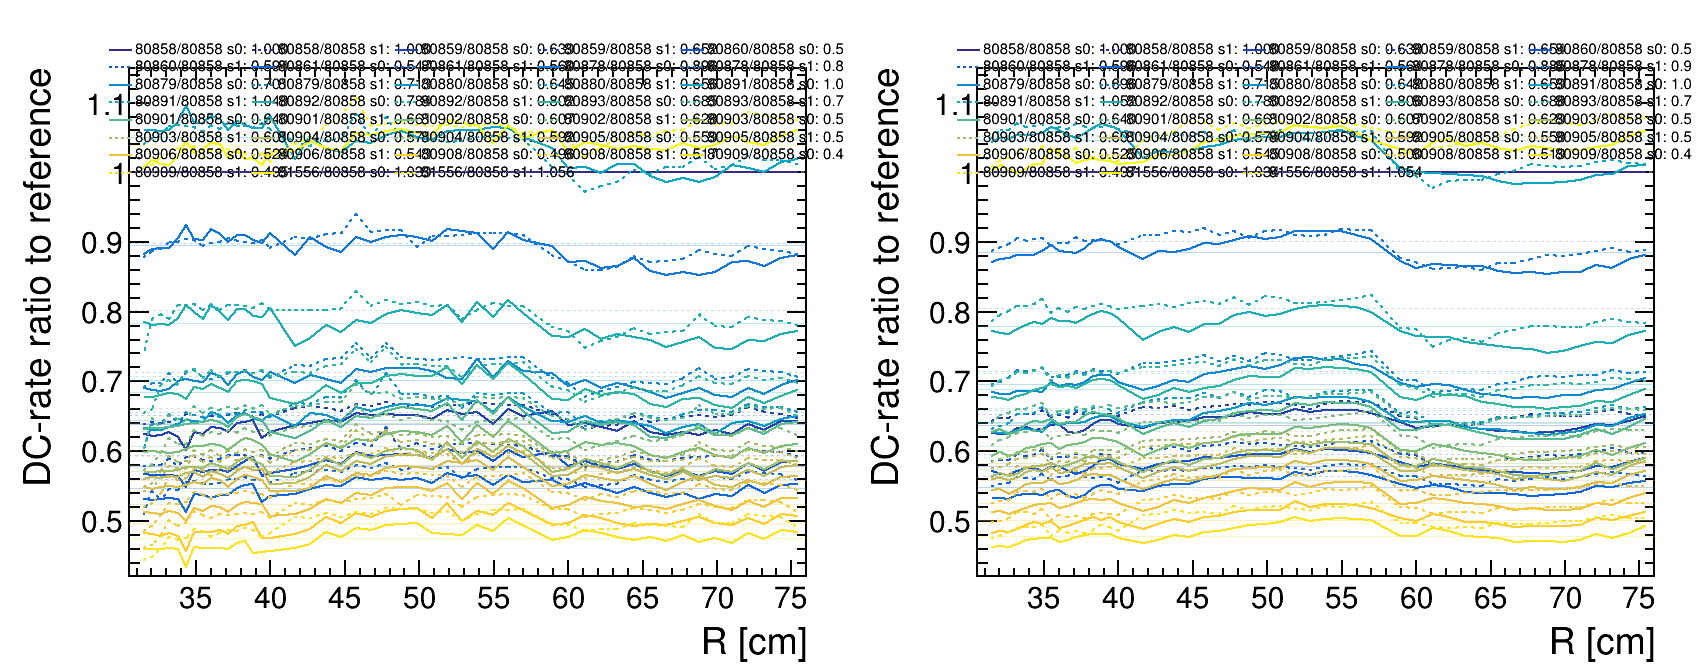

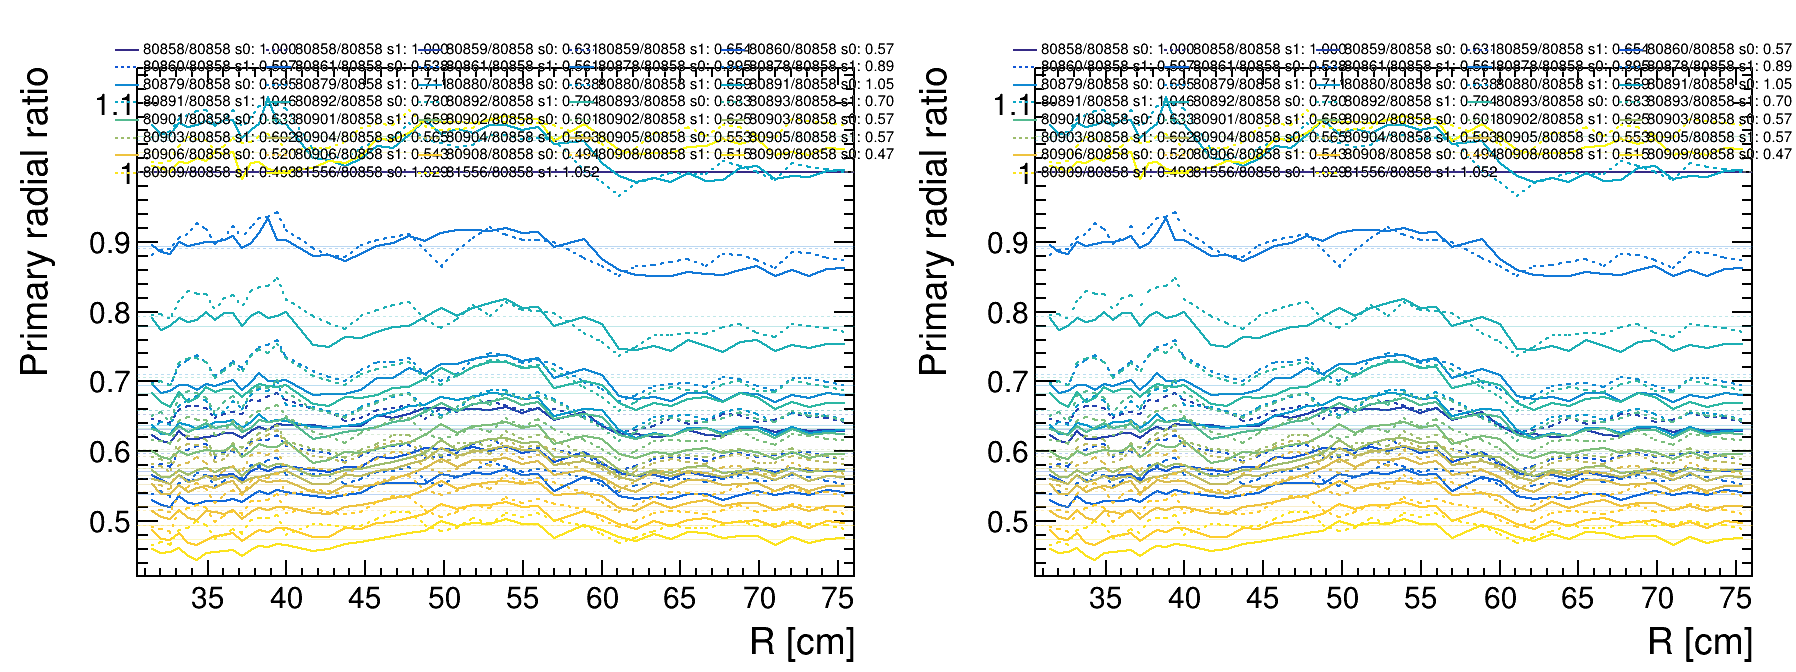

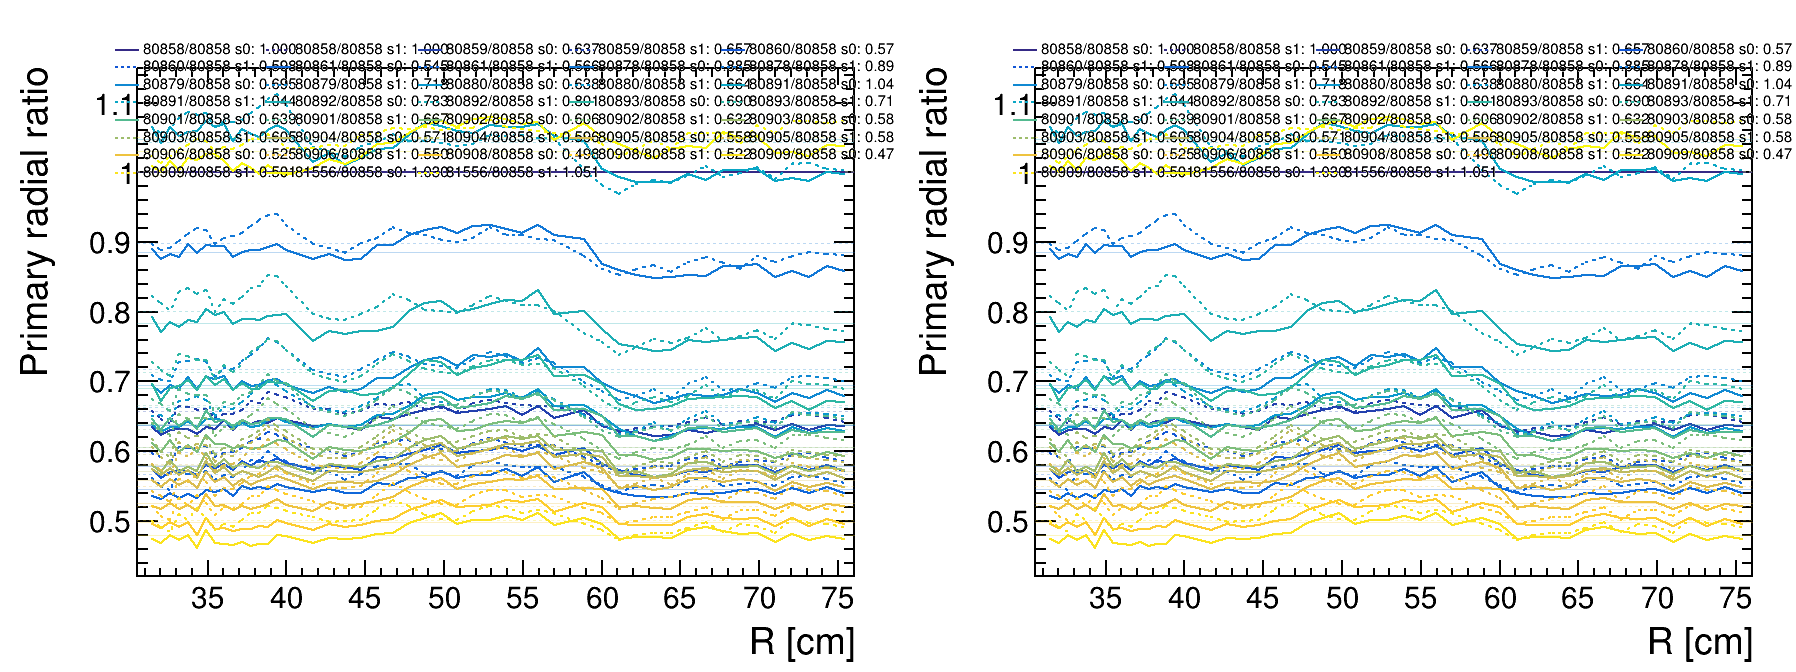

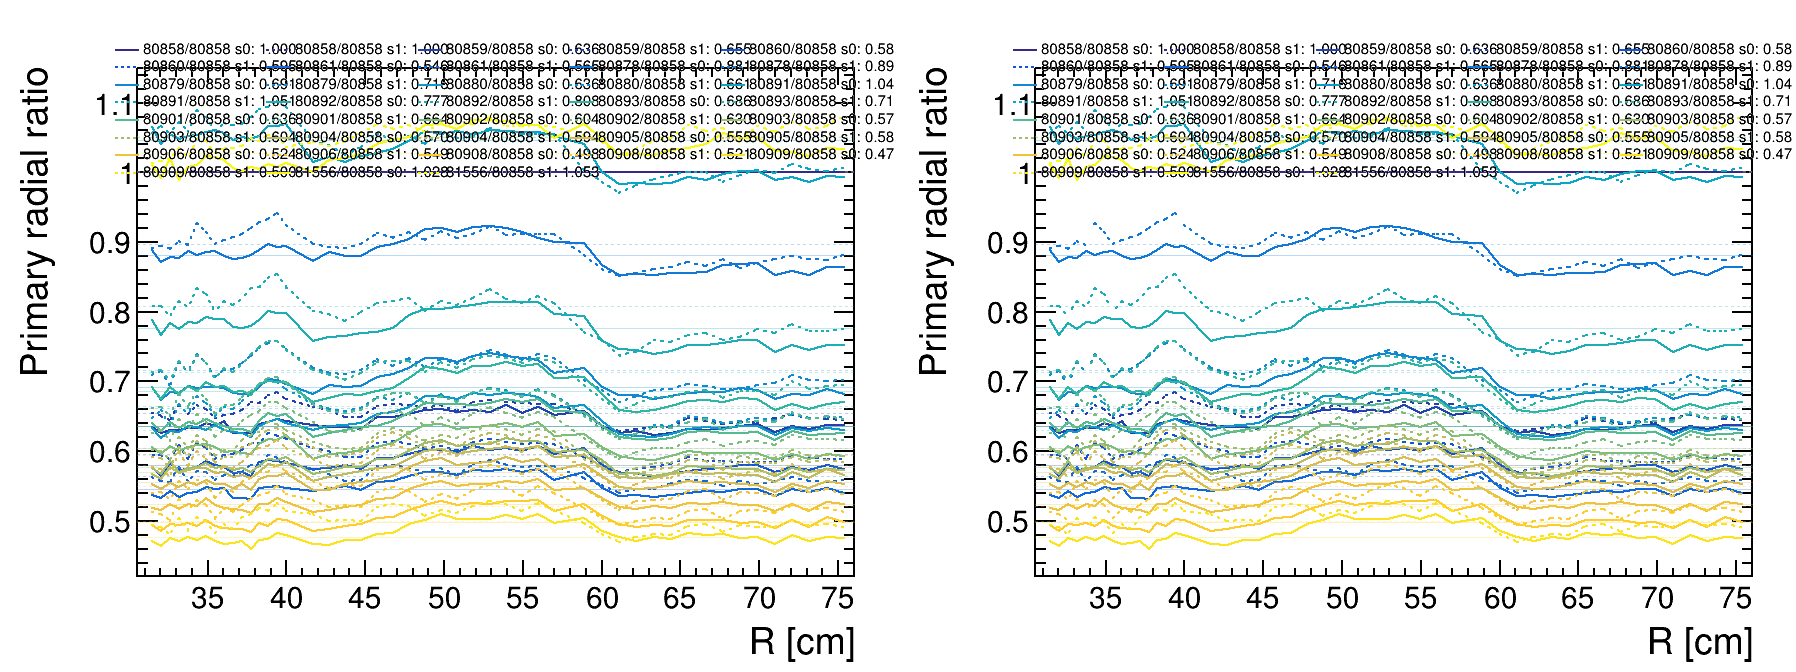

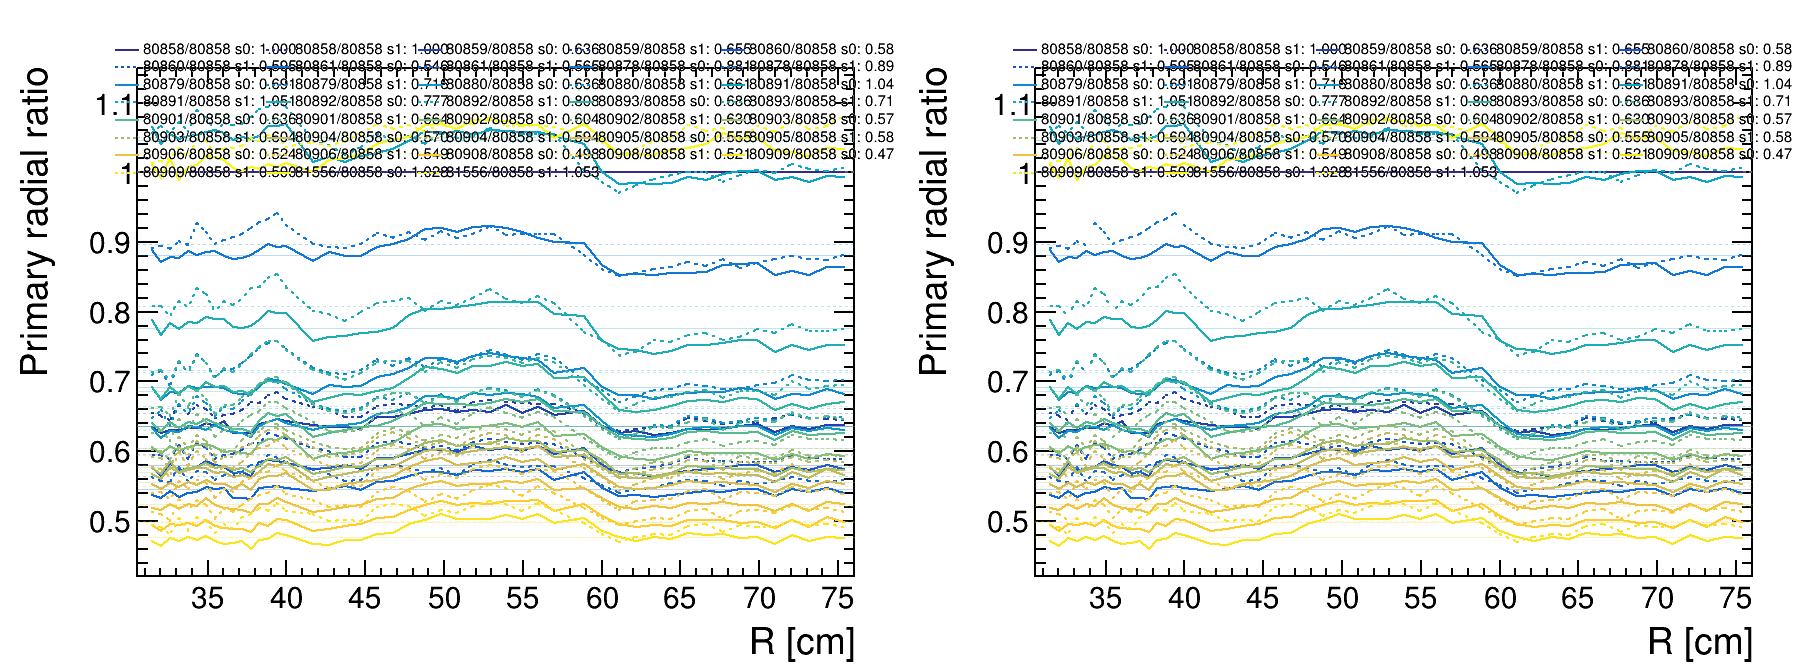

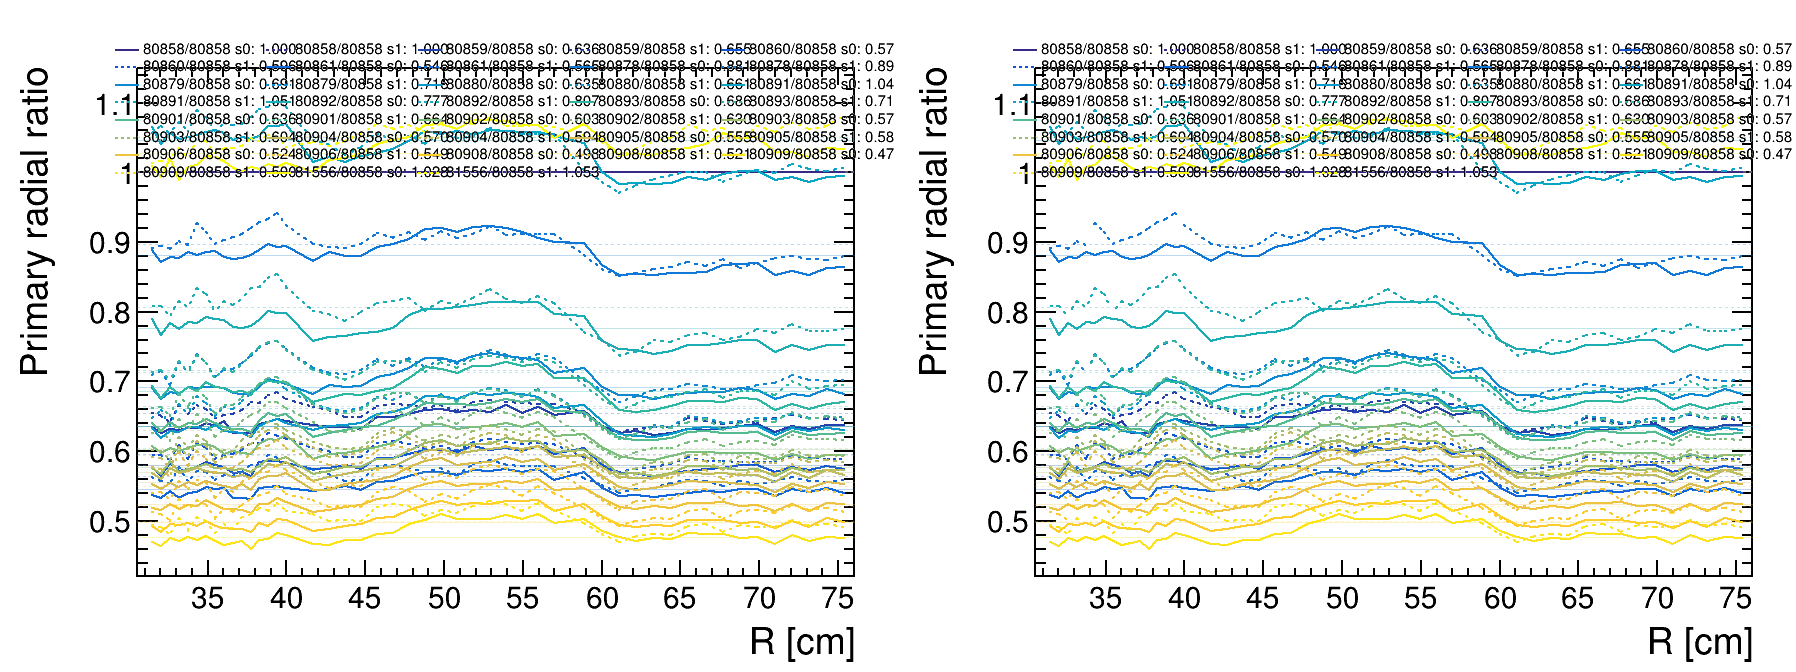

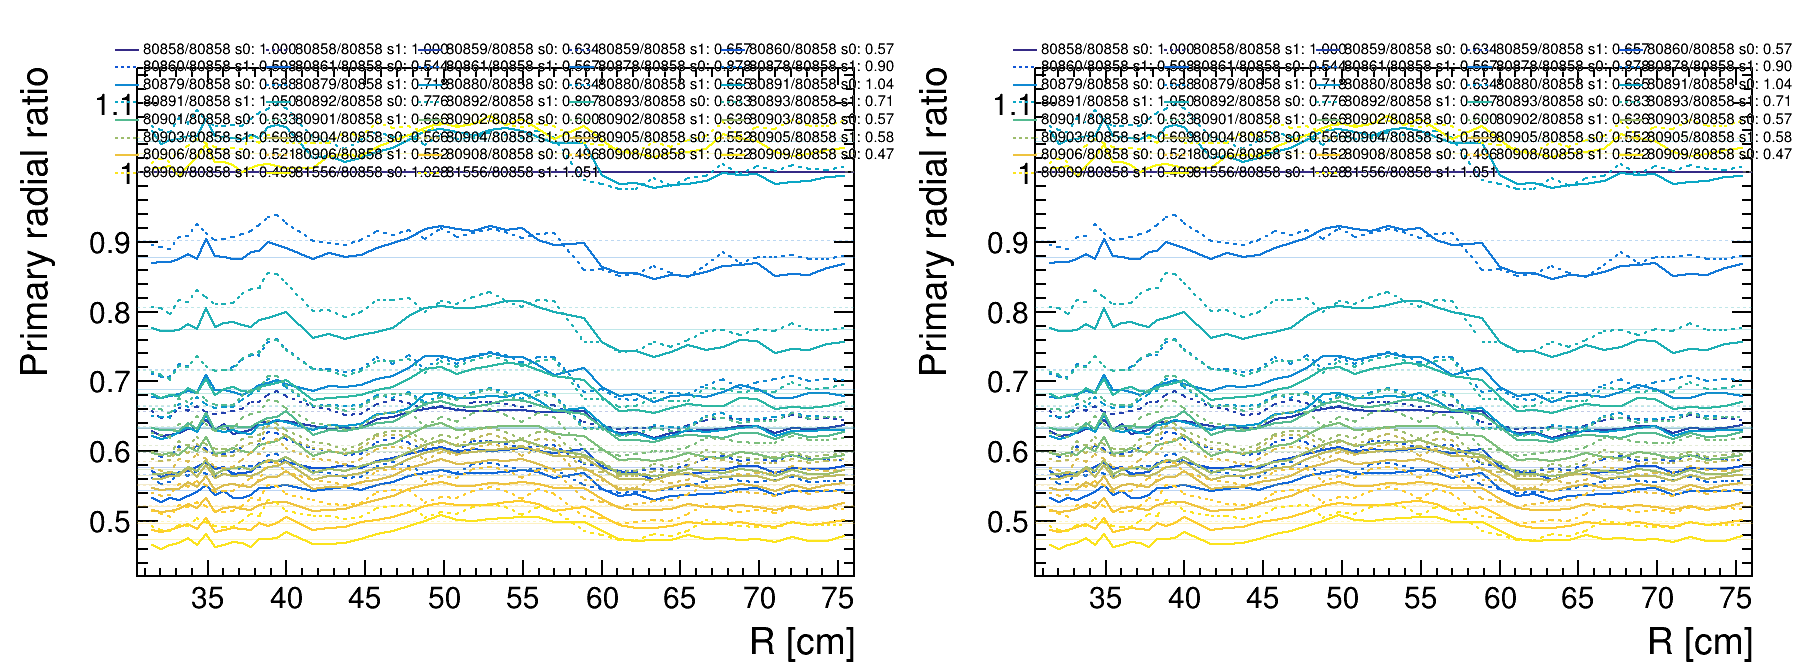

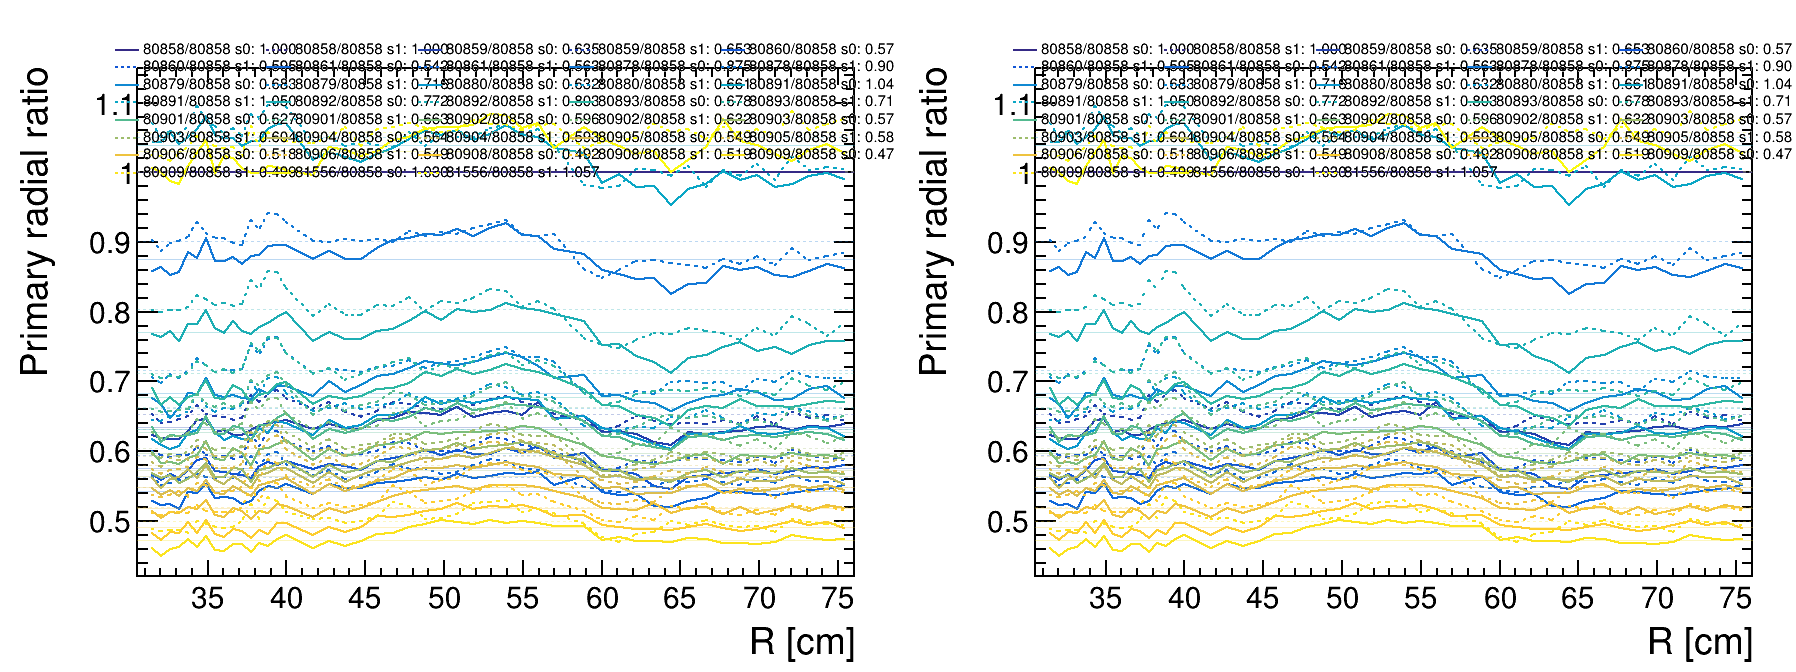

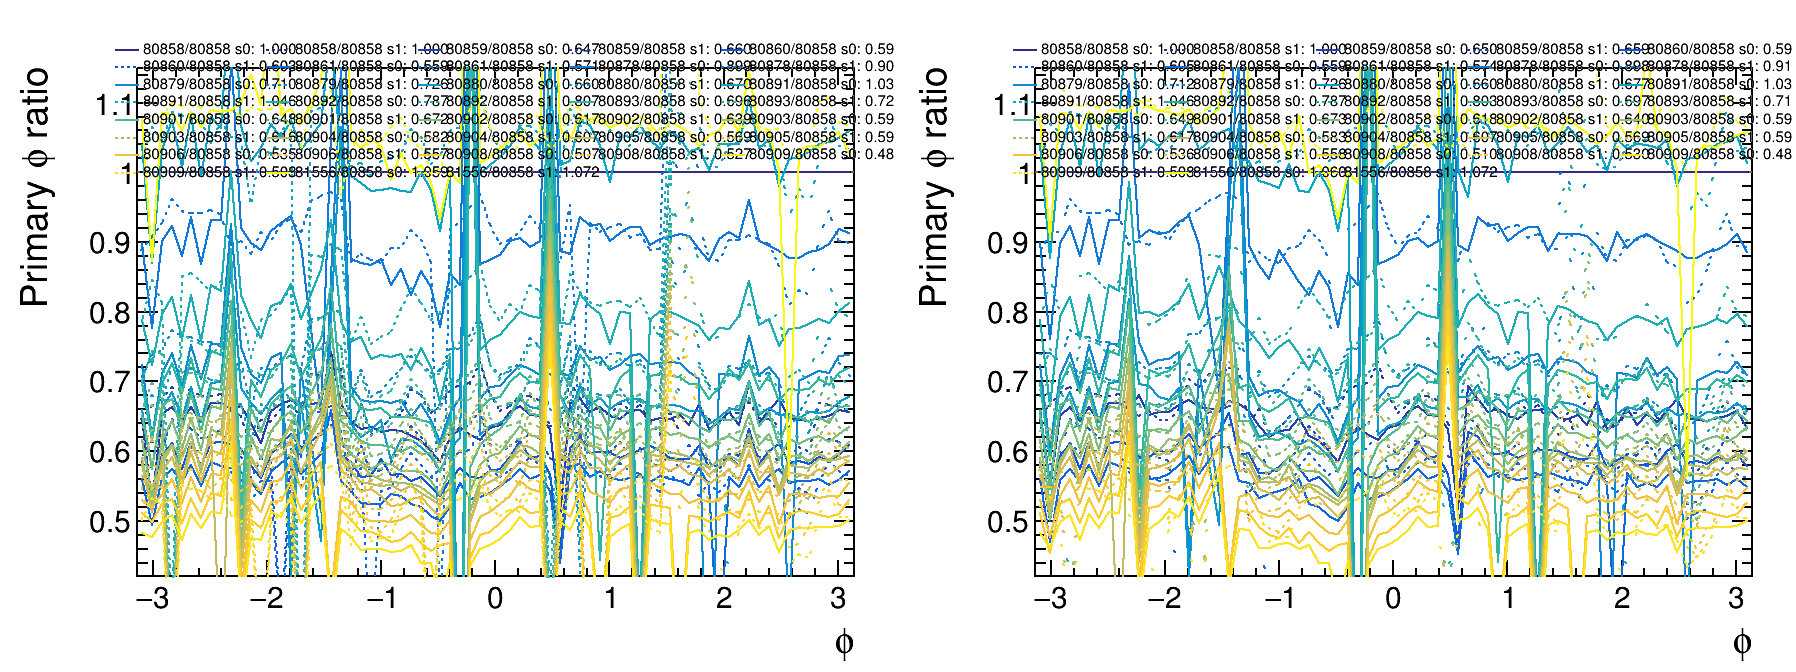

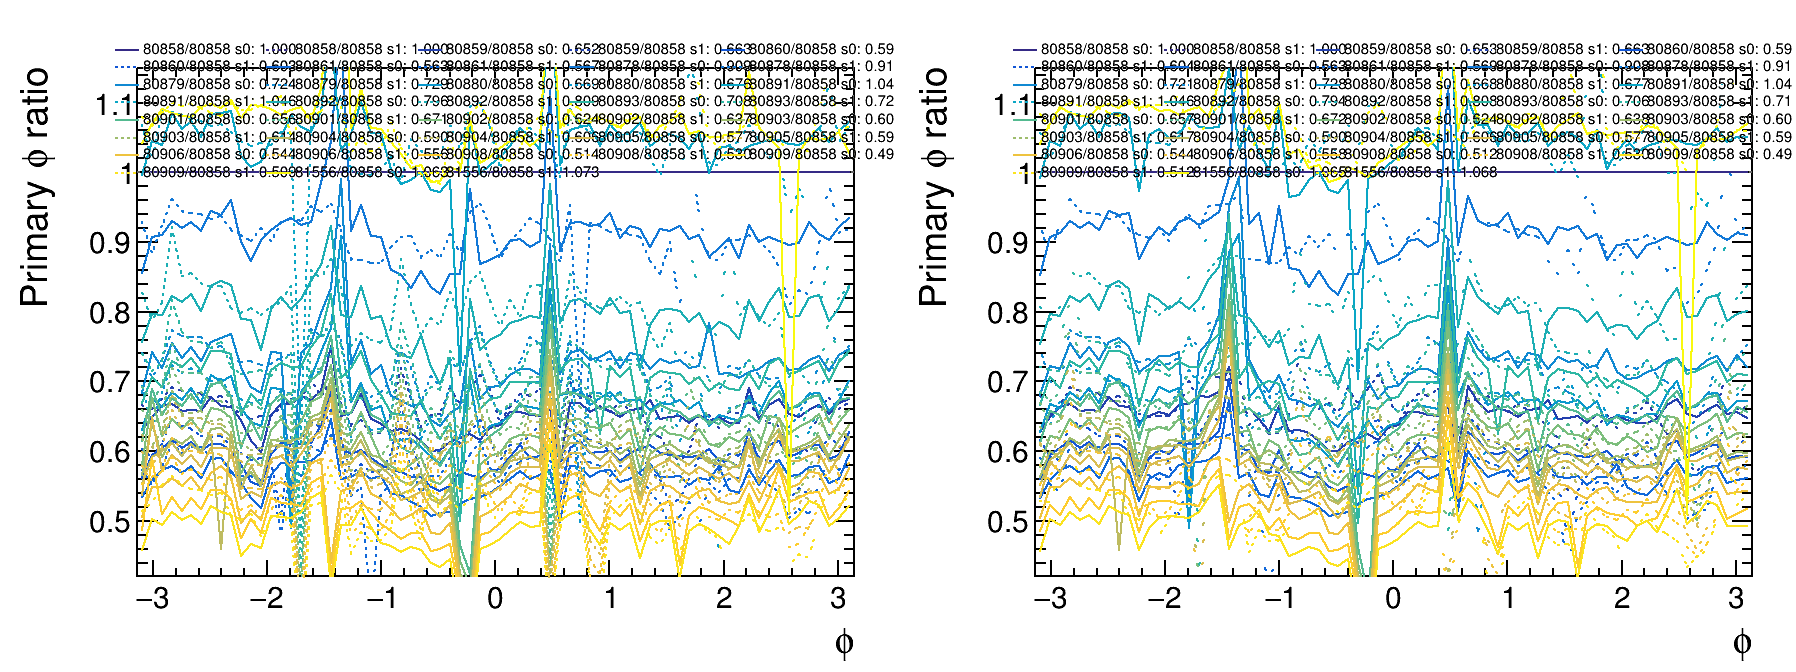

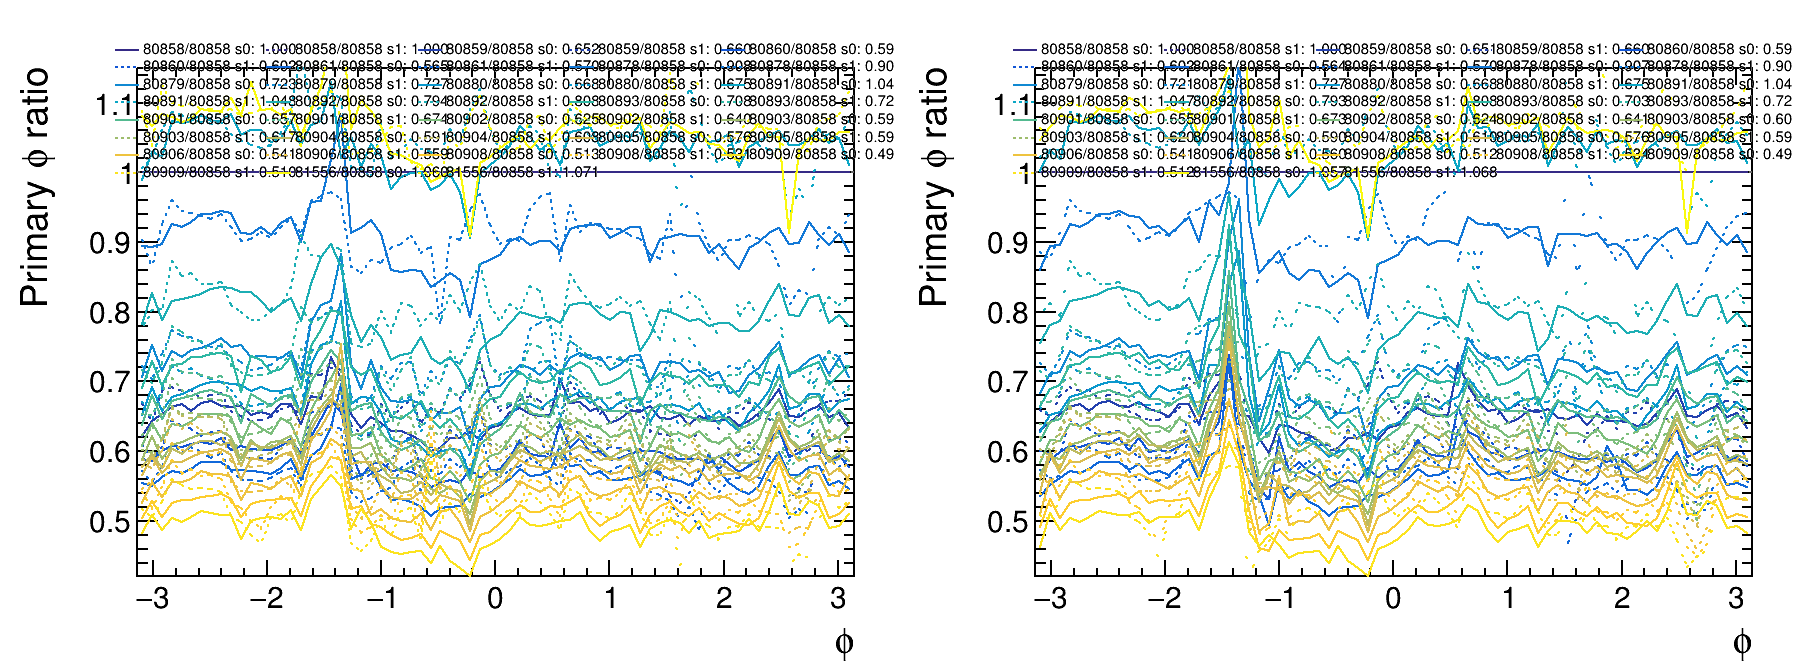

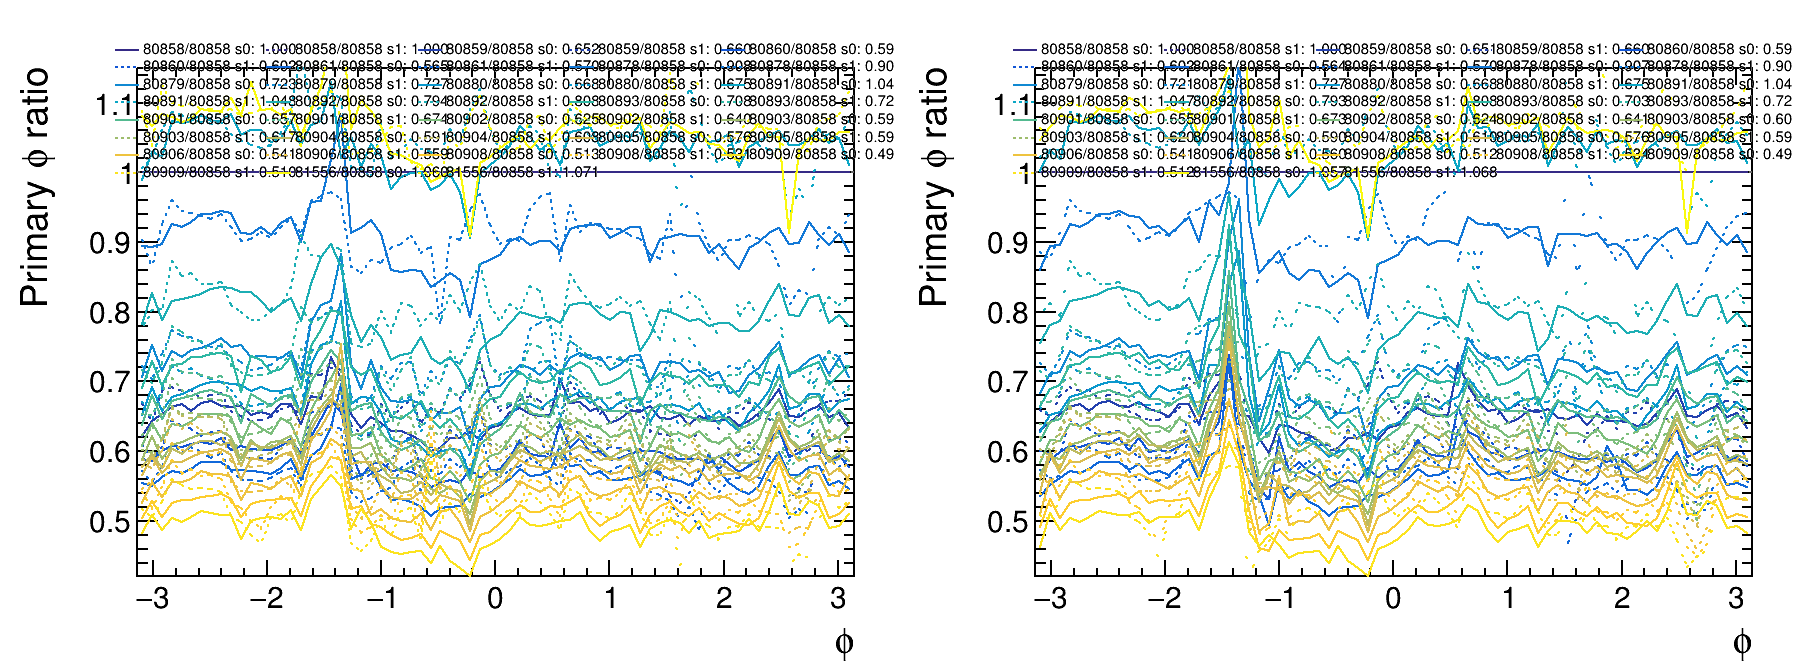

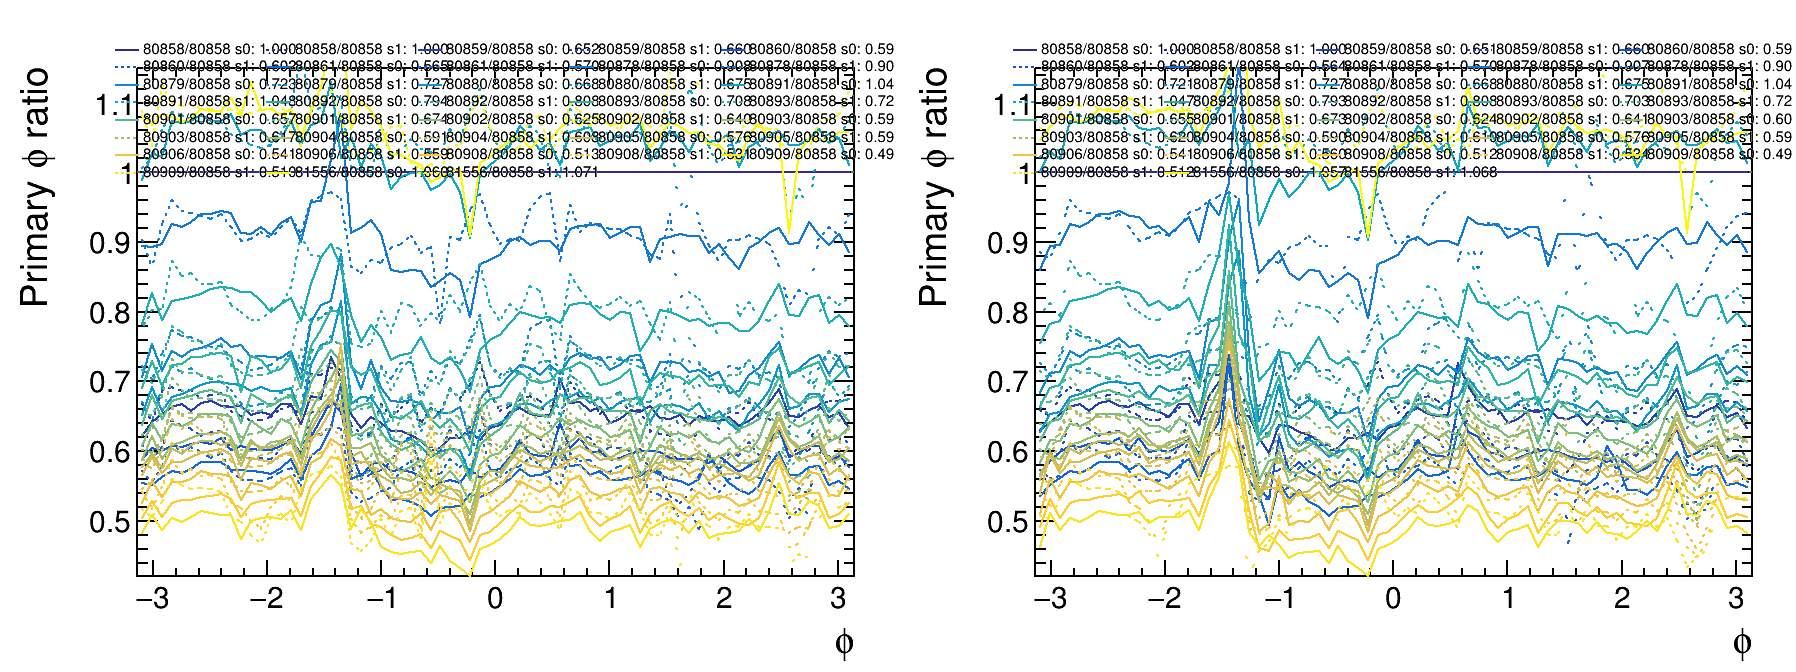

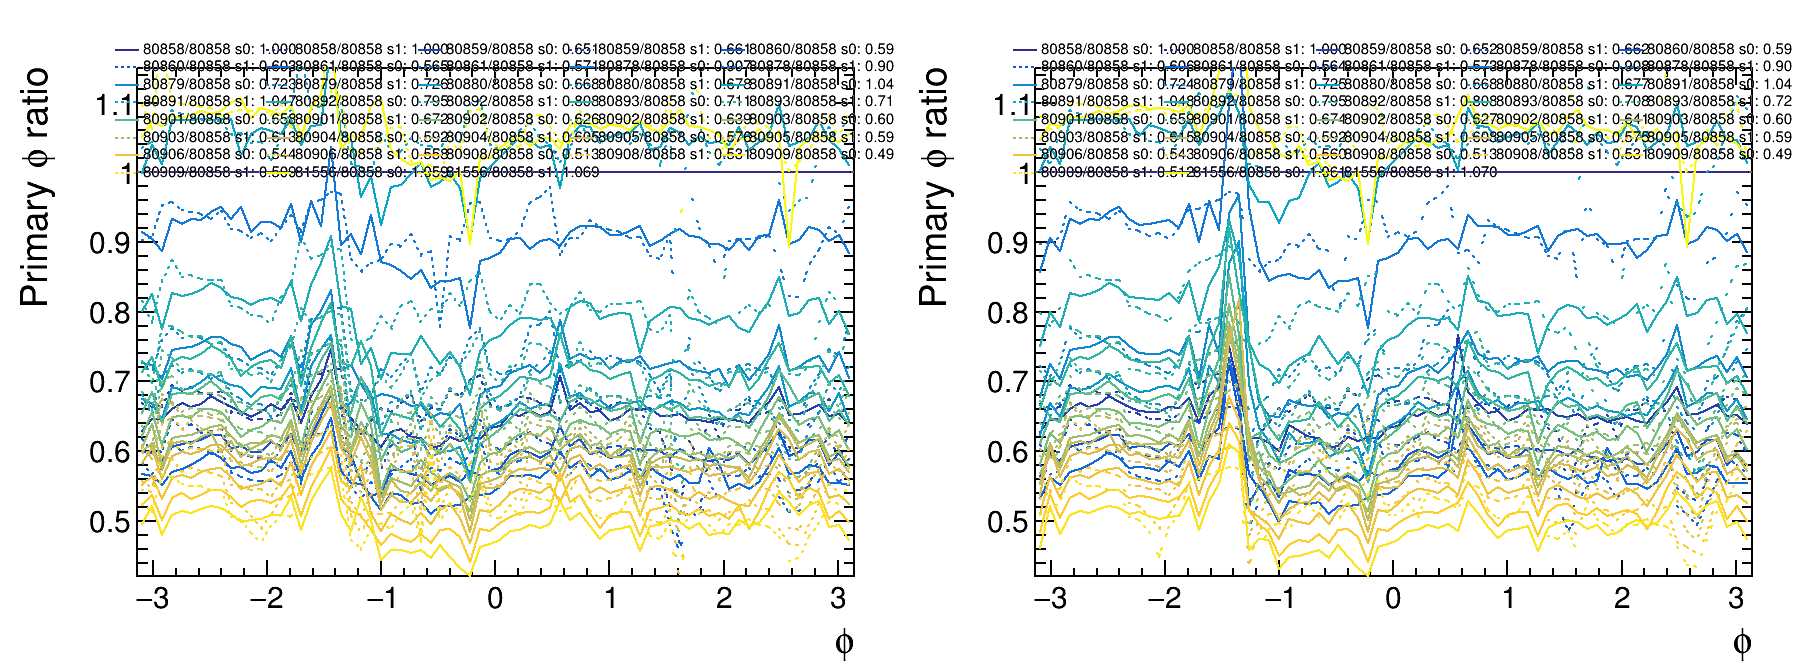

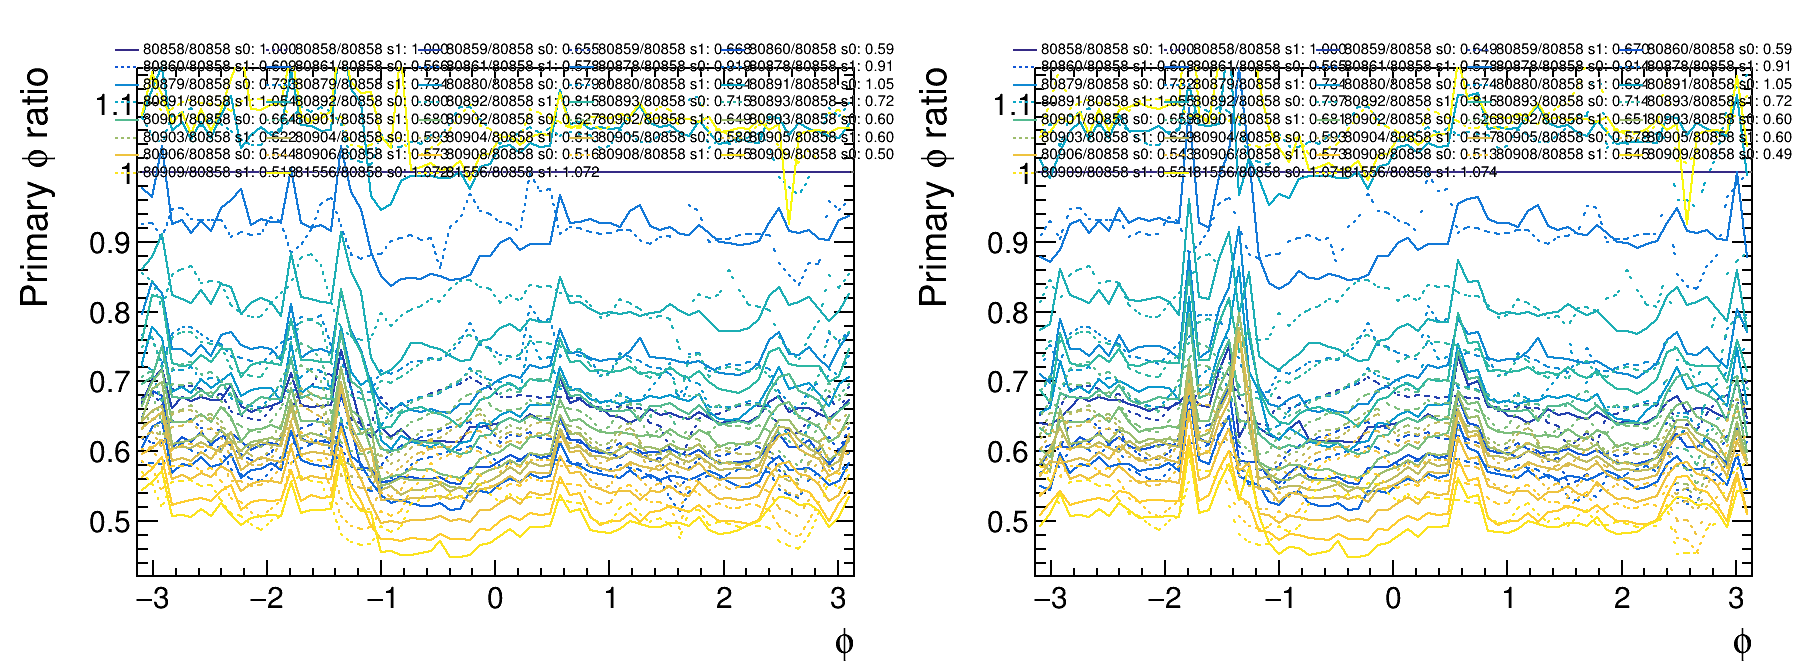

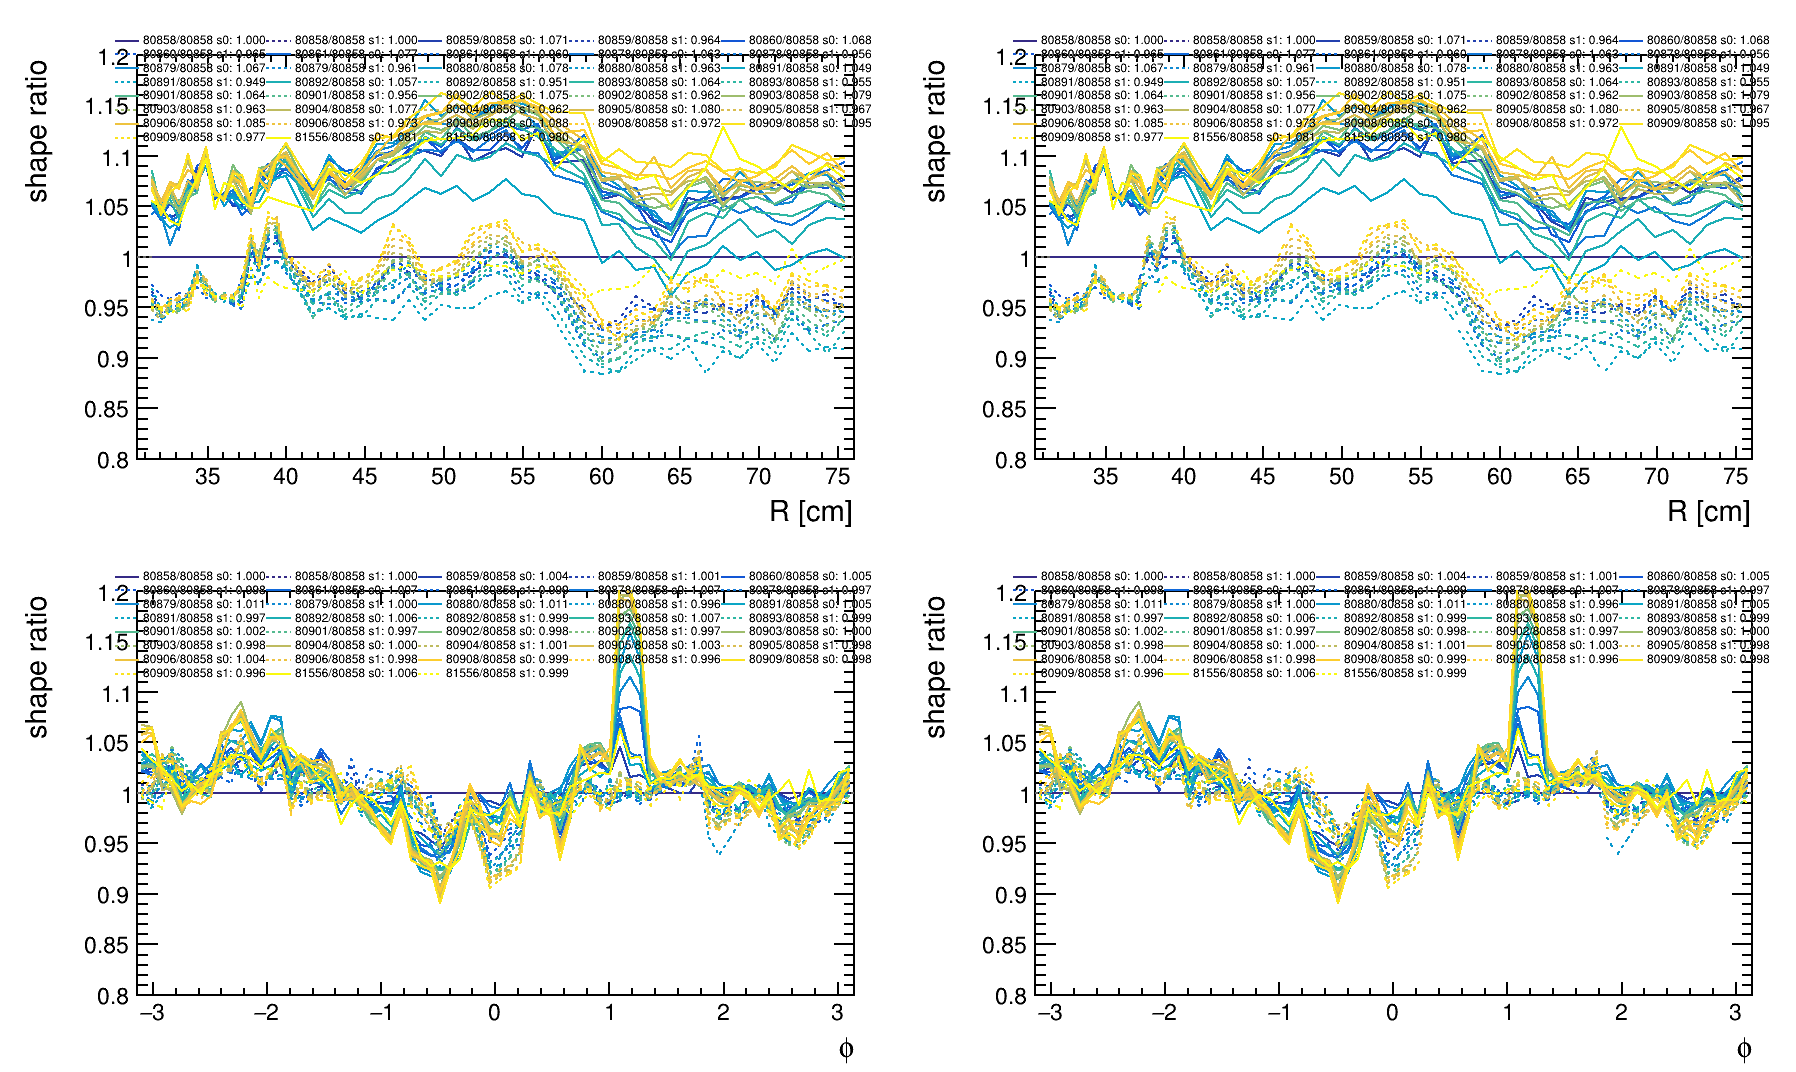

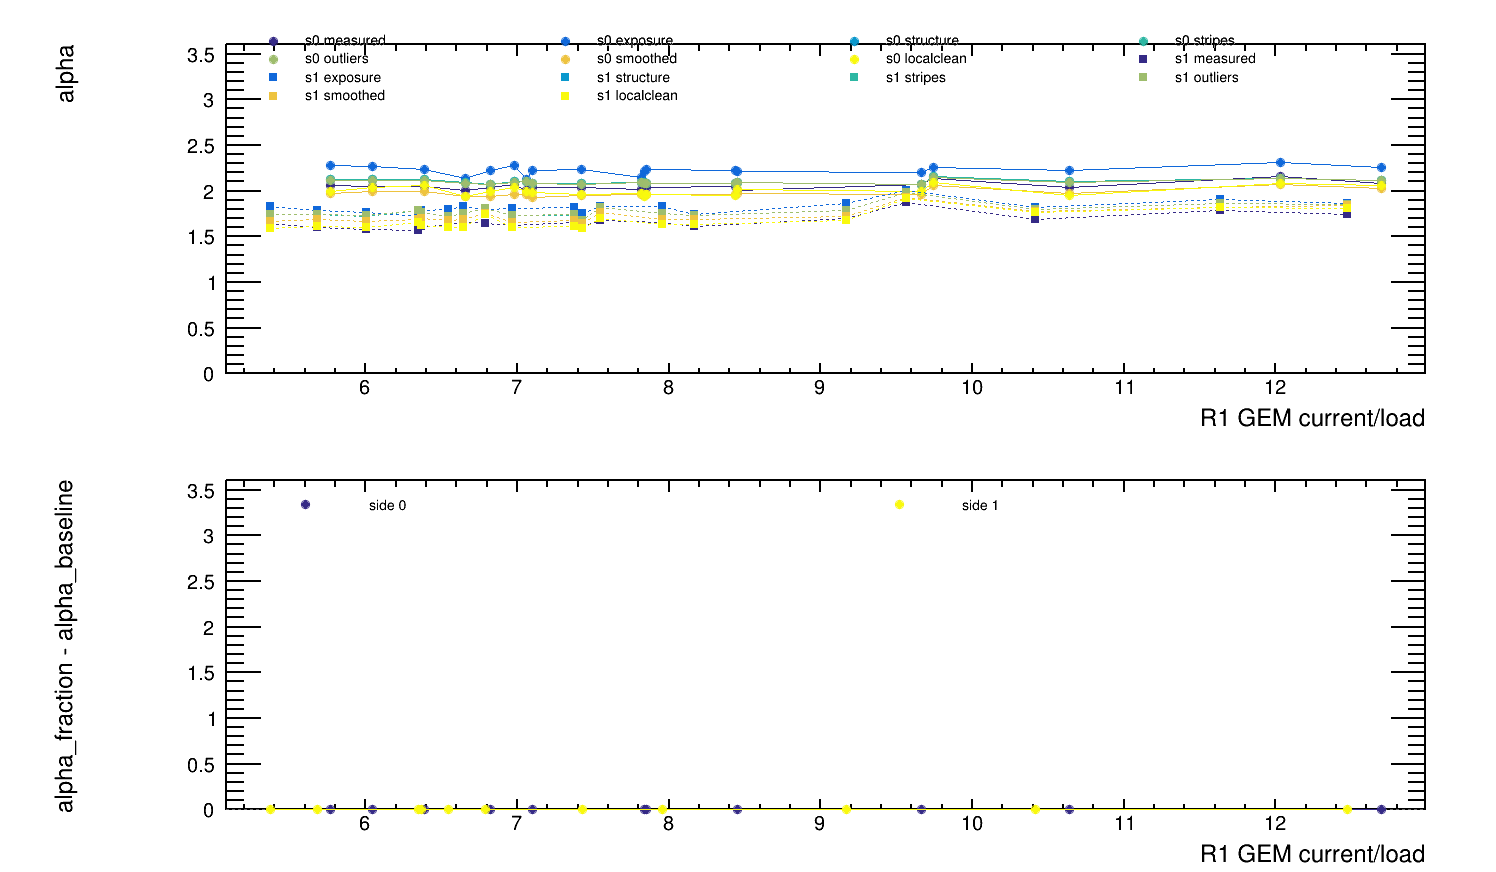

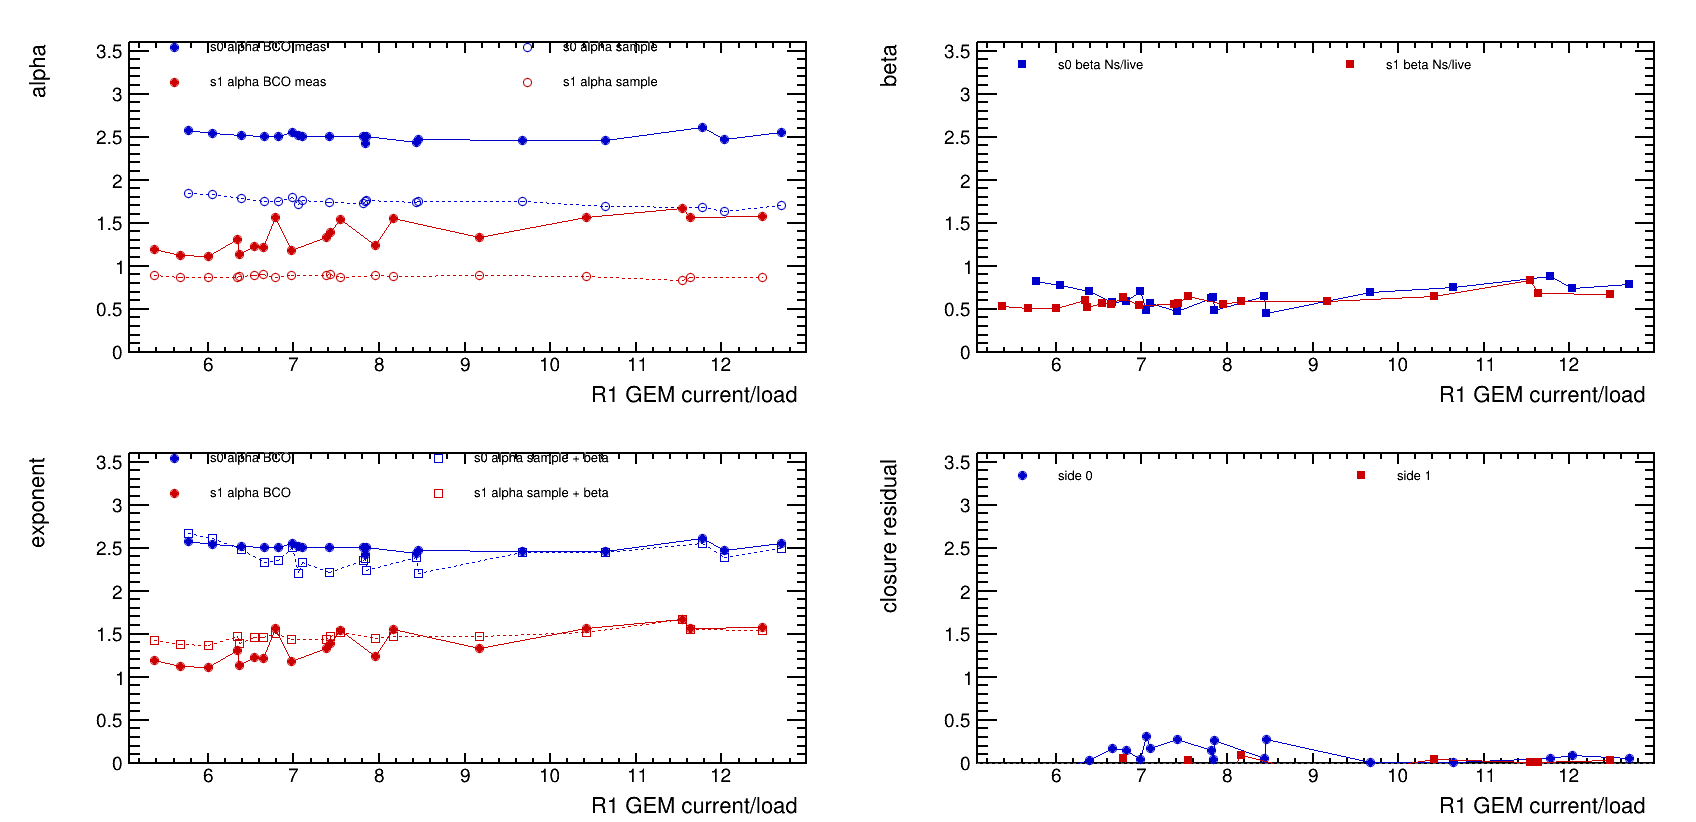

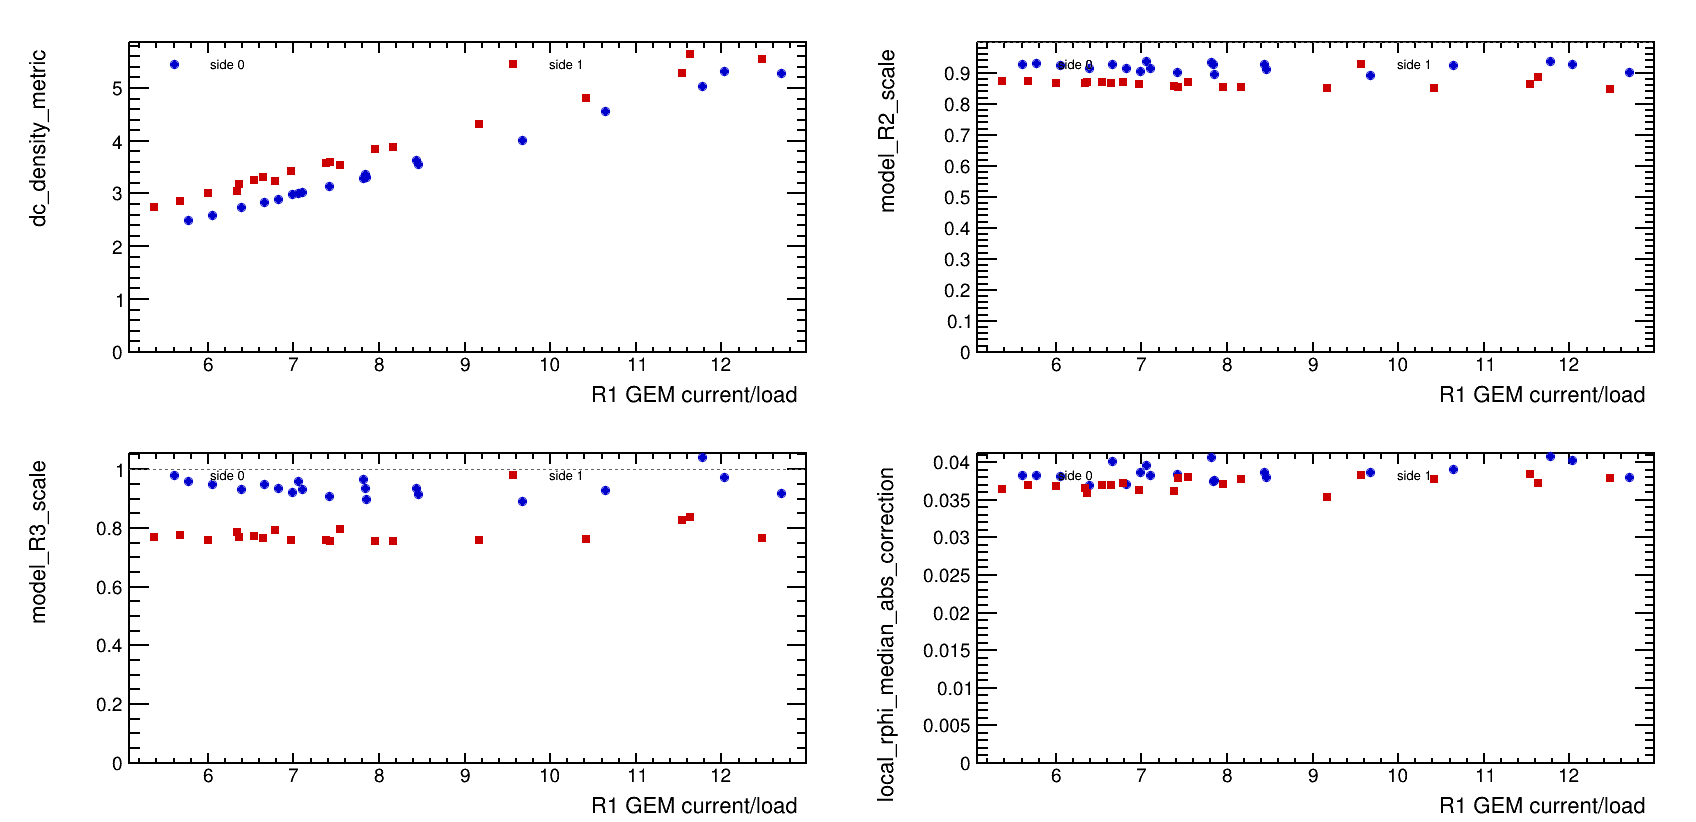

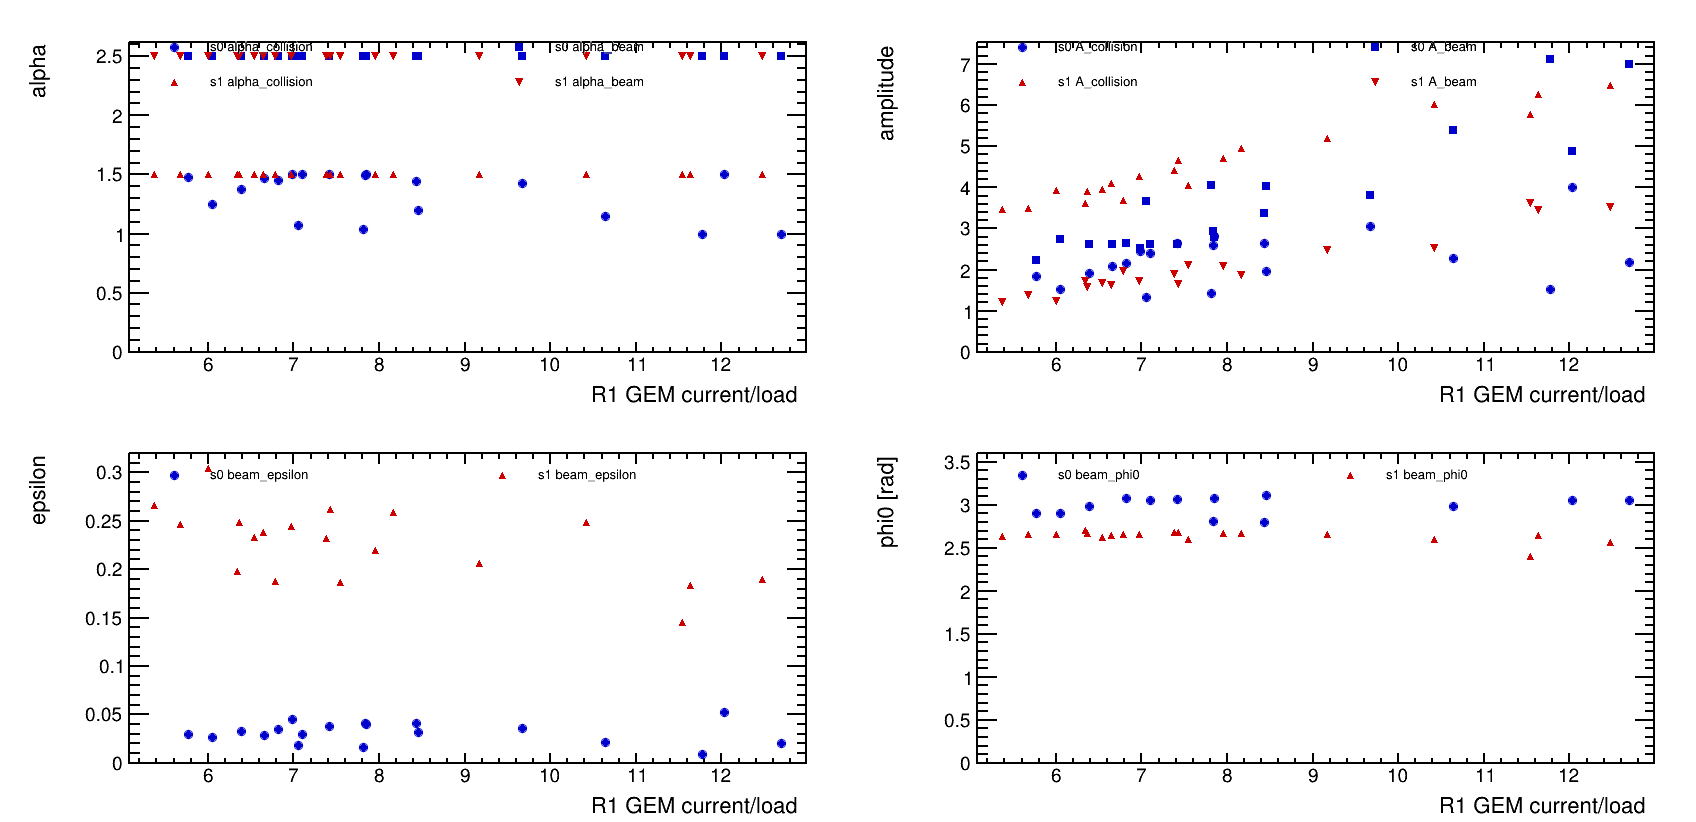

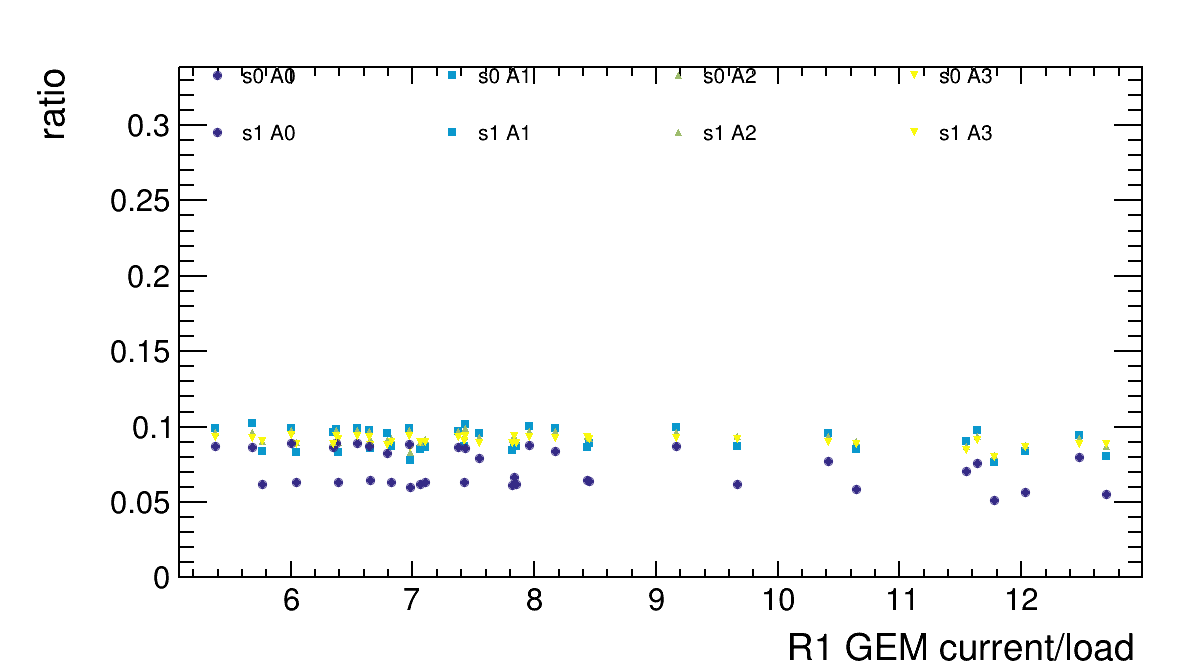

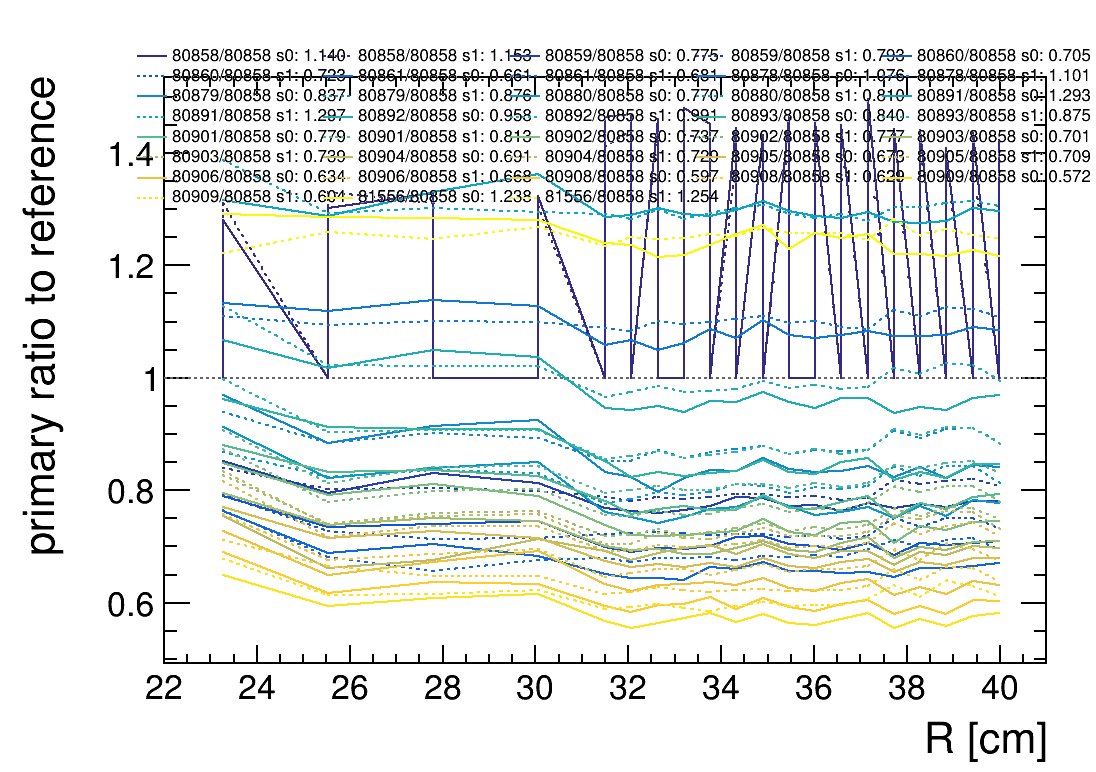

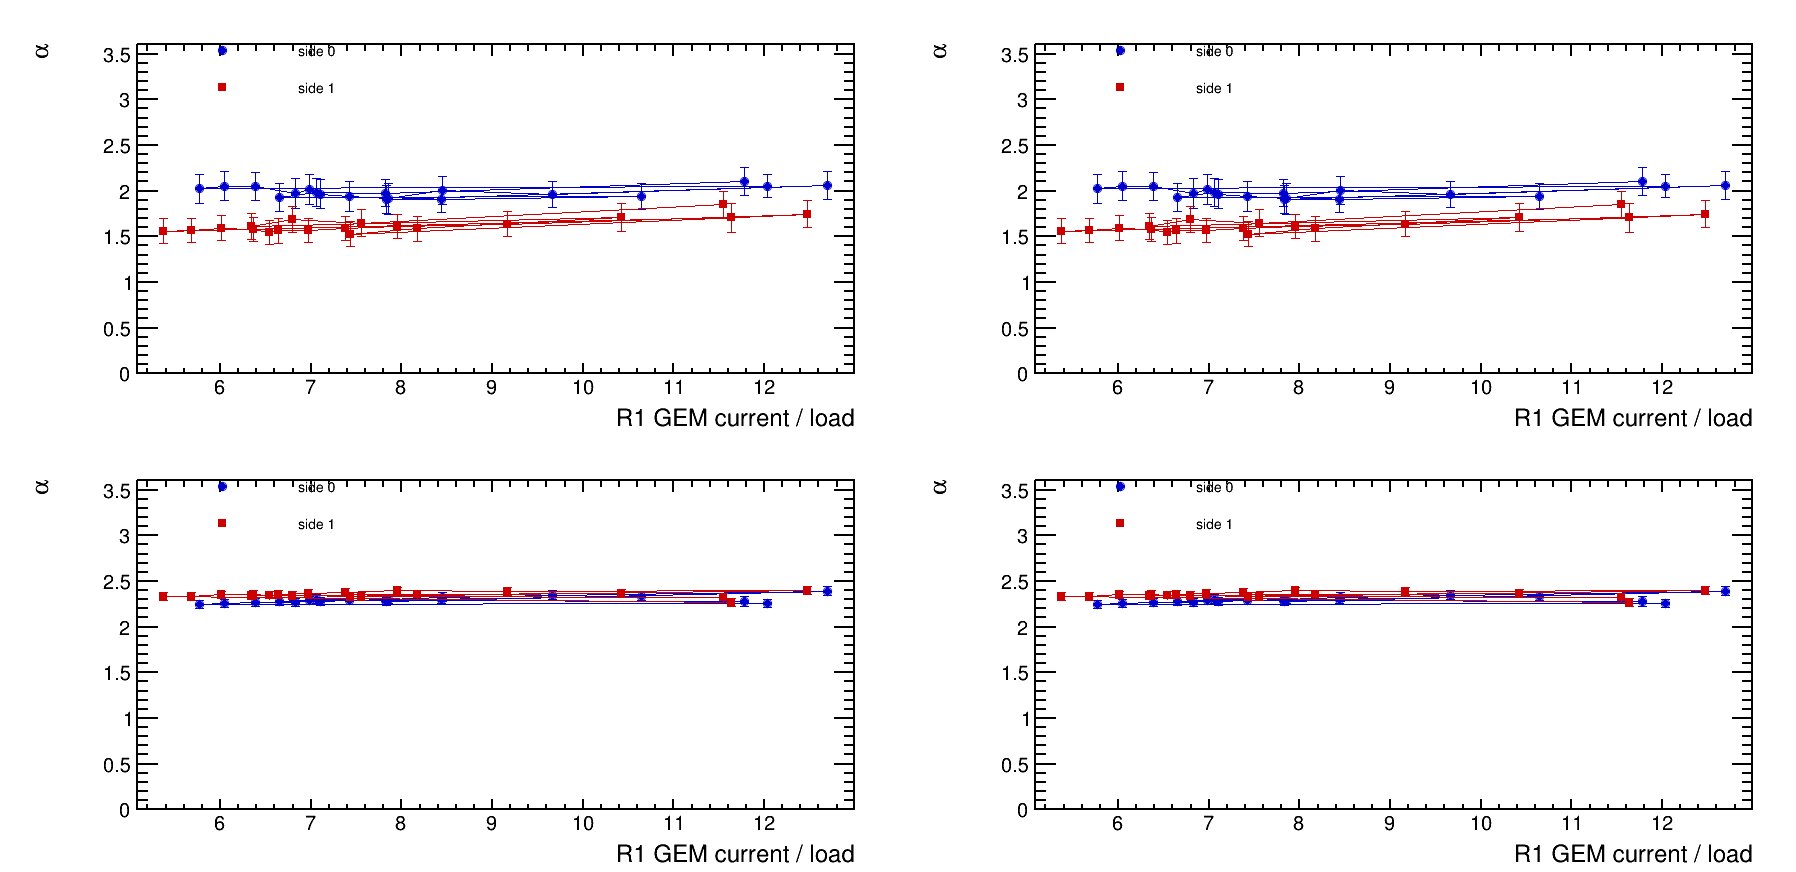

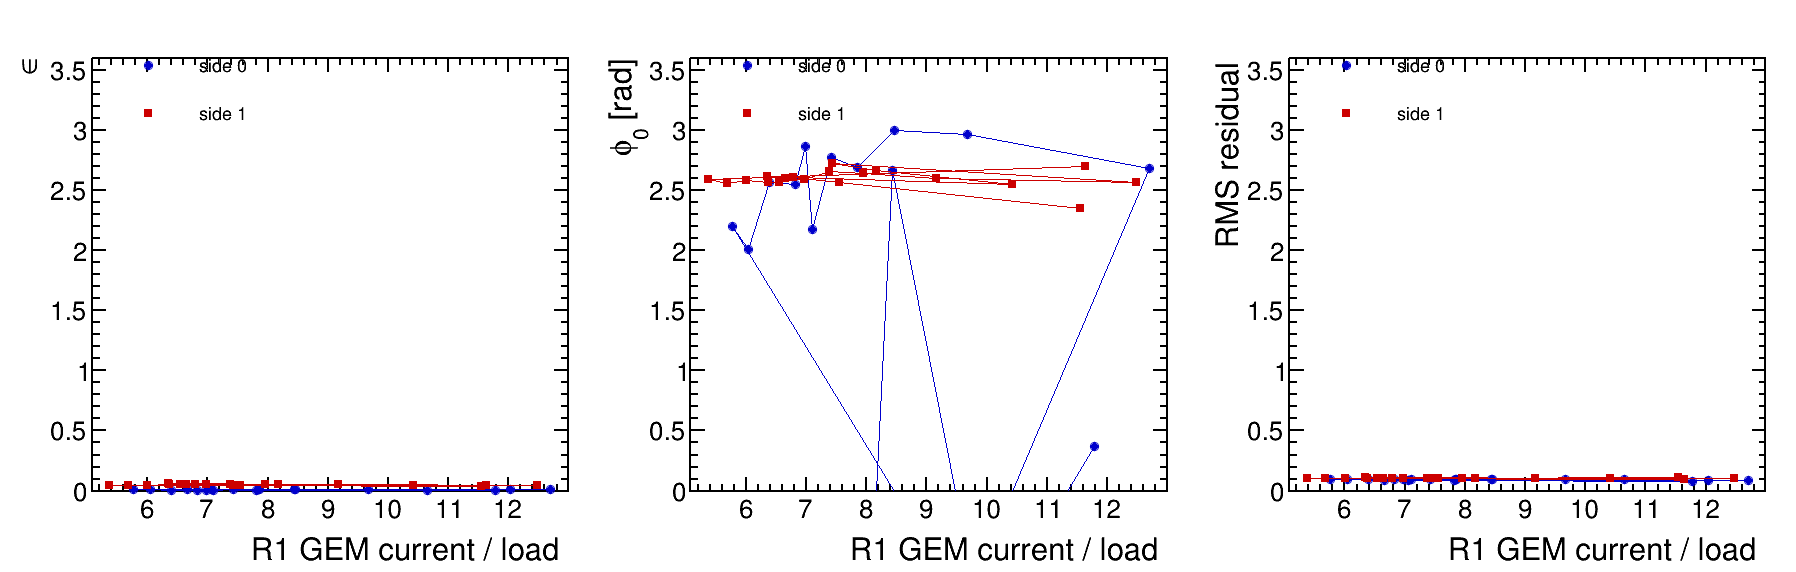

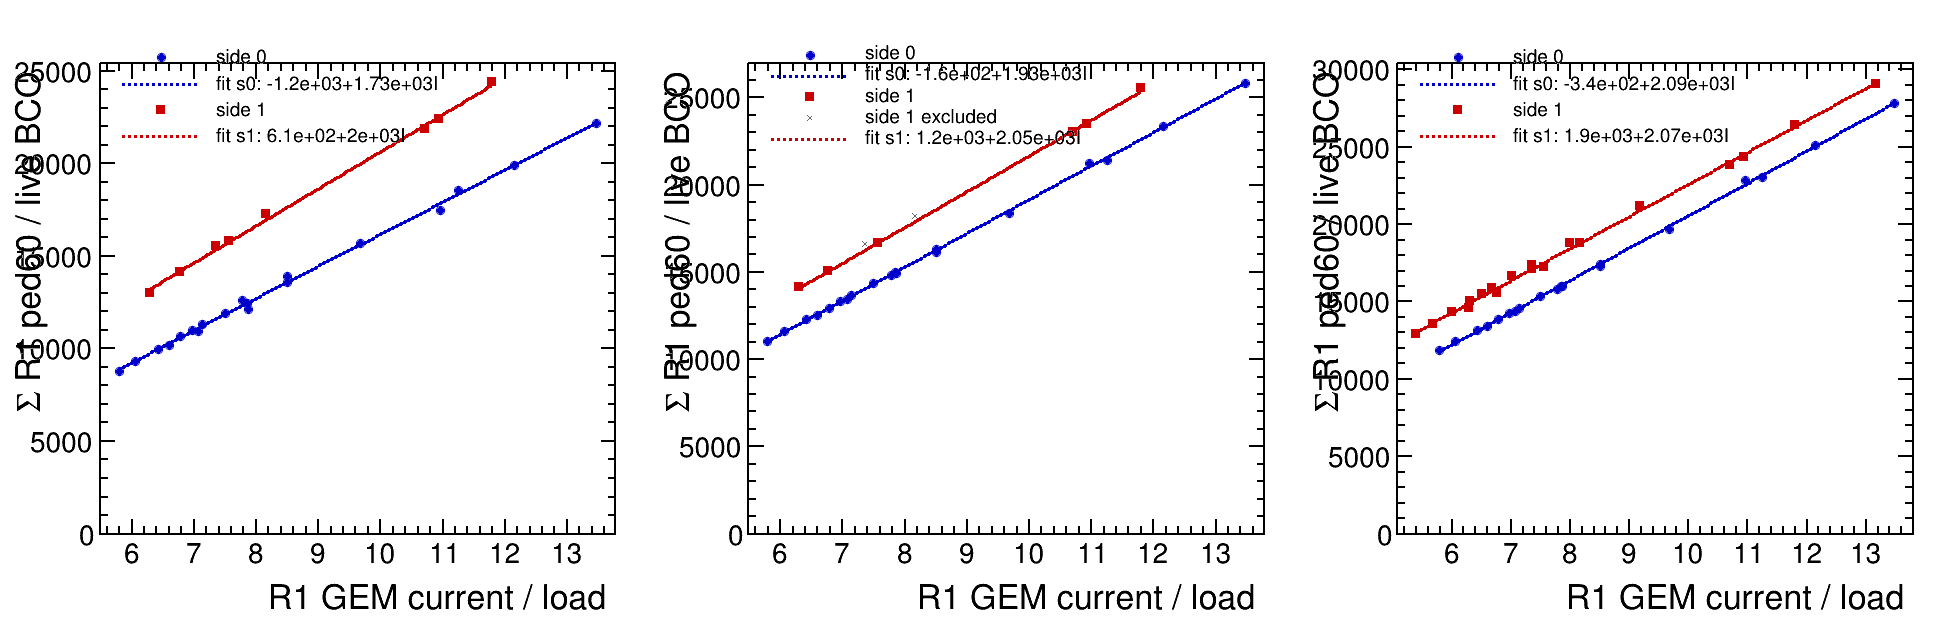

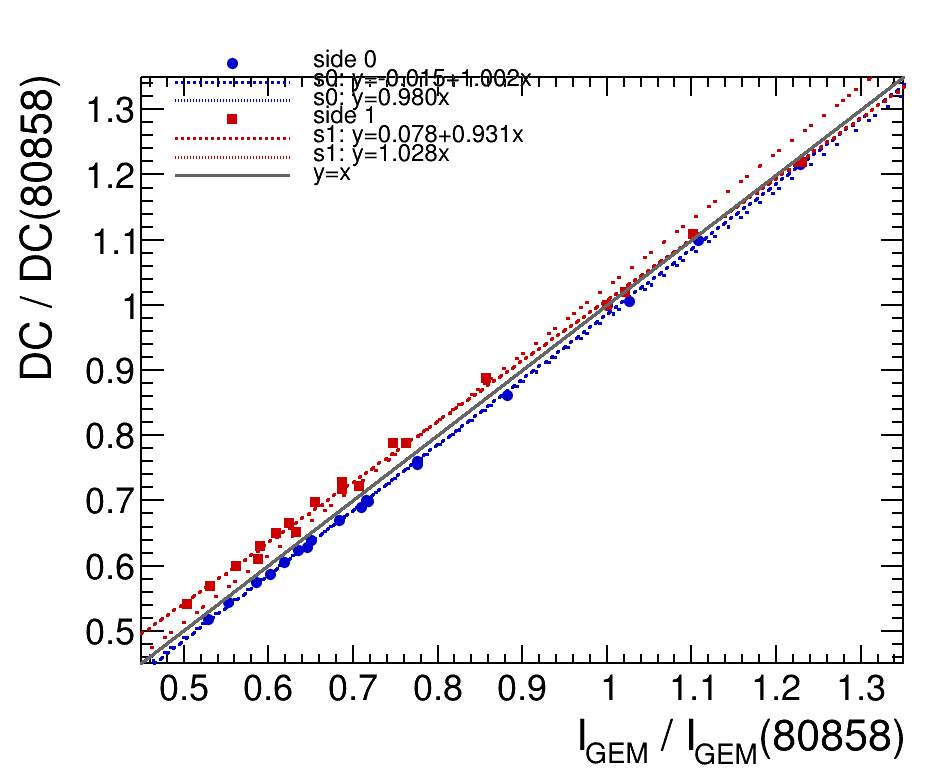

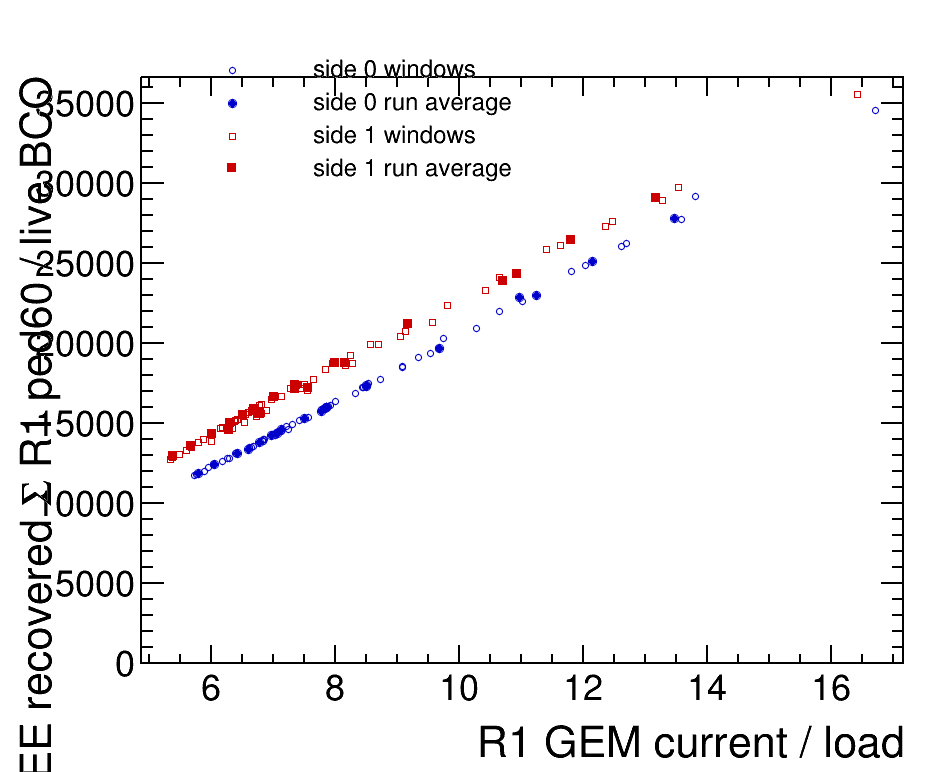

In [30]:
make_all_presentation_plots_v33(make_matplotlib=True, make_root=True)